# 21 — Multi-Model Comparison

**Origin:** Consolidates Existing Notebook 27 and previous pairwise comparison notebooks 20 and 24\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/21_multi_model_comparison/`\
**Depends on:** Notebooks 09–20

## Purpose

Compare the validated restoration evidence produced by OpenCV Telea, LaMa, Stable Diffusion inpainting, and the approved partial SDXL scope.

The notebook does not run restoration inference or recompute upstream metrics. It selects metric-independent baseline candidates, joins the complete validated evaluation evidence, performs paired direction-aware comparisons, identifies metric disagreement, measures painting-level ranking stability, selects auditable representative cases, and produces a self-contained thesis-aligned comparison report.

## Approved comparison populations

The full-scope paired population contains:

- 410 identical restoration cases;
- 410 OpenCV Telea candidates;
- 410 LaMa candidates;
- 410 Stable Diffusion primary generic-prompt candidates;
- 1,230 candidates in total.

The separate four-model subset contains:

- the ten predeclared SDXL feasibility cases;
- OpenCV Telea, LaMa, Stable Diffusion, and SDXL for every included case;
- 40 candidates in total.

SDXL is not treated as full-dataset evidence.

## Candidate-selection policy

Candidate selection is independent of metric performance:

- OpenCV Telea contributes its sole completed candidate per case;
- LaMa contributes its sole completed candidate per case;
- Stable Diffusion contributes only the completed `execution_role == "primary"` candidate using `prompt_variant_id == "p00_generic"`;
- SDXL contributes its ten completed, technically validated primary candidates.

Stable Diffusion prompt-ablation and repeated-seed candidates remain contextual evidence. They cannot replace the generic baseline or overweight Stable Diffusion in cross-model comparisons.

## Comparison evidence

The notebook compares:

- classical pixel and structural metrics;
- LPIPS perceptual distance;
- CLIP and DINOv2 feature similarity;
- spatial error, improvement, and restoration-change diagnostics;
- texture, colour, seam, and spillover evidence;
- local semantic-preservation evidence;
- semantic and structural consistency evidence;
- runtime and compute evidence;
- Stable Diffusion uncertainty as separate model-specific context.

Comparisons cover overall results and relevant experiment, category, style or period, damage type, degradation type, severity, target damage percentage, and zero-control scopes.

Metric direction is retained explicitly. Ranking stability uses leave-one-painting-out analysis so that the 410 cases are not treated as 410 independent paintings.

## Metric disagreement

A compact disagreement analysis uses predeclared anchors from the major evidence families.

Each evidence family receives at most one vote in the family-balanced diagnostic. Runtime and uncertainty are excluded from quality voting. The vote is not a combined quality score, conservation truth, or restoration recommendation.

## Thesis-aligned report

The self-contained HTML report addresses:

- multi-metric evaluation beyond traditional similarity measures;
- model differences across artwork categories and damage conditions;
- uncertainty and speculative restoration behaviour;
- practical, interpretable evidence for conservation-oriented review;
- the expanded roadmap evidence concerning colour, texture, seams, spatial effects, semantic consistency, runtime, and metric disagreement.

The report embeds its required web-sized figures, restoration grids, crops, and diagnostic panels directly in the HTML. Downloading the report alone must preserve the visual evidence needed to understand it.

Its narrative uses a balanced mixture of paragraphs, findings bullets, metrics, tables, analytical plots, restoration examples, diagnostic images, limitations, and scoped section-level conclusions.

## Interpretation limits

Reference-based computational similarity does not establish historical authenticity, material compatibility, ethical acceptability, or conservation approval.

The dataset contains 410 cases nested within 50 paintings. Style or period metadata is incomplete for part of the population.

Stable Diffusion uncertainty is empirical repeated-seed variability, not calibrated confidence. Deterministic models and single-seed SDXL candidates do not receive artificial uncertainty values.

CLIP and DINOv2 are general-purpose encoders rather than conservation-specific judges. Procedural degradation experiments do not reproduce the material chemistry of genuine painting deterioration.

No combined quality score, final trustworthiness score, or automatic conservation decision is retained.

## Canonical outputs

- `metrics/model_comparison.csv`
- `metrics/metric_disagreement.csv`
- `data/representative_cases.csv`
- `figures/model_comparison.png`
- `figures/metric_disagreement.png`
- `reports/multi_model_comparison.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

The standalone report is written to `outputs/21_multi_model_comparison/reports/multi_model_comparison.html`.

## Batch 1 — Contract, dependency preflight, and output ownership

This batch establishes the repository context, approved comparison configuration, exact input and output paths, upstream completion state, local schemas, paired-population arithmetic, metric-disagreement anchors, report portability requirements, thesis traceability, and scientific safeguards.

It creates only empty Notebook 21 output directories. It does not load the large upstream metric tables, select candidates, compute comparisons, render figures, build the report, or persist canonical output files.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import importlib
import json
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
import PIL
import yaml
from IPython.display import display


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration "
        f"repository root from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))


# ---------------------------------------------------------------------------
# Reload preparation-layer modules
# ---------------------------------------------------------------------------

import restoration_eval.schemas as schemas_module
import restoration_eval.multi_model_comparison as comparison_module

schemas_module = importlib.reload(schemas_module)
comparison_module = importlib.reload(comparison_module)


# ---------------------------------------------------------------------------
# Project helpers
# ---------------------------------------------------------------------------

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path as manifest_sha256_path,
)

from restoration_eval.multi_model_comparison import (
    METRIC_DISAGREEMENT_SCHEMA_VERSION,
    MODEL_COMPARISON_SCHEMA_VERSION,
    MULTI_MODEL_COMPARISON_MODULE_VERSION,
    REPRESENTATIVE_CASES_SCHEMA_VERSION,
    build_metric_registry,
    load_multi_model_comparison_config,
    validate_upstream_run_manifests,
)

from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    resolve_repo_path,
    to_repo_relative,
)

from restoration_eval.schemas import (
    METRIC_DISAGREEMENT_SCHEMA,
    MODEL_COMPARISON_SCHEMA,
    REPRESENTATIVE_CASES_SCHEMA,
    SCHEMA_REGISTRY,
    SCHEMAS_MODULE_VERSION,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "21"
NOTEBOOK_STEM = "21_multi_model_comparison"
NOTEBOOK_ORIGIN = (
    "Consolidates Existing Notebook 27 and previous "
    "pairwise comparison notebooks 20 and 24"
)

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

REPORT_STRUCTURE_APPROVED = True

NOTEBOOK_STARTED_AT_UTC = (
    datetime.now(timezone.utc)
    .isoformat()
    .replace("+00:00", "Z")
)

print("Notebook 21 repository bootstrap complete.")
print("Project root:", PROJECT_ROOT)
print("Notebook stem:", NOTEBOOK_STEM)
print("Python:", platform.python_version())
print(
    "Multi-model helper:",
    MULTI_MODEL_COMPARISON_MODULE_VERSION,
)
print("Schemas module:", SCHEMAS_MODULE_VERSION)
print("Report structure approved:", REPORT_STRUCTURE_APPROVED)
print("Started at:", NOTEBOOK_STARTED_AT_UTC)

Notebook 21 repository bootstrap complete.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook stem: 21_multi_model_comparison
Python: 3.12.6
Multi-model helper: 1.0.0
Schemas module: 1.17.0
Report structure approved: True
Started at: 2026-08-31T12:28:54.630382Z


In [2]:
# ---------------------------------------------------------------------------
# Configuration and governing paths
# ---------------------------------------------------------------------------

COMPARISON_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "multi_model_comparison.yaml"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / f"{NOTEBOOK_STEM}.ipynb"
)

HELPER_PATHS = {
    "multi_model_comparison": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "multi_model_comparison.py"
    ),
    "schemas": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "schemas.py"
    ),
    "paths": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "paths.py"
    ),
    "manifests": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "manifests.py"
    ),
    "validation": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "validation.py"
    ),
}

comparison_config = load_multi_model_comparison_config(
    COMPARISON_CONFIG_PATH
)

COMPARISON_CONFIG = comparison_config[
    "multi_model_comparison"
]

CONFIGURED_INPUTS = COMPARISON_CONFIG["inputs"]
CONFIGURED_OUTPUTS = COMPARISON_CONFIG["output"]
POPULATIONS = COMPARISON_CONFIG["populations"]
SELECTION_POLICY = COMPARISON_CONFIG[
    "candidate_selection"
]
RANKING_POLICY = COMPARISON_CONFIG["ranking"]
REPORT_POLICY = COMPARISON_CONFIG["report"]
EXPECTED_COUNTS = COMPARISON_CONFIG["expected_counts"]
EVIDENCE_POLICY = COMPARISON_CONFIG[
    "evidence_policy"
]

if COMPARISON_CONFIG["notebook_id"] != NOTEBOOK_ID:
    raise ValueError(
        "Configured notebook ID disagrees with Notebook 21."
    )

if COMPARISON_CONFIG["notebook_stem"] != NOTEBOOK_STEM:
    raise ValueError(
        "Configured notebook stem disagrees with Notebook 21."
    )

if (
    CONFIGURED_OUTPUTS["root"]
    != f"outputs/{NOTEBOOK_STEM}"
):
    raise ValueError(
        "Configured output root violates Notebook 21 ownership."
    )


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    key: resolve_repo_path(
        value,
        PROJECT_ROOT,
        must_exist=True,
    )
    for key, value in CONFIGURED_INPUTS.items()
}


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

NOTEBOOK_OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

PREEXISTING_OWNED_FILES = (
    sorted(
        path
        for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if NOTEBOOK_OUTPUT_ROOT.exists()
    else []
)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "metrics",
        "figures",
        "reports",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

OUTPUTS = {
    "model_comparison": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "model_comparison_path"
        ]
    ),
    "metric_disagreement": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "metric_disagreement_path"
        ]
    ),
    "representative_cases": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "representative_cases_path"
        ]
    ),
    "model_comparison_figure": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "model_comparison_figure_path"
        ]
    ),
    "metric_disagreement_figure": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "metric_disagreement_figure_path"
        ]
    ),
    "report": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["report_path"]
    ),
    "run_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "run_manifest_path"
        ]
    ),
    "artifacts": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["artifacts_path"]
    ),
    "validation": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["validation_path"]
    ),
}

WORK_ROOT = (
    NOTEBOOK_OUTPUT_ROOT
    / CONFIGURED_OUTPUTS["work_root"]
)

for path in (*OUTPUTS.values(), WORK_ROOT):
    require_notebook_output_path(
        path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )


# ---------------------------------------------------------------------------
# Human-reviewable input contract
# ---------------------------------------------------------------------------

def infer_input_producer(path):
    relative = to_repo_relative(path, PROJECT_ROOT)
    parts = relative.split("/")

    if relative.startswith("outputs/inventory/"):
        return "global_inventory"

    if (
        len(parts) >= 2
        and parts[0] == "outputs"
        and parts[1][:2].isdigit()
    ):
        return parts[1]

    return "repository_control"


input_contract_df = pd.DataFrame(
    [
        {
            "input_key": key,
            "producer": infer_input_producer(path),
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
            "absolute_path": str(path),
            "required": True,
            "exists": path.is_file(),
            "size_bytes": (
                int(path.stat().st_size)
                if path.is_file()
                else pd.NA
            ),
        }
        for key, path in INPUTS.items()
    ]
)


# ---------------------------------------------------------------------------
# Human-reviewable output contract
# ---------------------------------------------------------------------------

OUTPUT_ARTIFACT_TYPES = {
    "model_comparison": "csv",
    "metric_disagreement": "csv",
    "representative_cases": "csv",
    "model_comparison_figure": "png",
    "metric_disagreement_figure": "png",
    "report": "self_contained_html",
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

output_contract_df = pd.DataFrame(
    [
        {
            "artifact_key": key,
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
            "artifact_type": OUTPUT_ARTIFACT_TYPES[key],
            "expected_records": (
                EXPECTED_COUNTS[
                    "canonical_artifact_records"
                ]
                if key == "artifacts"
                else pd.NA
            ),
        }
        for key, path in OUTPUTS.items()
    ]
)

print("Notebook 21 path contract established.")
print("Declared inputs:", len(input_contract_df))
print("Canonical output classes:", len(output_contract_df))
print("Pre-existing owned files:", len(
    PREEXISTING_OWNED_FILES
))
print("Output root:", NOTEBOOK_OUTPUT_ROOT)
print("Canonical files written: No")

Notebook 21 path contract established.
Declared inputs: 40
Canonical output classes: 9
Pre-existing owned files: 0
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\21_multi_model_comparison
Canonical files written: No


In [3]:
# ---------------------------------------------------------------------------
# Inventory and project-path registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["inventory_path"],
    low_memory=False,
)

with INPUTS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)

inventory_relative_paths = set(
    inventory_df["relative_path"].astype(str)
)

inventory_lookup = (
    inventory_df
    .drop_duplicates("relative_path", keep="last")
    .set_index("relative_path")
)

inventory_self_exceptions = {
    CONFIGURED_INPUTS["inventory_path"],
    CONFIGURED_INPUTS["inventory_run_path"],
}

input_contract_df["inventory_status"] = (
    input_contract_df["relative_path"].map(
        lambda relative_path: (
            "generated_inventory_exception"
            if relative_path in inventory_self_exceptions
            else (
                "listed"
                if relative_path in inventory_relative_paths
                else "missing"
            )
        )
    )
)

input_contract_df["inventory_row_count"] = (
    input_contract_df["relative_path"].map(
        inventory_lookup["tabular_row_count"]
    )
)


# ---------------------------------------------------------------------------
# Upstream completion state
# ---------------------------------------------------------------------------

UPSTREAM_MANIFEST_INPUT_KEYS = {
    "9": "opencv_run_manifest_path",
    "10": "lama_run_manifest_path",
    "11": "stable_diffusion_run_manifest_path",
    "12": "sdxl_run_manifest_path",
    "13": "classical_run_manifest_path",
    "14": "lpips_run_manifest_path",
    "15": "feature_run_manifest_path",
    "16": "spatial_run_manifest_path",
    "17": "local_run_manifest_path",
    "18": "uncertainty_run_manifest_path",
    "19": "spatial_explanation_run_manifest_path",
    "20": "semantic_run_manifest_path",
}

upstream_manifests = {}

for notebook_id, input_key in (
    UPSTREAM_MANIFEST_INPUT_KEYS.items()
):
    with INPUTS[input_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        upstream_manifests[notebook_id] = json.load(
            handle
        )

upstream_manifest_df = (
    validate_upstream_run_manifests(
        upstream_manifests
    )
)

upstream_manifest_df["manifest_notebook_id"] = (
    upstream_manifest_df["notebook_id"].map(
        lambda notebook_id: upstream_manifests[
            notebook_id
        ].get("notebook_id", "")
    )
)

upstream_manifest_df["run_id"] = (
    upstream_manifest_df["notebook_id"].map(
        lambda notebook_id: upstream_manifests[
            notebook_id
        ].get("run_id", "")
    )
)

upstream_manifest_df["relative_path"] = (
    upstream_manifest_df["notebook_id"].map(
        lambda notebook_id: to_repo_relative(
            INPUTS[
                UPSTREAM_MANIFEST_INPUT_KEYS[
                    notebook_id
                ]
            ],
            PROJECT_ROOT,
        )
    )
)


# ---------------------------------------------------------------------------
# Metric registry and governing-document checksums
# ---------------------------------------------------------------------------

metric_registry_df = build_metric_registry(
    comparison_config
)

governing_checksums = {
    "comparison_config": manifest_sha256_path(
        COMPARISON_CONFIG_PATH
    ),
    "implementation_guidelines": (
        manifest_sha256_path(
            INPUTS[
                "implementation_guidelines_path"
            ]
        )
    ),
    "notebook_roadmap": manifest_sha256_path(
        INPUTS["notebook_roadmap_path"]
    ),
    "thesis_proposal": manifest_sha256_path(
        INPUTS["proposal_path"]
    ),
}


# ---------------------------------------------------------------------------
# Runtime dependency evidence
# ---------------------------------------------------------------------------

runtime_dependency_df = pd.DataFrame(
    [
        {
            "dependency": "python",
            "version": platform.python_version(),
            "available": True,
        },
        {
            "dependency": "numpy",
            "version": np.__version__,
            "available": True,
        },
        {
            "dependency": "pandas",
            "version": pd.__version__,
            "available": True,
        },
        {
            "dependency": "matplotlib",
            "version": matplotlib.__version__,
            "available": True,
        },
        {
            "dependency": "pillow",
            "version": PIL.__version__,
            "available": True,
        },
        {
            "dependency": "pyyaml",
            "version": yaml.__version__,
            "available": True,
        },
    ]
)

print("Notebook 21 dependency evidence loaded.")
print(
    "Inventory run ID:",
    inventory_run["inventory_run_id"],
)
print("Inventory rows:", len(inventory_df))
print(
    "Registered project artifacts:",
    len(project_paths_registry["artifacts"]),
)
print(
    "Validated upstream manifests:",
    len(upstream_manifest_df),
)
print(
    "Predeclared disagreement anchors:",
    len(metric_registry_df),
)
print("Large metric tables loaded: No")

Notebook 21 dependency evidence loaded.
Inventory run ID: inventory_20260831T081412Z_0672da40
Inventory rows: 18987
Registered project artifacts: 114
Validated upstream manifests: 12
Predeclared disagreement anchors: 11
Large metric tables loaded: No


In [4]:
# ---------------------------------------------------------------------------
# Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()
VALIDATION_STAGE = "batch_1_preflight"


def add_preflight_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Runtime and identity
observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_preflight_check(
    "supported_python",
    "Python uses an approved minor version.",
    sorted(SUPPORTED_PYTHON_MINORS),
    observed_python_minor,
    observed_python_minor in SUPPORTED_PYTHON_MINORS,
)

add_preflight_check(
    "notebook_exists",
    "The replacement Notebook 21 exists.",
    True,
    NOTEBOOK_PATH.is_file(),
    NOTEBOOK_PATH.is_file(),
)

add_preflight_check(
    "notebook_identity",
    "Configuration and notebook identity agree.",
    NOTEBOOK_STEM,
    COMPARISON_CONFIG["notebook_stem"],
    COMPARISON_CONFIG["notebook_stem"]
    == NOTEBOOK_STEM,
)

add_preflight_check(
    "preparation_files_exist",
    "Every approved preparation-layer file exists.",
    "all present",
    {
        key: path.is_file()
        for key, path in {
            "config": COMPARISON_CONFIG_PATH,
            **HELPER_PATHS,
        }.items()
    },
    all(
        path.is_file()
        for path in {
            "config": COMPARISON_CONFIG_PATH,
            **HELPER_PATHS,
        }.values()
    ),
)


# Explicit inputs
for row in input_contract_df.itertuples(index=False):
    add_preflight_check(
        f"input_{row.input_key}",
        (
            "The declared Notebook 21 input exists: "
            f"{row.input_key}."
        ),
        True,
        row.exists,
        row.exists,
        details=row.relative_path,
    )

non_inventory_inputs = input_contract_df.loc[
    ~input_contract_df["relative_path"].isin(
        inventory_self_exceptions
    )
]

add_preflight_check(
    "inventory_input_coverage",
    (
        "Every non-inventory input is represented in "
        "the refreshed project inventory."
    ),
    "all listed",
    non_inventory_inputs[
        "inventory_status"
    ].value_counts().to_dict(),
    non_inventory_inputs[
        "inventory_status"
    ].eq("listed").all(),
)

add_preflight_check(
    "inventory_completed",
    "The refreshed project inventory completed.",
    "completed",
    inventory_run.get("status"),
    inventory_run.get("status") == "completed",
)

add_preflight_check(
    "inventory_no_read_errors",
    "The refreshed inventory contains no read errors.",
    0,
    inventory_run["summary"].get(
        "read_error_count"
    ),
    inventory_run["summary"].get(
        "read_error_count"
    ) == 0,
)

add_preflight_check(
    "inventory_row_count",
    (
        "Inventory CSV rows agree with the inventory "
        "run summary."
    ),
    inventory_run["summary"]["file_count"],
    len(inventory_df),
    len(inventory_df)
    == inventory_run["summary"]["file_count"],
)


# Upstream completion
add_preflight_check(
    "upstream_completion_gates",
    (
        "Notebooks 09–20 have validated completed run "
        "manifests and passed their completion gates."
    ),
    12,
    {
        "manifest_count": len(upstream_manifest_df),
        "passed_count": int(
            upstream_manifest_df["passed"].sum()
        ),
    },
    (
        len(upstream_manifest_df) == 12
        and upstream_manifest_df["passed"].all()
    ),
    details=upstream_manifest_df.loc[
        ~upstream_manifest_df["passed"],
        ["notebook_id", "issue"],
    ].to_dict("records"),
)

add_preflight_check(
    "upstream_manifest_identity",
    (
        "Every upstream run manifest records its "
        "expected zero-padded notebook ID."
    ),
    "09 through 20",
    upstream_manifest_df[
        "manifest_notebook_id"
    ].tolist(),
    all(
        str(row.manifest_notebook_id)
        == str(row.notebook_id).zfill(2)
        for row in upstream_manifest_df.itertuples(
            index=False
        )
    ),
)


# Schema registration and versions
required_schema_names = {
    MODEL_COMPARISON_SCHEMA.name,
    METRIC_DISAGREEMENT_SCHEMA.name,
    REPRESENTATIVE_CASES_SCHEMA.name,
}

add_preflight_check(
    "comparison_schemas_registered",
    "All three Notebook 21 schemas are registered.",
    sorted(required_schema_names),
    sorted(
        required_schema_names.intersection(
            SCHEMA_REGISTRY
        )
    ),
    required_schema_names.issubset(SCHEMA_REGISTRY),
)

schema_versions = {
    "model_comparison": (
        MODEL_COMPARISON_SCHEMA.version
    ),
    "metric_disagreement": (
        METRIC_DISAGREEMENT_SCHEMA.version
    ),
    "representative_cases": (
        REPRESENTATIVE_CASES_SCHEMA.version
    ),
}

expected_schema_versions = {
    "model_comparison": (
        MODEL_COMPARISON_SCHEMA_VERSION
    ),
    "metric_disagreement": (
        METRIC_DISAGREEMENT_SCHEMA_VERSION
    ),
    "representative_cases": (
        REPRESENTATIVE_CASES_SCHEMA_VERSION
    ),
}

add_preflight_check(
    "comparison_schema_versions",
    (
        "Configured, helper, and registered schema "
        "versions agree."
    ),
    expected_schema_versions,
    schema_versions,
    (
        schema_versions == expected_schema_versions
        and COMPARISON_CONFIG[
            "comparison_schema_version"
        ] == MODEL_COMPARISON_SCHEMA_VERSION
        and COMPARISON_CONFIG[
            "disagreement_schema_version"
        ] == METRIC_DISAGREEMENT_SCHEMA_VERSION
        and COMPARISON_CONFIG[
            "representative_schema_version"
        ] == REPRESENTATIVE_CASES_SCHEMA_VERSION
    ),
)


# Population arithmetic
selected_by_model = {
    key: int(value)
    for key, value in EXPECTED_COUNTS[
        "selected_candidates_by_model"
    ].items()
}

add_preflight_check(
    "selected_candidate_arithmetic",
    "Per-model candidate counts total 1,240.",
    EXPECTED_COUNTS["selected_candidates"],
    sum(selected_by_model.values()),
    sum(selected_by_model.values())
    == EXPECTED_COUNTS["selected_candidates"],
    details=selected_by_model,
)

core_population = POPULATIONS["core_three_model"]
four_model_population = POPULATIONS[
    "four_model_subset"
]

add_preflight_check(
    "core_population_arithmetic",
    (
        "The 410-case three-model population contains "
        "exactly 1,230 candidates."
    ),
    1230,
    (
        int(core_population["exact_case_count"])
        * len(core_population["models"])
    ),
    (
        int(core_population["exact_case_count"])
        * len(core_population["models"])
        == int(core_population[
            "exact_candidate_count"
        ])
        == EXPECTED_COUNTS[
            "core_candidate_count"
        ]
    ),
)

add_preflight_check(
    "four_model_population_arithmetic",
    (
        "The ten-case four-model population contains "
        "exactly 40 candidates."
    ),
    40,
    (
        int(four_model_population[
            "exact_case_count"
        ])
        * len(four_model_population["models"])
    ),
    (
        int(four_model_population[
            "exact_case_count"
        ])
        * len(four_model_population["models"])
        == int(four_model_population[
            "exact_candidate_count"
        ])
        == EXPECTED_COUNTS[
            "four_model_candidate_count"
        ]
    ),
)

uncertainty_population = POPULATIONS[
    "uncertainty_context"
]

add_preflight_check(
    "uncertainty_group_arithmetic",
    (
        "Generic and scratch-aware groups total the "
        "130 Stable Diffusion uncertainty groups."
    ),
    EXPECTED_COUNTS["uncertainty_groups"],
    (
        int(uncertainty_population[
            "exact_generic_group_count"
        ])
        + int(uncertainty_population[
            "exact_scratch_aware_group_count"
        ])
    ),
    (
        int(uncertainty_population[
            "exact_generic_group_count"
        ])
        + int(uncertainty_population[
            "exact_scratch_aware_group_count"
        ])
        == EXPECTED_COUNTS[
            "uncertainty_groups"
        ]
    ),
)


# Candidate-selection safeguards
selection_safeguards = {
    "metric_independent": SELECTION_POLICY[
        "metric_independent"
    ],
    "best_metric_selection_prohibited": (
        SELECTION_POLICY[
            "prohibit_best_metric_candidate_selection"
        ]
    ),
    "prompt_substitution_prohibited": (
        SELECTION_POLICY[
            "prohibit_prompt_ablation_substitution"
        ]
    ),
    "seed_overweighting_prohibited": (
        SELECTION_POLICY[
            "prohibit_repeated_seed_overweighting"
        ]
    ),
}

add_preflight_check(
    "candidate_selection_safeguards",
    (
        "Candidate selection is metric-independent and "
        "prohibits optimized substitutions."
    ),
    "all enabled",
    selection_safeguards,
    all(selection_safeguards.values()),
)

add_preflight_check(
    "stable_diffusion_baseline",
    (
        "Stable Diffusion baseline comparison uses the "
        "primary generic prompt only."
    ),
    {
        "execution_role": "primary",
        "prompt_variant_id": "p00_generic",
    },
    {
        "execution_role": POPULATIONS[
            "stable_diffusion_primary_role"
        ],
        "prompt_variant_id": POPULATIONS[
            "stable_diffusion_primary_prompt_variant"
        ],
    },
    (
        POPULATIONS[
            "stable_diffusion_primary_role"
        ] == "primary"
        and POPULATIONS[
            "stable_diffusion_primary_prompt_variant"
        ] == "p00_generic"
    ),
)


# Metric disagreement and ranking safeguards
add_preflight_check(
    "metric_anchor_registry",
    (
        "The eleven predeclared disagreement anchors "
        "are unique and direction-aware."
    ),
    {
        "anchor_count": 11,
        "unique_anchor_count": 11,
        "directions": {
            "higher_is_better",
            "lower_is_better",
        },
    },
    {
        "anchor_count": len(metric_registry_df),
        "unique_anchor_count": (
            metric_registry_df[
                "anchor_id"
            ].nunique()
        ),
        "directions": set(
            metric_registry_df[
                "comparison_direction"
            ]
        ),
    },
    (
        len(metric_registry_df) == 11
        and metric_registry_df[
            "anchor_id"
        ].nunique() == 11
        and set(
            metric_registry_df[
                "comparison_direction"
            ]
        ).issubset({
            "higher_is_better",
            "lower_is_better",
        })
    ),
)

ranking_safeguards = {
    "leave_one_painting_out": (
        RANKING_POLICY["stability_method"]
        == "leave_one_painting_out"
    ),
    "one_vote_per_family": (
        RANKING_POLICY["majority_vote_unit"]
        == "one_vote_per_evidence_family"
    ),
    "runtime_excluded": not RANKING_POLICY[
        "runtime_in_quality_vote"
    ],
    "uncertainty_excluded": not RANKING_POLICY[
        "uncertainty_in_cross_model_vote"
    ],
    "no_combined_score": not RANKING_POLICY[
        "combined_quality_score_retained"
    ],
    "no_conservation_truth": not RANKING_POLICY[
        "conservation_truth_claim"
    ],
}

add_preflight_check(
    "ranking_safeguards",
    (
        "Ranking stability and family voting retain all "
        "approved scientific safeguards."
    ),
    "all enabled",
    ranking_safeguards,
    all(ranking_safeguards.values()),
)


# Report and interpretation contract
report_requirements = {
    "self_contained_html": REPORT_POLICY[
        "self_contained_html"
    ],
    "minimum_analytical_views": (
        REPORT_POLICY[
            "minimum_embedded_analytical_views"
        ] >= 12
    ),
    "minimum_visual_panels": (
        REPORT_POLICY[
            "minimum_embedded_restoration_or_diagnostic_panels"
        ] >= 30
    ),
    "all_sdxl_panels": REPORT_POLICY[
        "embed_all_sdxl_case_panels"
    ],
    "mixed_structure": REPORT_POLICY[
        "require_mixed_paragraph_bullet_table_visual_structure"
    ],
    "section_conclusions": REPORT_POLICY[
        "require_section_level_conclusions"
    ],
    "nearby_limitations": REPORT_POLICY[
        "require_nearby_scope_and_limitations"
    ],
    "required_visuals_embedded": REPORT_POLICY[
        "required_visuals_must_not_depend_on_links"
    ],
    "no_hard_size_limit": (
        REPORT_POLICY[
            "hard_report_size_limit_mib"
        ] is None
    ),
}

add_preflight_check(
    "approved_report_contract",
    (
        "The approved self-contained rich report "
        "contract is fully represented."
    ),
    "all enabled",
    report_requirements,
    all(report_requirements.values()),
)

add_preflight_check(
    "report_structure_approval",
    (
        "The notebook-specific report mock and "
        "structure were approved before implementation."
    ),
    True,
    REPORT_STRUCTURE_APPROVED,
    REPORT_STRUCTURE_APPROVED,
)

prohibited_claim_fields = [
    "visual_plausibility_equals_historical_correctness",
    "computational_winner_equals_conservation_approval",
    "uncertainty_is_calibrated_confidence",
    "deterministic_models_receive_artificial_uncertainty",
    "sdxl_full_scope_claim",
    "prompt_ablation_used_as_baseline",
    "human_review_replacement_claim",
]

observed_prohibited_claims = {
    key: EVIDENCE_POLICY[key]
    for key in prohibited_claim_fields
}

add_preflight_check(
    "prohibited_claims_disabled",
    (
        "No historical, conservation, confidence, "
        "full-SDXL, or human-replacement claim is enabled."
    ),
    {
        key: False
        for key in prohibited_claim_fields
    },
    observed_prohibited_claims,
    not any(observed_prohibited_claims.values()),
)


# Output ownership and fresh-run state
owned_paths_valid = all(
    (
        path.resolve()
        == NOTEBOOK_OUTPUT_ROOT.resolve()
        or NOTEBOOK_OUTPUT_ROOT.resolve()
        in path.resolve().parents
    )
    for path in (*OUTPUTS.values(), WORK_ROOT)
)

add_preflight_check(
    "output_ownership",
    (
        "Every canonical and temporary write path "
        "belongs to Notebook 21."
    ),
    str(NOTEBOOK_OUTPUT_ROOT),
    owned_paths_valid,
    owned_paths_valid,
)

add_preflight_check(
    "canonical_artifact_count",
    (
        "The output contract declares exactly nine "
        "canonical artifact records."
    ),
    EXPECTED_COUNTS[
        "canonical_artifact_records"
    ],
    len(output_contract_df),
    (
        len(output_contract_df)
        == EXPECTED_COUNTS[
            "canonical_artifact_records"
        ]
        == 9
    ),
)

add_preflight_check(
    "fresh_output_root",
    (
        "No files existed in the Notebook 21 output "
        "root before empty directories were created."
    ),
    0,
    len(PREEXISTING_OWNED_FILES),
    len(PREEXISTING_OWNED_FILES) == 0,
    details=[
        to_repo_relative(path, PROJECT_ROOT)
        for path in PREEXISTING_OWNED_FILES
    ],
)

canonical_files_now = [
    path
    for path in OUTPUTS.values()
    if path.exists()
]

add_preflight_check(
    "no_canonical_files_written",
    (
        "Batch 1 created no canonical output files."
    ),
    0,
    len(canonical_files_now),
    len(canonical_files_now) == 0,
    details=[
        to_repo_relative(path, PROJECT_ROOT)
        for path in canonical_files_now
    ],
)


# Governing-document traceability
roadmap_text = INPUTS[
    "notebook_roadmap_path"
].read_text(encoding="utf-8")

guidelines_text = INPUTS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8")

add_preflight_check(
    "roadmap_traceability",
    (
        "The roadmap contains Notebook 21 and its "
        "approved comparison and reporting contract."
    ),
    [
        "21 — Multi-Model Comparison",
        "Approved comparison and reporting contract",
    ],
    {
        "notebook_section": (
            "21 — Multi-Model Comparison"
            in roadmap_text
        ),
        "approved_contract": (
            "Approved comparison and reporting contract"
            in roadmap_text
        ),
    },
    (
        "21 — Multi-Model Comparison"
        in roadmap_text
        and "Approved comparison and reporting contract"
        in roadmap_text
    ),
)

report_guideline_markers = {
    "chat_mock": (
        "realistic chat-only mock"
        in guidelines_text
    ),
    "self_contained": (
        "HTML report must be self-contained"
        in guidelines_text
    ),
    "mixed_structure": (
        "mixture of paragraphs, bullet"
        in guidelines_text
    ),
    "section_conclusions": (
        "section-level conclusions"
        in guidelines_text
    ),
}

add_preflight_check(
    "report_guideline_traceability",
    (
        "The implementation guidelines require the "
        "approved mock, self-contained visuals, mixed "
        "structure, and section-level conclusions."
    ),
    "all report rules present",
    report_guideline_markers,
    report_guideline_markers,
    all(report_guideline_markers.values()),
)

add_preflight_check(
    "opening_markdown_guideline",
    (
        "The implementation guidelines require the "
        "standalone opening Markdown contract cell."
    ),
    "Mandatory opening Markdown contract cell",
    (
        "Mandatory opening Markdown contract cell"
        in guidelines_text
    ),
    (
        "Mandatory opening Markdown contract cell"
        in guidelines_text
    ),
)

print("Notebook 21 Batch 1 validation assembled.")
print("Validation checks:", len(VALIDATION.checks))
print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)

Notebook 21 Batch 1 validation assembled.
Validation checks: 70
Blocking failures: 0


In [5]:
# ---------------------------------------------------------------------------
# Batch 1 review tables and completion gate
# ---------------------------------------------------------------------------

batch_1_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_1_preflight")
    ]
    .reset_index(drop=True)
)

display(input_contract_df)
display(output_contract_df)
display(upstream_manifest_df)
display(runtime_dependency_df)
display(metric_registry_df)
display(batch_1_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 21 Batch 1 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_1_validation_df),
)
print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Inventory run ID:",
    inventory_run["inventory_run_id"],
)
print(
    "Selected candidates:",
    EXPECTED_COUNTS["selected_candidates"],
)
print(
    "Core paired cases:",
    EXPECTED_COUNTS["core_case_count"],
)
print(
    "Core paired candidates:",
    EXPECTED_COUNTS["core_candidate_count"],
)
print(
    "Four-model subset cases:",
    EXPECTED_COUNTS["four_model_case_count"],
)
print(
    "Four-model subset candidates:",
    EXPECTED_COUNTS[
        "four_model_candidate_count"
    ],
)
print(
    "Stable Diffusion uncertainty groups:",
    EXPECTED_COUNTS["uncertainty_groups"],
)
print(
    "Disagreement anchors:",
    len(metric_registry_df),
)
print(
    "Minimum embedded analytical views:",
    REPORT_POLICY[
        "minimum_embedded_analytical_views"
    ],
)
print(
    "Minimum restoration/diagnostic panels:",
    REPORT_POLICY[
        "minimum_embedded_restoration_or_diagnostic_panels"
    ],
)
print("Report is self-contained: Yes")
print("Large upstream metric tables loaded: No")
print("Canonical output files written: No")
print("Batch 1 completion gate passed.")

,input_key,producer,relative_path,absolute_path,required,exists,size_bytes,inventory_status,inventory_row_count
0,inventory_path,global_inventory,outputs/inventory/project_file_inventory.csv,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,10072595,generated_inventory_exception,NaN
1,inventory_run_path,global_inventory,outputs/inventory/inventory_run.json,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,2660,generated_inventory_exception,NaN
2,project_paths_path,global_inventory,outputs/inventory/project_paths.json,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,72191,listed,NaN
3,proposal_path,repository_control,docs/proposal/Rahul_Thesis_Proposal.docx,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,1850918,listed,NaN
4,implementation_guidelines_path,repository_control,docs/refactoring_implementation_guidelines.md,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,51112,listed,NaN
5,notebook_roadmap_path,repository_control,docs/final_notebook_roadmap.md,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,70725,listed,NaN
6,opencv_candidates_path,09_opencv_telea_restoration,outputs/09_opencv_telea_restoration/data/resto...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,345159,listed,410.0
7,opencv_runtime_path,09_opencv_telea_restoration,outputs/09_opencv_telea_restoration/metrics/ru...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,1019,listed,5.0
8,opencv_run_manifest_path,09_opencv_telea_restoration,outputs/09_opencv_telea_restoration/manifests/...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,12991,listed,NaN
9,lama_candidates_path,10_lama_restoration,outputs/10_lama_restoration/data/restorations.csv,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,457518,listed,410.0


,artifact_key,relative_path,artifact_type,expected_records
0,model_comparison,outputs/21_multi_model_comparison/metrics/mode...,csv,<NA>
1,metric_disagreement,outputs/21_multi_model_comparison/metrics/metr...,csv,<NA>
2,representative_cases,outputs/21_multi_model_comparison/data/represe...,csv,<NA>
3,model_comparison_figure,outputs/21_multi_model_comparison/figures/mode...,png,<NA>
4,metric_disagreement_figure,outputs/21_multi_model_comparison/figures/metr...,png,<NA>
5,report,outputs/21_multi_model_comparison/reports/mult...,self_contained_html,<NA>
6,run_manifest,outputs/21_multi_model_comparison/manifests/ru...,json,<NA>
7,artifacts,outputs/21_multi_model_comparison/manifests/ar...,csv,9
8,validation,outputs/21_multi_model_comparison/validation/c...,csv,<NA>


,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed,issue,manifest_notebook_id,run_id,relative_path
0,9,True,completed,passed,True,True,,09,run_eafa3b4f805e472688f1df65b894b96e,outputs/09_opencv_telea_restoration/manifests/...
1,10,True,completed,passed,True,True,,10,run_25e38d80461643fb91ba60cb551a9a2f,outputs/10_lama_restoration/manifests/run_mani...
2,11,True,completed,passed,True,True,,11,run_82ee1e1c09524a5da3e6fe93016d0627,outputs/11_stable_diffusion_restoration/manife...
3,12,True,completed,passed,True,True,,12,run_1daaf4a3dcb34b5599b0ff89bb7034d3,outputs/12_sdxl_feasibility_or_restoration/man...
4,13,True,completed,passed,True,True,,13,run_5bbeb9a089d044fab465d5078aedab39,outputs/13_classical_metrics/manifests/run_man...
5,14,True,completed,passed,True,True,,14,run_4ffd061c775a46f3944ad9e405613b34,outputs/14_lpips_metrics/manifests/run_manifes...
6,15,True,completed,passed,True,True,,15,run_2b08762834b1423b8a61ef159c2679dc,outputs/15_feature_similarity/manifests/run_ma...
7,16,True,completed,passed,True,True,,16,run_1181febbbd3d4e63bbd60bc565b2d0c9,outputs/16_difference_maps_and_spatial_diagnos...
8,17,True,completed,passed,True,True,,17,run_a322000b2a0445c9b5b71a2e0502fdf0,outputs/17_local_consistency_metrics/manifests...
9,18,True,completed,passed,True,True,,18,run_a660cfa509e643a39708d762f18cae2b,outputs/18_diffusion_uncertainty_analysis/mani...


,dependency,version,available
0,python,3.12.6,True
1,numpy,1.26.4,True
2,pandas,2.3.3,True
3,matplotlib,3.11.0,True
4,pillow,9.5.0,True
5,pyyaml,6.0.3,True


,anchor_id,evidence_family,metric_name,region_id,summary_statistic,feature_model_id,comparison_direction
0,classical_masked_mae,classical_pixel,mae,masked_region,value,,lower_is_better
1,colour_masked_delta_e,colour,delta_e_ciede2000_mean,masked_region,value,,lower_is_better
2,feature_clip_crop,feature_similarity,clip_cosine_similarity,mask_bbox_crop,value,clip_vit_b32,higher_is_better
3,feature_dino_crop,feature_similarity,dinov2_cosine_similarity,mask_bbox_crop,value,dinov2_vits14,higher_is_better
4,perceptual_crop_lpips,perceptual,lpips,mask_bbox_crop,value,,lower_is_better
5,seam_boundary_gradient,seam,boundary_gradient_mismatch,boundary_ring,value,,lower_is_better
6,semantic_local_dino,local_semantic_preservation,local_patch_cosine_similarity,mask_bbox_crop,mean,dinov2_vits14,higher_is_better
7,spatial_masked_error,spatial_diagnostics,restored_error_mean,masked_region,value,,lower_is_better
8,structural_affinity_correlation,structural_layout,reference_affinity_map_correlation,content_region,pearson_correlation,dinov2_vits14,higher_is_better
9,structural_crop_ssim,ssim,ssim,mask_bbox_crop,value,,higher_is_better


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python,Python uses an approved minor version.,blocking,"[[3, 11], [3, 12]]","[3, 12]",True,
1,batch_1_preflight,notebook_exists,The replacement Notebook 21 exists.,blocking,True,True,True,
2,batch_1_preflight,notebook_identity,Configuration and notebook identity agree.,blocking,21_multi_model_comparison,21_multi_model_comparison,True,
3,batch_1_preflight,preparation_files_exist,Every approved preparation-layer file exists.,blocking,all present,"{""config"": true, ""manifests"": true, ""multi_mod...",True,
4,batch_1_preflight,input_inventory_path,The declared Notebook 21 input exists: invento...,blocking,True,True,True,outputs/inventory/project_file_inventory.csv
...,...,...,...,...,...,...,...,...
65,batch_1_preflight,fresh_output_root,No files existed in the Notebook 21 output roo...,blocking,0,0,True,[]
66,batch_1_preflight,no_canonical_files_written,Batch 1 created no canonical output files.,blocking,0,0,True,[]
67,batch_1_preflight,roadmap_traceability,The roadmap contains Notebook 21 and its appro...,blocking,"[""21 — Multi-Model Comparison"", ""Approved comp...","{""approved_contract"": true, ""notebook_section""...",True,
68,batch_1_preflight,report_guideline_traceability,The implementation guidelines require the appr...,blocking,all report rules present,"{""chat_mock"": true, ""mixed_structure"": true, ""...",True,True


Notebook 21 Batch 1 summary
---------------------------
Validation checks: 70
Blocking failures: 0
Inventory run ID: inventory_20260831T081412Z_0672da40
Selected candidates: 1240
Core paired cases: 410
Core paired candidates: 1230
Four-model subset cases: 10
Four-model subset candidates: 40
Stable Diffusion uncertainty groups: 130
Disagreement anchors: 11
Minimum embedded analytical views: 12
Minimum restoration/diagnostic panels: 30
Report is self-contained: Yes
Large upstream metric tables loaded: No
Canonical output files written: No
Batch 1 completion gate passed.


## Batch 2 — Input loading, metric-independent selection, and paired populations

This batch loads the four upstream candidate registries, prompt policy, runtime summaries, case-level semantic metadata, and Stable Diffusion uncertainty-group context.

It applies the approved metric-independent selection policy and constructs:

- the 1,240-candidate selected population;
- the 410-case, 1,230-candidate paired three-model population;
- the ten-case, 40-candidate paired four-model SDXL subset;
- the 410-row canonical case-dimension table.

It validates candidate uniqueness, pairing, metadata consistency, runtime reconciliation, prompt roles, uncertainty-group coverage, checksums, and every required image path.

It does not load the large metric evidence tables or write canonical outputs.

In [6]:
# ---------------------------------------------------------------------------
# Reload the corrected comparison helper
# ---------------------------------------------------------------------------

comparison_module = importlib.reload(
    comparison_module
)

from restoration_eval.multi_model_comparison import (
    attach_case_metadata,
    select_comparison_candidates,
)


# ---------------------------------------------------------------------------
# Candidate registries
# ---------------------------------------------------------------------------

CANDIDATE_SOURCE_SPECS = {
    "opencv_telea": "opencv_candidates_path",
    "lama": "lama_candidates_path",
    "stable_diffusion_inpainting": (
        "stable_diffusion_candidates_path"
    ),
    "sdxl_inpainting": "sdxl_candidates_path",
}

raw_candidate_tables = {}
raw_candidate_records = []

for model_id, input_key in (
    CANDIDATE_SOURCE_SPECS.items()
):
    frame = pd.read_csv(
        INPUTS[input_key],
        low_memory=False,
    )

    raw_candidate_tables[model_id] = frame

    raw_candidate_records.append(
        {
            "model_id": model_id,
            "source_path": to_repo_relative(
                INPUTS[input_key],
                PROJECT_ROOT,
            ),
            "row_count": len(frame),
            "column_count": len(frame.columns),
            "completed_count": int(
                frame["status"]
                .astype(str)
                .eq("completed")
                .sum()
            ),
            "failed_count": int(
                (
                    ~frame["status"]
                    .astype(str)
                    .eq("completed")
                ).sum()
            ),
            "unique_cases": int(
                frame["case_id"].nunique()
            ),
            "unique_candidates": int(
                frame["candidate_id"].nunique()
            ),
        }
    )

    print(
        f"Loaded {model_id}: "
        f"{len(frame):,} candidate rows."
    )

raw_candidate_audit_df = pd.DataFrame(
    raw_candidate_records
)


# ---------------------------------------------------------------------------
# Prompt policy
# ---------------------------------------------------------------------------

prompt_policy_df = pd.read_csv(
    INPUTS["stable_diffusion_prompt_policy_path"],
    low_memory=False,
)


# ---------------------------------------------------------------------------
# Runtime summaries
# ---------------------------------------------------------------------------

RUNTIME_SOURCE_SPECS = {
    "opencv_telea": "opencv_runtime_path",
    "lama": "lama_runtime_path",
    "stable_diffusion_inpainting": (
        "stable_diffusion_runtime_path"
    ),
    "sdxl_inpainting": "sdxl_runtime_path",
}

runtime_summary_frames = []

for model_id, input_key in (
    RUNTIME_SOURCE_SPECS.items()
):
    frame = pd.read_csv(
        INPUTS[input_key],
        low_memory=False,
    )
    frame.insert(0, "model_id", model_id)
    runtime_summary_frames.append(frame)

runtime_summary_df = pd.concat(
    runtime_summary_frames,
    ignore_index=True,
    sort=False,
)


# ---------------------------------------------------------------------------
# Case-level metadata from Notebook 20
# ---------------------------------------------------------------------------

SEMANTIC_METADATA_COLUMNS = [
    "case_id",
    "painting_id",
    "category",
    "style_or_period",
    "dataset_id",
    "dataset_scope",
    "experiment_id",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "realized_damage_fraction",
    "is_zero_control",
]

semantic_metadata_source_df = pd.read_csv(
    INPUTS["semantic_metrics_path"],
    usecols=SEMANTIC_METADATA_COLUMNS,
    low_memory=False,
)

semantic_case_metadata_df = (
    semantic_metadata_source_df
    .drop_duplicates()
    .sort_values("case_id", kind="stable")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Stable Diffusion uncertainty context
# ---------------------------------------------------------------------------

uncertainty_context_df = pd.read_csv(
    INPUTS["uncertainty_calibration_path"],
    low_memory=False,
)

print("Notebook 21 candidate inputs loaded.")
print(
    "Raw candidate rows:",
    sum(
        len(frame)
        for frame in raw_candidate_tables.values()
    ),
)
print(
    "Prompt-policy rows:",
    len(prompt_policy_df),
)
print(
    "Runtime-summary rows:",
    len(runtime_summary_df),
)
print(
    "Semantic metadata source rows:",
    len(semantic_metadata_source_df),
)
print(
    "Unique semantic case rows:",
    len(semantic_case_metadata_df),
)
print(
    "Uncertainty context groups:",
    len(uncertainty_context_df),
)
print("Large metric evidence tables loaded: No")

Loaded opencv_telea: 410 candidate rows.
Loaded lama: 410 candidate rows.
Loaded stable_diffusion_inpainting: 1,330 candidate rows.
Loaded sdxl_inpainting: 10 candidate rows.
Notebook 21 candidate inputs loaded.
Raw candidate rows: 2160
Prompt-policy rows: 6
Runtime-summary rows: 27
Semantic metadata source rows: 58980
Unique semantic case rows: 410
Uncertainty context groups: 130
Large metric evidence tables loaded: No


In [7]:
# ---------------------------------------------------------------------------
# Metric-independent candidate selection
# ---------------------------------------------------------------------------

selected_candidates_df = (
    select_comparison_candidates(
        raw_candidate_tables["opencv_telea"],
        raw_candidate_tables["lama"],
        raw_candidate_tables[
            "stable_diffusion_inpainting"
        ],
        raw_candidate_tables["sdxl_inpainting"],
        config=comparison_config,
    )
)

selected_candidates_df = attach_case_metadata(
    selected_candidates_df,
    semantic_case_metadata_df,
)

MODEL_ORDER = list(
    POPULATIONS["model_order"]
)

MODEL_ORDER_LOOKUP = {
    model_id: index
    for index, model_id in enumerate(MODEL_ORDER)
}

selected_candidates_df["_model_order"] = (
    selected_candidates_df["model_id"].map(
        MODEL_ORDER_LOOKUP
    )
)

selected_candidates_df = (
    selected_candidates_df
    .sort_values(
        ["_model_order", "case_id"],
        kind="stable",
    )
    .drop(columns="_model_order")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Exact paired populations
# ---------------------------------------------------------------------------

CORE_MODELS = list(
    POPULATIONS["core_three_model"]["models"]
)

FOUR_MODEL_SUBSET_MODELS = list(
    POPULATIONS["four_model_subset"]["models"]
)

core_population_df = (
    selected_candidates_df.loc[
        selected_candidates_df["model_id"].isin(
            CORE_MODELS
        )
        & selected_candidates_df[
            "core_three_model_eligible"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

four_model_population_df = (
    selected_candidates_df.loc[
        selected_candidates_df["model_id"].isin(
            FOUR_MODEL_SUBSET_MODELS
        )
        & selected_candidates_df[
            "four_model_subset_eligible"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

core_case_model_matrix = pd.crosstab(
    core_population_df["case_id"],
    core_population_df["model_id"],
)

four_model_case_matrix = pd.crosstab(
    four_model_population_df["case_id"],
    four_model_population_df["model_id"],
)


# ---------------------------------------------------------------------------
# Canonical case dimensions
# ---------------------------------------------------------------------------

CASE_DIMENSION_COLUMNS = [
    "case_id",
    "painting_id",
    "category",
    "style_or_period",
    "dataset_id",
    "dataset_scope",
    "experiment_id",
    "damage_or_degradation_type",
    "damage_type",
    "degradation_type",
    "severity",
    "target_damage_fraction",
    "realized_damage_fraction",
    "target_damage_fraction_label",
    "is_zero_control",
]

case_metadata_nunique_df = (
    selected_candidates_df
    .groupby("case_id", sort=True)[
        CASE_DIMENSION_COLUMNS[1:]
    ]
    .nunique(dropna=False)
)

case_dimension_df = (
    selected_candidates_df[
        CASE_DIMENSION_COLUMNS
    ]
    .drop_duplicates("case_id")
    .sort_values("case_id", kind="stable")
    .reset_index(drop=True)
)

print("Metric-independent selection complete.")
print(
    "Selected candidates:",
    len(selected_candidates_df),
)
print(
    "Selected cases:",
    selected_candidates_df[
        "case_id"
    ].nunique(),
)
print(
    "Selected paintings:",
    selected_candidates_df[
        "painting_id"
    ].nunique(),
)
print(
    "Core paired population:",
    len(core_population_df),
)
print(
    "Four-model subset:",
    len(four_model_population_df),
)
print(
    "Normalized Stable Diffusion path example:",
    selected_candidates_df.loc[
        selected_candidates_df["model_id"].eq(
            "stable_diffusion_inpainting"
        ),
        "restored_path",
    ].iloc[0],
)

Metric-independent selection complete.
Selected candidates: 1240
Selected cases: 410
Selected paintings: 50
Core paired population: 1230
Four-model subset: 40
Normalized Stable Diffusion path example: outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p001__loss_large/sd15__p00__s2026__b4e721b8c5b3.png


In [8]:
# ---------------------------------------------------------------------------
# Population summaries
# ---------------------------------------------------------------------------

selected_model_summary_df = (
    selected_candidates_df
    .groupby("model_id", sort=False)
    .agg(
        candidate_count=(
            "candidate_id",
            "nunique",
        ),
        case_count=("case_id", "nunique"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        completed_count=(
            "status",
            lambda values: int(
                values.astype(str)
                .eq("completed")
                .sum()
            ),
        ),
    )
    .reset_index()
)

pairing_summary_df = pd.DataFrame(
    [
        {
            "population_id": (
                "core_three_model"
            ),
            "expected_model_count": 3,
            "observed_model_count": (
                core_case_model_matrix.shape[1]
            ),
            "case_count": (
                core_case_model_matrix.shape[0]
            ),
            "candidate_count": len(
                core_population_df
            ),
            "complete_case_count": int(
                core_case_model_matrix
                .eq(1)
                .all(axis=1)
                .sum()
            ),
            "minimum_candidates_per_model_case": int(
                core_case_model_matrix
                .to_numpy()
                .min()
            ),
            "maximum_candidates_per_model_case": int(
                core_case_model_matrix
                .to_numpy()
                .max()
            ),
        },
        {
            "population_id": (
                "sdxl_four_model_subset"
            ),
            "expected_model_count": 4,
            "observed_model_count": (
                four_model_case_matrix.shape[1]
            ),
            "case_count": (
                four_model_case_matrix.shape[0]
            ),
            "candidate_count": len(
                four_model_population_df
            ),
            "complete_case_count": int(
                four_model_case_matrix
                .eq(1)
                .all(axis=1)
                .sum()
            ),
            "minimum_candidates_per_model_case": int(
                four_model_case_matrix
                .to_numpy()
                .min()
            ),
            "maximum_candidates_per_model_case": int(
                four_model_case_matrix
                .to_numpy()
                .max()
            ),
        },
    ]
)

experiment_scope_df = (
    case_dimension_df
    .groupby(
        "experiment_id",
        dropna=False,
        sort=True,
    )
    .agg(
        case_count=("case_id", "nunique"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        zero_control_count=(
            "is_zero_control",
            lambda values: int(
                pd.Series(values)
                .astype(bool)
                .sum()
            ),
        ),
    )
    .reset_index()
)

category_scope_df = (
    case_dimension_df
    .groupby(
        "category",
        dropna=False,
        sort=True,
    )
    .agg(
        case_count=("case_id", "nunique"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

damage_scope_df = (
    case_dimension_df
    .groupby(
        [
            "experiment_id",
            "damage_or_degradation_type",
            "damage_type",
            "degradation_type",
            "severity",
        ],
        dropna=False,
        sort=True,
    )
    .agg(
        case_count=("case_id", "nunique"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

sdxl_case_scope_df = (
    four_model_population_df.loc[
        four_model_population_df["model_id"].eq(
            "sdxl_inpainting"
        ),
        [
            "case_id",
            "painting_id",
            "category",
            "experiment_id",
            "damage_or_degradation_type",
            "damage_type",
            "degradation_type",
            "severity",
        ],
    ]
    .sort_values("case_id", kind="stable")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Repository-relative asset paths
# ---------------------------------------------------------------------------

ASSET_PATH_COLUMNS = [
    "clean_image_path",
    "input_image_path",
    "mask_or_effect_path",
    "restored_path",
]


def repository_file_exists(value):
    if pd.isna(value) or not str(value).strip():
        return False

    try:
        path = resolve_repo_path(
            str(value),
            PROJECT_ROOT,
            must_exist=False,
        )
    except (TypeError, ValueError):
        return False

    return path.is_file()


candidate_path_audit_df = pd.DataFrame(
    [
        {
            "path_field": column,
            "expected_count": len(
                selected_candidates_df
            ),
            "nonempty_count": int(
                selected_candidates_df[column]
                .notna()
                .sum()
            ),
            "repository_relative_count": int(
                selected_candidates_df[column]
                .fillna("")
                .astype(str)
                .map(
                    lambda value: bool(value)
                    and not Path(value).is_absolute()
                )
                .sum()
            ),
            "existing_file_count": int(
                selected_candidates_df[column]
                .map(repository_file_exists)
                .sum()
            ),
        }
        for column in ASSET_PATH_COLUMNS
    ]
)


# ---------------------------------------------------------------------------
# Candidate checksum syntax
# ---------------------------------------------------------------------------

CHECKSUM_COLUMNS = [
    "input_sha256",
    "mask_sha256",
    "restored_sha256",
]

candidate_checksum_audit_df = pd.DataFrame(
    [
        {
            "checksum_field": column,
            "expected_count": len(
                selected_candidates_df
            ),
            "nonempty_count": int(
                selected_candidates_df[column]
                .fillna("")
                .astype(str)
                .str.len()
                .gt(0)
                .sum()
            ),
            "valid_sha256_count": int(
                selected_candidates_df[column]
                .fillna("")
                .astype(str)
                .str.fullmatch(
                    r"[0-9a-fA-F]{64}"
                )
                .sum()
            ),
        }
        for column in CHECKSUM_COLUMNS
    ]
)


# ---------------------------------------------------------------------------
# Runtime reconciliation
# ---------------------------------------------------------------------------

overall_runtime_summary_df = (
    runtime_summary_df.loc[
        runtime_summary_df[
            "summary_scope"
        ].astype(str).eq("overall")
    ]
    .copy()
    .sort_values("model_id", kind="stable")
    .reset_index(drop=True)
)

runtime_reconciliation_records = []

for model_id, frame in raw_candidate_tables.items():
    overall_row = (
        overall_runtime_summary_df.loc[
            overall_runtime_summary_df[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
    )

    raw_total = float(
        pd.to_numeric(
            frame["runtime_seconds"],
            errors="coerce",
        ).sum()
    )

    summary_total = float(
        overall_row["total_runtime_seconds"]
    )

    runtime_reconciliation_records.append(
        {
            "model_id": model_id,
            "raw_candidate_count": len(frame),
            "summary_case_count": int(
                overall_row["case_count"]
            ),
            "raw_total_runtime_seconds": raw_total,
            "summary_total_runtime_seconds": (
                summary_total
            ),
            "absolute_difference_seconds": abs(
                raw_total - summary_total
            ),
            "status": overall_row["status"],
        }
    )

runtime_reconciliation_df = pd.DataFrame(
    runtime_reconciliation_records
)

selected_candidates_df["runtime_seconds"] = (
    pd.to_numeric(
        selected_candidates_df[
            "runtime_seconds"
        ],
        errors="coerce",
    )
)

selected_runtime_summary_df = (
    selected_candidates_df
    .groupby("model_id", sort=False)
    .agg(
        candidate_count=(
            "candidate_id",
            "size",
        ),
        total_runtime_seconds=(
            "runtime_seconds",
            "sum",
        ),
        mean_runtime_seconds=(
            "runtime_seconds",
            "mean",
        ),
        median_runtime_seconds=(
            "runtime_seconds",
            "median",
        ),
        p95_runtime_seconds=(
            "runtime_seconds",
            lambda values: float(
                values.quantile(0.95)
            ),
        ),
        max_runtime_seconds=(
            "runtime_seconds",
            "max",
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Prompt and uncertainty summaries
# ---------------------------------------------------------------------------

prompt_policy_audit_df = (
    prompt_policy_df[
        [
            "prompt_variant_id",
            "variant_family",
            "is_primary",
            "requires_metadata",
            "status",
        ]
    ]
    .sort_values(
        "prompt_variant_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

uncertainty_context_summary_df = (
    uncertainty_context_df
    .groupby(
        "prompt_variant_id",
        dropna=False,
        sort=True,
    )
    .agg(
        uncertainty_group_count=(
            "uncertainty_group_id",
            "nunique",
        ),
        case_count=("case_id", "nunique"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        minimum_seed_count=(
            "seed_count",
            "min",
        ),
        maximum_seed_count=(
            "seed_count",
            "max",
        ),
    )
    .reset_index()
)

print("Notebook 21 population audits assembled.")
print(
    "Asset paths checked:",
    (
        len(selected_candidates_df)
        * len(ASSET_PATH_COLUMNS)
    ),
)
print(
    "Existing required asset paths:",
    int(
        candidate_path_audit_df[
            "existing_file_count"
        ].sum()
    ),
)
print(
    "Expected required asset paths:",
    (
        len(selected_candidates_df)
        * len(ASSET_PATH_COLUMNS)
    ),
)
print(
    "Runtime reconciliations:",
    len(runtime_reconciliation_df),
)
print(
    "Uncertainty prompt arms:",
    len(uncertainty_context_summary_df),
)

Notebook 21 population audits assembled.
Asset paths checked: 4960
Existing required asset paths: 4960
Expected required asset paths: 4960
Runtime reconciliations: 4
Uncertainty prompt arms: 2


In [9]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_2_population_construction"
)


def add_population_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Raw source populations
expected_raw_candidate_counts = {
    "opencv_telea": 410,
    "lama": 410,
    "stable_diffusion_inpainting": 1330,
    "sdxl_inpainting": 10,
}

observed_raw_candidate_counts = {
    model_id: len(frame)
    for model_id, frame
    in raw_candidate_tables.items()
}

add_population_check(
    "raw_candidate_counts",
    (
        "All four upstream candidate registries have "
        "their validated row counts."
    ),
    expected_raw_candidate_counts,
    observed_raw_candidate_counts,
    (
        observed_raw_candidate_counts
        == expected_raw_candidate_counts
    ),
)

add_population_check(
    "raw_candidates_completed",
    (
        "Every upstream candidate row has completed "
        "status."
    ),
    sum(expected_raw_candidate_counts.values()),
    int(
        raw_candidate_audit_df[
            "completed_count"
        ].sum()
    ),
    (
        raw_candidate_audit_df[
            "failed_count"
        ].eq(0).all()
        and int(
            raw_candidate_audit_df[
                "completed_count"
            ].sum()
        )
        == sum(
            expected_raw_candidate_counts.values()
        )
    ),
)

add_population_check(
    "runtime_summary_reconciliation",
    (
        "Each overall runtime summary reconciles with "
        "its candidate registry."
    ),
    "absolute difference <= 1e-9 seconds",
    runtime_reconciliation_df[
        [
            "model_id",
            "absolute_difference_seconds",
        ]
    ].to_dict("records"),
    (
        runtime_reconciliation_df[
            "absolute_difference_seconds"
        ].le(1.0e-9).all()
        and runtime_reconciliation_df[
            "status"
        ].astype(str).eq("completed").all()
    ),
)


# Prompt policy
primary_prompt_rows = prompt_policy_df.loc[
    prompt_policy_df[
        "prompt_variant_id"
    ].astype(str).eq("p00_generic")
]

scratch_prompt_rows = prompt_policy_df.loc[
    prompt_policy_df[
        "prompt_variant_id"
    ].astype(str).eq("p05_scratch_aware")
]

primary_prompt_flags = (
    primary_prompt_rows["is_primary"]
    .fillna(False)
    .astype(str)
    .str.lower()
    .isin({"true", "1", "yes"})
)

add_population_check(
    "prompt_policy",
    (
        "The six prompt variants are approved, with "
        "p00_generic primary and p05_scratch_aware "
        "available only as contextual evidence."
    ),
    {
        "row_count": 6,
        "all_approved": True,
        "p00_primary": True,
        "p05_available": True,
    },
    {
        "row_count": len(prompt_policy_df),
        "all_approved": (
            prompt_policy_df["status"]
            .astype(str)
            .eq("approved")
            .all()
        ),
        "p00_primary": (
            len(primary_prompt_rows) == 1
            and primary_prompt_flags.all()
        ),
        "p05_available": (
            len(scratch_prompt_rows) == 1
        ),
    },
    (
        len(prompt_policy_df) == 6
        and prompt_policy_df["status"]
        .astype(str)
        .eq("approved")
        .all()
        and len(primary_prompt_rows) == 1
        and primary_prompt_flags.all()
        and len(scratch_prompt_rows) == 1
    ),
)


# Selected population
observed_selected_by_model = (
    selected_candidates_df
    .groupby("model_id")
    .size()
    .to_dict()
)

add_population_check(
    "selected_model_counts",
    (
        "Metric-independent selection produces the "
        "approved per-model candidate counts."
    ),
    EXPECTED_COUNTS[
        "selected_candidates_by_model"
    ],
    observed_selected_by_model,
    (
        observed_selected_by_model
        == EXPECTED_COUNTS[
            "selected_candidates_by_model"
        ]
    ),
)

add_population_check(
    "selected_candidate_uniqueness",
    (
        "Selected candidate IDs are unique and every "
        "model contributes at most one candidate per case."
    ),
    {
        "candidate_rows": 1240,
        "unique_candidate_ids": 1240,
        "duplicate_model_case_rows": 0,
    },
    {
        "candidate_rows": len(
            selected_candidates_df
        ),
        "unique_candidate_ids": (
            selected_candidates_df[
                "candidate_id"
            ].nunique()
        ),
        "duplicate_model_case_rows": int(
            selected_candidates_df
            .duplicated(
                ["model_id", "case_id"],
                keep=False,
            )
            .sum()
        ),
    },
    (
        len(selected_candidates_df) == 1240
        and selected_candidates_df[
            "candidate_id"
        ].nunique() == 1240
        and not selected_candidates_df
        .duplicated(
            ["model_id", "case_id"],
            keep=False,
        )
        .any()
    ),
)

selected_policy_ids = set(
    selected_candidates_df[
        "candidate_selection_policy"
    ].astype(str)
)

add_population_check(
    "selection_policy_identity",
    (
        "Every selected candidate records the approved "
        "metric-independent selection policy."
    ),
    {
        COMPARISON_CONFIG[
            "selection_policy_id"
        ]
    },
    selected_policy_ids,
    selected_policy_ids
    == {
        COMPARISON_CONFIG[
            "selection_policy_id"
        ]
    },
)

selected_sd_df = selected_candidates_df.loc[
    selected_candidates_df["model_id"].eq(
        "stable_diffusion_inpainting"
    )
]

add_population_check(
    "stable_diffusion_baseline_rows",
    (
        "All 410 selected Stable Diffusion candidates "
        "are primary generic-prompt candidates."
    ),
    {
        "row_count": 410,
        "execution_role": {"primary"},
        "prompt_variant_id": {"p00_generic"},
    },
    {
        "row_count": len(selected_sd_df),
        "execution_role": set(
            selected_sd_df[
                "execution_role"
            ].astype(str)
        ),
        "prompt_variant_id": set(
            selected_sd_df[
                "prompt_variant_id"
            ].astype(str)
        ),
    },
    (
        len(selected_sd_df) == 410
        and selected_sd_df[
            "execution_role"
        ].astype(str).eq("primary").all()
        and selected_sd_df[
            "prompt_variant_id"
        ].astype(str).eq("p00_generic").all()
    ),
)

selected_sdxl_df = selected_candidates_df.loc[
    selected_candidates_df["model_id"].eq(
        "sdxl_inpainting"
    )
]

selected_sdxl_validation = (
    selected_sdxl_df[
        "technical_validation_passed"
    ]
    .fillna(False)
    .astype(str)
    .str.lower()
    .isin({"true", "1", "yes"})
)

add_population_check(
    "sdxl_partial_scope",
    (
        "SDXL contributes exactly ten completed, "
        "technically validated primary candidates."
    ),
    10,
    len(selected_sdxl_df),
    (
        len(selected_sdxl_df) == 10
        and selected_sdxl_validation.all()
        and selected_sdxl_df[
            "execution_role"
        ].astype(str).eq("primary").all()
        and selected_sdxl_df[
            "status"
        ].astype(str).eq("completed").all()
    ),
)


# Pairing
add_population_check(
    "core_population_pairing",
    (
        "All 410 core cases contain exactly one OpenCV, "
        "LaMa, and Stable Diffusion candidate."
    ),
    {
        "shape": [410, 3],
        "all_cells": 1,
        "candidate_count": 1230,
    },
    {
        "shape": list(
            core_case_model_matrix.shape
        ),
        "minimum": int(
            core_case_model_matrix
            .to_numpy()
            .min()
        ),
        "maximum": int(
            core_case_model_matrix
            .to_numpy()
            .max()
        ),
        "candidate_count": len(
            core_population_df
        ),
    },
    (
        core_case_model_matrix.shape == (410, 3)
        and core_case_model_matrix.eq(1)
        .all().all()
        and len(core_population_df) == 1230
    ),
)

add_population_check(
    "four_model_subset_pairing",
    (
        "All ten SDXL subset cases contain exactly one "
        "candidate from each of the four models."
    ),
    {
        "shape": [10, 4],
        "all_cells": 1,
        "candidate_count": 40,
    },
    {
        "shape": list(
            four_model_case_matrix.shape
        ),
        "minimum": int(
            four_model_case_matrix
            .to_numpy()
            .min()
        ),
        "maximum": int(
            four_model_case_matrix
            .to_numpy()
            .max()
        ),
        "candidate_count": len(
            four_model_population_df
        ),
    },
    (
        four_model_case_matrix.shape == (10, 4)
        and four_model_case_matrix.eq(1)
        .all().all()
        and len(four_model_population_df) == 40
    ),
)


# Case dimensions
metadata_inconsistency_mask = (
    case_metadata_nunique_df.gt(1).any(axis=1)
)

add_population_check(
    "case_metadata_consistency",
    (
        "Case-level metadata agrees across all selected "
        "models."
    ),
    0,
    int(metadata_inconsistency_mask.sum()),
    not metadata_inconsistency_mask.any(),
    details=case_metadata_nunique_df.loc[
        metadata_inconsistency_mask
    ].reset_index().to_dict("records"),
)

observed_experiment_counts = (
    case_dimension_df[
        "experiment_id"
    ].value_counts().to_dict()
)

expected_experiment_counts = {
    "canonical_missing_region": 250,
    "mask_robustness": 75,
    "synthetic_degradation": 50,
    "damage_size_sensitivity": 35,
}

add_population_check(
    "case_dimension_population",
    (
        "The canonical case dimension contains 410 "
        "cases, 50 paintings, and the approved "
        "experiment distribution."
    ),
    {
        "cases": 410,
        "paintings": 50,
        "experiments": expected_experiment_counts,
        "zero_controls": 50,
    },
    {
        "cases": len(case_dimension_df),
        "paintings": (
            case_dimension_df[
                "painting_id"
            ].nunique()
        ),
        "experiments": observed_experiment_counts,
        "zero_controls": int(
            case_dimension_df[
                "is_zero_control"
            ].astype(bool).sum()
        ),
    },
    (
        len(case_dimension_df) == 410
        and case_dimension_df[
            "painting_id"
        ].nunique() == 50
        and observed_experiment_counts
        == expected_experiment_counts
        and int(
            case_dimension_df[
                "is_zero_control"
            ].astype(bool).sum()
        ) == 50
    ),
)


# Assets, hashes, and runtime
add_population_check(
    "selected_asset_paths",
    (
        "All selected clean, input, mask/effect, and "
        "restored paths are repository-relative and exist."
    ),
    (
        len(selected_candidates_df)
        * len(ASSET_PATH_COLUMNS)
    ),
    int(
        candidate_path_audit_df[
            "existing_file_count"
        ].sum()
    ),
    (
        candidate_path_audit_df[
            "existing_file_count"
        ].eq(
            candidate_path_audit_df[
                "expected_count"
            ]
        ).all()
        and candidate_path_audit_df[
            "repository_relative_count"
        ].eq(
            candidate_path_audit_df[
                "expected_count"
            ]
        ).all()
    ),
    details=candidate_path_audit_df.to_dict(
        "records"
    ),
)

add_population_check(
    "selected_checksum_syntax",
    (
        "Every selected input, mask/effect, and restored "
        "checksum is a complete SHA-256 value."
    ),
    (
        len(selected_candidates_df)
        * len(CHECKSUM_COLUMNS)
    ),
    int(
        candidate_checksum_audit_df[
            "valid_sha256_count"
        ].sum()
    ),
    candidate_checksum_audit_df[
        "valid_sha256_count"
    ].eq(
        candidate_checksum_audit_df[
            "expected_count"
        ]
    ).all(),
    details=candidate_checksum_audit_df.to_dict(
        "records"
    ),
)

selected_runtime_values = (
    selected_candidates_df[
        "runtime_seconds"
    ].to_numpy(dtype=float)
)

add_population_check(
    "selected_runtime_values",
    (
        "Every selected candidate has a finite positive "
        "runtime value."
    ),
    1240,
    int(
        np.isfinite(
            selected_runtime_values
        ).sum()
    ),
    (
        np.isfinite(
            selected_runtime_values
        ).all()
        and (selected_runtime_values > 0).all()
    ),
)


# Stable Diffusion uncertainty context
observed_uncertainty_prompt_counts = (
    uncertainty_context_df[
        "prompt_variant_id"
    ].value_counts().to_dict()
)

combined_index_flags = (
    uncertainty_context_df[
        "combined_uncertainty_index_available"
    ]
    .fillna(False)
    .astype(str)
    .str.lower()
    .isin({"true", "1", "yes"})
)

add_population_check(
    "uncertainty_context_population",
    (
        "The contextual uncertainty table contains 80 "
        "generic and 50 scratch-aware four-seed groups."
    ),
    {
        "group_count": 130,
        "prompt_counts": {
            "p00_generic": 80,
            "p05_scratch_aware": 50,
        },
        "seed_count": 4,
    },
    {
        "group_count": (
            uncertainty_context_df[
                "uncertainty_group_id"
            ].nunique()
        ),
        "prompt_counts": (
            observed_uncertainty_prompt_counts
        ),
        "minimum_seed_count": int(
            uncertainty_context_df[
                "seed_count"
            ].min()
        ),
        "maximum_seed_count": int(
            uncertainty_context_df[
                "seed_count"
            ].max()
        ),
    },
    (
        len(uncertainty_context_df) == 130
        and uncertainty_context_df[
            "uncertainty_group_id"
        ].nunique() == 130
        and observed_uncertainty_prompt_counts
        == {
            "p00_generic": 80,
            "p05_scratch_aware": 50,
        }
        and uncertainty_context_df[
            "seed_count"
        ].eq(4).all()
        and uncertainty_context_df[
            "status"
        ].astype(str).eq("ok").all()
    ),
)

add_population_check(
    "uncertainty_not_combined_or_ranked",
    (
        "Uncertainty remains model-specific context, "
        "with no combined index or cross-model vote."
    ),
    {
        "combined_index_rows": 0,
        "cross_model_vote": False,
    },
    {
        "combined_index_rows": int(
            combined_index_flags.sum()
        ),
        "cross_model_vote": (
            RANKING_POLICY[
                "uncertainty_in_cross_model_vote"
            ]
        ),
    },
    (
        not combined_index_flags.any()
        and not RANKING_POLICY[
            "uncertainty_in_cross_model_vote"
        ]
    ),
)


# No canonical persistence yet
batch_2_existing_outputs = [
    path
    for path in OUTPUTS.values()
    if path.exists()
]

add_population_check(
    "no_batch_2_persistence",
    (
        "Batch 2 has not written canonical Notebook 21 "
        "outputs."
    ),
    0,
    len(batch_2_existing_outputs),
    len(batch_2_existing_outputs) == 0,
    details=[
        to_repo_relative(path, PROJECT_ROOT)
        for path in batch_2_existing_outputs
    ],
)

print("Notebook 21 Batch 2 validation assembled.")
print(
    "Batch 2 checks:",
    sum(
        check.validation_stage
        == VALIDATION_STAGE
        for check in VALIDATION.checks
    ),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)

Notebook 21 Batch 2 validation assembled.
Batch 2 checks: 19
Total blocking failures: 0


E:\HFCache\tmp\ipykernel_46116\3607570604.py:319: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [10]:
# ---------------------------------------------------------------------------
# Batch 2 review tables and completion gate
# ---------------------------------------------------------------------------

batch_2_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_2_population_construction"
        )
    ]
    .reset_index(drop=True)
)

display(raw_candidate_audit_df)
display(overall_runtime_summary_df)
display(runtime_reconciliation_df)
display(prompt_policy_audit_df)
display(selected_model_summary_df)
display(pairing_summary_df)
display(experiment_scope_df)
display(category_scope_df)
display(damage_scope_df)
display(sdxl_case_scope_df)
display(candidate_path_audit_df)
display(candidate_checksum_audit_df)
display(selected_runtime_summary_df)
display(uncertainty_context_summary_df)
display(batch_2_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 21 Batch 2 summary")
print("---------------------------")
print(
    "Raw candidate rows:",
    sum(
        len(frame)
        for frame in raw_candidate_tables.values()
    ),
)
print(
    "Selected candidate rows:",
    len(selected_candidates_df),
)
print(
    "Selected candidates by model:",
    observed_selected_by_model,
)
print(
    "Unique cases:",
    len(case_dimension_df),
)
print(
    "Unique paintings:",
    case_dimension_df[
        "painting_id"
    ].nunique(),
)
print(
    "Core paired population:",
    f"{len(core_population_df)} candidates / "
    f"{core_case_model_matrix.shape[0]} cases",
)
print(
    "Four-model subset:",
    f"{len(four_model_population_df)} candidates / "
    f"{four_model_case_matrix.shape[0]} cases",
)
print(
    "Resolved required image paths:",
    int(
        candidate_path_audit_df[
            "existing_file_count"
        ].sum()
    ),
)
print(
    "Uncertainty groups:",
    uncertainty_context_df[
        "uncertainty_group_id"
    ].nunique(),
)
print(
    "Batch 2 validation checks:",
    len(batch_2_validation_df),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)
print("Large metric evidence tables loaded: No")
print("Canonical output files written: No")
print("Batch 2 completion gate passed.")

,model_id,source_path,row_count,column_count,completed_count,failed_count,unique_cases,unique_candidates
0,opencv_telea,outputs/09_opencv_telea_restoration/data/resto...,410,30,410,0,410,410
1,lama,outputs/10_lama_restoration/data/restorations.csv,410,40,410,0,410,410
2,stable_diffusion_inpainting,outputs/11_stable_diffusion_restoration/data/c...,1330,57,1330,0,410,1330
3,sdxl_inpainting,outputs/12_sdxl_feasibility_or_restoration/dat...,10,72,10,0,10,10


,model_id,summary_scope,experiment_id,case_count,completed_count,failed_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_cases_per_second,status
0,lama,overall,all,410,410,0,655.093108,1.597788,1.567178,2.394985,2.394985,0.625865,completed
1,opencv_telea,overall,all,410,410,0,185.613548,0.452716,0.423579,0.697902,1.019818,2.208890,completed
2,sdxl_inpainting,overall,all,10,10,0,3784.687000,378.468700,294.916000,595.270850,599.522000,0.002642,completed
3,stable_diffusion_inpainting,overall,all,1330,1330,0,12269.500548,9.225188,9.535352,10.148760,11.708850,0.108399,completed


,model_id,raw_candidate_count,summary_case_count,raw_total_runtime_seconds,summary_total_runtime_seconds,absolute_difference_seconds,status
0,opencv_telea,410,410,185.613548,185.613548,0.000000e+00,completed
1,lama,410,410,655.093108,655.093108,0.000000e+00,completed
2,stable_diffusion_inpainting,1330,1330,12269.500548,12269.500548,0.000000e+00,completed
3,sdxl_inpainting,10,10,3784.687000,3784.687000,4.547474e-13,completed


,prompt_variant_id,variant_family,is_primary,requires_metadata,status
0,p00_generic,generic,True,False,approved
1,p01_category,contextual,False,True,approved
2,p02_artist,contextual,False,True,approved
3,p03_artist_category,contextual,False,True,approved
4,p04_full_context,contextual,False,True,approved
5,p05_scratch_aware,contextual,False,True,approved


,model_id,candidate_count,case_count,painting_count,completed_count
0,opencv_telea,410,410,50,410
1,lama,410,410,50,410
2,stable_diffusion_inpainting,410,410,50,410
3,sdxl_inpainting,10,10,5,10


...

,checksum_field,expected_count,nonempty_count,valid_sha256_count
0,input_sha256,1240,1240,1240
1,mask_sha256,1240,1240,1240
2,restored_sha256,1240,1240,1240


,model_id,candidate_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds
0,opencv_telea,410,185.613548,0.452716,0.423579,0.697902,1.019818
1,lama,410,655.093108,1.597788,1.567178,2.394985,2.394985
2,stable_diffusion_inpainting,410,3459.913489,8.438813,9.532538,9.922099,10.216900
3,sdxl_inpainting,10,3784.687000,378.468700,294.916000,595.270850,599.522000


,prompt_variant_id,uncertainty_group_count,case_count,painting_count,minimum_seed_count,maximum_seed_count
0,p00_generic,80,80,50,4,4
1,p05_scratch_aware,50,50,50,4,4


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_population_construction,raw_candidate_counts,All four upstream candidate registries have th...,blocking,"{""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpai...","{""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpai...",True,
1,batch_2_population_construction,raw_candidates_completed,Every upstream candidate row has completed sta...,blocking,2160,2160,True,
2,batch_2_population_construction,runtime_summary_reconciliation,Each overall runtime summary reconciles with i...,blocking,absolute difference <= 1e-9 seconds,"[{""absolute_difference_seconds"": 0.0, ""model_i...",True,
3,batch_2_population_construction,prompt_policy,"The six prompt variants are approved, with p00...",blocking,"{""all_approved"": true, ""p00_primary"": true, ""p...","{""all_approved"": ""True"", ""p00_primary"": ""True""...",True,
4,batch_2_population_construction,selected_model_counts,Metric-independent selection produces the appr...,blocking,"{""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpai...","{""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpai...",True,
5,batch_2_population_construction,selected_candidate_uniqueness,Selected candidate IDs are unique and every mo...,blocking,"{""candidate_rows"": 1240, ""duplicate_model_case...","{""candidate_rows"": 1240, ""duplicate_model_case...",True,
6,batch_2_population_construction,selection_policy_identity,Every selected candidate records the approved ...,blocking,"""{'non_metric_primary_candidate_selection.v1'}""","""{'non_metric_primary_candidate_selection.v1'}""",True,
7,batch_2_population_construction,stable_diffusion_baseline_rows,All 410 selected Stable Diffusion candidates a...,blocking,"{""execution_role"": ""{'primary'}"", ""prompt_vari...","{""execution_role"": ""{'primary'}"", ""prompt_vari...",True,
8,batch_2_population_construction,sdxl_partial_scope,"SDXL contributes exactly ten completed, techni...",blocking,10,10,True,
9,batch_2_population_construction,core_population_pairing,"All 410 core cases contain exactly one OpenCV,...",blocking,"{""all_cells"": 1, ""candidate_count"": 1230, ""sha...","{""candidate_count"": 1230, ""maximum"": 1, ""minim...",True,


Notebook 21 Batch 2 summary
---------------------------
Raw candidate rows: 2160
Selected candidate rows: 1240
Selected candidates by model: {'lama': 410, 'opencv_telea': 410, 'sdxl_inpainting': 10, 'stable_diffusion_inpainting': 410}
Unique cases: 410
Unique paintings: 50
Core paired population: 1230 candidates / 410 cases
Four-model subset: 40 candidates / 10 cases
Resolved required image paths: 4960
Uncertainty groups: 130
Batch 2 validation checks: 19
Total blocking failures: 0
Large metric evidence tables loaded: No
Canonical output files written: No
Batch 2 completion gate passed.


## Batch 3 — Metric evidence loading and normalization

This batch loads the validated scalar evidence from Notebooks 13–17 and 20, then filters every table to the 1,240 metric-independent selected candidates.

It normalizes:

- classical pixel and SSIM evidence;
- LPIPS perceptual evidence;
- CLIP and DINOv2 feature evidence;
- wide spatial diagnostics;
- texture, colour, seam, and spillover evidence;
- semantic and structural evidence;
- candidate-level runtime evidence.

The result is one in-memory long-form evidence population with explicit metric direction, region, summary statistic, ranking eligibility, source identity, and disagreement-anchor identity.

Expected non-finite values remain transparent:

- positive-infinite PSNR represents exact agreement;
- unavailable outside-context semantic evidence remains `NaN`;
- disagreement anchors must remain finite.

No canonical output is written.

In [11]:
# ---------------------------------------------------------------------------
# Scalar metric source tables
# ---------------------------------------------------------------------------

METRIC_SOURCE_SPECS = {
    "classical": {
        "input_key": "classical_metrics_path",
        "source_notebook_id": "13",
    },
    "perceptual": {
        "input_key": "lpips_metrics_path",
        "source_notebook_id": "14",
    },
    "feature": {
        "input_key": "feature_metrics_path",
        "source_notebook_id": "15",
    },
    "spatial": {
        "input_key": "spatial_metrics_path",
        "source_notebook_id": "16",
    },
    "local_consistency": {
        "input_key": "local_metrics_path",
        "source_notebook_id": "17",
    },
    "semantic_structural": {
        "input_key": "semantic_metrics_path",
        "source_notebook_id": "20",
    },
}

raw_metric_tables = {}
raw_metric_source_records = []

selected_candidate_ids = set(
    selected_candidates_df[
        "candidate_id"
    ].astype(str)
)

for source_key, source_spec in (
    METRIC_SOURCE_SPECS.items()
):
    input_key = source_spec["input_key"]

    frame = pd.read_csv(
        INPUTS[input_key],
        low_memory=False,
    )

    raw_metric_tables[source_key] = frame

    selected_source_mask = (
        frame["candidate_id"]
        .astype(str)
        .isin(selected_candidate_ids)
    )

    raw_metric_source_records.append(
        {
            "source_key": source_key,
            "source_notebook_id": (
                source_spec[
                    "source_notebook_id"
                ]
            ),
            "relative_path": to_repo_relative(
                INPUTS[input_key],
                PROJECT_ROOT,
            ),
            "source_rows": len(frame),
            "selected_source_rows": int(
                selected_source_mask.sum()
            ),
            "column_count": len(frame.columns),
            "unique_source_candidates": int(
                frame["candidate_id"].nunique()
            ),
            "selected_candidate_count": int(
                frame.loc[
                    selected_source_mask,
                    "candidate_id",
                ].nunique()
            ),
            "status_values": sorted(
                frame["status"]
                .astype(str)
                .unique()
                .tolist()
            ),
        }
    )

    print(
        f"Loaded {source_key}: "
        f"{len(frame):,} source rows; "
        f"{int(selected_source_mask.sum()):,} "
        "selected rows."
    )

raw_metric_source_audit_df = pd.DataFrame(
    raw_metric_source_records
)

print("Notebook 21 metric sources loaded.")
print(
    "Source rows:",
    sum(
        len(frame)
        for frame in raw_metric_tables.values()
    ),
)
print(
    "Selected source rows before spatial expansion:",
    int(
        raw_metric_source_audit_df[
            "selected_source_rows"
        ].sum()
    ),
)
print("Canonical output files written: No")

Loaded classical: 63,018 source rows; 34,818 selected rows.
Loaded perceptual: 4,170 source rows; 2,330 selected rows.
Loaded feature: 8,340 source rows; 4,660 selected rows.
Loaded spatial: 18,896 source rows; 10,416 selected rows.
Loaded local_consistency: 271,988 source rows; 148,868 selected rows.
Loaded semantic_structural: 58,980 source rows; 33,220 selected rows.
Notebook 21 metric sources loaded.
Source rows: 425392
Selected source rows before spatial expansion: 234312
Canonical output files written: No


In [12]:
# ---------------------------------------------------------------------------
# Standard long-form metric normalization
# ---------------------------------------------------------------------------

from restoration_eval.multi_model_comparison import (
    normalise_runtime_evidence,
    normalise_spatial_diagnostics,
    normalise_standard_metric_table,
)

STANDARD_NORMALIZATION_SPECS = {
    "classical": "classical",
    "perceptual": "perceptual",
    "feature": "feature",
    "local_consistency": "local_consistency",
    "semantic_structural": "semantic_structural",
}

standard_evidence_frames = {}

for component_key, source_key in (
    STANDARD_NORMALIZATION_SPECS.items()
):
    normalized_frame = (
        normalise_standard_metric_table(
            raw_metric_tables[component_key],
            selected_candidates_df,
            source_key=source_key,
            config=comparison_config,
        )
    )

    standard_evidence_frames[
        component_key
    ] = normalized_frame

    print(
        f"Normalized {component_key}: "
        f"{len(normalized_frame):,} rows; "
        f"{normalized_frame['candidate_id'].nunique():,} "
        "selected candidates."
    )

print("Standard metric normalization complete.")
print(
    "Standard normalized rows:",
    sum(
        len(frame)
        for frame
        in standard_evidence_frames.values()
    ),
)
print(
    "Standard components:",
    len(standard_evidence_frames),
)

Normalized classical: 34,818 rows; 1,240 selected candidates.
Normalized perceptual: 2,330 rows; 1,240 selected candidates.
Normalized feature: 4,660 rows; 1,240 selected candidates.
Normalized local_consistency: 148,868 rows; 1,240 selected candidates.
Normalized semantic_structural: 33,220 rows; 1,240 selected candidates.
Standard metric normalization complete.
Standard normalized rows: 223896
Standard components: 5


In [13]:
# ---------------------------------------------------------------------------
# Wide spatial diagnostics to long-form evidence
# ---------------------------------------------------------------------------

spatial_selected_source_rows = int(
    raw_metric_tables["spatial"][
        "candidate_id"
    ]
    .astype(str)
    .isin(selected_candidate_ids)
    .sum()
)

spatial_evidence_df = (
    normalise_spatial_diagnostics(
        raw_metric_tables["spatial"],
        selected_candidates_df,
        config=comparison_config,
    )
)

runtime_evidence_df = (
    normalise_runtime_evidence(
        selected_candidates_df,
        config=comparison_config,
    )
)


# ---------------------------------------------------------------------------
# Consolidated normalized evidence
# ---------------------------------------------------------------------------

normalized_evidence_components = {
    "classical": (
        standard_evidence_frames[
            "classical"
        ]
    ),
    "perceptual": (
        standard_evidence_frames[
            "perceptual"
        ]
    ),
    "feature": (
        standard_evidence_frames[
            "feature"
        ]
    ),
    "spatial": spatial_evidence_df,
    "local_consistency": (
        standard_evidence_frames[
            "local_consistency"
        ]
    ),
    "semantic_structural": (
        standard_evidence_frames[
            "semantic_structural"
        ]
    ),
    "runtime": runtime_evidence_df,
}

normalized_evidence_df = pd.concat(
    normalized_evidence_components.values(),
    ignore_index=True,
    sort=False,
)

expected_normalized_component_counts = {
    "classical": EXPECTED_COUNTS[
        "selected_classical_metric_rows"
    ],
    "perceptual": EXPECTED_COUNTS[
        "selected_lpips_metric_rows"
    ],
    "feature": EXPECTED_COUNTS[
        "selected_feature_metric_rows"
    ],
    "spatial": (
        EXPECTED_COUNTS[
            "selected_spatial_metric_source_rows"
        ]
        * len(
            COMPARISON_CONFIG[
                "spatial_metric_fields"
            ]
        )
    ),
    "local_consistency": EXPECTED_COUNTS[
        "selected_local_consistency_rows"
    ],
    "semantic_structural": EXPECTED_COUNTS[
        "selected_semantic_metric_rows"
    ],
    "runtime": EXPECTED_COUNTS[
        "selected_runtime_rows"
    ],
}

normalized_component_summary_df = pd.DataFrame(
    [
        {
            "component_key": component_key,
            "expected_rows": (
                expected_normalized_component_counts[
                    component_key
                ]
            ),
            "observed_rows": len(frame),
            "candidate_count": int(
                frame["candidate_id"].nunique()
            ),
            "case_count": int(
                frame["case_id"].nunique()
            ),
            "metric_count": int(
                frame["metric_id"].nunique()
            ),
            "evidence_family_count": int(
                frame[
                    "evidence_family"
                ].nunique()
            ),
            "status_values": sorted(
                frame["status"]
                .astype(str)
                .unique()
                .tolist()
            ),
        }
        for component_key, frame
        in normalized_evidence_components.items()
    ]
)

normalized_evidence_memory_mib = (
    normalized_evidence_df
    .memory_usage(index=True, deep=True)
    .sum()
    / (1024 ** 2)
)

print("Spatial and runtime normalization complete.")
print(
    "Selected spatial source rows:",
    spatial_selected_source_rows,
)
print(
    "Spatial metric fields:",
    len(
        COMPARISON_CONFIG[
            "spatial_metric_fields"
        ]
    ),
)
print(
    "Normalized spatial rows:",
    len(spatial_evidence_df),
)
print(
    "Normalized runtime rows:",
    len(runtime_evidence_df),
)
print(
    "Total normalized evidence rows:",
    len(normalized_evidence_df),
)
print(
    "Approximate evidence memory:",
    f"{normalized_evidence_memory_mib:.1f} MiB",
)

Spatial and runtime normalization complete.
Selected spatial source rows: 10416
Spatial metric fields: 14
Normalized spatial rows: 145824
Normalized runtime rows: 1240
Total normalized evidence rows: 370960
Approximate evidence memory: 675.1 MiB


In [14]:
# ---------------------------------------------------------------------------
# Evidence-family and direction summaries
# ---------------------------------------------------------------------------

comparison_numeric = pd.to_numeric(
    normalized_evidence_df[
        "comparison_value"
    ],
    errors="coerce",
)

comparison_finite = pd.Series(
    np.isfinite(
        comparison_numeric.to_numpy(
            dtype=float
        )
    ),
    index=normalized_evidence_df.index,
)

evidence_family_summary_df = (
    normalized_evidence_df
    .groupby(
        "evidence_family",
        dropna=False,
        sort=True,
    )
    .agg(
        row_count=(
            "source_metric_row_id",
            "size",
        ),
        metric_count=(
            "metric_id",
            "nunique",
        ),
        candidate_count=(
            "candidate_id",
            "nunique",
        ),
        case_count=("case_id", "nunique"),
        model_count=("model_id", "nunique"),
        region_count=(
            "region_id",
            "nunique",
        ),
    )
    .reset_index()
)

finite_family_counts = (
    normalized_evidence_df
    .assign(
        _comparison_finite=comparison_finite
    )
    .groupby(
        "evidence_family",
        dropna=False,
        sort=True,
    )["_comparison_finite"]
    .sum()
    .rename("finite_value_count")
    .reset_index()
)

evidence_family_summary_df = (
    evidence_family_summary_df.merge(
        finite_family_counts,
        on="evidence_family",
        how="left",
        validate="one_to_one",
    )
)

direction_summary_df = (
    normalized_evidence_df
    .groupby(
        [
            "comparison_direction",
            "quality_ranking_eligible",
        ],
        dropna=False,
        sort=True,
    )
    .agg(
        row_count=(
            "source_metric_row_id",
            "size",
        ),
        metric_count=(
            "metric_id",
            "nunique",
        ),
        evidence_family_count=(
            "evidence_family",
            "nunique",
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Source-row uniqueness
# ---------------------------------------------------------------------------

duplicate_source_row_mask = (
    normalized_evidence_df
    .duplicated(
        [
            "source_notebook_id",
            "source_metric_row_id",
        ],
        keep=False,
    )
)

duplicate_source_rows_df = (
    normalized_evidence_df.loc[
        duplicate_source_row_mask,
        [
            "source_notebook_id",
            "source_metric_row_id",
            "candidate_id",
            "metric_name",
            "region_id",
        ],
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Disagreement-anchor coverage
# ---------------------------------------------------------------------------

anchor_mask = (
    normalized_evidence_df[
        "anchor_id"
    ]
    .fillna("")
    .astype(str)
    .str.len()
    .gt(0)
)

anchor_evidence_df = (
    normalized_evidence_df.loc[
        anchor_mask
    ]
    .copy()
)

anchor_coverage_df = (
    anchor_evidence_df
    .groupby(
        "anchor_id",
        sort=True,
    )
    .agg(
        row_count=(
            "source_metric_row_id",
            "size",
        ),
        candidate_count=(
            "candidate_id",
            "nunique",
        ),
        case_count=("case_id", "nunique"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        model_count=("model_id", "nunique"),
        finite_value_count=(
            "comparison_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    ).to_numpy(dtype=float)
                ).sum()
            ),
        ),
    )
    .reset_index()
)

anchor_coverage_df = (
    metric_registry_df.merge(
        anchor_coverage_df,
        on="anchor_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------------
# Transparent non-finite-value policy
# ---------------------------------------------------------------------------

comparison_is_nan = comparison_numeric.isna()

comparison_is_positive_infinity = pd.Series(
    np.isposinf(
        comparison_numeric.to_numpy(
            dtype=float
        )
    ),
    index=normalized_evidence_df.index,
)

comparison_is_negative_infinity = pd.Series(
    np.isneginf(
        comparison_numeric.to_numpy(
            dtype=float
        )
    ),
    index=normalized_evidence_df.index,
)

nonfinite_mask = ~comparison_finite

expected_psnr_infinity_mask = (
    normalized_evidence_df[
        "source_notebook_id"
    ].astype(str).eq("13")
    & normalized_evidence_df[
        "metric_name"
    ].astype(str).eq("psnr")
    & comparison_is_positive_infinity
)

expected_outside_context_nan_mask = (
    normalized_evidence_df[
        "source_notebook_id"
    ].astype(str).eq("20")
    & normalized_evidence_df[
        "metric_name"
    ].astype(str).eq(
        "outside_context_feature_change"
    )
    & normalized_evidence_df[
        "region_id"
    ].astype(str).eq(
        "outside_mask_patch_subset"
    )
    & comparison_is_nan
)

expected_nonfinite_mask = (
    expected_psnr_infinity_mask
    | expected_outside_context_nan_mask
)

unexpected_nonfinite_df = (
    normalized_evidence_df.loc[
        nonfinite_mask
        & ~expected_nonfinite_mask
    ]
    .copy()
)

nonfinite_evidence_df = (
    normalized_evidence_df.loc[
        nonfinite_mask,
        [
            "source_notebook_id",
            "evidence_family",
            "metric_name",
            "region_id",
            "summary_statistic",
            "candidate_id",
            "comparison_value",
        ],
    ]
    .copy()
)

nonfinite_evidence_df["nonfinite_type"] = np.select(
    [
        comparison_is_nan.loc[
            nonfinite_evidence_df.index
        ],
        comparison_is_positive_infinity.loc[
            nonfinite_evidence_df.index
        ],
        comparison_is_negative_infinity.loc[
            nonfinite_evidence_df.index
        ],
    ],
    [
        "nan",
        "positive_infinity",
        "negative_infinity",
    ],
    default="unknown",
)

nonfinite_summary_df = (
    nonfinite_evidence_df
    .groupby(
        [
            "source_notebook_id",
            "metric_name",
            "region_id",
            "summary_statistic",
            "nonfinite_type",
        ],
        dropna=False,
        sort=True,
    )
    .size()
    .rename("row_count")
    .reset_index()
)

anchor_nonfinite_count = int(
    (
        anchor_mask
        & nonfinite_mask
    ).sum()
)

ranking_eligibility_invalid_mask = (
    (
        normalized_evidence_df[
            "comparison_direction"
        ].astype(str).eq(
            "descriptive_only"
        )
        & normalized_evidence_df[
            "quality_ranking_eligible"
        ].astype(bool)
    )
    | (
        normalized_evidence_df[
            "evidence_family"
        ].astype(str).eq(
            "runtime_compute"
        )
        & normalized_evidence_df[
            "quality_ranking_eligible"
        ].astype(bool)
    )
)

print("Normalized evidence audits assembled.")
print(
    "Evidence families:",
    normalized_evidence_df[
        "evidence_family"
    ].nunique(),
)
print(
    "Unique normalized metrics:",
    normalized_evidence_df[
        "metric_id"
    ].nunique(),
)
print(
    "Observed disagreement anchors:",
    anchor_evidence_df[
        "anchor_id"
    ].nunique(),
)
print(
    "Duplicate source rows:",
    len(duplicate_source_rows_df),
)
print(
    "Expected PSNR infinities:",
    int(expected_psnr_infinity_mask.sum()),
)
print(
    "Expected outside-context NaNs:",
    int(
        expected_outside_context_nan_mask.sum()
    ),
)
print(
    "Unexpected non-finite rows:",
    len(unexpected_nonfinite_df),
)

Normalized evidence audits assembled.
Evidence families: 17
Unique normalized metrics: 352
Observed disagreement anchors: 11
Duplicate source rows: 0
Expected PSNR infinities: 3362
Expected outside-context NaNs: 54
Unexpected non-finite rows: 0


In [15]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_3_metric_normalization"
)


def add_metric_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Source selection and normalized row counts
observed_component_counts = {
    component_key: len(frame)
    for component_key, frame
    in normalized_evidence_components.items()
}

add_metric_check(
    "normalized_component_counts",
    (
        "Every selected evidence component has its "
        "approved normalized row count."
    ),
    expected_normalized_component_counts,
    observed_component_counts,
    (
        observed_component_counts
        == expected_normalized_component_counts
    ),
)

expected_total_evidence_rows = sum(
    expected_normalized_component_counts.values()
)

add_metric_check(
    "normalized_total_row_count",
    (
        "All normalized components total the complete "
        "370,960-row evidence population."
    ),
    expected_total_evidence_rows,
    len(normalized_evidence_df),
    (
        len(normalized_evidence_df)
        == expected_total_evidence_rows
        == 370960
    ),
)

add_metric_check(
    "spatial_expansion_arithmetic",
    (
        "Each selected spatial source row expands into "
        "the fourteen declared diagnostic fields."
    ),
    {
        "source_rows": EXPECTED_COUNTS[
            "selected_spatial_metric_source_rows"
        ],
        "field_count": 14,
        "normalized_rows": (
            EXPECTED_COUNTS[
                "selected_spatial_metric_source_rows"
            ]
            * 14
        ),
    },
    {
        "source_rows": (
            spatial_selected_source_rows
        ),
        "field_count": len(
            COMPARISON_CONFIG[
                "spatial_metric_fields"
            ]
        ),
        "normalized_rows": len(
            spatial_evidence_df
        ),
    },
    (
        spatial_selected_source_rows
        == EXPECTED_COUNTS[
            "selected_spatial_metric_source_rows"
        ]
        and len(
            COMPARISON_CONFIG[
                "spatial_metric_fields"
            ]
        ) == 14
        and len(spatial_evidence_df)
        == spatial_selected_source_rows * 14
    ),
)


# Status and identity
observed_status_values = set(
    normalized_evidence_df[
        "status"
    ].astype(str)
)

add_metric_check(
    "normalized_status_values",
    (
        "Normalized evidence contains only validated "
        "ok or explicitly not-applicable rows."
    ),
    {"ok", "not_applicable"},
    observed_status_values,
    (
        observed_status_values
        .issubset({"ok", "not_applicable"})
        and "error" not in observed_status_values
    ),
)

add_metric_check(
    "source_metric_row_uniqueness",
    (
        "Source notebook and source metric-row identity "
        "is unique across normalized evidence."
    ),
    0,
    len(duplicate_source_rows_df),
    len(duplicate_source_rows_df) == 0,
    details=duplicate_source_rows_df.head(
        20
    ).to_dict("records"),
)

required_identity_columns = [
    "case_id",
    "candidate_id",
    "model_id",
    "painting_id",
    "category",
    "dataset_id",
    "dataset_scope",
    "experiment_id",
    "evidence_family",
    "metric_id",
    "metric_name",
    "region_id",
    "comparison_direction",
    "source_notebook_id",
    "source_metric_row_id",
]

missing_identity_counts = {
    column: int(
        normalized_evidence_df[column]
        .isna()
        .sum()
    )
    for column in required_identity_columns
}

add_metric_check(
    "normalized_identity_completeness",
    (
        "All required evidence and case identity fields "
        "are populated."
    ),
    {
        column: 0
        for column in required_identity_columns
    },
    missing_identity_counts,
    not any(missing_identity_counts.values()),
)


# Metric directions and ranking eligibility
allowed_directions = {
    "higher_is_better",
    "lower_is_better",
    "descriptive_only",
}

observed_directions = set(
    normalized_evidence_df[
        "comparison_direction"
    ].astype(str)
)

add_metric_check(
    "comparison_directions",
    (
        "Every normalized metric has an approved "
        "comparison direction."
    ),
    allowed_directions,
    observed_directions,
    (
        observed_directions
        .issubset(allowed_directions)
        and observed_directions
        == allowed_directions
    ),
)

add_metric_check(
    "ranking_eligibility",
    (
        "Descriptive metrics and runtime evidence are "
        "excluded from quality ranking."
    ),
    0,
    int(
        ranking_eligibility_invalid_mask.sum()
    ),
    not ranking_eligibility_invalid_mask.any(),
)


# Candidate and family coverage
component_candidate_counts = {
    component_key: int(
        frame["candidate_id"].nunique()
    )
    for component_key, frame
    in normalized_evidence_components.items()
}

add_metric_check(
    "component_candidate_coverage",
    (
        "Every normalized component covers all 1,240 "
        "selected candidates."
    ),
    {
        component_key: 1240
        for component_key
        in normalized_evidence_components
    },
    component_candidate_counts,
    all(
        count == 1240
        for count
        in component_candidate_counts.values()
    ),
)

add_metric_check(
    "evidence_family_and_metric_registry",
    (
        "The normalized evidence retains the complete "
        "family and transparent metric registry."
    ),
    {
        "evidence_families": 17,
        "metric_ids": 352,
    },
    {
        "evidence_families": int(
            normalized_evidence_df[
                "evidence_family"
            ].nunique()
        ),
        "metric_ids": int(
            normalized_evidence_df[
                "metric_id"
            ].nunique()
        ),
    },
    (
        normalized_evidence_df[
            "evidence_family"
        ].nunique() == 17
        and normalized_evidence_df[
            "metric_id"
        ].nunique() == 352
    ),
)


# Anchor coverage
expected_anchor_row_counts = {
    anchor_id: (
        1240
        if anchor_id
        == "structural_affinity_correlation"
        else 1090
    )
    for anchor_id in metric_registry_df[
        "anchor_id"
    ].astype(str)
}

observed_anchor_row_counts = (
    anchor_evidence_df[
        "anchor_id"
    ].value_counts().to_dict()
)

add_metric_check(
    "disagreement_anchor_coverage",
    (
        "All eleven predeclared anchors are present at "
        "their applicable selected-candidate coverage."
    ),
    expected_anchor_row_counts,
    observed_anchor_row_counts,
    (
        observed_anchor_row_counts
        == expected_anchor_row_counts
    ),
)

add_metric_check(
    "anchor_values_finite",
    (
        "Every disagreement-anchor value is finite."
    ),
    0,
    anchor_nonfinite_count,
    anchor_nonfinite_count == 0,
)


# Non-finite-value policy
add_metric_check(
    "expected_psnr_infinities",
    (
        "Positive-infinite PSNR rows are retained only "
        "for exact-agreement cases."
    ),
    3362,
    int(expected_psnr_infinity_mask.sum()),
    (
        int(expected_psnr_infinity_mask.sum())
        == 3362
        and not comparison_is_negative_infinity.any()
    ),
)

add_metric_check(
    "expected_outside_context_nan",
    (
        "Unavailable outside-mask semantic context is "
        "retained transparently as NaN."
    ),
    54,
    int(
        expected_outside_context_nan_mask.sum()
    ),
    (
        int(
            expected_outside_context_nan_mask.sum()
        ) == 54
    ),
)

add_metric_check(
    "unexpected_nonfinite_values",
    (
        "No non-finite values occur outside the two "
        "predeclared applicability conditions."
    ),
    0,
    len(unexpected_nonfinite_df),
    len(unexpected_nonfinite_df) == 0,
    details=unexpected_nonfinite_df.head(
        20
    ).to_dict("records"),
)


# Uncertainty remains separate
uncertainty_family_rows = int(
    normalized_evidence_df[
        "evidence_family"
    ]
    .astype(str)
    .str.contains(
        "uncertainty",
        case=False,
        regex=False,
    )
    .sum()
)

add_metric_check(
    "uncertainty_context_separation",
    (
        "Stable Diffusion uncertainty remains a separate "
        "context table rather than cross-model evidence."
    ),
    {
        "normalized_uncertainty_rows": 0,
        "context_groups": 130,
    },
    {
        "normalized_uncertainty_rows": (
            uncertainty_family_rows
        ),
        "context_groups": len(
            uncertainty_context_df
        ),
    },
    (
        uncertainty_family_rows == 0
        and len(uncertainty_context_df) == 130
    ),
)


# No persistence
batch_3_existing_outputs = [
    path
    for path in OUTPUTS.values()
    if path.exists()
]

add_metric_check(
    "no_batch_3_persistence",
    (
        "Batch 3 has not written canonical Notebook 21 "
        "outputs."
    ),
    0,
    len(batch_3_existing_outputs),
    len(batch_3_existing_outputs) == 0,
    details=[
        to_repo_relative(path, PROJECT_ROOT)
        for path in batch_3_existing_outputs
    ],
)

print("Notebook 21 Batch 3 validation assembled.")
print(
    "Batch 3 checks:",
    sum(
        check.validation_stage
        == VALIDATION_STAGE
        for check in VALIDATION.checks
    ),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)

Notebook 21 Batch 3 validation assembled.
Batch 3 checks: 17
Total blocking failures: 0


In [16]:
# ---------------------------------------------------------------------------
# Batch 3 review tables and completion gate
# ---------------------------------------------------------------------------

batch_3_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_3_metric_normalization"
        )
    ]
    .reset_index(drop=True)
)

display(raw_metric_source_audit_df)
display(normalized_component_summary_df)
display(evidence_family_summary_df)
display(direction_summary_df)
display(anchor_coverage_df)
display(nonfinite_summary_df)
display(batch_3_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 21 Batch 3 summary")
print("---------------------------")
print(
    "Normalized evidence rows:",
    len(normalized_evidence_df),
)
print(
    "Evidence families:",
    normalized_evidence_df[
        "evidence_family"
    ].nunique(),
)
print(
    "Transparent metric IDs:",
    normalized_evidence_df[
        "metric_id"
    ].nunique(),
)
print(
    "Selected candidates represented:",
    normalized_evidence_df[
        "candidate_id"
    ].nunique(),
)
print(
    "Disagreement anchors represented:",
    anchor_evidence_df[
        "anchor_id"
    ].nunique(),
)
print(
    "Expected PSNR infinities:",
    int(expected_psnr_infinity_mask.sum()),
)
print(
    "Expected outside-context NaNs:",
    int(
        expected_outside_context_nan_mask.sum()
    ),
)
print(
    "Unexpected non-finite rows:",
    len(unexpected_nonfinite_df),
)
print(
    "Duplicate source metric rows:",
    len(duplicate_source_rows_df),
)
print(
    "Batch 3 validation checks:",
    len(batch_3_validation_df),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)
print("Canonical output files written: No")
print("Batch 3 completion gate passed.")

,source_key,source_notebook_id,relative_path,source_rows,selected_source_rows,column_count,unique_source_candidates,selected_candidate_count,status_values
0,classical,13,outputs/13_classical_metrics/metrics/classical...,63018,34818,16,2160,1240,[ok]
1,perceptual,14,outputs/14_lpips_metrics/metrics/lpips_metrics...,4170,2330,26,2160,1240,[ok]
2,feature,15,outputs/15_feature_similarity/metrics/feature_...,8340,4660,30,2160,1240,[ok]
3,spatial,16,outputs/16_difference_maps_and_spatial_diagnos...,18896,10416,42,2160,1240,[ok]
4,local_consistency,17,outputs/17_local_consistency_metrics/metrics/l...,271988,148868,35,2160,1240,"[not_applicable, ok]"
5,semantic_structural,20,outputs/20_semantic_and_structural_consistency...,58980,33220,40,2160,1240,[ok]


,component_key,expected_rows,observed_rows,candidate_count,case_count,metric_count,evidence_family_count,status_values
0,classical,34818,34818,1240,410,33,2,[ok]
1,perceptual,2330,2330,1240,410,2,1,[ok]
2,feature,4660,4660,1240,410,4,1,[ok]
3,spatial,145824,145824,1240,410,140,1,[ok]
4,local_consistency,148868,148868,1240,410,144,4,"[not_applicable, ok]"
5,semantic_structural,33220,33220,1240,410,28,7,[ok]
6,runtime,1240,1240,1240,410,1,1,[ok]


,evidence_family,row_count,metric_count,candidate_count,case_count,model_count,region_count,finite_value_count
0,classical_pixel,31248,30,1240,410,4,10,27886
1,colour,93744,90,1240,410,4,10,93744
2,encoder_agreement,2330,2,1240,410,4,2,2330
3,feature_similarity,4660,4,1240,410,4,2,4660
4,local_semantic_preservation,13980,12,1240,410,4,2,13980
5,local_semantic_worsening,4660,4,1240,410,4,2,4660
6,outside_context_preservation,2480,2,1240,410,4,1,2426
7,painterly_representation,2330,2,1240,410,4,2,2330
8,perceptual,2330,2,1240,410,4,2,2330
9,runtime_compute,1240,1,1240,410,4,1,1240


,comparison_direction,quality_ranking_eligible,row_count,metric_count,evidence_family_count
0,descriptive_only,False,52080,50,1
1,higher_is_better,True,91996,85,8
2,lower_is_better,False,1240,1,1
3,lower_is_better,True,225644,216,11


,anchor_id,evidence_family,metric_name,region_id,summary_statistic,feature_model_id,comparison_direction,row_count,candidate_count,case_count,painting_count,model_count,finite_value_count
0,classical_masked_mae,classical_pixel,mae,masked_region,value,,lower_is_better,1090,1090,360,50,4,1090
1,colour_masked_delta_e,colour,delta_e_ciede2000_mean,masked_region,value,,lower_is_better,1090,1090,360,50,4,1090
2,feature_clip_crop,feature_similarity,clip_cosine_similarity,mask_bbox_crop,value,clip_vit_b32,higher_is_better,1090,1090,360,50,4,1090
3,feature_dino_crop,feature_similarity,dinov2_cosine_similarity,mask_bbox_crop,value,dinov2_vits14,higher_is_better,1090,1090,360,50,4,1090
4,perceptual_crop_lpips,perceptual,lpips,mask_bbox_crop,value,,lower_is_better,1090,1090,360,50,4,1090
5,seam_boundary_gradient,seam,boundary_gradient_mismatch,boundary_ring,value,,lower_is_better,1090,1090,360,50,4,1090
6,semantic_local_dino,local_semantic_preservation,local_patch_cosine_similarity,mask_bbox_crop,mean,dinov2_vits14,higher_is_better,1090,1090,360,50,4,1090
7,spatial_masked_error,spatial_diagnostics,restored_error_mean,masked_region,value,,lower_is_better,1090,1090,360,50,4,1090
8,structural_affinity_correlation,structural_layout,reference_affinity_map_correlation,content_region,pearson_correlation,dinov2_vits14,higher_is_better,1240,1240,410,50,4,1240
9,structural_crop_ssim,ssim,ssim,mask_bbox_crop,value,,higher_is_better,1090,1090,360,50,4,1090


,source_notebook_id,metric_name,region_id,summary_statistic,nonfinite_type,row_count
0,13,psnr,content_region,value,positive_infinity,150
1,13,psnr,full_image,value,positive_infinity,150
2,13,psnr,outer_boundary_band,value,positive_infinity,949
3,13,psnr,outside_boundary_ring,value,positive_infinity,1014
4,13,psnr,outside_mask_content,value,positive_infinity,1099
5,20,outside_context_feature_change,outside_mask_patch_subset,mean,nan,54


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_metric_normalization,normalized_component_counts,Every selected evidence component has its appr...,blocking,"{""classical"": 34818, ""feature"": 4660, ""local_c...","{""classical"": 34818, ""feature"": 4660, ""local_c...",True,
1,batch_3_metric_normalization,normalized_total_row_count,All normalized components total the complete 3...,blocking,370960,370960,True,
2,batch_3_metric_normalization,spatial_expansion_arithmetic,Each selected spatial source row expands into ...,blocking,"{""field_count"": 14, ""normalized_rows"": 145824,...","{""field_count"": 14, ""normalized_rows"": 145824,...",True,
3,batch_3_metric_normalization,normalized_status_values,Normalized evidence contains only validated ok...,blocking,"""{'ok', 'not_applicable'}""","""{'ok', 'not_applicable'}""",True,
4,batch_3_metric_normalization,source_metric_row_uniqueness,Source notebook and source metric-row identity...,blocking,0,0,True,[]
5,batch_3_metric_normalization,normalized_identity_completeness,All required evidence and case identity fields...,blocking,"{""candidate_id"": 0, ""case_id"": 0, ""category"": ...","{""candidate_id"": 0, ""case_id"": 0, ""category"": ...",True,
6,batch_3_metric_normalization,comparison_directions,Every normalized metric has an approved compar...,blocking,"""{'higher_is_better', 'lower_is_better', 'desc...","""{'higher_is_better', 'lower_is_better', 'desc...",True,
7,batch_3_metric_normalization,ranking_eligibility,Descriptive metrics and runtime evidence are e...,blocking,0,0,True,
8,batch_3_metric_normalization,component_candidate_coverage,"Every normalized component covers all 1,240 se...",blocking,"{""classical"": 1240, ""feature"": 1240, ""local_co...","{""classical"": 1240, ""feature"": 1240, ""local_co...",True,
9,batch_3_metric_normalization,evidence_family_and_metric_registry,The normalized evidence retains the complete f...,blocking,"{""evidence_families"": 17, ""metric_ids"": 352}","{""evidence_families"": 17, ""metric_ids"": 352}",True,


Notebook 21 Batch 3 summary
---------------------------
Normalized evidence rows: 370960
Evidence families: 17
Transparent metric IDs: 352
Selected candidates represented: 1240
Disagreement anchors represented: 11
Expected PSNR infinities: 3362
Expected outside-context NaNs: 54
Unexpected non-finite rows: 0
Duplicate source metric rows: 0
Batch 3 validation checks: 17
Total blocking failures: 0
Canonical output files written: No
Batch 3 completion gate passed.


In [17]:
# ---------------------------------------------------------------------------
# Runtime evidence pairing correction
# ---------------------------------------------------------------------------

comparison_module = importlib.reload(
    comparison_module
)

from restoration_eval.multi_model_comparison import (
    load_multi_model_comparison_config,
    normalise_runtime_evidence,
)
from restoration_eval.validation import (
    ValidationCollector,
)


# Reload the corrected configuration and helper implementation.
comparison_config = (
    load_multi_model_comparison_config(
        COMPARISON_CONFIG_PATH
    )
)

COMPARISON_CONFIG = comparison_config[
    "multi_model_comparison"
]

EXPECTED_COUNTS = COMPARISON_CONFIG[
    "expected_counts"
]

RANKING_POLICY = COMPARISON_CONFIG[
    "ranking"
]


# ---------------------------------------------------------------------------
# Rebuild runtime evidence using one shared comparison-source identity
# ---------------------------------------------------------------------------

runtime_evidence_df = (
    normalise_runtime_evidence(
        selected_candidates_df,
        config=comparison_config,
    )
)

normalized_evidence_components[
    "runtime"
] = runtime_evidence_df

normalized_evidence_df = pd.concat(
    normalized_evidence_components.values(),
    ignore_index=True,
    sort=False,
)


# ---------------------------------------------------------------------------
# Remove stale Batch 4 checks if Batch 4 was already executed
# ---------------------------------------------------------------------------

REPLACED_VALIDATION_STAGES = {
    "batch_3_runtime_pairing_contract",
    "batch_4_paired_model_comparison",
}

retained_validation_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage
    not in REPLACED_VALIDATION_STAGES
]

removed_validation_check_count = (
    len(VALIDATION.checks)
    - len(retained_validation_checks)
)

VALIDATION = ValidationCollector()
VALIDATION.extend(retained_validation_checks)


# ---------------------------------------------------------------------------
# Hard runtime-normalization contract
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_3_runtime_pairing_contract"
)

expected_runtime_source_id = str(
    COMPARISON_CONFIG[
        "evidence_sources"
    ][
        "runtime"
    ][
        "source_notebook_id"
    ]
)

observed_runtime_source_ids = sorted(
    runtime_evidence_df[
        "source_notebook_id"
    ]
    .astype(str)
    .unique()
    .tolist()
)

VALIDATION.add(
    validation_stage=VALIDATION_STAGE,
    check_id="runtime_comparison_source_identity",
    check_description=(
        "All model runtime rows use the shared "
        "cross-model runtime source identity."
    ),
    severity="blocking",
    expected=[expected_runtime_source_id],
    observed=observed_runtime_source_ids,
    passed=(
        observed_runtime_source_ids
        == [expected_runtime_source_id]
    ),
)

runtime_status_values = sorted(
    runtime_evidence_df[
        "status"
    ]
    .astype(str)
    .unique()
    .tolist()
)

VALIDATION.add(
    validation_stage=VALIDATION_STAGE,
    check_id="runtime_normalized_coverage",
    check_description=(
        "Runtime evidence contains one valid, "
        "explicitly unranked row per selected candidate."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_COUNTS[
            "selected_runtime_rows"
        ],
        "unique_candidates": EXPECTED_COUNTS[
            "selected_runtime_rows"
        ],
        "statuses": ["ok"],
        "ranking_eligible_rows": 0,
    },
    observed={
        "rows": len(runtime_evidence_df),
        "unique_candidates": (
            runtime_evidence_df[
                "candidate_id"
            ].nunique()
        ),
        "statuses": runtime_status_values,
        "ranking_eligible_rows": int(
            runtime_evidence_df[
                "quality_ranking_eligible"
            ]
            .astype(bool)
            .sum()
        ),
    },
    passed=(
        len(runtime_evidence_df)
        == EXPECTED_COUNTS[
            "selected_runtime_rows"
        ]
        and runtime_evidence_df[
            "candidate_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "selected_runtime_rows"
        ]
        and runtime_status_values == ["ok"]
        and not runtime_evidence_df[
            "quality_ranking_eligible"
        ]
        .astype(bool)
        .any()
    ),
)

expected_normalized_evidence_rows = int(
    sum(
        expected_normalized_component_counts.values()
    )
)

VALIDATION.add(
    validation_stage=VALIDATION_STAGE,
    check_id="normalized_evidence_row_contract",
    check_description=(
        "Replacing the runtime component preserves "
        "the complete normalized-evidence row contract."
    ),
    severity="blocking",
    expected=expected_normalized_evidence_rows,
    observed=len(normalized_evidence_df),
    passed=(
        len(normalized_evidence_df)
        == expected_normalized_evidence_rows
    ),
)

VALIDATION.raise_for_blocking()

print("Runtime pairing correction complete.")
print(
    "Runtime normalized rows:",
    len(runtime_evidence_df),
)
print(
    "Runtime source IDs:",
    observed_runtime_source_ids,
)
print(
    "Total normalized evidence rows:",
    len(normalized_evidence_df),
)
print(
    "Stale validation checks removed:",
    removed_validation_check_count,
)
print(
    "Runtime correction checks:",
    sum(
        check.validation_stage
        == VALIDATION_STAGE
        for check in VALIDATION.checks
    ),
)

Runtime pairing correction complete.
Runtime normalized rows: 1240
Runtime source IDs: ['09-12']
Total normalized evidence rows: 370960
Stale validation checks removed: 0
Runtime correction checks: 3


## Batch 4 — Paired model comparison and ranking stability

This batch constructs the canonical direction-aware comparison table across every normalized metric and declared analysis scope.

For each metric, population, and scope, it computes:

- paired case and painting coverage;
- damaged and restored summary statistics;
- direction-aware utility;
- aggregate model ranks;
- winner and tie identities;
- leave-one-painting-out ranking stability for overall comparisons.

The analysis keeps the full 410-case three-model population separate from the ten-case four-model SDXL subset.

Exact-match positive-infinite PSNR values remain positive infinity. They are summarized using explicit extended-real rules rather than arbitrary clipping.

Runtime and descriptive metrics remain visible but are excluded from quality ranking. No combined quality score is produced, and no canonical output is written yet.

In [18]:
# ---------------------------------------------------------------------------
# Reload warning-safe comparison implementation and updated configuration
# ---------------------------------------------------------------------------

import time
import warnings

comparison_module = importlib.reload(
    comparison_module
)

from restoration_eval.multi_model_comparison import (
    build_model_comparison,
    load_multi_model_comparison_config,
    validate_model_comparison,
)

comparison_config = (
    load_multi_model_comparison_config(
        COMPARISON_CONFIG_PATH
    )
)

COMPARISON_CONFIG = comparison_config[
    "multi_model_comparison"
]

EXPECTED_COUNTS = COMPARISON_CONFIG[
    "expected_counts"
]

RANKING_POLICY = COMPARISON_CONFIG[
    "ranking"
]


# ---------------------------------------------------------------------------
# Progress callback
# ---------------------------------------------------------------------------

comparison_progress_records = []


def comparison_progress(
    completed,
    total,
    metric_id,
):
    comparison_progress_records.append(
        {
            "completed": int(completed),
            "total": int(total),
            "metric_id": str(metric_id),
        }
    )

    print(
        "Comparison progress: "
        f"{completed:>3}/{total} tasks | "
        f"latest metric: {metric_id}"
    )


# ---------------------------------------------------------------------------
# Full paired comparison
# ---------------------------------------------------------------------------

comparison_started = time.perf_counter()

with warnings.catch_warnings(
    record=True
) as captured_comparison_warnings:
    warnings.simplefilter("always")

    model_comparison_df = (
        build_model_comparison(
            normalized_evidence_df,
            selected_candidates_df,
            config=comparison_config,
            progress_callback=(
                comparison_progress
            ),
        )
    )

comparison_elapsed_seconds = (
    time.perf_counter()
    - comparison_started
)

comparison_warning_records = [
    {
        "category": warning.category.__name__,
        "message": str(warning.message),
        "filename": str(warning.filename),
        "line_number": int(warning.lineno),
    }
    for warning in captured_comparison_warnings
]

comparison_runtime_warning_records = [
    record
    for record in comparison_warning_records
    if record["category"] == "RuntimeWarning"
]

model_comparison_schema_result = (
    validate_model_comparison(
        model_comparison_df
    )
)

print("Notebook 21 model comparison complete.")
print(
    "Comparison tasks:",
    (
        comparison_progress_records[-1][
            "total"
        ]
        if comparison_progress_records
        else 0
    ),
)
print(
    "Comparison rows:",
    len(model_comparison_df),
)
print(
    "Elapsed seconds:",
    round(comparison_elapsed_seconds, 3),
)
print(
    "Captured warnings:",
    len(comparison_warning_records),
)
print(
    "Captured runtime warnings:",
    len(
        comparison_runtime_warning_records
    ),
)
print(
    "Schema passed:",
    model_comparison_schema_result[
        "passed"
    ],
)

Comparison progress:  10/704 tasks | latest metric: metric_4d93d01cba42978892fd
Comparison progress:  20/704 tasks | latest metric: metric_94780b23dafc89fedf03
Comparison progress:  30/704 tasks | latest metric: metric_efb5d2af07934d566d62
Comparison progress:  40/704 tasks | latest metric: metric_f25714b7524ec59130b9
Comparison progress:  50/704 tasks | latest metric: metric_0945bae989e78e1b0c30
Comparison progress:  60/704 tasks | latest metric: metric_2744870e138b92407583
Comparison progress:  70/704 tasks | latest metric: metric_40893efed8bda26aed95
Comparison progress:  80/704 tasks | latest metric: metric_550306aff3bd2bd810cb
Comparison progress:  90/704 tasks | latest metric: metric_65e17d86bebe45a45ee5
Comparison progress: 100/704 tasks | latest metric: metric_72aa88cf949ac2305b82
Comparison progress: 110/704 tasks | latest metric: metric_7c315f8ceecb2d87421d
Comparison progress: 120/704 tasks | latest metric: metric_9c39f367ecb365d17082
Comparison progress: 130/704 tasks | lat

In [19]:
# ---------------------------------------------------------------------------
# Population and scope summaries
# ---------------------------------------------------------------------------

comparison_population_summary_df = (
    model_comparison_df
    .groupby(
        "population_id",
        sort=True,
    )
    .agg(
        comparison_rows=(
            "comparison_row_id",
            "size",
        ),
        analysis_scope_count=(
            "analysis_scope",
            "nunique",
        ),
        metric_count=(
            "metric_id",
            "nunique",
        ),
        evidence_family_count=(
            "evidence_family",
            "nunique",
        ),
        model_count=(
            "model_id",
            "nunique",
        ),
        minimum_paired_cases=(
            "paired_case_count",
            "min",
        ),
        maximum_paired_cases=(
            "paired_case_count",
            "max",
        ),
        minimum_coverage=(
            "coverage_fraction",
            "min",
        ),
        maximum_coverage=(
            "coverage_fraction",
            "max",
        ),
    )
    .reset_index()
)

comparison_scope_summary_df = (
    model_comparison_df
    .groupby(
        [
            "population_id",
            "analysis_scope",
        ],
        sort=True,
    )
    .agg(
        comparison_rows=(
            "comparison_row_id",
            "size",
        ),
        scope_value_count=(
            "scope_value",
            "nunique",
        ),
        metric_count=(
            "metric_id",
            "nunique",
        ),
        evidence_family_count=(
            "evidence_family",
            "nunique",
        ),
        minimum_paired_cases=(
            "paired_case_count",
            "min",
        ),
        maximum_paired_cases=(
            "paired_case_count",
            "max",
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Overall metric-level outcomes
# ---------------------------------------------------------------------------

overall_comparison_df = (
    model_comparison_df.loc[
        model_comparison_df[
            "analysis_scope"
        ].eq("overall")
    ]
    .copy()
    .reset_index(drop=True)
)

OVERALL_OUTCOME_COLUMNS = [
    "population_id",
    "source_notebook_id",
    "evidence_family",
    "metric_family",
    "metric_id",
    "metric_name",
    "feature_model_id",
    "region_id",
    "summary_statistic",
    "comparison_direction",
    "quality_ranking_eligible",
    "anchor_id",
    "paired_case_count",
    "paired_painting_count",
    "winner_model_id",
    "tie_model_ids",
]

overall_metric_outcomes_df = (
    overall_comparison_df[
        OVERALL_OUTCOME_COLUMNS
    ]
    .drop_duplicates(
        ["population_id", "metric_id"]
    )
    .sort_values(
        [
            "population_id",
            "evidence_family",
            "metric_name",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

overall_metric_outcomes_df[
    "outcome_type"
] = np.where(
    ~overall_metric_outcomes_df[
        "quality_ranking_eligible"
    ].astype(bool),
    "not_ranked",
    np.where(
        overall_metric_outcomes_df[
            "tie_model_ids"
        ].notna(),
        "tie",
        "single_winner",
    ),
)

overall_outcome_summary_df = (
    overall_metric_outcomes_df
    .groupby(
        [
            "population_id",
            "evidence_family",
            "outcome_type",
        ],
        dropna=False,
        sort=True,
    )
    .agg(
        metric_count=(
            "metric_id",
            "nunique",
        ),
        region_count=(
            "region_id",
            "nunique",
        ),
    )
    .reset_index()
)

overall_winner_summary_df = (
    overall_metric_outcomes_df.loc[
        overall_metric_outcomes_df[
            "quality_ranking_eligible"
        ].astype(bool)
    ]
    .groupby(
        [
            "population_id",
            "evidence_family",
            "winner_model_id",
        ],
        dropna=False,
        sort=True,
    )
    .agg(
        metric_outcome_count=(
            "metric_id",
            "nunique",
        ),
        tie_outcome_count=(
            "tie_model_ids",
            lambda values: int(
                values.notna().sum()
            ),
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Leave-one-painting-out stability summary
# ---------------------------------------------------------------------------

overall_ranked_rows_df = (
    overall_comparison_df.loc[
        overall_comparison_df[
            "quality_ranking_eligible"
        ].astype(bool)
    ]
    .copy()
)

loo_stability_summary_df = (
    overall_ranked_rows_df
    .groupby(
        [
            "population_id",
            "model_id",
        ],
        sort=True,
    )
    .agg(
        ranked_metric_rows=(
            "comparison_row_id",
            "size",
        ),
        minimum_replicates=(
            "loo_replicate_count",
            "min",
        ),
        maximum_replicates=(
            "loo_replicate_count",
            "max",
        ),
        mean_top_rank_fraction=(
            "loo_top_rank_fraction",
            "mean",
        ),
        median_top_rank_fraction=(
            "loo_top_rank_fraction",
            "median",
        ),
        minimum_top_rank_fraction=(
            "loo_top_rank_fraction",
            "min",
        ),
        maximum_top_rank_fraction=(
            "loo_top_rank_fraction",
            "max",
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Explicit non-quality evidence summaries
# ---------------------------------------------------------------------------

runtime_comparison_df = (
    model_comparison_df.loc[
        model_comparison_df[
            "evidence_family"
        ].eq("runtime_compute")
    ]
    .copy()
)

descriptive_comparison_df = (
    model_comparison_df.loc[
        model_comparison_df[
            "comparison_direction"
        ].eq("descriptive_only")
    ]
    .copy()
)

print("Notebook 21 comparison summaries assembled.")
print(
    "Populations:",
    model_comparison_df[
        "population_id"
    ].nunique(),
)
print(
    "Declared analysis scopes:",
    model_comparison_df[
        "analysis_scope"
    ].nunique(),
)
print(
    "Overall comparison rows:",
    len(overall_comparison_df),
)
print(
    "Overall metric outcomes:",
    len(overall_metric_outcomes_df),
)
print(
    "Runtime comparison rows:",
    len(runtime_comparison_df),
)
print(
    "Descriptive comparison rows:",
    len(descriptive_comparison_df),
)

Notebook 21 comparison summaries assembled.
Populations: 2
Declared analysis scopes: 9
Overall comparison rows: 2464
Overall metric outcomes: 704
Runtime comparison rows: 263
Descriptive comparison rows: 12245


In [20]:
# ---------------------------------------------------------------------------
# Model balance within every comparison group
# ---------------------------------------------------------------------------

COMPARISON_GROUP_COLUMNS = [
    "population_id",
    "analysis_scope",
    "scope_value",
    "metric_id",
]

expected_models_by_population = {
    "core_three_model": 3,
    "sdxl_four_model_subset": 4,
}

scope_model_balance_df = (
    model_comparison_df
    .groupby(
        COMPARISON_GROUP_COLUMNS,
        sort=True,
    )
    .agg(
        observed_model_count=(
            "model_id",
            "nunique",
        ),
        row_count=(
            "comparison_row_id",
            "size",
        ),
    )
    .reset_index()
)

scope_model_balance_df[
    "expected_model_count"
] = (
    scope_model_balance_df[
        "population_id"
    ].map(expected_models_by_population)
)

scope_model_balance_df[
    "balanced"
] = (
    scope_model_balance_df[
        "observed_model_count"
    ].eq(
        scope_model_balance_df[
            "expected_model_count"
        ]
    )
    & scope_model_balance_df[
        "row_count"
    ].eq(
        scope_model_balance_df[
            "expected_model_count"
        ]
    )
)


# ---------------------------------------------------------------------------
# Winner and ranking consistency
# ---------------------------------------------------------------------------

winner_identity_consistency_df = (
    model_comparison_df
    .groupby(
        COMPARISON_GROUP_COLUMNS,
        sort=True,
    )
    .agg(
        winner_identity_count=(
            "winner_model_id",
            lambda values: int(
                values.nunique(dropna=False)
            ),
        ),
        tie_identity_count=(
            "tie_model_ids",
            lambda values: int(
                values.nunique(dropna=False)
            ),
        ),
    )
    .reset_index()
)

ranked_rows_df = (
    model_comparison_df.loc[
        model_comparison_df[
            "quality_ranking_eligible"
        ].astype(bool)
    ]
    .copy()
)

unranked_rows_df = (
    model_comparison_df.loc[
        ~model_comparison_df[
            "quality_ranking_eligible"
        ].astype(bool)
    ]
    .copy()
)

ranked_row_invalid_mask = (
    ranked_rows_df[
        "aggregate_rank"
    ].isna()
    | ranked_rows_df[
        "winner_model_id"
    ].isna()
    | ranked_rows_df[
        "winner_status"
    ].eq("not_ranked")
)

unranked_row_invalid_mask = (
    unranked_rows_df[
        "aggregate_rank"
    ].notna()
    | unranked_rows_df[
        "winner_model_id"
    ].notna()
    | ~unranked_rows_df[
        "winner_status"
    ].eq("not_ranked")
)


# ---------------------------------------------------------------------------
# Leave-one-painting-out integrity
# ---------------------------------------------------------------------------

overall_loo_invalid_mask = (
    overall_ranked_rows_df[
        "loo_replicate_count"
    ].ne(
        overall_ranked_rows_df[
            "paired_painting_count"
        ]
    )
    | overall_ranked_rows_df[
        "loo_top_rank_fraction"
    ].isna()
    | ~overall_ranked_rows_df[
        "loo_top_rank_fraction"
    ].between(0.0, 1.0)
)

nonoverall_rows_df = (
    model_comparison_df.loc[
        ~model_comparison_df[
            "analysis_scope"
        ].eq("overall")
    ]
)

nonoverall_loo_invalid_mask = (
    nonoverall_rows_df[
        "loo_replicate_count"
    ].ne(0)
    | nonoverall_rows_df[
        "loo_top_rank_fraction"
    ].notna()
    | nonoverall_rows_df[
        "loo_rank_min"
    ].notna()
    | nonoverall_rows_df[
        "loo_rank_max"
    ].notna()
)


# ---------------------------------------------------------------------------
# Required summary fields and extended-real PSNR
# ---------------------------------------------------------------------------

REQUIRED_SUMMARY_COLUMNS = [
    "restored_mean",
    "restored_std",
    "restored_median",
    "restored_q25",
    "restored_q75",
    "directional_utility_mean",
]

required_summary_missing_counts = {
    column: int(
        model_comparison_df[column]
        .isna()
        .sum()
    )
    for column in REQUIRED_SUMMARY_COLUMNS
}

psnr_comparison_df = (
    model_comparison_df.loc[
        model_comparison_df[
            "metric_name"
        ].eq("psnr")
    ]
    .copy()
)

psnr_summary_records = []

for column in REQUIRED_SUMMARY_COLUMNS:
    numeric = pd.to_numeric(
        psnr_comparison_df[column],
        errors="coerce",
    ).to_numpy(dtype=float)

    psnr_summary_records.append(
        {
            "summary_field": column,
            "row_count": len(numeric),
            "missing_count": int(
                np.isnan(numeric).sum()
            ),
            "positive_infinity_count": int(
                np.isposinf(numeric).sum()
            ),
            "negative_infinity_count": int(
                np.isneginf(numeric).sum()
            ),
            "finite_count": int(
                np.isfinite(numeric).sum()
            ),
        }
    )

psnr_summary_audit_df = pd.DataFrame(
    psnr_summary_records
)


# ---------------------------------------------------------------------------
# Coverage and integrity overview
# ---------------------------------------------------------------------------

coverage_values = pd.to_numeric(
    model_comparison_df[
        "coverage_fraction"
    ],
    errors="coerce",
)

comparison_integrity_summary_df = pd.DataFrame(
    [
        {
            "audit": "schema_passed",
            "observed": (
                model_comparison_schema_result[
                    "passed"
                ]
            ),
        },
        {
            "audit": "duplicate_primary_keys",
            "observed": int(
                model_comparison_df
                .duplicated(
                    "comparison_row_id",
                    keep=False,
                )
                .sum()
            ),
        },
        {
            "audit": "unbalanced_groups",
            "observed": int(
                (~scope_model_balance_df[
                    "balanced"
                ]).sum()
            ),
        },
        {
            "audit": "inconsistent_winner_groups",
            "observed": int(
                (
                    winner_identity_consistency_df[
                        "winner_identity_count"
                    ].ne(1)
                    | winner_identity_consistency_df[
                        "tie_identity_count"
                    ].ne(1)
                ).sum()
            ),
        },
        {
            "audit": "invalid_ranked_rows",
            "observed": int(
                ranked_row_invalid_mask.sum()
            ),
        },
        {
            "audit": "invalid_unranked_rows",
            "observed": int(
                unranked_row_invalid_mask.sum()
            ),
        },
        {
            "audit": "invalid_overall_loo_rows",
            "observed": int(
                overall_loo_invalid_mask.sum()
            ),
        },
        {
            "audit": "invalid_nonoverall_loo_rows",
            "observed": int(
                nonoverall_loo_invalid_mask.sum()
            ),
        },
        {
            "audit": "captured_runtime_warnings",
            "observed": len(
                comparison_runtime_warning_records
            ),
        },
    ]
)

print("Notebook 21 comparison integrity audited.")
print(
    "Comparison groups:",
    len(scope_model_balance_df),
)
print(
    "Unbalanced groups:",
    int(
        (~scope_model_balance_df[
            "balanced"
        ]).sum()
    ),
)
print(
    "Invalid ranked rows:",
    int(ranked_row_invalid_mask.sum()),
)
print(
    "Invalid unranked rows:",
    int(unranked_row_invalid_mask.sum()),
)
print(
    "Invalid overall LOO rows:",
    int(overall_loo_invalid_mask.sum()),
)
print(
    "PSNR comparison rows:",
    len(psnr_comparison_df),
)

Notebook 21 comparison integrity audited.
Comparison groups: 25869
Unbalanced groups: 0
Invalid ranked rows: 0
Invalid unranked rows: 0
Invalid overall LOO rows: 0
PSNR comparison rows: 2449


In [21]:
# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_4_paired_model_comparison"
)


def add_comparison_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Execution and schema
observed_task_total = (
    comparison_progress_records[-1]["total"]
    if comparison_progress_records
    else 0
)

observed_task_completion = (
    comparison_progress_records[-1][
        "completed"
    ]
    if comparison_progress_records
    else 0
)

add_comparison_check(
    "comparison_task_completion",
    (
        "All declared metric-population comparison "
        "tasks completed."
    ),
    EXPECTED_COUNTS["comparison_tasks"],
    {
        "completed": observed_task_completion,
        "total": observed_task_total,
    },
    (
        observed_task_completion
        == observed_task_total
        == EXPECTED_COUNTS[
            "comparison_tasks"
        ]
    ),
)

add_comparison_check(
    "model_comparison_schema",
    (
        "The complete comparison table satisfies "
        "model_comparison.v1."
    ),
    True,
    model_comparison_schema_result[
        "passed"
    ],
    model_comparison_schema_result[
        "passed"
    ],
    details=model_comparison_schema_result,
)

add_comparison_check(
    "comparison_runtime_warnings",
    (
        "The warning-safe comparison aggregation emits "
        "no numerical runtime warnings."
    ),
    0,
    len(comparison_runtime_warning_records),
    len(comparison_runtime_warning_records) == 0,
    details=comparison_runtime_warning_records,
)


# Exact row contracts
observed_population_row_counts = (
    model_comparison_df[
        "population_id"
    ].value_counts().to_dict()
)

add_comparison_check(
    "comparison_population_rows",
    (
        "Both comparison populations have their exact "
        "pre-audited canonical row counts."
    ),
    EXPECTED_COUNTS[
        "model_comparison_rows_by_population"
    ],
    observed_population_row_counts,
    (
        observed_population_row_counts
        == EXPECTED_COUNTS[
            "model_comparison_rows_by_population"
        ]
    ),
)

add_comparison_check(
    "comparison_total_rows",
    (
        "The canonical model comparison contains "
        "the exact configured number of rows."
    ),
    EXPECTED_COUNTS[
        "model_comparison_rows"
    ],
    len(model_comparison_df),
    (
        len(model_comparison_df)
        == EXPECTED_COUNTS[
            "model_comparison_rows"
        ]
    ),
)

observed_overall_row_counts = (
    overall_comparison_df[
        "population_id"
    ].value_counts().to_dict()
)

add_comparison_check(
    "overall_comparison_rows",
    (
        "Overall comparisons retain the exact core and "
        "four-model row counts."
    ),
    EXPECTED_COUNTS[
        "model_comparison_overall_rows_by_population"
    ],
    observed_overall_row_counts,
    (
        observed_overall_row_counts
        == EXPECTED_COUNTS[
            "model_comparison_overall_rows_by_population"
        ]
    ),
)


# Identity and model pairing
duplicate_comparison_ids = int(
    model_comparison_df
    .duplicated(
        "comparison_row_id",
        keep=False,
    )
    .sum()
)

add_comparison_check(
    "comparison_primary_keys",
    (
        "Every comparison row has a unique stable "
        "comparison identifier."
    ),
    0,
    duplicate_comparison_ids,
    duplicate_comparison_ids == 0,
)

add_comparison_check(
    "comparison_group_balance",
    (
        "Every metric-scope group contains exactly the "
        "models declared by its population."
    ),
    0,
    int(
        (~scope_model_balance_df[
            "balanced"
        ]).sum()
    ),
    scope_model_balance_df[
        "balanced"
    ].all(),
    details=scope_model_balance_df.loc[
        ~scope_model_balance_df[
            "balanced"
        ]
    ].head(20).to_dict("records"),
)

winner_inconsistency_mask = (
    winner_identity_consistency_df[
        "winner_identity_count"
    ].ne(1)
    | winner_identity_consistency_df[
        "tie_identity_count"
    ].ne(1)
)

add_comparison_check(
    "winner_identity_consistency",
    (
        "Every model row in a metric-scope group records "
        "the same winner and tie identity."
    ),
    0,
    int(winner_inconsistency_mask.sum()),
    not winner_inconsistency_mask.any(),
    details=winner_identity_consistency_df.loc[
        winner_inconsistency_mask
    ].head(20).to_dict("records"),
)


# Summary and coverage
add_comparison_check(
    "required_summary_completeness",
    (
        "All required restored and direction-aware "
        "summary fields are populated."
    ),
    {
        column: 0
        for column in REQUIRED_SUMMARY_COLUMNS
    },
    required_summary_missing_counts,
    not any(
        required_summary_missing_counts.values()
    ),
)

add_comparison_check(
    "comparison_coverage_bounds",
    (
        "Every paired coverage fraction lies in the "
        "closed unit interval."
    ),
    "[0, 1]",
    {
        "minimum": float(
            coverage_values.min()
        ),
        "maximum": float(
            coverage_values.max()
        ),
    },
    (
        coverage_values.notna().all()
        and coverage_values.between(
            0.0,
            1.0,
        ).all()
    ),
)

add_comparison_check(
    "comparison_status",
    (
        "Every comparison row completed with ok status."
    ),
    {"ok"},
    set(
        model_comparison_df[
            "status"
        ].astype(str)
    ),
    model_comparison_df[
        "status"
    ].astype(str).eq("ok").all(),
)


# Ranking and LOO stability
add_comparison_check(
    "ranked_row_consistency",
    (
        "Every quality-ranked row has a rank, winner "
        "identity, and ranked winner status."
    ),
    0,
    int(ranked_row_invalid_mask.sum()),
    not ranked_row_invalid_mask.any(),
)

add_comparison_check(
    "unranked_row_consistency",
    (
        "Every descriptive or runtime row remains "
        "explicitly unranked."
    ),
    0,
    int(unranked_row_invalid_mask.sum()),
    not unranked_row_invalid_mask.any(),
)

add_comparison_check(
    "overall_loo_stability",
    (
        "Every ranked overall comparison has one valid "
        "leave-one-painting-out replicate per painting."
    ),
    0,
    int(overall_loo_invalid_mask.sum()),
    not overall_loo_invalid_mask.any(),
)

add_comparison_check(
    "nonoverall_loo_not_applicable",
    (
        "LOO stability remains confined to overall "
        "comparisons."
    ),
    0,
    int(
        nonoverall_loo_invalid_mask.sum()
    ),
    not nonoverall_loo_invalid_mask.any(),
)


# Exact-match PSNR and non-quality evidence
psnr_summary_missing_total = int(
    psnr_summary_audit_df[
        "missing_count"
    ].sum()
)

psnr_positive_infinity_total = int(
    psnr_summary_audit_df[
        "positive_infinity_count"
    ].sum()
)

add_comparison_check(
    "extended_real_psnr_summary",
    (
        "Exact-match PSNR remains positive infinity "
        "without creating missing summary values."
    ),
    {
        "missing_summary_values": 0,
        "positive_infinity_values": (
            "greater than zero"
        ),
        "negative_infinity_values": 0,
    },
    {
        "missing_summary_values": (
            psnr_summary_missing_total
        ),
        "positive_infinity_values": (
            psnr_positive_infinity_total
        ),
        "negative_infinity_values": int(
            psnr_summary_audit_df[
                "negative_infinity_count"
            ].sum()
        ),
    },
    (
        psnr_summary_missing_total == 0
        and psnr_positive_infinity_total > 0
        and int(
            psnr_summary_audit_df[
                "negative_infinity_count"
            ].sum()
        ) == 0
    ),
)

# Exact runtime comparison coverage
observed_runtime_population_counts = (
    runtime_comparison_df
    .groupby(
        "population_id",
        sort=True,
    )
    .size()
    .astype(int)
    .to_dict()
)

observed_runtime_overall_counts = (
    runtime_comparison_df.loc[
        runtime_comparison_df[
            "analysis_scope"
        ].eq("overall")
    ]
    .groupby(
        "population_id",
        sort=True,
    )
    .size()
    .astype(int)
    .to_dict()
)

expected_runtime_population_counts = {
    str(population_id): int(row_count)
    for population_id, row_count
    in EXPECTED_COUNTS[
        "runtime_comparison_rows_by_population"
    ].items()
}

expected_runtime_overall_counts = {
    str(population_id): int(row_count)
    for population_id, row_count
    in EXPECTED_COUNTS[
        "runtime_comparison_overall_rows_by_population"
    ].items()
}

add_comparison_check(
    "runtime_comparison_coverage",
    (
        "Runtime evidence is paired across models "
        "with the exact declared population and "
        "overall row coverage."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "runtime_comparison_rows"
        ],
        "rows_by_population": (
            expected_runtime_population_counts
        ),
        "overall_rows_by_population": (
            expected_runtime_overall_counts
        ),
    },
    {
        "rows": len(runtime_comparison_df),
        "rows_by_population": (
            observed_runtime_population_counts
        ),
        "overall_rows_by_population": (
            observed_runtime_overall_counts
        ),
    },
    (
        len(runtime_comparison_df)
        == EXPECTED_COUNTS[
            "runtime_comparison_rows"
        ]
        and observed_runtime_population_counts
        == expected_runtime_population_counts
        and observed_runtime_overall_counts
        == expected_runtime_overall_counts
    ),
)

runtime_winner_statuses = sorted(
    runtime_comparison_df[
        "winner_status"
    ]
    .astype(str)
    .unique()
    .tolist()
)

add_comparison_check(
    "runtime_excluded_from_quality_ranking",
    (
        "Runtime evidence is retained descriptively "
        "but never enters quality ranking or winner "
        "selection."
    ),
    {
        "runtime_rows": EXPECTED_COUNTS[
            "runtime_comparison_rows"
        ],
        "ranking_eligible_rows": 0,
        "ranked_rows": 0,
        "winner_statuses": ["not_ranked"],
    },
    {
        "runtime_rows": len(
            runtime_comparison_df
        ),
        "ranking_eligible_rows": int(
            runtime_comparison_df[
                "quality_ranking_eligible"
            ]
            .astype(bool)
            .sum()
        ),
        "ranked_rows": int(
            runtime_comparison_df[
                "aggregate_rank"
            ]
            .notna()
            .sum()
        ),
        "winner_statuses": (
            runtime_winner_statuses
        ),
    },
    (
        len(runtime_comparison_df)
        == EXPECTED_COUNTS[
            "runtime_comparison_rows"
        ]
        and not runtime_comparison_df[
            "quality_ranking_eligible"
        ]
        .astype(bool)
        .any()
        and runtime_comparison_df[
            "aggregate_rank"
        ]
        .isna()
        .all()
        and runtime_winner_statuses
        == ["not_ranked"]
    ),
)

add_comparison_check(
    "no_combined_quality_score",
    (
        "The comparison retains no combined quality or "
        "trustworthiness score."
    ),
    False,
    RANKING_POLICY[
        "combined_quality_score_retained"
    ],
    (
        not RANKING_POLICY[
            "combined_quality_score_retained"
        ]
        and not RANKING_POLICY[
            "conservation_truth_claim"
        ]
    ),
)

selection_policy_values = set(
    model_comparison_df[
        "selection_policy_id"
    ].astype(str)
)

add_comparison_check(
    "comparison_selection_policy",
    (
        "Every comparison row records the approved "
        "metric-independent candidate-selection policy."
    ),
    {
        COMPARISON_CONFIG[
            "selection_policy_id"
        ]
    },
    selection_policy_values,
    selection_policy_values
    == {
        COMPARISON_CONFIG[
            "selection_policy_id"
        ]
    },
)


# No persistence
batch_4_existing_outputs = [
    path
    for path in OUTPUTS.values()
    if path.exists()
]

add_comparison_check(
    "no_batch_4_persistence",
    (
        "Batch 4 has not written canonical Notebook 21 "
        "outputs."
    ),
    0,
    len(batch_4_existing_outputs),
    len(batch_4_existing_outputs) == 0,
    details=[
        to_repo_relative(path, PROJECT_ROOT)
        for path in batch_4_existing_outputs
    ],
)

print("Notebook 21 Batch 4 validation assembled.")
print(
    "Batch 4 checks:",
    sum(
        check.validation_stage
        == VALIDATION_STAGE
        for check in VALIDATION.checks
    ),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)

Notebook 21 Batch 4 validation assembled.
Batch 4 checks: 22
Total blocking failures: 0


In [22]:
# ---------------------------------------------------------------------------
# Batch 4 review tables and completion gate
# ---------------------------------------------------------------------------

batch_4_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_4_paired_model_comparison"
        )
    ]
    .reset_index(drop=True)
)

display(comparison_population_summary_df)
display(comparison_scope_summary_df)
display(overall_outcome_summary_df)
display(overall_winner_summary_df)
display(loo_stability_summary_df)
display(psnr_summary_audit_df)
display(comparison_integrity_summary_df)
display(batch_4_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 21 Batch 4 summary")
print("---------------------------")
print(
    "Comparison tasks:",
    observed_task_completion,
)
print(
    "Comparison rows:",
    len(model_comparison_df),
)
print(
    "Rows by population:",
    observed_population_row_counts,
)
print(
    "Overall rows by population:",
    observed_overall_row_counts,
)
print(
    "Analysis scopes:",
    sorted(
        model_comparison_df[
            "analysis_scope"
        ].unique()
    ),
)
print(
    "Comparison groups:",
    len(scope_model_balance_df),
)
print(
    "Ranked rows:",
    len(ranked_rows_df),
)
print(
    "Explicitly unranked rows:",
    len(unranked_rows_df),
)
print(
    "Captured runtime warnings:",
    len(comparison_runtime_warning_records),
)
print(
    "Elapsed minutes:",
    round(
        comparison_elapsed_seconds / 60.0,
        2,
    ),
)
print(
    "Batch 4 validation checks:",
    len(batch_4_validation_df),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)
print("Canonical output files written: No")
print("Batch 4 completion gate passed.")

,population_id,comparison_rows,analysis_scope_count,metric_count,evidence_family_count,model_count,minimum_paired_cases,maximum_paired_cases,minimum_coverage,maximum_coverage
0,core_three_model,50835,9,352,17,3,4,410,0.009756,1.0
1,sdxl_four_model_subset,35696,9,352,17,4,1,10,0.100000,1.0


,population_id,analysis_scope,comparison_rows,scope_value_count,metric_count,evidence_family_count,minimum_paired_cases,maximum_paired_cases
0,core_three_model,category,5280,5,352,17,10,82
1,core_three_model,damage_type,5202,6,352,17,34,110
2,core_three_model,degradation_type,5181,5,352,17,4,360
3,core_three_model,experiment,3936,4,352,17,34,250
4,core_three_model,overall,1056,1,352,17,50,410
5,core_three_model,severity,4128,4,352,17,10,360
6,core_three_model,style_or_period,13728,14,352,17,4,256
7,core_three_model,target_damage_fraction,10962,12,352,17,5,80
8,core_three_model,zero_control,1362,2,352,17,50,360
9,sdxl_four_model_subset,category,7036,5,352,17,1,2


,population_id,evidence_family,outcome_type,metric_count,region_count
0,core_three_model,classical_pixel,single_winner,19,7
1,core_three_model,classical_pixel,tie,11,5
2,core_three_model,colour,single_winner,62,7
3,core_three_model,colour,tie,28,4
4,core_three_model,encoder_agreement,single_winner,2,2
5,core_three_model,feature_similarity,single_winner,4,2
6,core_three_model,local_semantic_preservation,single_winner,12,2
7,core_three_model,local_semantic_worsening,single_winner,4,2
8,core_three_model,outside_context_preservation,single_winner,2,1
9,core_three_model,painterly_representation,single_winner,2,2


,population_id,evidence_family,winner_model_id,metric_outcome_count,tie_outcome_count
0,core_three_model,classical_pixel,lama,19,0
1,core_three_model,classical_pixel,lama|opencv_telea|stable_diffusion_inpainting,11,11
2,core_three_model,colour,lama,26,0
3,core_three_model,colour,lama|opencv_telea,1,1
4,core_three_model,colour,lama|opencv_telea|stable_diffusion_inpainting,27,27
...,...,...,...,...,...
57,sdxl_four_model_subset,subject_preservation,stable_diffusion_inpainting,1,0
58,sdxl_four_model_subset,texture_descriptor,stable_diffusion_inpainting,8,0
59,sdxl_four_model_subset,texture_map,lama,14,0
60,sdxl_four_model_subset,texture_map,opencv_telea,7,0


,population_id,model_id,ranked_metric_rows,minimum_replicates,maximum_replicates,mean_top_rank_fraction,median_top_rank_fraction,minimum_top_rank_fraction,maximum_top_rank_fraction
0,core_three_model,lama,301,5,50,0.510631,0.98,0.0,1.0
1,core_three_model,opencv_telea,301,5,50,0.203721,0.00,0.0,1.0
2,core_three_model,stable_diffusion_inpainting,301,5,50,0.043189,0.00,0.0,1.0
3,sdxl_four_model_subset,lama,301,4,5,0.485050,0.40,0.0,1.0
4,sdxl_four_model_subset,opencv_telea,301,4,5,0.194518,0.00,0.0,1.0
5,sdxl_four_model_subset,sdxl_inpainting,301,4,5,0.030731,0.00,0.0,1.0
6,sdxl_four_model_subset,stable_diffusion_inpainting,301,4,5,0.057807,0.00,0.0,1.0


,summary_field,row_count,missing_count,positive_infinity_count,negative_infinity_count,finite_count
0,restored_mean,2449,0,798,0,1651
1,restored_std,2449,0,403,0,2046
2,restored_median,2449,0,578,0,1871
3,restored_q25,2449,0,561,0,1888
4,restored_q75,2449,0,642,0,1807
5,directional_utility_mean,2449,0,798,0,1651


,audit,observed
0,schema_passed,True
1,duplicate_primary_keys,0
2,unbalanced_groups,0
3,inconsistent_winner_groups,0
4,invalid_ranked_rows,0
5,invalid_unranked_rows,0
6,invalid_overall_loo_rows,0
7,invalid_nonoverall_loo_rows,0
8,captured_runtime_warnings,0


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_paired_model_comparison,comparison_task_completion,All declared metric-population comparison task...,blocking,704,"{""completed"": 704, ""total"": 704}",True,
1,batch_4_paired_model_comparison,model_comparison_schema,The complete comparison table satisfies model_...,blocking,True,True,True,"{""coverage_in_unit_interval"": true, ""no_combin..."
2,batch_4_paired_model_comparison,comparison_runtime_warnings,The warning-safe comparison aggregation emits ...,blocking,0,0,True,[]
3,batch_4_paired_model_comparison,comparison_population_rows,Both comparison populations have their exact p...,blocking,"{""core_three_model"": 50835, ""sdxl_four_model_s...","{""core_three_model"": 50835, ""sdxl_four_model_s...",True,
4,batch_4_paired_model_comparison,comparison_total_rows,The canonical model comparison contains the ex...,blocking,86531,86531,True,
5,batch_4_paired_model_comparison,overall_comparison_rows,Overall comparisons retain the exact core and ...,blocking,"{""core_three_model"": 1056, ""sdxl_four_model_su...","{""core_three_model"": 1056, ""sdxl_four_model_su...",True,
6,batch_4_paired_model_comparison,comparison_primary_keys,Every comparison row has a unique stable compa...,blocking,0,0,True,
7,batch_4_paired_model_comparison,comparison_group_balance,Every metric-scope group contains exactly the ...,blocking,0,0,True,[]
8,batch_4_paired_model_comparison,winner_identity_consistency,Every model row in a metric-scope group record...,blocking,0,0,True,[]
9,batch_4_paired_model_comparison,required_summary_completeness,All required restored and direction-aware summ...,blocking,"{""directional_utility_mean"": 0, ""restored_mean...","{""directional_utility_mean"": 0, ""restored_mean...",True,


Notebook 21 Batch 4 summary
---------------------------
Comparison tasks: 704
Comparison rows: 86531
Rows by population: {'core_three_model': 50835, 'sdxl_four_model_subset': 35696}
Overall rows by population: {'sdxl_four_model_subset': 1408, 'core_three_model': 1056}
Analysis scopes: ['category', 'damage_type', 'degradation_type', 'experiment', 'overall', 'severity', 'style_or_period', 'target_damage_fraction', 'zero_control']
Comparison groups: 25869
Ranked rows: 74023
Explicitly unranked rows: 12508
Captured runtime warnings: 0
Elapsed minutes: 7.34
Batch 4 validation checks: 22
Total blocking failures: 0
Canonical output files written: No
Batch 4 completion gate passed.


## Batch 5 — Family-Balanced Metric Disagreement

This batch examines where the predeclared metric families agree or disagree about model performance.

The analysis uses eleven transparent anchor metrics covering:

- classical pixel error;
- structural similarity;
- perceptual distance;
- CLIP and DINOv2 feature similarity;
- spatial error;
- texture;
- colour;
- boundary seams;
- local semantic preservation;
- structural affinity.

Each evidence family receives at most one vote in the compact majority diagnostic. Families with multiple anchors do not gain extra influence merely because they contain more metrics.

Runtime and Stable Diffusion uncertainty remain contextual evidence and do not enter quality voting. The resulting majority vote is not a combined quality score, conservation truth, historical-authenticity judgement, or treatment recommendation.

Disagreement is retained as a substantive result because different metrics capture different aspects of restoration behaviour.

In [23]:
# ---------------------------------------------------------------------------
# Build the family-balanced disagreement table
# ---------------------------------------------------------------------------

comparison_module = importlib.reload(
    comparison_module
)

from restoration_eval.multi_model_comparison import (
    build_metric_disagreement,
    validate_metric_disagreement,
)

metric_disagreement_df = (
    build_metric_disagreement(
        model_comparison_df,
        config=comparison_config,
    )
)

metric_disagreement_schema_result = (
    validate_metric_disagreement(
        metric_disagreement_df
    )
)


# ---------------------------------------------------------------------------
# Exact expected key population
# ---------------------------------------------------------------------------

DISAGREEMENT_KEY_COLUMNS = [
    "population_id",
    "analysis_scope",
    "scope_value",
    "anchor_id",
]

expected_disagreement_keys_df = (
    model_comparison_df.loc[
        model_comparison_df[
            "anchor_id"
        ]
        .fillna("")
        .astype(str)
        .ne("")
        & model_comparison_df[
            "quality_ranking_eligible"
        ]
        .astype(bool)
        & model_comparison_df[
            "status"
        ]
        .astype(str)
        .eq("ok"),
        DISAGREEMENT_KEY_COLUMNS,
    ]
    .drop_duplicates()
    .sort_values(
        DISAGREEMENT_KEY_COLUMNS,
        kind="stable",
    )
    .reset_index(drop=True)
)

observed_disagreement_keys_df = (
    metric_disagreement_df[
        DISAGREEMENT_KEY_COLUMNS
    ]
    .drop_duplicates()
    .sort_values(
        DISAGREEMENT_KEY_COLUMNS,
        kind="stable",
    )
    .reset_index(drop=True)
)

missing_disagreement_keys_df = (
    expected_disagreement_keys_df.merge(
        observed_disagreement_keys_df,
        on=DISAGREEMENT_KEY_COLUMNS,
        how="left",
        indicator=True,
    )
    .loc[
        lambda frame: frame["_merge"].eq(
            "left_only"
        )
    ]
    .drop(columns="_merge")
    .reset_index(drop=True)
)

unexpected_disagreement_keys_df = (
    observed_disagreement_keys_df.merge(
        expected_disagreement_keys_df,
        on=DISAGREEMENT_KEY_COLUMNS,
        how="left",
        indicator=True,
    )
    .loc[
        lambda frame: frame["_merge"].eq(
            "left_only"
        )
    ]
    .drop(columns="_merge")
    .reset_index(drop=True)
)

print("Notebook 21 metric disagreement constructed.")
print(
    "Disagreement rows:",
    len(metric_disagreement_df),
)
print(
    "Expected disagreement keys:",
    len(expected_disagreement_keys_df),
)
print(
    "Missing disagreement keys:",
    len(missing_disagreement_keys_df),
)
print(
    "Unexpected disagreement keys:",
    len(unexpected_disagreement_keys_df),
)
print(
    "Anchor metrics:",
    metric_disagreement_df[
        "anchor_id"
    ].nunique(),
)
print(
    "Evidence families:",
    metric_disagreement_df[
        "evidence_family"
    ].nunique(),
)
print(
    "Schema passed:",
    metric_disagreement_schema_result[
        "passed"
    ],
)

Notebook 21 metric disagreement constructed.
Disagreement rows: 839
Expected disagreement keys: 839
Missing disagreement keys: 0
Unexpected disagreement keys: 0
Anchor metrics: 11
Evidence families: 10
Schema passed: True


In [24]:
# ---------------------------------------------------------------------------
# Analysis-ready disagreement flags
# ---------------------------------------------------------------------------

disagreement_analysis_df = (
    metric_disagreement_df.copy()
)

disagreement_analysis_df[
    "anchor_is_tied"
] = (
    disagreement_analysis_df[
        "winner_model_id"
    ]
    .astype("string")
    .fillna("")
    .str.contains(
        "|",
        regex=False,
    )
)

disagreement_analysis_df[
    "disagrees_with_majority"
] = ~disagreement_analysis_df[
    "agrees_with_majority_vote"
].astype(bool)

disagreement_analysis_df[
    "disagrees_with_family"
] = ~disagreement_analysis_df[
    "agrees_with_family_consensus"
].astype(bool)


# ---------------------------------------------------------------------------
# Summary by comparison population and analysis scope
# ---------------------------------------------------------------------------

disagreement_scope_summary_df = (
    disagreement_analysis_df
    .groupby(
        [
            "population_id",
            "analysis_scope",
        ],
        sort=True,
        dropna=False,
    )
    .agg(
        disagreement_rows=(
            "disagreement_row_id",
            "size",
        ),
        scope_group_count=(
            "scope_value",
            "nunique",
        ),
        anchor_count=(
            "anchor_id",
            "nunique",
        ),
        evidence_family_count=(
            "evidence_family",
            "nunique",
        ),
        majority_disagreement_rows=(
            "disagrees_with_majority",
            "sum",
        ),
        family_disagreement_rows=(
            "disagrees_with_family",
            "sum",
        ),
        tied_anchor_rows=(
            "anchor_is_tied",
            "sum",
        ),
        mean_family_vote_share=(
            "family_vote_share",
            "mean",
        ),
        median_loo_winner_stability=(
            "loo_winner_stability_fraction",
            "median",
        ),
    )
    .reset_index()
)

disagreement_scope_summary_df[
    "majority_disagreement_fraction"
] = (
    disagreement_scope_summary_df[
        "majority_disagreement_rows"
    ]
    / disagreement_scope_summary_df[
        "disagreement_rows"
    ]
)

disagreement_scope_summary_df[
    "family_disagreement_fraction"
] = (
    disagreement_scope_summary_df[
        "family_disagreement_rows"
    ]
    / disagreement_scope_summary_df[
        "disagreement_rows"
    ]
)

disagreement_scope_summary_df[
    "tied_anchor_fraction"
] = (
    disagreement_scope_summary_df[
        "tied_anchor_rows"
    ]
    / disagreement_scope_summary_df[
        "disagreement_rows"
    ]
)


# ---------------------------------------------------------------------------
# Overall anchor outcomes
# ---------------------------------------------------------------------------

overall_anchor_outcomes_df = (
    disagreement_analysis_df.loc[
        disagreement_analysis_df[
            "analysis_scope"
        ].eq("overall")
    ]
    .sort_values(
        [
            "population_id",
            "evidence_family",
            "anchor_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Family-consensus consistency
# ---------------------------------------------------------------------------

FAMILY_SCOPE_COLUMNS = [
    "population_id",
    "analysis_scope",
    "scope_value",
    "evidence_family",
]

family_consistency_audit_df = (
    metric_disagreement_df
    .groupby(
        FAMILY_SCOPE_COLUMNS,
        sort=True,
        dropna=False,
    )[
        "family_consensus_winner_model_id"
    ]
    .agg(
        row_count="size",
        consensus_winner_count=(
            lambda values: (
                values
                .astype("string")
                .fillna("<missing>")
                .nunique()
            )
        ),
    )
    .reset_index()
)

family_consensus_df = (
    metric_disagreement_df
    .sort_values(
        FAMILY_SCOPE_COLUMNS
        + ["anchor_id"],
        kind="stable",
    )
    .drop_duplicates(
        FAMILY_SCOPE_COLUMNS,
        keep="first",
    )
    .reset_index(drop=True)
)

overall_family_consensus_df = (
    family_consensus_df.loc[
        family_consensus_df[
            "analysis_scope"
        ].eq("overall")
    ][
        FAMILY_SCOPE_COLUMNS
        + [
            "family_consensus_winner_model_id",
            "majority_vote_winner_model_id",
        ]
    ]
    .sort_values(
        [
            "population_id",
            "evidence_family",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Majority-winner consistency
# ---------------------------------------------------------------------------

SCOPE_GROUP_COLUMNS = [
    "population_id",
    "analysis_scope",
    "scope_value",
]

majority_consistency_audit_df = (
    metric_disagreement_df
    .groupby(
        SCOPE_GROUP_COLUMNS,
        sort=True,
        dropna=False,
    )[
        "majority_vote_winner_model_id"
    ]
    .agg(
        row_count="size",
        majority_winner_count=(
            lambda values: (
                values
                .astype("string")
                .fillna("<missing>")
                .nunique()
            )
        ),
    )
    .reset_index()
)

majority_scope_df = (
    metric_disagreement_df
    .sort_values(
        SCOPE_GROUP_COLUMNS
        + ["anchor_id"],
        kind="stable",
    )
    .drop_duplicates(
        SCOPE_GROUP_COLUMNS,
        keep="first",
    )
    .reset_index(drop=True)
)

majority_winner_summary_df = (
    majority_scope_df.assign(
        majority_vote_winner_model_id=(
            majority_scope_df[
                "majority_vote_winner_model_id"
            ]
            .astype("string")
            .fillna("no_unique_majority")
        )
    )
    .groupby(
        [
            "population_id",
            "analysis_scope",
            "majority_vote_winner_model_id",
        ],
        sort=True,
        dropna=False,
    )
    .size()
    .rename("scope_group_count")
    .reset_index()
)

print("Disagreement summaries assembled.")
print(
    "Analysis scopes:",
    sorted(
        metric_disagreement_df[
            "analysis_scope"
        ].unique()
    ),
)
print(
    "Scope groups:",
    len(majority_scope_df),
)
print(
    "Family-scope groups:",
    len(family_consensus_df),
)
print(
    "Overall anchor outcomes:",
    len(overall_anchor_outcomes_df),
)

Disagreement summaries assembled.
Analysis scopes: ['category', 'damage_type', 'degradation_type', 'experiment', 'overall', 'severity', 'style_or_period', 'target_damage_fraction', 'zero_control']
Scope groups: 79
Family-scope groups: 763
Overall anchor outcomes: 22


In [25]:
# ---------------------------------------------------------------------------
# Independently reconstruct the family-balanced majority vote
# ---------------------------------------------------------------------------

independent_majority_audit_records = []

scope_groups = list(
    metric_disagreement_df.groupby(
        SCOPE_GROUP_COLUMNS,
        sort=True,
        dropna=False,
    )
)

total_scope_groups = len(scope_groups)

for group_number, (
    scope_key,
    scope_rows,
) in enumerate(
    scope_groups,
    start=1,
):
    family_rows = (
        scope_rows[
            [
                "evidence_family",
                "family_consensus_winner_model_id",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            "evidence_family",
            kind="stable",
        )
    )

    family_winners = (
        family_rows[
            "family_consensus_winner_model_id"
        ]
        .astype("string")
        .fillna("")
        .astype(str)
        .tolist()
    )

    unique_family_winners = [
        winner
        for winner in family_winners
        if winner
        and "|" not in winner
    ]

    winner_counts = pd.Series(
        unique_family_winners,
        dtype="string",
    ).value_counts()

    if winner_counts.empty:
        expected_majority_winner = ""
    else:
        maximum_votes = int(
            winner_counts.max()
        )
        majority_leaders = sorted(
            str(model_id)
            for model_id, vote_count
            in winner_counts.items()
            if int(vote_count)
            == maximum_votes
        )
        expected_majority_winner = "|".join(
            majority_leaders
        )

    observed_majority_values = sorted(
        scope_rows[
            "majority_vote_winner_model_id"
        ]
        .astype("string")
        .fillna("")
        .astype(str)
        .unique()
        .tolist()
    )

    observed_majority_values = [
        value
        for value in observed_majority_values
        if value
    ]

    expected_majority_values = (
        [expected_majority_winner]
        if expected_majority_winner
        else []
    )

    unresolved_family_count = sum(
        not winner
        or "|" in winner
        for winner in family_winners
    )

    distinct_unique_winner_count = len(
        set(unique_family_winners)
    )

    if not unique_family_winners:
        cross_family_state = "unresolved"
    elif (
        distinct_unique_winner_count == 1
        and unresolved_family_count == 0
    ):
        cross_family_state = "unanimous"
    elif distinct_unique_winner_count == 1:
        cross_family_state = (
            "partial_consensus"
        )
    else:
        cross_family_state = "divided"

    independent_majority_audit_records.append(
        {
            "population_id": str(
                scope_key[0]
            ),
            "analysis_scope": str(
                scope_key[1]
            ),
            "scope_value": str(
                scope_key[2]
            ),
            "family_count": int(
                family_rows[
                    "evidence_family"
                ].nunique()
            ),
            "eligible_unique_family_votes": int(
                len(unique_family_winners)
            ),
            "unresolved_family_count": int(
                unresolved_family_count
            ),
            "distinct_unique_winner_count": int(
                distinct_unique_winner_count
            ),
            "cross_family_state": (
                cross_family_state
            ),
            "expected_majority_winner_model_id": (
                expected_majority_winner
            ),
            "observed_majority_winner_model_ids": (
                "|".join(
                    observed_majority_values
                )
            ),
            "majority_audit_passed": (
                observed_majority_values
                == expected_majority_values
            ),
        }
    )

    if (
        group_number % 10 == 0
        or group_number == total_scope_groups
    ):
        print(
            "Majority audit progress: "
            f"{group_number}/{total_scope_groups}"
        )

independent_majority_audit_df = (
    pd.DataFrame(
        independent_majority_audit_records
    )
    .sort_values(
        SCOPE_GROUP_COLUMNS,
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Cross-family agreement-state summary
# ---------------------------------------------------------------------------

cross_family_state_summary_df = (
    independent_majority_audit_df
    .groupby(
        [
            "population_id",
            "analysis_scope",
            "cross_family_state",
        ],
        sort=True,
        dropna=False,
    )
    .size()
    .rename("scope_group_count")
    .reset_index()
)


# ---------------------------------------------------------------------------
# Conditional family-support patterns
# ---------------------------------------------------------------------------

CONDITIONAL_ANALYSIS_SCOPES = {
    "experiment",
    "category",
    "style_or_period",
    "damage_type",
    "degradation_type",
    "severity",
    "target_damage_fraction",
    "zero_control",
}

conditional_family_vote_df = (
    family_consensus_df.loc[
        family_consensus_df[
            "analysis_scope"
        ].isin(
            CONDITIONAL_ANALYSIS_SCOPES
        )
    ]
    .copy()
)

conditional_family_vote_df[
    "family_winner_label"
] = (
    conditional_family_vote_df[
        "family_consensus_winner_model_id"
    ]
    .astype("string")
    .fillna("no_unique_family_winner")
)

conditional_winner_pattern_df = (
    conditional_family_vote_df
    .groupby(
        [
            "population_id",
            "analysis_scope",
            "scope_value",
            "family_winner_label",
        ],
        sort=True,
        dropna=False,
    )
    .agg(
        supporting_family_count=(
            "evidence_family",
            "nunique",
        ),
        supporting_anchor_count=(
            "anchor_id",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "population_id",
            "analysis_scope",
            "scope_value",
            "supporting_family_count",
            "family_winner_label",
        ],
        ascending=[
            True,
            True,
            True,
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Lowest overall LOO winner-stability outcomes
# ---------------------------------------------------------------------------

lowest_loo_stability_df = (
    overall_anchor_outcomes_df.loc[
        overall_anchor_outcomes_df[
            "loo_winner_stability_fraction"
        ].notna()
    ]
    .sort_values(
        [
            "loo_winner_stability_fraction",
            "population_id",
            "anchor_id",
        ],
        kind="stable",
    )
    .head(20)
    .reset_index(drop=True)
)

overall_anchor_disagreement_df = (
    overall_anchor_outcomes_df.loc[
        overall_anchor_outcomes_df[
            "disagrees_with_majority"
        ]
        | overall_anchor_outcomes_df[
            "anchor_is_tied"
        ]
    ]
    .reset_index(drop=True)
)

print("Independent family-vote audit complete.")
print(
    "Audited scope groups:",
    len(independent_majority_audit_df),
)
print(
    "Majority mismatches:",
    int(
        (
            ~independent_majority_audit_df[
                "majority_audit_passed"
            ]
        ).sum()
    ),
)
print(
    "Cross-family states:",
    independent_majority_audit_df[
        "cross_family_state"
    ].value_counts().to_dict(),
)
print(
    "Conditional winner-pattern rows:",
    len(conditional_winner_pattern_df),
)

Majority audit progress: 10/79
Majority audit progress: 20/79
Majority audit progress: 30/79
Majority audit progress: 40/79
Majority audit progress: 50/79
Majority audit progress: 60/79
Majority audit progress: 70/79
Majority audit progress: 79/79
Independent family-vote audit complete.
Audited scope groups: 79
Majority mismatches: 0
Cross-family states: {'divided': 63, 'unanimous': 12, 'unresolved': 3, 'partial_consensus': 1}
Conditional winner-pattern rows: 174


In [26]:
# ---------------------------------------------------------------------------
# Batch 5 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_5_metric_disagreement"
)


def add_disagreement_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_disagreement_check(
    "metric_disagreement_schema",
    (
        "The disagreement table satisfies "
        "metric_disagreement.v1."
    ),
    True,
    metric_disagreement_schema_result[
        "passed"
    ],
    metric_disagreement_schema_result[
        "passed"
    ],
    details=metric_disagreement_schema_result,
)

add_disagreement_check(
    "disagreement_key_population",
    (
        "Every eligible metric-population-scope anchor "
        "has exactly one disagreement row."
    ),
    {
        "rows": len(
            expected_disagreement_keys_df
        ),
        "missing_keys": 0,
        "unexpected_keys": 0,
    },
    {
        "rows": len(
            metric_disagreement_df
        ),
        "missing_keys": len(
            missing_disagreement_keys_df
        ),
        "unexpected_keys": len(
            unexpected_disagreement_keys_df
        ),
    },
    (
        len(metric_disagreement_df)
        == len(expected_disagreement_keys_df)
        and len(missing_disagreement_keys_df)
        == 0
        and len(unexpected_disagreement_keys_df)
        == 0
    ),
)

expected_anchor_ids = set(
    metric_registry_df[
        "anchor_id"
    ].astype(str)
)

observed_anchor_ids = set(
    metric_disagreement_df[
        "anchor_id"
    ].astype(str)
)

add_disagreement_check(
    "disagreement_anchor_registry",
    (
        "The disagreement analysis contains exactly "
        "the eleven predeclared anchors."
    ),
    expected_anchor_ids,
    observed_anchor_ids,
    (
        observed_anchor_ids
        == expected_anchor_ids
        and len(observed_anchor_ids) == 11
    ),
)

expected_population_ids = {
    POPULATIONS[
        "core_three_model"
    ][
        "population_id"
    ],
    POPULATIONS[
        "four_model_subset"
    ][
        "population_id"
    ],
}

observed_population_ids = set(
    metric_disagreement_df[
        "population_id"
    ].astype(str)
)

add_disagreement_check(
    "disagreement_population_coverage",
    (
        "The full core comparison and bounded SDXL "
        "subset remain distinct populations."
    ),
    expected_population_ids,
    observed_population_ids,
    (
        observed_population_ids
        == expected_population_ids
    ),
)

family_consistency_failures_df = (
    family_consistency_audit_df.loc[
        family_consistency_audit_df[
            "consensus_winner_count"
        ].ne(1)
    ]
)

majority_consistency_failures_df = (
    majority_consistency_audit_df.loc[
        majority_consistency_audit_df[
            "majority_winner_count"
        ].ne(1)
    ]
)

add_disagreement_check(
    "family_consensus_consistency",
    (
        "Every family has one internally consistent "
        "consensus outcome within each scope group."
    ),
    0,
    len(family_consistency_failures_df),
    len(family_consistency_failures_df) == 0,
    details=(
        family_consistency_failures_df
        .head(20)
        .to_dict("records")
    ),
)

add_disagreement_check(
    "majority_winner_consistency",
    (
        "Every scope group records one consistent "
        "family-balanced majority outcome."
    ),
    0,
    len(majority_consistency_failures_df),
    len(majority_consistency_failures_df) == 0,
    details=(
        majority_consistency_failures_df
        .head(20)
        .to_dict("records")
    ),
)

independent_majority_failures_df = (
    independent_majority_audit_df.loc[
        ~independent_majority_audit_df[
            "majority_audit_passed"
        ]
    ]
)

add_disagreement_check(
    "independent_majority_reconstruction",
    (
        "An independent reconstruction reproduces "
        "every stored one-vote-per-family majority."
    ),
    0,
    len(independent_majority_failures_df),
    len(independent_majority_failures_df)
    == 0,
    details=(
        independent_majority_failures_df
        .head(20)
        .to_dict("records")
    ),
)

vote_share_values = pd.to_numeric(
    metric_disagreement_df[
        "family_vote_share"
    ],
    errors="coerce",
)

add_disagreement_check(
    "family_vote_share_bounds",
    (
        "Every family vote share is finite and lies "
        "in the closed unit interval."
    ),
    {
        "missing": 0,
        "outside_unit_interval": 0,
    },
    {
        "missing": int(
            vote_share_values.isna().sum()
        ),
        "outside_unit_interval": int(
            (
                ~vote_share_values.between(
                    0.0,
                    1.0,
                )
            ).sum()
        ),
    },
    (
        vote_share_values.notna().all()
        and vote_share_values.between(
            0.0,
            1.0,
        ).all()
    ),
)

observed_policy_ids = set(
    metric_disagreement_df[
        "comparison_policy_id"
    ].astype(str)
)

add_disagreement_check(
    "family_balanced_policy_identity",
    (
        "Every row records the approved family-balanced "
        "diagnostic policy."
    ),
    {
        COMPARISON_CONFIG[
            "disagreement_policy_id"
        ]
    },
    observed_policy_ids,
    observed_policy_ids
    == {
        COMPARISON_CONFIG[
            "disagreement_policy_id"
        ]
    },
)

add_disagreement_check(
    "no_conservation_truth_claim",
    (
        "No disagreement or majority-vote row is "
        "labelled as conservation truth."
    ),
    0,
    int(
        metric_disagreement_df[
            "is_conservation_truth"
        ]
        .astype(bool)
        .sum()
    ),
    not metric_disagreement_df[
        "is_conservation_truth"
    ]
    .astype(bool)
    .any(),
)

excluded_context_families = {
    "runtime_compute",
    "diffusion_uncertainty",
}

observed_disagreement_families = set(
    metric_disagreement_df[
        "evidence_family"
    ].astype(str)
)

add_disagreement_check(
    "context_excluded_from_quality_vote",
    (
        "Runtime and diffusion uncertainty do not enter "
        "cross-model quality voting."
    ),
    set(),
    (
        observed_disagreement_families
        & excluded_context_families
    ),
    not (
        observed_disagreement_families
        & excluded_context_families
    ),
)

population_model_ids = {
    str(
        POPULATIONS[
            "core_three_model"
        ][
            "population_id"
        ]
    ): set(
        map(
            str,
            POPULATIONS[
                "core_three_model"
            ][
                "models"
            ],
        )
    ),
    str(
        POPULATIONS[
            "four_model_subset"
        ][
            "population_id"
        ]
    ): set(
        map(
            str,
            POPULATIONS[
                "four_model_subset"
            ][
                "models"
            ],
        )
    ),
}

WINNER_COLUMNS = [
    "winner_model_id",
    "family_consensus_winner_model_id",
    "majority_vote_winner_model_id",
]

invalid_winner_records = []

for row in metric_disagreement_df[
    [
        "disagreement_row_id",
        "population_id",
    ]
    + WINNER_COLUMNS
].itertuples(index=False):
    allowed_models = population_model_ids[
        str(row.population_id)
    ]

    for column_name in WINNER_COLUMNS:
        value = getattr(
            row,
            column_name,
        )

        if pd.isna(value):
            continue

        winner_tokens = {
            token
            for token in str(value).split("|")
            if token
        }

        if not winner_tokens.issubset(
            allowed_models
        ):
            invalid_winner_records.append(
                {
                    "disagreement_row_id": (
                        row.disagreement_row_id
                    ),
                    "population_id": (
                        row.population_id
                    ),
                    "winner_column": (
                        column_name
                    ),
                    "winner_value": str(value),
                    "allowed_models": sorted(
                        allowed_models
                    ),
                }
            )

add_disagreement_check(
    "winner_model_membership",
    (
        "Every metric, family, and majority winner "
        "belongs to its declared comparison population."
    ),
    0,
    len(invalid_winner_records),
    len(invalid_winner_records) == 0,
    details=invalid_winner_records[:20],
)

expected_overall_loo_counts = {
    str(
        POPULATIONS[
            "core_three_model"
        ][
            "population_id"
        ]
    ): int(
        core_population_df[
            "painting_id"
        ].nunique()
    ),
    str(
        POPULATIONS[
            "four_model_subset"
        ][
            "population_id"
        ]
    ): int(
        four_model_population_df[
            "painting_id"
        ].nunique()
    ),
}

observed_overall_loo_counts = {
    str(population_id): sorted(
        frame[
            "loo_replicate_count"
        ]
        .astype(int)
        .unique()
        .tolist()
    )
    for population_id, frame
    in metric_disagreement_df.loc[
        metric_disagreement_df[
            "analysis_scope"
        ].eq("overall")
    ].groupby(
        "population_id",
        sort=True,
    )
}

expected_overall_loo_values = {
    population_id: [count]
    for population_id, count
    in expected_overall_loo_counts.items()
}

nonoverall_loo_values = (
    metric_disagreement_df.loc[
        ~metric_disagreement_df[
            "analysis_scope"
        ].eq("overall"),
        "loo_replicate_count",
    ]
    .astype(int)
)

add_disagreement_check(
    "painting_cluster_stability_scope",
    (
        "Overall disagreement rows retain the exact "
        "leave-one-painting-out replicate counts, while "
        "conditional scopes remain not applicable."
    ),
    {
        "overall": (
            expected_overall_loo_values
        ),
        "nonoverall_nonzero_rows": 0,
    },
    {
        "overall": (
            observed_overall_loo_counts
        ),
        "nonoverall_nonzero_rows": int(
            nonoverall_loo_values.ne(0).sum()
        ),
    },
    (
        observed_overall_loo_counts
        == expected_overall_loo_values
        and not nonoverall_loo_values.ne(0).any()
    ),
)

batch_5_existing_outputs = [
    path
    for path in OUTPUTS.values()
    if path.exists()
]

add_disagreement_check(
    "no_batch_5_persistence",
    (
        "Batch 5 has not written canonical Notebook 21 "
        "outputs."
    ),
    0,
    len(batch_5_existing_outputs),
    len(batch_5_existing_outputs) == 0,
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in batch_5_existing_outputs
    ],
)

print("Notebook 21 Batch 5 validation assembled.")
print(
    "Batch 5 checks:",
    sum(
        check.validation_stage
        == VALIDATION_STAGE
        for check in VALIDATION.checks
    ),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)

Notebook 21 Batch 5 validation assembled.
Batch 5 checks: 14
Total blocking failures: 0


In [27]:
# ---------------------------------------------------------------------------
# Batch 5 review tables and completion gate
# ---------------------------------------------------------------------------

batch_5_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_5_metric_disagreement"
        )
    ]
    .reset_index(drop=True)
)

display(disagreement_scope_summary_df)
display(overall_anchor_outcomes_df)
display(overall_family_consensus_df)
display(majority_winner_summary_df)
display(cross_family_state_summary_df)
display(
    conditional_winner_pattern_df.head(40)
)
display(lowest_loo_stability_df)
display(overall_anchor_disagreement_df)
display(batch_5_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 21 Batch 5 summary")
print("---------------------------")
print(
    "Disagreement rows:",
    len(metric_disagreement_df),
)
print(
    "Disagreement anchors:",
    metric_disagreement_df[
        "anchor_id"
    ].nunique(),
)
print(
    "Evidence families:",
    metric_disagreement_df[
        "evidence_family"
    ].nunique(),
)
print(
    "Scope groups:",
    len(independent_majority_audit_df),
)
print(
    "Cross-family states:",
    independent_majority_audit_df[
        "cross_family_state"
    ].value_counts().to_dict(),
)
print(
    "Independent majority mismatches:",
    len(independent_majority_failures_df),
)
print(
    "Overall anchor disagreement/tie rows:",
    len(overall_anchor_disagreement_df),
)
print(
    "Batch 5 validation checks:",
    len(batch_5_validation_df),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)
print("Canonical output files written: No")
print("Batch 5 completion gate passed.")

,population_id,analysis_scope,disagreement_rows,scope_group_count,anchor_count,evidence_family_count,majority_disagreement_rows,family_disagreement_rows,tied_anchor_rows,mean_family_vote_share,median_loo_winner_stability,majority_disagreement_fraction,family_disagreement_fraction,tied_anchor_fraction
0,core_three_model,category,55,5,11,10,6,2,0,0.981818,NaN,0.109091,0.036364,0.0
1,core_three_model,damage_type,56,6,11,10,9,1,1,0.982143,NaN,0.160714,0.017857,0.017857
2,core_three_model,degradation_type,55,5,11,10,19,2,0,0.981818,NaN,0.345455,0.036364,0.0
3,core_three_model,experiment,44,4,11,10,7,2,0,0.977273,NaN,0.159091,0.045455,0.0
4,core_three_model,overall,11,1,11,10,1,0,0,1.000000,1.0,0.090909,0.000000,0.0
5,core_three_model,severity,44,4,11,10,13,0,0,1.000000,NaN,0.295455,0.000000,0.0
6,core_three_model,style_or_period,154,14,11,10,18,4,0,0.987013,NaN,0.116883,0.025974,0.0
7,core_three_model,target_damage_fraction,122,12,11,10,34,3,1,0.983607,NaN,0.278689,0.024590,0.008197
8,core_three_model,zero_control,12,2,11,10,2,1,1,0.916667,NaN,0.166667,0.083333,0.083333
9,sdxl_four_model_subset,category,55,5,11,10,15,0,0,1.000000,NaN,0.272727,0.000000,0.0


,disagreement_row_id,population_id,analysis_scope,scope_value,anchor_id,evidence_family,metric_id,metric_name,feature_model_id,region_id,...,loo_replicate_count,loo_winner_stability_fraction,comparison_policy_id,is_conservation_truth,schema_version,status,issue,anchor_is_tied,disagrees_with_majority,disagrees_with_family
0,disagreement_5fc2eabe4922bd585e11,core_three_model,overall,all,classical_masked_mae,classical_pixel,metric_16434fd3905ef1aac179,mae,,masked_region,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
1,disagreement_136be6ff75f29143102a,core_three_model,overall,all,colour_masked_delta_e,colour,metric_75e14af3ee47dfe68fed,delta_e_ciede2000_mean,,masked_region,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
2,disagreement_8217aebf7e112238b73e,core_three_model,overall,all,feature_clip_crop,feature_similarity,metric_f25714b7524ec59130b9,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
3,disagreement_88dbd857e02d7ac09499,core_three_model,overall,all,feature_dino_crop,feature_similarity,metric_379224001519a7c417e9,dinov2_cosine_similarity,dinov2_vits14,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
4,disagreement_eabdd740ba8340a1bcfa,core_three_model,overall,all,semantic_local_dino,local_semantic_preservation,metric_7f6607f5c2850609faa5,local_patch_cosine_similarity,dinov2_vits14,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
5,disagreement_407d682d9b4455d421e0,core_three_model,overall,all,perceptual_crop_lpips,perceptual,metric_b8e1664c9dc6ba91f167,lpips,,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
6,disagreement_12d9cb5ca7bc6e18731b,core_three_model,overall,all,seam_boundary_gradient,seam,metric_7a5b5eb972c99a0e45c6,boundary_gradient_mismatch,,boundary_ring,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
7,disagreement_56cbdf96aa7c203305cc,core_three_model,overall,all,spatial_masked_error,spatial_diagnostics,metric_c1947844db8bd4b69c9f,restored_error_mean,,masked_region,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
8,disagreement_206f0fa8272650f7d1a6,core_three_model,overall,all,structural_crop_ssim,ssim,metric_35cdad8b3ba42d7ebc25,ssim,,mask_bbox_crop,...,50,0.98,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,True,False
9,disagreement_61b62c0d5a3973e3335a,core_three_model,overall,all,structural_affinity_correlation,structural_layout,metric_d2769f0a219d0254d6ed,reference_affinity_map_correlation,dinov2_vits14,content_region,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False


,population_id,analysis_scope,scope_value,evidence_family,family_consensus_winner_model_id,majority_vote_winner_model_id
0,core_three_model,overall,all,classical_pixel,lama,lama
1,core_three_model,overall,all,colour,lama,lama
2,core_three_model,overall,all,feature_similarity,lama,lama
3,core_three_model,overall,all,local_semantic_preservation,lama,lama
4,core_three_model,overall,all,perceptual,lama,lama
5,core_three_model,overall,all,seam,lama,lama
6,core_three_model,overall,all,spatial_diagnostics,lama,lama
7,core_three_model,overall,all,ssim,opencv_telea,lama
8,core_three_model,overall,all,structural_layout,lama,lama
9,core_three_model,overall,all,texture_map,lama,lama


,population_id,analysis_scope,majority_vote_winner_model_id,scope_group_count
0,core_three_model,category,lama,5
1,core_three_model,damage_type,lama,4
2,core_three_model,damage_type,no_unique_majority,1
3,core_three_model,damage_type,opencv_telea,1
4,core_three_model,degradation_type,lama,5
5,core_three_model,experiment,lama,4
6,core_three_model,overall,lama,1
7,core_three_model,severity,lama,4
8,core_three_model,style_or_period,lama,14
9,core_three_model,target_damage_fraction,lama,10


,population_id,analysis_scope,cross_family_state,scope_group_count
0,core_three_model,category,divided,3
1,core_three_model,category,unanimous,2
2,core_three_model,damage_type,divided,4
3,core_three_model,damage_type,unanimous,1
4,core_three_model,damage_type,unresolved,1
5,core_three_model,degradation_type,divided,5
6,core_three_model,experiment,divided,4
7,core_three_model,overall,divided,1
8,core_three_model,severity,divided,4
9,core_three_model,style_or_period,divided,9


,population_id,analysis_scope,scope_value,family_winner_label,supporting_family_count,supporting_anchor_count
0,core_three_model,category,abstraction_surrealism,lama,10,10
1,core_three_model,category,architecture_structured,lama,9,9
2,core_three_model,category,architecture_structured,opencv_telea,1,1
3,core_three_model,category,high_texture_brushwork,lama,8,8
4,core_three_model,category,high_texture_brushwork,lama|stable_diffusion_inpainting,1,1
5,core_three_model,category,high_texture_brushwork,opencv_telea,1,1
6,core_three_model,category,landscape_natural,lama,10,10
7,core_three_model,category,portrait_figure,lama,8,8
8,core_three_model,category,portrait_figure,opencv_telea,1,1
9,core_three_model,category,portrait_figure,stable_diffusion_inpainting,1,1


,disagreement_row_id,population_id,analysis_scope,scope_value,anchor_id,evidence_family,metric_id,metric_name,feature_model_id,region_id,...,loo_replicate_count,loo_winner_stability_fraction,comparison_policy_id,is_conservation_truth,schema_version,status,issue,anchor_is_tied,disagrees_with_majority,disagrees_with_family
0,disagreement_2a1ed647cf5f73208ba1,sdxl_four_model_subset,overall,all,feature_clip_crop,feature_similarity,metric_f25714b7524ec59130b9,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,...,5,0.80,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,True,False
1,disagreement_bc78c5eadcdd7d69dcae,sdxl_four_model_subset,overall,all,semantic_local_dino,local_semantic_preservation,metric_7f6607f5c2850609faa5,local_patch_cosine_similarity,dinov2_vits14,mask_bbox_crop,...,5,0.80,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
2,disagreement_206f0fa8272650f7d1a6,core_three_model,overall,all,structural_crop_ssim,ssim,metric_35cdad8b3ba42d7ebc25,ssim,,mask_bbox_crop,...,50,0.98,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,True,False
3,disagreement_5fc2eabe4922bd585e11,core_three_model,overall,all,classical_masked_mae,classical_pixel,metric_16434fd3905ef1aac179,mae,,masked_region,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
4,disagreement_136be6ff75f29143102a,core_three_model,overall,all,colour_masked_delta_e,colour,metric_75e14af3ee47dfe68fed,delta_e_ciede2000_mean,,masked_region,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
5,disagreement_8217aebf7e112238b73e,core_three_model,overall,all,feature_clip_crop,feature_similarity,metric_f25714b7524ec59130b9,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
6,disagreement_88dbd857e02d7ac09499,core_three_model,overall,all,feature_dino_crop,feature_similarity,metric_379224001519a7c417e9,dinov2_cosine_similarity,dinov2_vits14,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
7,disagreement_407d682d9b4455d421e0,core_three_model,overall,all,perceptual_crop_lpips,perceptual,metric_b8e1664c9dc6ba91f167,lpips,,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
8,disagreement_12d9cb5ca7bc6e18731b,core_three_model,overall,all,seam_boundary_gradient,seam,metric_7a5b5eb972c99a0e45c6,boundary_gradient_mismatch,,boundary_ring,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False
9,disagreement_eabdd740ba8340a1bcfa,core_three_model,overall,all,semantic_local_dino,local_semantic_preservation,metric_7f6607f5c2850609faa5,local_patch_cosine_similarity,dinov2_vits14,mask_bbox_crop,...,50,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,False,False


,disagreement_row_id,population_id,analysis_scope,scope_value,anchor_id,evidence_family,metric_id,metric_name,feature_model_id,region_id,...,loo_replicate_count,loo_winner_stability_fraction,comparison_policy_id,is_conservation_truth,schema_version,status,issue,anchor_is_tied,disagrees_with_majority,disagrees_with_family
0,disagreement_206f0fa8272650f7d1a6,core_three_model,overall,all,structural_crop_ssim,ssim,metric_35cdad8b3ba42d7ebc25,ssim,,mask_bbox_crop,...,50,0.98,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,True,False
1,disagreement_2a1ed647cf5f73208ba1,sdxl_four_model_subset,overall,all,feature_clip_crop,feature_similarity,metric_f25714b7524ec59130b9,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,...,5,0.80,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,True,False
2,disagreement_324caedb15c4182936c9,sdxl_four_model_subset,overall,all,feature_dino_crop,feature_similarity,metric_379224001519a7c417e9,dinov2_cosine_similarity,dinov2_vits14,mask_bbox_crop,...,5,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,True,False
3,disagreement_74134e5c580a476d32be,sdxl_four_model_subset,overall,all,structural_crop_ssim,ssim,metric_35cdad8b3ba42d7ebc25,ssim,,mask_bbox_crop,...,5,1.00,family_balanced_anchor_disagreement.v1,False,metric_disagreement.v1,ok,,False,True,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_metric_disagreement,metric_disagreement_schema,The disagreement table satisfies metric_disagr...,blocking,True,True,True,"{""no_conservation_truth"": true, ""passed"": true..."
1,batch_5_metric_disagreement,disagreement_key_population,Every eligible metric-population-scope anchor ...,blocking,"{""missing_keys"": 0, ""rows"": 839, ""unexpected_k...","{""missing_keys"": 0, ""rows"": 839, ""unexpected_k...",True,
2,batch_5_metric_disagreement,disagreement_anchor_registry,The disagreement analysis contains exactly the...,blocking,"""{'seam_boundary_gradient', 'structural_crop_s...","""{'seam_boundary_gradient', 'structural_crop_s...",True,
3,batch_5_metric_disagreement,disagreement_population_coverage,The full core comparison and bounded SDXL subs...,blocking,"""{'sdxl_four_model_subset', 'core_three_model'}""","""{'sdxl_four_model_subset', 'core_three_model'}""",True,
4,batch_5_metric_disagreement,family_consensus_consistency,Every family has one internally consistent con...,blocking,0,0,True,[]
5,batch_5_metric_disagreement,majority_winner_consistency,Every scope group records one consistent famil...,blocking,0,0,True,[]
6,batch_5_metric_disagreement,independent_majority_reconstruction,An independent reconstruction reproduces every...,blocking,0,0,True,[]
7,batch_5_metric_disagreement,family_vote_share_bounds,Every family vote share is finite and lies in ...,blocking,"{""missing"": 0, ""outside_unit_interval"": 0}","{""missing"": 0, ""outside_unit_interval"": 0}",True,
8,batch_5_metric_disagreement,family_balanced_policy_identity,Every row records the approved family-balanced...,blocking,"""{'family_balanced_anchor_disagreement.v1'}""","""{'family_balanced_anchor_disagreement.v1'}""",True,
9,batch_5_metric_disagreement,no_conservation_truth_claim,No disagreement or majority-vote row is labell...,blocking,0,0,True,


Notebook 21 Batch 5 summary
---------------------------
Disagreement rows: 839
Disagreement anchors: 11
Evidence families: 10
Scope groups: 79
Cross-family states: {'divided': 63, 'unanimous': 12, 'unresolved': 3, 'partial_consensus': 1}
Independent majority mismatches: 0
Overall anchor disagreement/tie rows: 4
Batch 5 validation checks: 14
Total blocking failures: 0
Canonical output files written: No
Batch 5 completion gate passed.


## Batch 6 — Auditable Representative-Case Selection

This batch selects representative cases through explicit deterministic rules.

The canonical representative population contains:

- twelve unique core three-model cases, one for each approved analytical role;
- all ten cases from the bounded four-model SDXL subset;
- 22 unique case slots;
- 76 model-specific representative rows.

The core roles cover:

- consensus success and failure;
- classical-versus-perceptual disagreement;
- feature-versus-colour disagreement;
- texture-versus-seam disagreement;
- local-semantic-versus-structural disagreement;
- high Stable Diffusion uncertainty;
- low-uncertainty consistent failure;
- thin-scratch deterministic advantage;
- damage-size progression;
- a category-median case;
- a synthetic-degradation example.

Representative selection may use declared metrics because it selects examples for interpretation, not candidates for model comparison. It does not replace the metric-independent baseline candidates selected in Batch 2.

Separate report-context tables retain four uncertainty panels and four paired generic-versus-scratch-aware prompt panels. These contextual panels do not enter cross-model rankings.

In [28]:
# ---------------------------------------------------------------------------
# Reload the representative-case preparation contract
# ---------------------------------------------------------------------------

comparison_module = importlib.reload(
    comparison_module
)

from restoration_eval.multi_model_comparison import (
    build_representative_case_rows,
    load_multi_model_comparison_config,
    validate_representative_cases,
)

comparison_config = (
    load_multi_model_comparison_config(
        COMPARISON_CONFIG_PATH
    )
)

COMPARISON_CONFIG = comparison_config[
    "multi_model_comparison"
]

EXPECTED_COUNTS = COMPARISON_CONFIG[
    "expected_counts"
]

REPRESENTATIVE_POLICY = COMPARISON_CONFIG[
    "representative_selection"
]

CORE_MODEL_IDS = list(
    POPULATIONS[
        "core_three_model"
    ][
        "models"
    ]
)

TIE_TOLERANCE = float(
    RANKING_POLICY[
        "tie_absolute_tolerance"
    ]
)


# ---------------------------------------------------------------------------
# Non-zero core cases eligible for analytical selection
# ---------------------------------------------------------------------------

core_case_metadata_df = (
    core_population_df
    .drop_duplicates(
        "case_id",
        keep="first",
    )
    .loc[
        lambda frame: ~frame[
            "is_zero_control"
        ].astype(bool)
    ]
    .reset_index(drop=True)
)

core_nonzero_case_ids = set(
    core_case_metadata_df[
        "case_id"
    ].astype(str)
)

core_anchor_case_df = (
    anchor_evidence_df.loc[
        anchor_evidence_df[
            "case_id"
        ].astype(str).isin(
            core_nonzero_case_ids
        )
        & anchor_evidence_df[
            "model_id"
        ].astype(str).isin(
            CORE_MODEL_IDS
        )
        & anchor_evidence_df[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

core_anchor_case_df[
    "comparison_value_numeric"
] = pd.to_numeric(
    core_anchor_case_df[
        "comparison_value"
    ],
    errors="coerce",
)

core_anchor_case_df[
    "directional_utility"
] = np.where(
    core_anchor_case_df[
        "comparison_direction"
    ].eq("higher_is_better"),
    core_anchor_case_df[
        "comparison_value_numeric"
    ],
    -core_anchor_case_df[
        "comparison_value_numeric"
    ],
)

damaged_numeric = pd.to_numeric(
    core_anchor_case_df[
        "damaged_value"
    ],
    errors="coerce",
)

restored_numeric = pd.to_numeric(
    core_anchor_case_df[
        "restored_value"
    ],
    errors="coerce",
)

core_anchor_case_df[
    "directional_improvement"
] = np.where(
    core_anchor_case_df[
        "comparison_direction"
    ].eq("higher_is_better"),
    restored_numeric - damaged_numeric,
    damaged_numeric - restored_numeric,
)


# ---------------------------------------------------------------------------
# Direction-aware anchor winners and normalized margins
# ---------------------------------------------------------------------------

ANCHOR_INDEX_COLUMNS = [
    "case_id",
    "evidence_family",
    "anchor_id",
]

anchor_utility_pivot_df = (
    core_anchor_case_df
    .pivot_table(
        index=ANCHOR_INDEX_COLUMNS,
        columns="model_id",
        values="directional_utility",
        aggfunc="first",
    )
    .reset_index()
)

missing_anchor_model_values = int(
    anchor_utility_pivot_df[
        CORE_MODEL_IDS
    ].isna().sum().sum()
)

if missing_anchor_model_values:
    raise ValueError(
        "Core anchor comparison is not model-complete: "
        f"{missing_anchor_model_values} missing values."
    )

anchor_utility_values = (
    anchor_utility_pivot_df[
        CORE_MODEL_IDS
    ].to_numpy(dtype=float)
)

anchor_best_values = np.max(
    anchor_utility_values,
    axis=1,
)

anchor_worst_values = np.min(
    anchor_utility_values,
    axis=1,
)

anchor_sorted_values = np.sort(
    anchor_utility_values,
    axis=1,
)

anchor_second_values = (
    anchor_sorted_values[:, -2]
)

anchor_ranges = (
    anchor_best_values
    - anchor_worst_values
)

anchor_winner_margins = np.divide(
    anchor_best_values
    - anchor_second_values,
    anchor_ranges,
    out=np.zeros_like(
        anchor_best_values,
        dtype=float,
    ),
    where=anchor_ranges > TIE_TOLERANCE,
)

anchor_winner_model_ids = [
    "|".join(
        model_id
        for model_id, value
        in zip(
            CORE_MODEL_IDS,
            row_values,
        )
        if np.isclose(
            value,
            best_value,
            atol=TIE_TOLERANCE,
            rtol=0.0,
        )
    )
    for row_values, best_value
    in zip(
        anchor_utility_values,
        anchor_best_values,
    )
]

case_anchor_winner_df = (
    anchor_utility_pivot_df[
        ANCHOR_INDEX_COLUMNS
    ]
    .copy()
)

case_anchor_winner_df[
    "anchor_winner_model_id"
] = anchor_winner_model_ids

case_anchor_winner_df[
    "anchor_winner_margin"
] = anchor_winner_margins


# ---------------------------------------------------------------------------
# Normalize within each anchor before family consolidation
# ---------------------------------------------------------------------------

anchor_scaled_values = np.divide(
    (
        anchor_utility_values
        - anchor_worst_values[:, None]
    ),
    anchor_ranges[:, None],
    out=np.full_like(
        anchor_utility_values,
        0.5,
        dtype=float,
    ),
    where=(
        anchor_ranges[:, None]
        > TIE_TOLERANCE
    ),
)

anchor_scaled_df = pd.DataFrame(
    anchor_scaled_values,
    columns=CORE_MODEL_IDS,
)

for column in ANCHOR_INDEX_COLUMNS:
    anchor_scaled_df[column] = (
        anchor_utility_pivot_df[
            column
        ].to_numpy()
    )

family_model_score_long_df = (
    anchor_scaled_df.melt(
        id_vars=ANCHOR_INDEX_COLUMNS,
        value_vars=CORE_MODEL_IDS,
        var_name="model_id",
        value_name="normalized_anchor_utility",
    )
    .groupby(
        [
            "case_id",
            "evidence_family",
            "model_id",
        ],
        sort=True,
        dropna=False,
    )[
        "normalized_anchor_utility"
    ]
    .mean()
    .rename("family_utility")
    .reset_index()
)

family_utility_pivot_df = (
    family_model_score_long_df
    .pivot_table(
        index=[
            "case_id",
            "evidence_family",
        ],
        columns="model_id",
        values="family_utility",
        aggfunc="first",
    )
    .reset_index()
)

family_utility_values = (
    family_utility_pivot_df[
        CORE_MODEL_IDS
    ].to_numpy(dtype=float)
)

family_best_values = np.max(
    family_utility_values,
    axis=1,
)

family_worst_values = np.min(
    family_utility_values,
    axis=1,
)

family_sorted_values = np.sort(
    family_utility_values,
    axis=1,
)

family_second_values = (
    family_sorted_values[:, -2]
)

family_ranges = (
    family_best_values
    - family_worst_values
)

family_winner_margins = np.divide(
    family_best_values
    - family_second_values,
    family_ranges,
    out=np.zeros_like(
        family_best_values,
        dtype=float,
    ),
    where=family_ranges > TIE_TOLERANCE,
)

family_winner_model_ids = [
    "|".join(
        model_id
        for model_id, value
        in zip(
            CORE_MODEL_IDS,
            row_values,
        )
        if np.isclose(
            value,
            best_value,
            atol=TIE_TOLERANCE,
            rtol=0.0,
        )
    )
    for row_values, best_value
    in zip(
        family_utility_values,
        family_best_values,
    )
]

case_family_winner_df = (
    family_utility_pivot_df[
        [
            "case_id",
            "evidence_family",
        ]
    ]
    .copy()
)

case_family_winner_df[
    "family_winner_model_id"
] = family_winner_model_ids

case_family_winner_df[
    "family_winner_margin"
] = family_winner_margins


# ---------------------------------------------------------------------------
# Directional improvement by case and model
# ---------------------------------------------------------------------------

case_model_improvement_df = (
    core_anchor_case_df
    .groupby(
        [
            "case_id",
            "model_id",
        ],
        sort=True,
        dropna=False,
    )
    .agg(
        anchor_count=(
            "anchor_id",
            "nunique",
        ),
        improvement_value_count=(
            "directional_improvement",
            "count",
        ),
        positive_improvement_fraction=(
            "directional_improvement",
            lambda values: float(
                (
                    values.dropna() > 0
                ).mean()
            )
            if values.notna().any()
            else np.nan,
        ),
        median_directional_improvement=(
            "directional_improvement",
            "median",
        ),
    )
    .reset_index()
)

positive_improvement_wide_df = (
    case_model_improvement_df
    .pivot(
        index="case_id",
        columns="model_id",
        values=(
            "positive_improvement_fraction"
        ),
    )
    .rename(
        columns=lambda model_id: (
            "positive_improvement_fraction__"
            f"{model_id}"
        )
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Wide winner diagnostics
# ---------------------------------------------------------------------------

anchor_winner_wide_df = (
    case_anchor_winner_df
    .pivot(
        index="case_id",
        columns="anchor_id",
        values="anchor_winner_model_id",
    )
    .rename(
        columns=lambda anchor_id: (
            f"anchor_winner__{anchor_id}"
        )
    )
    .reset_index()
)

anchor_margin_wide_df = (
    case_anchor_winner_df
    .pivot(
        index="case_id",
        columns="anchor_id",
        values="anchor_winner_margin",
    )
    .rename(
        columns=lambda anchor_id: (
            f"anchor_margin__{anchor_id}"
        )
    )
    .reset_index()
)

family_winner_wide_df = (
    case_family_winner_df
    .pivot(
        index="case_id",
        columns="evidence_family",
        values="family_winner_model_id",
    )
    .rename(
        columns=lambda family: (
            f"family_winner__{family}"
        )
    )
    .reset_index()
)

family_margin_wide_df = (
    case_family_winner_df
    .pivot(
        index="case_id",
        columns="evidence_family",
        values="family_winner_margin",
    )
    .rename(
        columns=lambda family: (
            f"family_margin__{family}"
        )
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Family-support counts and case-level majority
# ---------------------------------------------------------------------------

unique_family_winner_df = (
    case_family_winner_df.loc[
        ~case_family_winner_df[
            "family_winner_model_id"
        ]
        .astype(str)
        .str.contains(
            "|",
            regex=False,
        )
    ]
    .copy()
)

family_win_count_df = (
    pd.crosstab(
        unique_family_winner_df[
            "case_id"
        ],
        unique_family_winner_df[
            "family_winner_model_id"
        ],
    )
    .reindex(
        columns=CORE_MODEL_IDS,
        fill_value=0,
    )
    .rename(
        columns=lambda model_id: (
            f"family_wins__{model_id}"
        )
    )
    .reset_index()
)

for model_id in CORE_MODEL_IDS:
    column = f"family_wins__{model_id}"

    if column not in family_win_count_df:
        family_win_count_df[column] = 0

family_win_values = (
    family_win_count_df[
        [
            f"family_wins__{model_id}"
            for model_id in CORE_MODEL_IDS
        ]
    ].to_numpy(dtype=int)
)

family_win_maximum = np.max(
    family_win_values,
    axis=1,
)

case_family_majority_winners = [
    "|".join(
        model_id
        for model_id, vote_count
        in zip(
            CORE_MODEL_IDS,
            row_values,
        )
        if (
            maximum > 0
            and vote_count == maximum
        )
    )
    for row_values, maximum
    in zip(
        family_win_values,
        family_win_maximum,
    )
]

family_win_count_df[
    "case_family_majority_winner_model_id"
] = case_family_majority_winners

family_win_count_df[
    "maximum_family_support"
] = family_win_maximum

family_diversity_df = (
    case_family_winner_df
    .groupby(
        "case_id",
        sort=True,
    )
    .agg(
        distinct_family_winner_count=(
            "family_winner_model_id",
            lambda values: int(
                values.astype(str).nunique()
            ),
        ),
        tied_family_count=(
            "family_winner_model_id",
            lambda values: int(
                values.astype(str)
                .str.contains(
                    "|",
                    regex=False,
                )
                .sum()
            ),
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Consolidated case diagnostics
# ---------------------------------------------------------------------------

case_diagnostics_df = (
    core_case_metadata_df
    .merge(
        positive_improvement_wide_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        family_win_count_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        family_diversity_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        anchor_winner_wide_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        anchor_margin_wide_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        family_winner_wide_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        family_margin_wide_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)

IMPROVEMENT_COLUMNS = [
    (
        "positive_improvement_fraction__"
        f"{model_id}"
    )
    for model_id in CORE_MODEL_IDS
]

case_diagnostics_df[
    "minimum_model_improvement_fraction"
] = (
    case_diagnostics_df[
        IMPROVEMENT_COLUMNS
    ].min(axis=1)
)

case_diagnostics_df[
    "maximum_model_improvement_fraction"
] = (
    case_diagnostics_df[
        IMPROVEMENT_COLUMNS
    ].max(axis=1)
)

case_diagnostics_df[
    "mean_model_improvement_fraction"
] = (
    case_diagnostics_df[
        IMPROVEMENT_COLUMNS
    ].mean(axis=1)
)

print("Case-level representative diagnostics complete.")
print(
    "Eligible non-zero core cases:",
    len(case_diagnostics_df),
)
print(
    "Case-anchor outcomes:",
    len(case_anchor_winner_df),
)
print(
    "Case-family outcomes:",
    len(case_family_winner_df),
)
print(
    "Missing anchor-model values:",
    missing_anchor_model_values,
)

Case-level representative diagnostics complete.
Eligible non-zero core cases: 360
Case-anchor outcomes: 3960
Case-family outcomes: 3600
Missing anchor-model values: 0


In [29]:
# ---------------------------------------------------------------------------
# Representative-slot selection helpers
# ---------------------------------------------------------------------------

sdxl_case_ids = set(
    four_model_population_df[
        "case_id"
    ].astype(str)
)

used_core_case_ids = set()
core_slot_records = []


def select_core_slot(
    *,
    role,
    candidates,
    sort_columns,
    ascending,
    score_column,
    selection_metric_id,
    reason,
):
    available = candidates.loc[
        ~candidates[
            "case_id"
        ].astype(str).isin(
            used_core_case_ids
            | sdxl_case_ids
        )
    ].copy()

    if available.empty:
        raise ValueError(
            "No unused non-SDXL case remains for "
            f"representative role {role!r}."
        )

    selected = (
        available
        .sort_values(
            sort_columns + ["case_id"],
            ascending=ascending + [True],
            kind="stable",
            na_position="last",
        )
        .iloc[0]
    )

    priority = len(core_slot_records) + 1
    selected_case_id = str(
        selected["case_id"]
    )

    used_core_case_ids.add(
        selected_case_id
    )

    score_value = pd.to_numeric(
        pd.Series(
            [selected.get(score_column)]
        ),
        errors="coerce",
    ).iloc[0]

    core_slot_records.append(
        {
            "selection_slot_id": (
                f"slot_{priority:02d}_{role}"
            ),
            "selection_role": role,
            "selection_priority": priority,
            "population_id": (
                POPULATIONS[
                    "core_three_model"
                ][
                    "population_id"
                ]
            ),
            "case_id": selected_case_id,
            "selection_metric_id": (
                selection_metric_id
            ),
            "selection_score": (
                float(score_value)
                if pd.notna(score_value)
                else np.nan
            ),
            "selection_rank": 1,
            "selection_reason": reason,
            "source_artifact_paths": (
                "outputs/13_classical_metrics/"
                "metrics/classical_metrics.csv|"
                "outputs/14_lpips_metrics/"
                "metrics/lpips_metrics.csv|"
                "outputs/15_feature_similarity/"
                "metrics/feature_metrics.csv|"
                "outputs/17_local_consistency_metrics/"
                "metrics/local_consistency.csv|"
                "outputs/18_diffusion_uncertainty_analysis/"
                "metrics/uncertainty_calibration_inputs.csv|"
                "outputs/20_semantic_and_structural_consistency/"
                "metrics/semantic_structural_metrics.csv"
            ),
        }
    )

    print(
        f"Selected role {priority:02d}: "
        f"{role} -> {selected_case_id}"
    )

    return selected


# ---------------------------------------------------------------------------
# 1 — Consensus success
# ---------------------------------------------------------------------------

select_core_slot(
    role="consensus_success",
    candidates=case_diagnostics_df,
    sort_columns=[
        "minimum_model_improvement_fraction",
        "mean_model_improvement_fraction",
    ],
    ascending=[
        False,
        False,
    ],
    score_column=(
        "minimum_model_improvement_fraction"
    ),
    selection_metric_id=(
        "directional_anchor_improvement_fraction"
    ),
    reason=(
        "Highest worst-model fraction of directionally "
        "improved anchor metrics across the three core "
        "models."
    ),
)


# ---------------------------------------------------------------------------
# 2 — Consensus failure
# ---------------------------------------------------------------------------

select_core_slot(
    role="consensus_failure",
    candidates=case_diagnostics_df,
    sort_columns=[
        "maximum_model_improvement_fraction",
        "mean_model_improvement_fraction",
    ],
    ascending=[
        True,
        True,
    ],
    score_column=(
        "maximum_model_improvement_fraction"
    ),
    selection_metric_id=(
        "directional_anchor_improvement_fraction"
    ),
    reason=(
        "Lowest best-model fraction of directionally "
        "improved anchor metrics, identifying a case "
        "where every method has limited evidence of "
        "improvement."
    ),
)


# ---------------------------------------------------------------------------
# Pairwise disagreement helper
# ---------------------------------------------------------------------------

def build_disagreement_candidates(
    *,
    left_winner_column,
    right_winner_column,
    left_margin_column,
    right_margin_column,
):
    left_winners = (
        case_diagnostics_df[
            left_winner_column
        ]
        .astype("string")
        .fillna("")
    )

    right_winners = (
        case_diagnostics_df[
            right_winner_column
        ]
        .astype("string")
        .fillna("")
    )

    disagreement_mask = (
        left_winners.ne("")
        & right_winners.ne("")
        & ~left_winners.str.contains(
            "|",
            regex=False,
        )
        & ~right_winners.str.contains(
            "|",
            regex=False,
        )
        & left_winners.ne(
            right_winners
        )
    )

    result = (
        case_diagnostics_df.loc[
            disagreement_mask
        ]
        .copy()
    )

    result[
        "paired_disagreement_strength"
    ] = (
        pd.to_numeric(
            result[left_margin_column],
            errors="coerce",
        ).fillna(0.0)
        + pd.to_numeric(
            result[right_margin_column],
            errors="coerce",
        ).fillna(0.0)
    )

    return result


# ---------------------------------------------------------------------------
# 3 — Classical versus perceptual disagreement
# ---------------------------------------------------------------------------

classical_perceptual_candidates_df = (
    build_disagreement_candidates(
        left_winner_column=(
            "anchor_winner__classical_masked_mae"
        ),
        right_winner_column=(
            "anchor_winner__perceptual_crop_lpips"
        ),
        left_margin_column=(
            "anchor_margin__classical_masked_mae"
        ),
        right_margin_column=(
            "anchor_margin__perceptual_crop_lpips"
        ),
    )
)

select_core_slot(
    role="classical_perceptual_disagreement",
    candidates=(
        classical_perceptual_candidates_df
    ),
    sort_columns=[
        "paired_disagreement_strength",
    ],
    ascending=[False],
    score_column=(
        "paired_disagreement_strength"
    ),
    selection_metric_id=(
        "classical_masked_mae|"
        "perceptual_crop_lpips"
    ),
    reason=(
        "Strongest untied disagreement between masked "
        "MAE and crop LPIPS winners."
    ),
)


# ---------------------------------------------------------------------------
# 4 — Feature versus colour disagreement
# ---------------------------------------------------------------------------

feature_colour_candidates_df = (
    build_disagreement_candidates(
        left_winner_column=(
            "family_winner__feature_similarity"
        ),
        right_winner_column=(
            "family_winner__colour"
        ),
        left_margin_column=(
            "family_margin__feature_similarity"
        ),
        right_margin_column=(
            "family_margin__colour"
        ),
    )
)

select_core_slot(
    role="feature_colour_disagreement",
    candidates=feature_colour_candidates_df,
    sort_columns=[
        "paired_disagreement_strength",
    ],
    ascending=[False],
    score_column=(
        "paired_disagreement_strength"
    ),
    selection_metric_id=(
        "feature_similarity|colour"
    ),
    reason=(
        "Strongest untied disagreement between the "
        "feature-similarity and colour families."
    ),
)


# ---------------------------------------------------------------------------
# 5 — Texture versus seam disagreement
# ---------------------------------------------------------------------------

texture_seam_candidates_df = (
    build_disagreement_candidates(
        left_winner_column=(
            "family_winner__texture_map"
        ),
        right_winner_column=(
            "family_winner__seam"
        ),
        left_margin_column=(
            "family_margin__texture_map"
        ),
        right_margin_column=(
            "family_margin__seam"
        ),
    )
)

select_core_slot(
    role="texture_seam_disagreement",
    candidates=texture_seam_candidates_df,
    sort_columns=[
        "paired_disagreement_strength",
    ],
    ascending=[False],
    score_column=(
        "paired_disagreement_strength"
    ),
    selection_metric_id=(
        "texture_map|seam"
    ),
    reason=(
        "Strongest untied disagreement between local "
        "texture error and boundary-seam evidence."
    ),
)


# ---------------------------------------------------------------------------
# 6 — Local semantic versus structural-layout disagreement
# ---------------------------------------------------------------------------

semantic_structural_candidates_df = (
    build_disagreement_candidates(
        left_winner_column=(
            "family_winner__"
            "local_semantic_preservation"
        ),
        right_winner_column=(
            "family_winner__structural_layout"
        ),
        left_margin_column=(
            "family_margin__"
            "local_semantic_preservation"
        ),
        right_margin_column=(
            "family_margin__structural_layout"
        ),
    )
)

select_core_slot(
    role=(
        "semantic_local_fidelity_disagreement"
    ),
    candidates=(
        semantic_structural_candidates_df
    ),
    sort_columns=[
        "paired_disagreement_strength",
    ],
    ascending=[False],
    score_column=(
        "paired_disagreement_strength"
    ),
    selection_metric_id=(
        "local_semantic_preservation|"
        "structural_layout"
    ),
    reason=(
        "Strongest untied disagreement between local "
        "semantic preservation and global structural "
        "affinity."
    ),
)


# ---------------------------------------------------------------------------
# Generic Stable Diffusion uncertainty evidence
# ---------------------------------------------------------------------------

generic_uncertainty_df = (
    uncertainty_context_df.loc[
        uncertainty_context_df[
            "prompt_variant_id"
        ].astype(str).eq("p00_generic")
        & uncertainty_context_df[
            "status"
        ].astype(str).eq("ok")
        & uncertainty_context_df[
            "seed_coverage_status"
        ].astype(str).eq("complete")
    ][
        [
            "uncertainty_group_id",
            "case_id",
            "rgb_std_mean_masked",
            "rgb_std_p95_masked",
        ]
    ]
    .copy()
)

generic_uncertainty_df[
    "rgb_std_mean_masked"
] = pd.to_numeric(
    generic_uncertainty_df[
        "rgb_std_mean_masked"
    ],
    errors="coerce",
)

uncertainty_case_diagnostics_df = (
    case_diagnostics_df.merge(
        generic_uncertainty_df,
        on="case_id",
        how="inner",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------------
# 7 — High Stable Diffusion uncertainty
# ---------------------------------------------------------------------------

select_core_slot(
    role="high_sd_uncertainty",
    candidates=(
        uncertainty_case_diagnostics_df
    ),
    sort_columns=[
        "rgb_std_mean_masked",
    ],
    ascending=[False],
    score_column="rgb_std_mean_masked",
    selection_metric_id=(
        "rgb_std_mean_masked"
    ),
    reason=(
        "Highest generic-prompt masked RGB standard "
        "deviation among complete four-seed Stable "
        "Diffusion groups."
    ),
)


# ---------------------------------------------------------------------------
# 8 — Low-uncertainty consistent failure
# ---------------------------------------------------------------------------

SD_IMPROVEMENT_COLUMN = (
    "positive_improvement_fraction__"
    "stable_diffusion_inpainting"
)

sd_failure_quartile = float(
    uncertainty_case_diagnostics_df[
        SD_IMPROVEMENT_COLUMN
    ].quantile(0.25)
)

low_uncertainty_failure_candidates_df = (
    uncertainty_case_diagnostics_df.loc[
        uncertainty_case_diagnostics_df[
            SD_IMPROVEMENT_COLUMN
        ].le(sd_failure_quartile)
    ]
    .copy()
)

select_core_slot(
    role=(
        "low_uncertainty_consistent_failure"
    ),
    candidates=(
        low_uncertainty_failure_candidates_df
    ),
    sort_columns=[
        "rgb_std_mean_masked",
        SD_IMPROVEMENT_COLUMN,
    ],
    ascending=[
        True,
        True,
    ],
    score_column="rgb_std_mean_masked",
    selection_metric_id=(
        "rgb_std_mean_masked"
    ),
    reason=(
        "Lowest generic-prompt seed variability among "
        "cases in the bottom quartile of Stable "
        "Diffusion directional anchor improvement. "
        "Low uncertainty therefore does not imply "
        "correct restoration."
    ),
)


# ---------------------------------------------------------------------------
# 9 — Thin-scratch deterministic advantage
# ---------------------------------------------------------------------------

scratch_candidates_df = (
    case_diagnostics_df.loc[
        case_diagnostics_df[
            "damage_type"
        ].astype(str).eq("scratch_thin")
    ]
    .copy()
)

scratch_candidates_df[
    "deterministic_family_wins"
] = (
    scratch_candidates_df[
        "family_wins__opencv_telea"
    ]
    + scratch_candidates_df[
        "family_wins__lama"
    ]
)

scratch_candidates_df[
    "scratch_deterministic_advantage"
] = (
    scratch_candidates_df[
        "deterministic_family_wins"
    ]
    - scratch_candidates_df[
        "family_wins__"
        "stable_diffusion_inpainting"
    ]
)

select_core_slot(
    role=(
        "scratch_thin_deterministic_advantage"
    ),
    candidates=scratch_candidates_df,
    sort_columns=[
        "scratch_deterministic_advantage",
        "deterministic_family_wins",
    ],
    ascending=[
        False,
        False,
    ],
    score_column=(
        "scratch_deterministic_advantage"
    ),
    selection_metric_id=(
        "family_balanced_scratch_advantage"
    ),
    reason=(
        "Largest family-balanced advantage for the two "
        "deterministic methods over Stable Diffusion "
        "within canonical thin-scratch cases."
    ),
)


# ---------------------------------------------------------------------------
# 10 — Damage-size progression anchor
# ---------------------------------------------------------------------------

damage_progression_df = (
    case_diagnostics_df.loc[
        case_diagnostics_df[
            "experiment_id"
        ]
        .astype(str)
        .eq("damage_size_sensitivity")
    ]
    .copy()
)

damage_progression_df[
    "target_damage_fraction_numeric"
] = pd.to_numeric(
    damage_progression_df[
        "target_damage_fraction"
    ],
    errors="coerce",
)

damage_progression_summary_df = (
    damage_progression_df
    .groupby(
        "painting_id",
        sort=True,
    )
    .agg(
        progression_case_count=(
            "case_id",
            "nunique",
        ),
        progression_majority_winner_count=(
            "case_family_majority_winner_model_id",
            "nunique",
        ),
        progression_improvement_min=(
            "mean_model_improvement_fraction",
            "min",
        ),
        progression_improvement_max=(
            "mean_model_improvement_fraction",
            "max",
        ),
        target_fraction_min=(
            "target_damage_fraction_numeric",
            "min",
        ),
        target_fraction_max=(
            "target_damage_fraction_numeric",
            "max",
        ),
    )
    .reset_index()
)

damage_progression_summary_df[
    "progression_improvement_span"
] = (
    damage_progression_summary_df[
        "progression_improvement_max"
    ]
    - damage_progression_summary_df[
        "progression_improvement_min"
    ]
)

damage_progression_summary_df[
    "target_fraction_span"
] = (
    damage_progression_summary_df[
        "target_fraction_max"
    ]
    - damage_progression_summary_df[
        "target_fraction_min"
    ]
)

damage_progression_anchor_df = (
    damage_progression_df
    .merge(
        damage_progression_summary_df,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "painting_id",
            "target_damage_fraction_numeric",
        ],
        ascending=[
            True,
            False,
        ],
        kind="stable",
    )
    .drop_duplicates(
        "painting_id",
        keep="first",
    )
)

select_core_slot(
    role="damage_size_progression",
    candidates=damage_progression_anchor_df,
    sort_columns=[
        "progression_majority_winner_count",
        "progression_improvement_span",
        "target_fraction_span",
    ],
    ascending=[
        False,
        False,
        False,
    ],
    score_column=(
        "progression_improvement_span"
    ),
    selection_metric_id=(
        "damage_size_directional_improvement_span"
    ),
    reason=(
        "Largest damage-size progression change in "
        "family-majority behaviour and directional "
        "anchor improvement; the selected case anchors "
        "the full matched progression."
    ),
)


# ---------------------------------------------------------------------------
# 11 — Category-median case
# ---------------------------------------------------------------------------

selected_metadata_df = (
    core_case_metadata_df.loc[
        core_case_metadata_df[
            "case_id"
        ].astype(str).isin(
            used_core_case_ids
        )
    ]
)

selected_category_counts = (
    selected_metadata_df[
        "category"
    ].astype(str).value_counts()
)

category_median_candidates_df = (
    case_diagnostics_df.copy()
)

category_median_candidates_df[
    "category_improvement_median"
] = (
    category_median_candidates_df
    .groupby(
        "category",
        dropna=False,
    )[
        "mean_model_improvement_fraction"
    ]
    .transform("median")
)

category_median_candidates_df[
    "category_median_distance"
] = (
    category_median_candidates_df[
        "mean_model_improvement_fraction"
    ]
    - category_median_candidates_df[
        "category_improvement_median"
    ]
).abs()

category_median_candidates_df[
    "already_selected_category_count"
] = (
    category_median_candidates_df[
        "category"
    ]
    .astype(str)
    .map(selected_category_counts)
    .fillna(0)
    .astype(int)
)

select_core_slot(
    role="category_median",
    candidates=(
        category_median_candidates_df
    ),
    sort_columns=[
        "already_selected_category_count",
        "category_median_distance",
    ],
    ascending=[
        True,
        True,
    ],
    score_column=(
        "category_median_distance"
    ),
    selection_metric_id=(
        "within_category_median_distance"
    ),
    reason=(
        "Closest case to its category median directional "
        "improvement, prioritizing a category not already "
        "overrepresented in the selected atlas."
    ),
)


# ---------------------------------------------------------------------------
# 12 — Synthetic-degradation example
# ---------------------------------------------------------------------------

synthetic_candidates_df = (
    case_diagnostics_df.loc[
        case_diagnostics_df[
            "experiment_id"
        ]
        .astype(str)
        .eq("synthetic_degradation")
    ]
    .copy()
)

select_core_slot(
    role="synthetic_degradation_example",
    candidates=synthetic_candidates_df,
    sort_columns=[
        "distinct_family_winner_count",
        "tied_family_count",
        "mean_model_improvement_fraction",
    ],
    ascending=[
        False,
        False,
        True,
    ],
    score_column=(
        "distinct_family_winner_count"
    ),
    selection_metric_id=(
        "distinct_family_winner_count"
    ),
    reason=(
        "Synthetic-degradation case with the greatest "
        "cross-family winner diversity, preserving a "
        "diagnostically informative non-mask example."
    ),
)

core_selection_slots_df = (
    pd.DataFrame(core_slot_records)
    .sort_values(
        "selection_priority",
        kind="stable",
    )
    .reset_index(drop=True)
)

print("Core representative selection complete.")
print(
    "Core slots:",
    len(core_selection_slots_df),
)
print(
    "Unique core cases:",
    core_selection_slots_df[
        "case_id"
    ].nunique(),
)

Selected role 01: consensus_success -> canonical__p001__loss_small
Selected role 02: consensus_failure -> synthetic_degradation__p001__partial_transparency__mild
Selected role 03: classical_perceptual_disagreement -> synthetic_degradation__p043__water_stain__severe
Selected role 04: feature_colour_disagreement -> canonical__p033__mixed_damage
Selected role 05: texture_seam_disagreement -> synthetic_degradation__p018__water_stain__moderate
Selected role 06: semantic_local_fidelity_disagreement -> damage_size__p018__loss_large__size_06pct
Selected role 07: high_sd_uncertainty -> canonical__p007__loss_large
Selected role 08: low_uncertainty_consistent_failure -> canonical__p022__loss_small
Selected role 09: scratch_thin_deterministic_advantage -> canonical__p001__scratch_thin
Selected role 10: damage_size_progression -> damage_size__p018__loss_large__size_20pct
Selected role 11: category_median -> canonical__p021__loss_small
Selected role 12: synthetic_degradation_example -> synthetic_deg

In [30]:
# ---------------------------------------------------------------------------
# All ten bounded SDXL cases
# ---------------------------------------------------------------------------

sdxl_case_metadata_df = (
    four_model_population_df.loc[
        four_model_population_df[
            "model_id"
        ].eq("sdxl_inpainting")
    ]
    .drop_duplicates(
        "case_id",
        keep="first",
    )
    .sort_values(
        [
            "category",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

sdxl_slot_records = []

for sdxl_index, row in enumerate(
    sdxl_case_metadata_df.itertuples(
        index=False
    ),
    start=1,
):
    priority = (
        len(core_selection_slots_df)
        + sdxl_index
    )

    sdxl_slot_records.append(
        {
            "selection_slot_id": (
                f"slot_{priority:02d}_"
                f"sdxl_case_{sdxl_index:02d}"
            ),
            "selection_role": (
                "sdxl_bounded_case_panel"
            ),
            "selection_priority": priority,
            "population_id": (
                POPULATIONS[
                    "four_model_subset"
                ][
                    "population_id"
                ]
            ),
            "case_id": str(row.case_id),
            "selection_metric_id": pd.NA,
            "selection_score": np.nan,
            "selection_rank": sdxl_index,
            "selection_reason": (
                "Predeclared technically validated "
                "case from the complete ten-case "
                "bounded SDXL subset; included without "
                "metric-based filtering."
            ),
            "source_artifact_paths": (
                "outputs/12_sdxl_feasibility_or_restoration/"
                "data/candidates.csv"
            ),
        }
    )

sdxl_selection_slots_df = (
    pd.DataFrame(sdxl_slot_records)
)

representative_selection_slots_df = (
    pd.concat(
        [
            core_selection_slots_df,
            sdxl_selection_slots_df,
        ],
        ignore_index=True,
        sort=False,
    )
    .sort_values(
        "selection_priority",
        kind="stable",
    )
    .reset_index(drop=True)
)

representative_cases_df = (
    build_representative_case_rows(
        representative_selection_slots_df,
        selected_candidates_df,
        config=comparison_config,
        project_root=PROJECT_ROOT,
    )
)

representative_cases_schema_result = (
    validate_representative_cases(
        representative_cases_df
    )
)

print("Canonical representative rows constructed.")
print(
    "Representative slots:",
    len(representative_selection_slots_df),
)
print(
    "Unique representative cases:",
    representative_selection_slots_df[
        "case_id"
    ].nunique(),
)
print(
    "Representative rows:",
    len(representative_cases_df),
)
print(
    "Rows by population:",
    representative_cases_df[
        "population_id"
    ].value_counts().to_dict(),
)
print(
    "Schema passed:",
    representative_cases_schema_result[
        "passed"
    ],
)

Canonical representative rows constructed.
Representative slots: 22
Unique representative cases: 22
Representative rows: 76
Rows by population: {'sdxl_four_model_subset': 40, 'core_three_model': 36}
Schema passed: True


In [31]:
# ---------------------------------------------------------------------------
# Four transparent uncertainty-context panels
# ---------------------------------------------------------------------------

complete_uncertainty_df = (
    uncertainty_context_df.loc[
        uncertainty_context_df[
            "status"
        ].astype(str).eq("ok")
        & uncertainty_context_df[
            "seed_coverage_status"
        ].astype(str).eq("complete")
    ]
    .copy()
)

complete_uncertainty_df[
    "rgb_std_mean_masked"
] = pd.to_numeric(
    complete_uncertainty_df[
        "rgb_std_mean_masked"
    ],
    errors="coerce",
)

used_uncertainty_panel_cases = set()
uncertainty_panel_records = []


def select_uncertainty_panel(
    *,
    role,
    prompt_variant_id,
    ascending,
    reason,
):
    available = (
        complete_uncertainty_df.loc[
            complete_uncertainty_df[
                "prompt_variant_id"
            ].astype(str).eq(
                prompt_variant_id
            )
            & ~complete_uncertainty_df[
                "case_id"
            ].astype(str).isin(
                used_uncertainty_panel_cases
            )
        ]
        .sort_values(
            [
                "rgb_std_mean_masked",
                "case_id",
            ],
            ascending=[
                ascending,
                True,
            ],
            kind="stable",
        )
    )

    if available.empty:
        raise ValueError(
            f"No uncertainty case available for {role}."
        )

    selected = available.iloc[0]
    case_id = str(selected["case_id"])

    used_uncertainty_panel_cases.add(
        case_id
    )

    uncertainty_panel_records.append(
        {
            "panel_role": role,
            "case_id": case_id,
            "painting_id": str(
                selected["painting_id"]
            ),
            "category": str(
                selected["category"]
            ),
            "experiment_id": str(
                selected["experiment_id"]
            ),
            "prompt_variant_id": str(
                selected[
                    "prompt_variant_id"
                ]
            ),
            "uncertainty_group_id": str(
                selected[
                    "uncertainty_group_id"
                ]
            ),
            "seed_count": int(
                selected["seed_count"]
            ),
            "selection_metric": (
                "rgb_std_mean_masked"
            ),
            "selection_score": float(
                selected[
                    "rgb_std_mean_masked"
                ]
            ),
            "selection_reason": reason,
        }
    )


select_uncertainty_panel(
    role="highest_generic_seed_variability",
    prompt_variant_id="p00_generic",
    ascending=False,
    reason=(
        "Highest masked RGB seed variability under "
        "the generic prompt."
    ),
)

select_uncertainty_panel(
    role="lowest_generic_seed_variability",
    prompt_variant_id="p00_generic",
    ascending=True,
    reason=(
        "Lowest masked RGB seed variability under "
        "the generic prompt."
    ),
)

select_uncertainty_panel(
    role=(
        "highest_scratch_aware_seed_variability"
    ),
    prompt_variant_id="p05_scratch_aware",
    ascending=False,
    reason=(
        "Highest masked RGB seed variability under "
        "the scratch-aware prompt."
    ),
)

select_uncertainty_panel(
    role=(
        "lowest_scratch_aware_seed_variability"
    ),
    prompt_variant_id="p05_scratch_aware",
    ascending=True,
    reason=(
        "Lowest masked RGB seed variability under "
        "the scratch-aware prompt."
    ),
)

uncertainty_panel_cases_df = (
    pd.DataFrame(
        uncertainty_panel_records
    )
)


# ---------------------------------------------------------------------------
# Paired generic-versus-scratch-aware evidence
# ---------------------------------------------------------------------------

scratch_uncertainty_df = (
    complete_uncertainty_df.loc[
        complete_uncertainty_df[
            "case_label"
        ].astype(str).eq("scratch_thin")
        & complete_uncertainty_df[
            "prompt_variant_id"
        ].astype(str).isin(
            {
                "p00_generic",
                "p05_scratch_aware",
            }
        )
    ]
    .copy()
)

generic_scratch_df = (
    scratch_uncertainty_df.loc[
        scratch_uncertainty_df[
            "prompt_variant_id"
        ].eq("p00_generic")
    ]
)

aware_scratch_df = (
    scratch_uncertainty_df.loc[
        scratch_uncertainty_df[
            "prompt_variant_id"
        ].eq("p05_scratch_aware")
    ]
)

scratch_prompt_pairs_df = (
    generic_scratch_df.merge(
        aware_scratch_df,
        on="case_id",
        how="inner",
        suffixes=(
            "__generic",
            "__scratch_aware",
        ),
        validate="one_to_one",
    )
)

for column in [
    "reference_mae_masked_mean",
    "reference_ssim_crop_mean",
    "seam_gradient_mismatch_mean",
]:
    scratch_prompt_pairs_df[
        f"{column}__generic"
    ] = pd.to_numeric(
        scratch_prompt_pairs_df[
            f"{column}__generic"
        ],
        errors="coerce",
    )

    scratch_prompt_pairs_df[
        f"{column}__scratch_aware"
    ] = pd.to_numeric(
        scratch_prompt_pairs_df[
            f"{column}__scratch_aware"
        ],
        errors="coerce",
    )

scratch_prompt_pairs_df[
    "scratch_aware_mae_improvement"
] = (
    scratch_prompt_pairs_df[
        "reference_mae_masked_mean__generic"
    ]
    - scratch_prompt_pairs_df[
        "reference_mae_masked_mean__scratch_aware"
    ]
)

scratch_prompt_pairs_df[
    "scratch_aware_ssim_improvement"
] = (
    scratch_prompt_pairs_df[
        "reference_ssim_crop_mean__scratch_aware"
    ]
    - scratch_prompt_pairs_df[
        "reference_ssim_crop_mean__generic"
    ]
)

scratch_prompt_pairs_df[
    "scratch_aware_seam_improvement"
] = (
    scratch_prompt_pairs_df[
        "seam_gradient_mismatch_mean__generic"
    ]
    - scratch_prompt_pairs_df[
        "seam_gradient_mismatch_mean__scratch_aware"
    ]
)


# ---------------------------------------------------------------------------
# Four metric-scoped scratch-prompt panels
# ---------------------------------------------------------------------------

used_scratch_panel_cases = set(
    uncertainty_panel_cases_df[
        "case_id"
    ].astype(str)
)

scratch_prompt_panel_records = []


def select_scratch_prompt_panel(
    *,
    role,
    score_column,
    ascending,
    reason,
):
    available = (
        scratch_prompt_pairs_df.loc[
            ~scratch_prompt_pairs_df[
                "case_id"
            ].astype(str).isin(
                used_scratch_panel_cases
            )
        ]
        .sort_values(
            [
                score_column,
                "case_id",
            ],
            ascending=[
                ascending,
                True,
            ],
            kind="stable",
        )
    )

    if available.empty:
        raise ValueError(
            "No unused scratch prompt pair remains "
            f"for {role!r}."
        )

    selected = available.iloc[0]
    case_id = str(selected["case_id"])

    used_scratch_panel_cases.add(
        case_id
    )

    scratch_prompt_panel_records.append(
        {
            "panel_role": role,
            "case_id": case_id,
            "painting_id": str(
                selected[
                    "painting_id__generic"
                ]
            ),
            "category": str(
                selected[
                    "category__generic"
                ]
            ),
            "generic_group_id": str(
                selected[
                    "uncertainty_group_id__generic"
                ]
            ),
            "scratch_aware_group_id": str(
                selected[
                    "uncertainty_group_id__scratch_aware"
                ]
            ),
            "generic_prompt_variant_id": (
                "p00_generic"
            ),
            "scratch_prompt_variant_id": (
                "p05_scratch_aware"
            ),
            "selection_metric": score_column,
            "selection_score": float(
                selected[score_column]
            ),
            "selection_reason": reason,
        }
    )


select_scratch_prompt_panel(
    role="largest_scratch_aware_mae_improvement",
    score_column=(
        "scratch_aware_mae_improvement"
    ),
    ascending=False,
    reason=(
        "Largest reduction in mean masked reference "
        "MAE for the scratch-aware prompt."
    ),
)

select_scratch_prompt_panel(
    role="largest_scratch_aware_mae_regression",
    score_column=(
        "scratch_aware_mae_improvement"
    ),
    ascending=True,
    reason=(
        "Largest increase, or smallest reduction, in "
        "mean masked reference MAE for the scratch-aware "
        "prompt."
    ),
)

select_scratch_prompt_panel(
    role="largest_scratch_aware_seam_improvement",
    score_column=(
        "scratch_aware_seam_improvement"
    ),
    ascending=False,
    reason=(
        "Largest reduction in boundary-gradient seam "
        "mismatch for the scratch-aware prompt."
    ),
)

select_scratch_prompt_panel(
    role="largest_scratch_aware_ssim_improvement",
    score_column=(
        "scratch_aware_ssim_improvement"
    ),
    ascending=False,
    reason=(
        "Largest increase in crop SSIM for the "
        "scratch-aware prompt."
    ),
)

scratch_prompt_panel_cases_df = (
    pd.DataFrame(
        scratch_prompt_panel_records
    )
)

print("Context-panel selection complete.")
print(
    "Uncertainty panels:",
    len(uncertainty_panel_cases_df),
)
print(
    "Scratch-prompt panels:",
    len(scratch_prompt_panel_cases_df),
)
print(
    "Complete scratch prompt pairs:",
    len(scratch_prompt_pairs_df),
)

Context-panel selection complete.
Uncertainty panels: 4
Scratch-prompt panels: 4
Complete scratch prompt pairs: 50


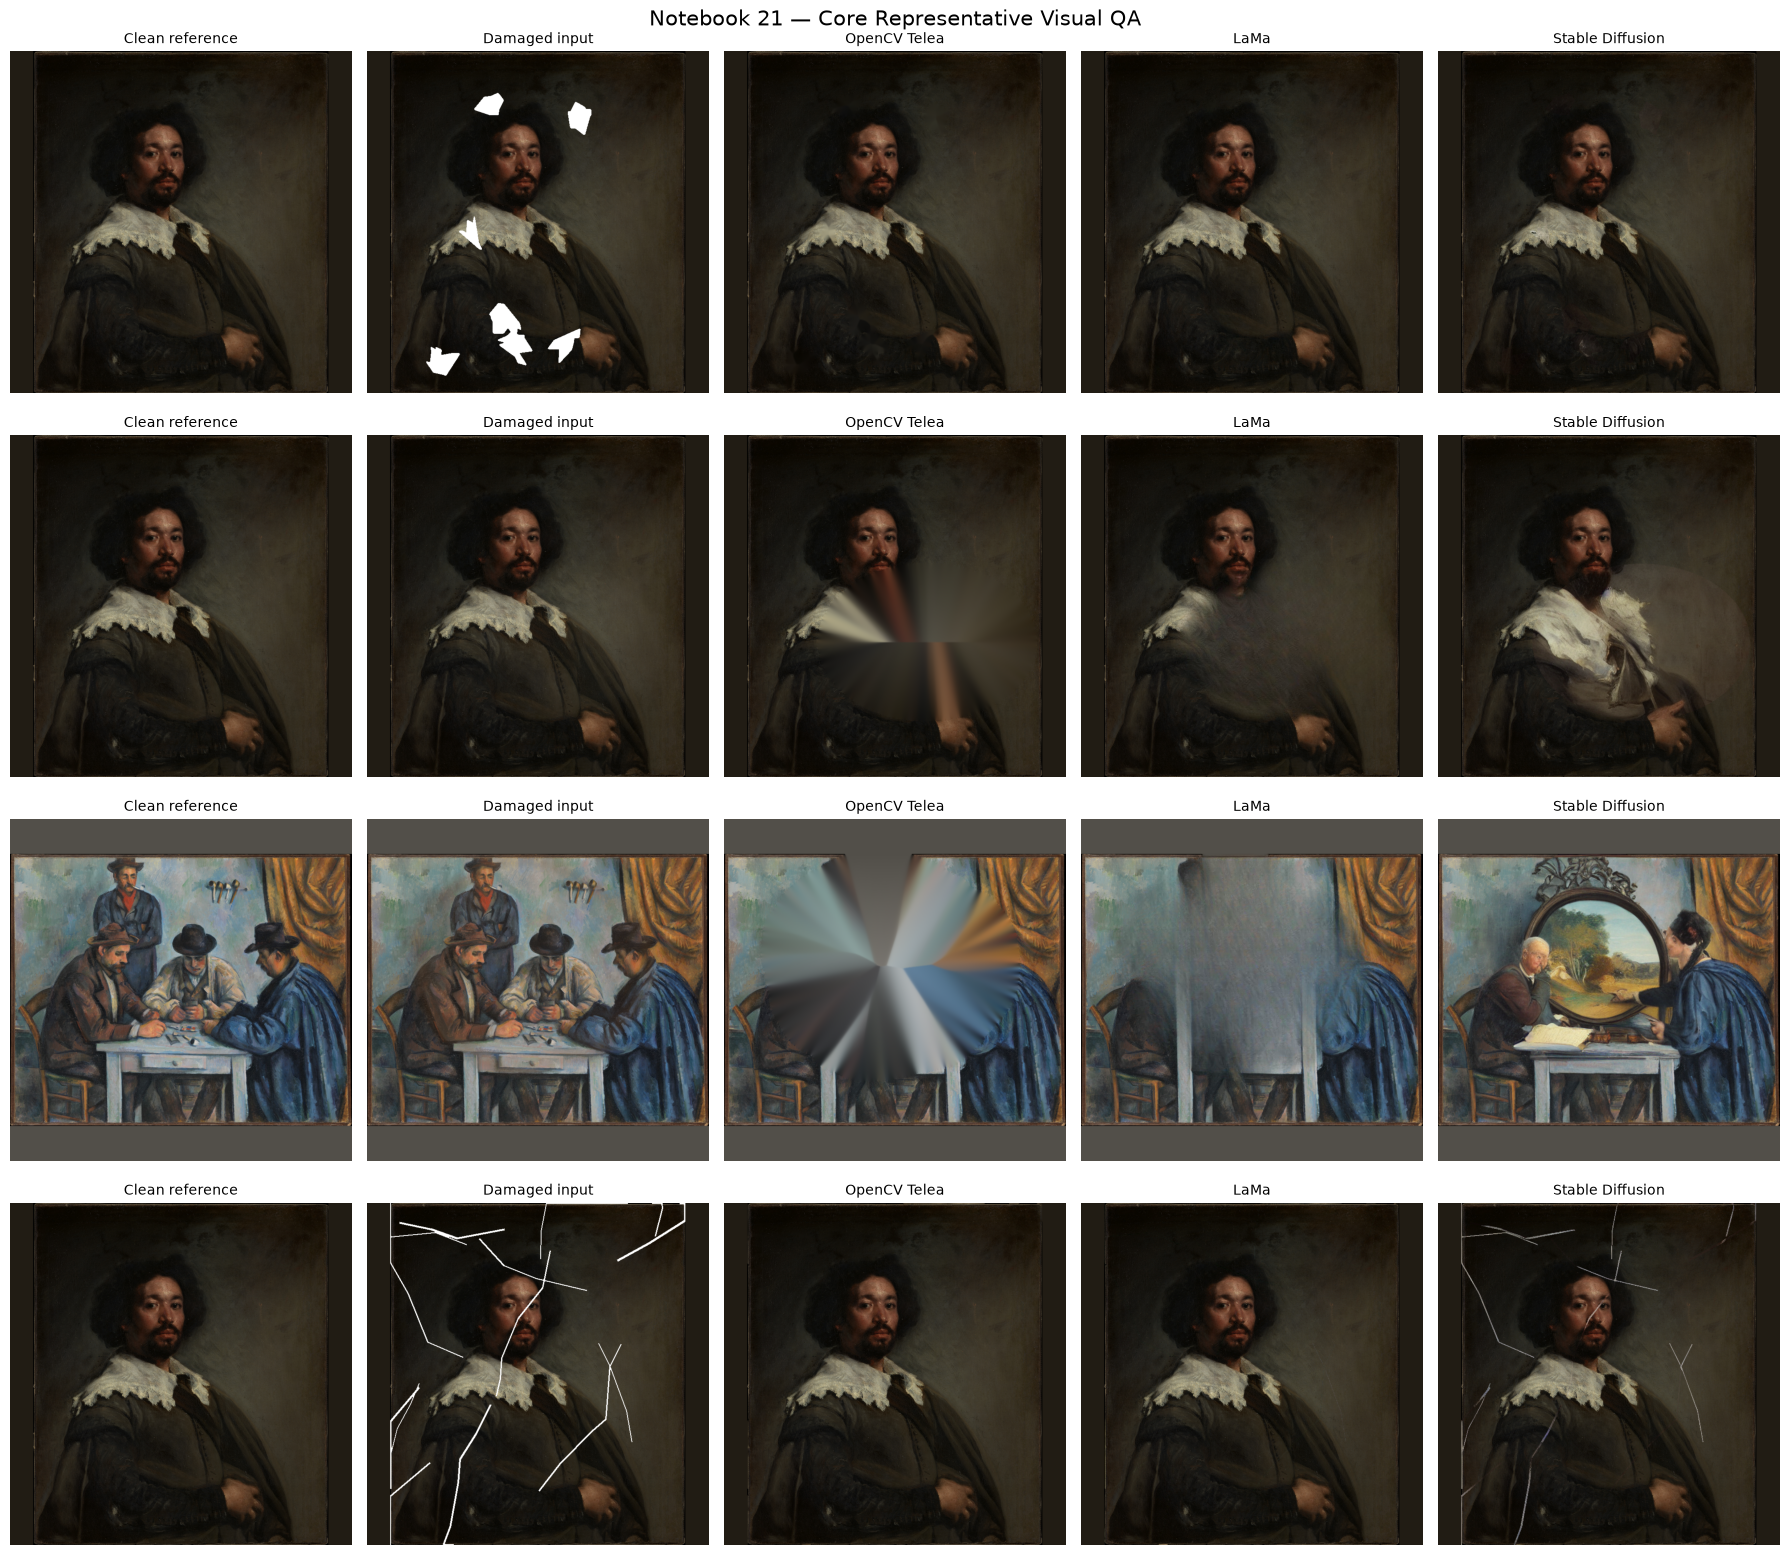

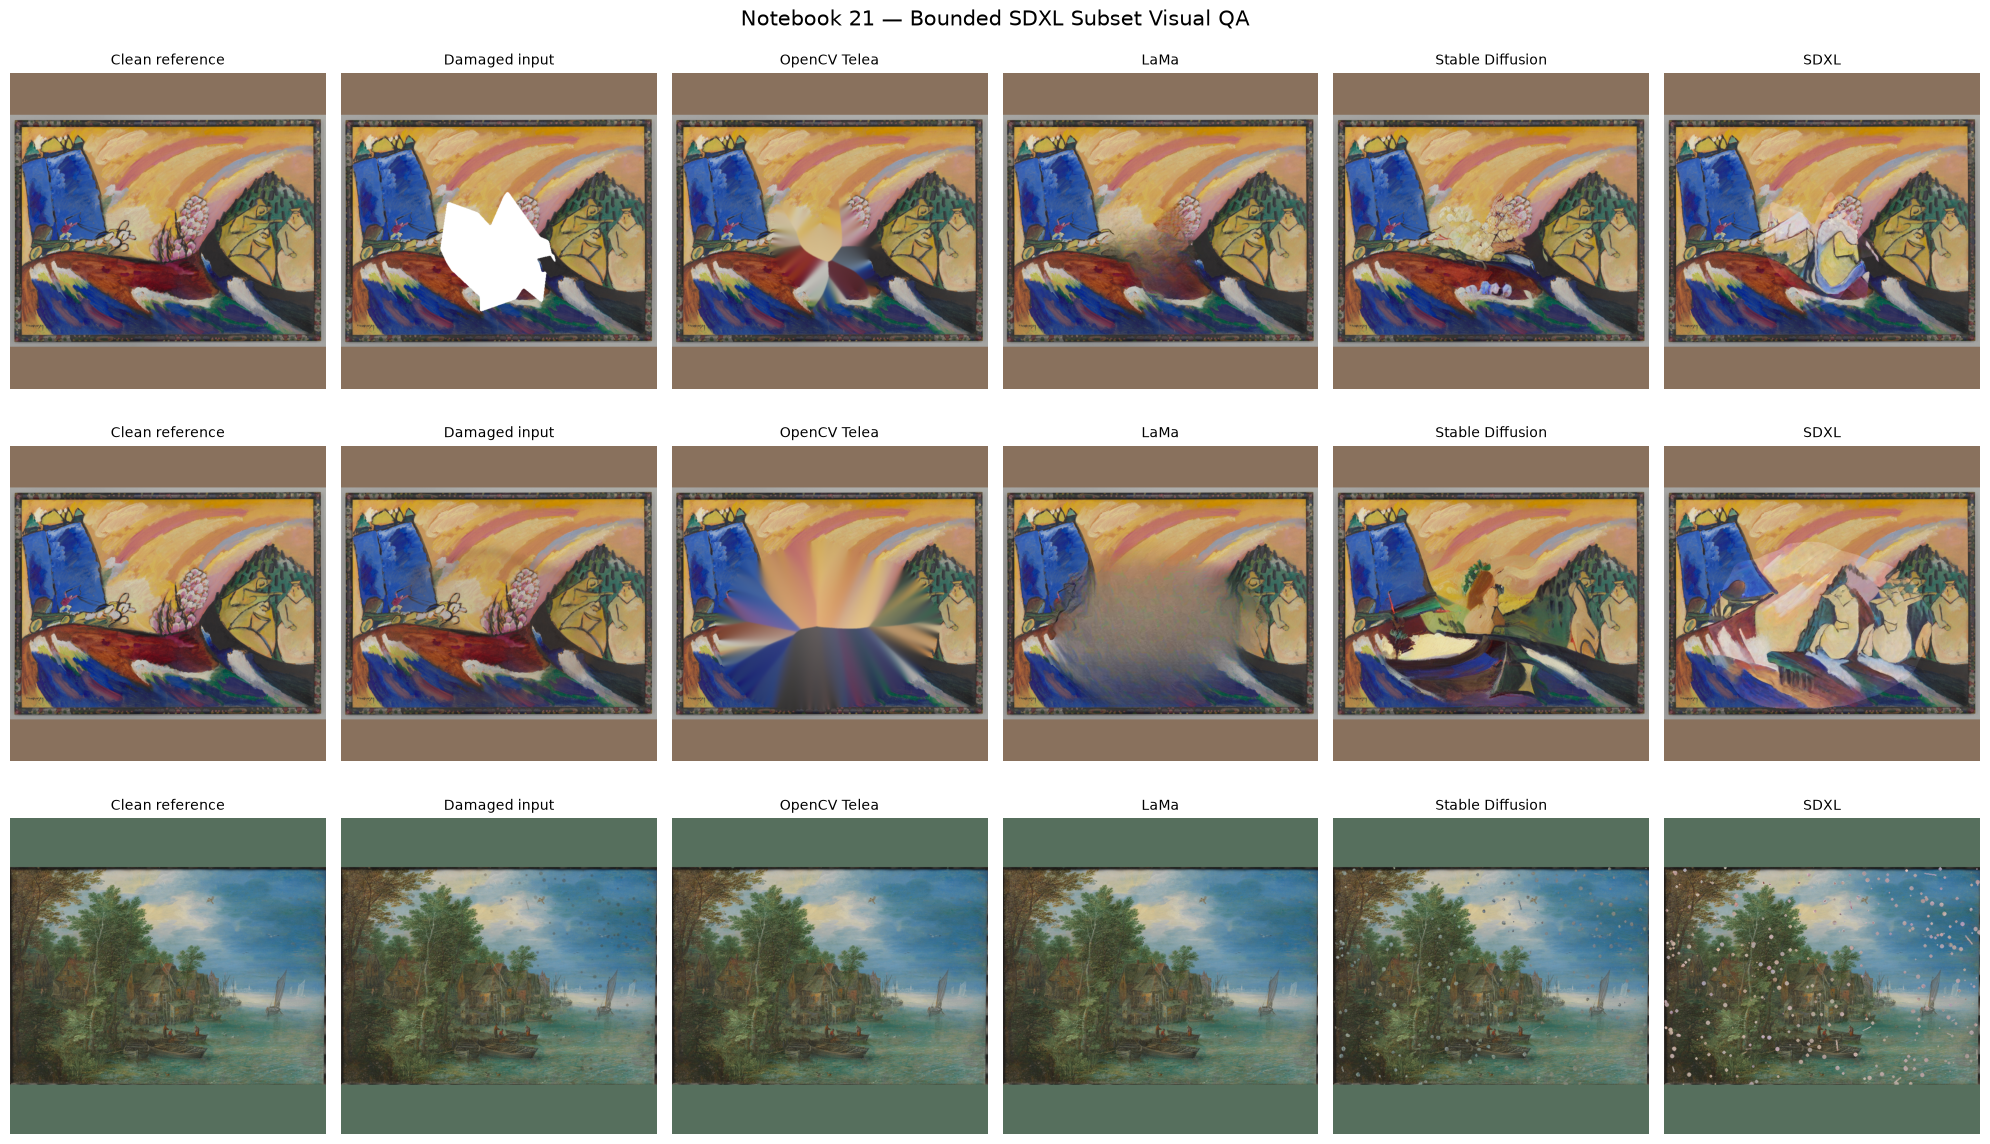

Representative visual QA rendered.
Core QA cases: 4
SDXL QA cases: 3
Figures persisted: No


In [32]:
# ---------------------------------------------------------------------------
# In-notebook visual QA — no files are written
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
from PIL import Image as PILImage

MODEL_DISPLAY_NAMES = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
    "sdxl_inpainting": "SDXL",
}


def load_display_image(
    repo_relative_path,
):
    image_path = (
        PROJECT_ROOT
        / str(repo_relative_path)
    )

    with PILImage.open(
        image_path
    ) as opened:
        return opened.convert("RGB").copy()


CORE_VISUAL_ROLES = [
    "consensus_success",
    "consensus_failure",
    "classical_perceptual_disagreement",
    "scratch_thin_deterministic_advantage",
]

core_visual_slots_df = (
    representative_selection_slots_df.loc[
        representative_selection_slots_df[
            "selection_role"
        ].isin(CORE_VISUAL_ROLES)
    ]
    .sort_values(
        "selection_priority",
        kind="stable",
    )
)

core_figure, core_axes = plt.subplots(
    nrows=len(core_visual_slots_df),
    ncols=5,
    figsize=(
        18,
        4 * len(core_visual_slots_df),
    ),
    squeeze=False,
)

for row_index, slot in enumerate(
    core_visual_slots_df.itertuples(
        index=False
    )
):
    slot_rows = (
        representative_cases_df.loc[
            representative_cases_df[
                "selection_slot_id"
            ].eq(
                slot.selection_slot_id
            )
        ]
        .set_index("model_id")
    )

    first_row = slot_rows.iloc[0]

    panel_items = [
        (
            "Clean reference",
            first_row[
                "clean_image_path"
            ],
        ),
        (
            "Damaged input",
            first_row[
                "input_image_path"
            ],
        ),
    ]

    for model_id in CORE_MODEL_IDS:
        panel_items.append(
            (
                MODEL_DISPLAY_NAMES[
                    model_id
                ],
                slot_rows.loc[
                    model_id,
                    "restored_path",
                ],
            )
        )

    for column_index, (
        panel_title,
        panel_path,
    ) in enumerate(panel_items):
        axis = core_axes[
            row_index,
            column_index,
        ]

        axis.imshow(
            load_display_image(
                panel_path
            )
        )
        axis.set_title(
            panel_title,
            fontsize=10,
        )
        axis.axis("off")

    core_axes[
        row_index,
        0,
    ].set_ylabel(
        (
            f"{slot.selection_role}\n"
            f"{slot.case_id}"
        ),
        fontsize=9,
    )

core_figure.suptitle(
    "Notebook 21 — Core Representative Visual QA",
    fontsize=15,
)

core_figure.tight_layout()
display(core_figure)
plt.close(core_figure)


# ---------------------------------------------------------------------------
# Compact SDXL bounded-subset QA
# ---------------------------------------------------------------------------

sdxl_visual_slots_df = (
    representative_selection_slots_df.loc[
        representative_selection_slots_df[
            "population_id"
        ].eq("sdxl_four_model_subset")
    ]
    .head(3)
)

sdxl_figure, sdxl_axes = plt.subplots(
    nrows=len(sdxl_visual_slots_df),
    ncols=6,
    figsize=(
        20,
        4 * len(sdxl_visual_slots_df),
    ),
    squeeze=False,
)

for row_index, slot in enumerate(
    sdxl_visual_slots_df.itertuples(
        index=False
    )
):
    slot_rows = (
        representative_cases_df.loc[
            representative_cases_df[
                "selection_slot_id"
            ].eq(
                slot.selection_slot_id
            )
        ]
        .set_index("model_id")
    )

    first_row = slot_rows.iloc[0]

    panel_items = [
        (
            "Clean reference",
            first_row[
                "clean_image_path"
            ],
        ),
        (
            "Damaged input",
            first_row[
                "input_image_path"
            ],
        ),
    ]

    for model_id in POPULATIONS[
        "four_model_subset"
    ][
        "models"
    ]:
        panel_items.append(
            (
                MODEL_DISPLAY_NAMES[
                    model_id
                ],
                slot_rows.loc[
                    model_id,
                    "restored_path",
                ],
            )
        )

    for column_index, (
        panel_title,
        panel_path,
    ) in enumerate(panel_items):
        axis = sdxl_axes[
            row_index,
            column_index,
        ]

        axis.imshow(
            load_display_image(
                panel_path
            )
        )
        axis.set_title(
            panel_title,
            fontsize=10,
        )
        axis.axis("off")

    sdxl_axes[
        row_index,
        0,
    ].set_ylabel(
        slot.case_id,
        fontsize=9,
    )

sdxl_figure.suptitle(
    "Notebook 21 — Bounded SDXL Subset Visual QA",
    fontsize=15,
)

sdxl_figure.tight_layout()
display(sdxl_figure)
plt.close(sdxl_figure)

print("Representative visual QA rendered.")
print(
    "Core QA cases:",
    len(core_visual_slots_df),
)
print(
    "SDXL QA cases:",
    len(sdxl_visual_slots_df),
)
print("Figures persisted: No")

In [33]:
# ---------------------------------------------------------------------------
# Batch 6 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_6_representative_selection"
)


def add_representative_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_representative_check(
    "representative_cases_schema",
    (
        "Canonical representative rows satisfy "
        "representative_cases.v1."
    ),
    True,
    representative_cases_schema_result[
        "passed"
    ],
    representative_cases_schema_result[
        "passed"
    ],
    details=representative_cases_schema_result,
)

observed_slot_counts = {
    "core": len(
        core_selection_slots_df
    ),
    "sdxl": len(
        sdxl_selection_slots_df
    ),
    "total": len(
        representative_selection_slots_df
    ),
    "unique_cases": (
        representative_selection_slots_df[
            "case_id"
        ].nunique()
    ),
}

expected_slot_counts = {
    "core": EXPECTED_COUNTS[
        "representative_core_slots"
    ],
    "sdxl": EXPECTED_COUNTS[
        "representative_sdxl_slots"
    ],
    "total": EXPECTED_COUNTS[
        "representative_total_slots"
    ],
    "unique_cases": EXPECTED_COUNTS[
        "representative_unique_cases"
    ],
}

add_representative_check(
    "representative_slot_contract",
    (
        "The representative atlas contains twelve "
        "unique core slots and all ten unique SDXL slots."
    ),
    expected_slot_counts,
    observed_slot_counts,
    observed_slot_counts
    == expected_slot_counts,
)

required_core_roles = set(
    REPRESENTATIVE_POLICY[
        "required_core_roles"
    ]
)

observed_core_roles = set(
    core_selection_slots_df[
        "selection_role"
    ].astype(str)
)

add_representative_check(
    "required_core_roles",
    (
        "Every approved analytical representative role "
        "is present exactly once."
    ),
    required_core_roles,
    observed_core_roles,
    (
        observed_core_roles
        == required_core_roles
        and core_selection_slots_df[
            "selection_role"
        ].is_unique
    ),
)

observed_sdxl_case_ids = set(
    sdxl_selection_slots_df[
        "case_id"
    ].astype(str)
)

add_representative_check(
    "complete_sdxl_case_coverage",
    (
        "Every technically validated case in the bounded "
        "SDXL subset is represented without filtering."
    ),
    sdxl_case_ids,
    observed_sdxl_case_ids,
    observed_sdxl_case_ids
    == sdxl_case_ids,
)

core_sdxl_overlap = (
    set(
        core_selection_slots_df[
            "case_id"
        ].astype(str)
    )
    & observed_sdxl_case_ids
)

add_representative_check(
    "core_sdxl_case_diversity",
    (
        "Core analytical slots do not duplicate the ten "
        "mandatory SDXL cases."
    ),
    set(),
    core_sdxl_overlap,
    not core_sdxl_overlap,
)

observed_representative_rows = {
    "total": len(
        representative_cases_df
    ),
    "core": int(
        representative_cases_df[
            "population_id"
        ].eq(
            "core_three_model"
        ).sum()
    ),
    "sdxl": int(
        representative_cases_df[
            "population_id"
        ].eq(
            "sdxl_four_model_subset"
        ).sum()
    ),
}

expected_representative_rows = {
    "total": EXPECTED_COUNTS[
        "representative_rows"
    ],
    "core": (
        EXPECTED_COUNTS[
            "representative_core_slots"
        ]
        * len(
            POPULATIONS[
                "core_three_model"
            ][
                "models"
            ]
        )
    ),
    "sdxl": (
        EXPECTED_COUNTS[
            "representative_sdxl_slots"
        ]
        * len(
            POPULATIONS[
                "four_model_subset"
            ][
                "models"
            ]
        )
    ),
}

add_representative_check(
    "representative_row_contract",
    (
        "Each representative slot expands to the exact "
        "model population required for that comparison."
    ),
    expected_representative_rows,
    observed_representative_rows,
    observed_representative_rows
    == expected_representative_rows,
)

representative_slot_model_counts = (
    representative_cases_df
    .groupby(
        [
            "selection_slot_id",
            "population_id",
        ],
        sort=True,
    )[
        "model_id"
    ]
    .nunique()
    .reset_index(
        name="observed_model_count"
    )
)

representative_slot_model_counts[
    "expected_model_count"
] = (
    representative_slot_model_counts[
        "population_id"
    ].map(
        {
            "core_three_model": 3,
            "sdxl_four_model_subset": 4,
        }
    )
)

unbalanced_representative_slots_df = (
    representative_slot_model_counts.loc[
        representative_slot_model_counts[
            "observed_model_count"
        ].ne(
            representative_slot_model_counts[
                "expected_model_count"
            ]
        )
    ]
)

add_representative_check(
    "representative_model_balance",
    (
        "Every representative slot contains exactly "
        "the models declared by its population."
    ),
    0,
    len(
        unbalanced_representative_slots_df
    ),
    len(
        unbalanced_representative_slots_df
    ) == 0,
    details=(
        unbalanced_representative_slots_df
        .to_dict("records")
    ),
)

invalid_representative_paths_df = (
    representative_cases_df.loc[
        ~representative_cases_df[
            "path_validation_status"
        ].eq("passed")
        | ~representative_cases_df[
            "status"
        ].eq("ok")
    ]
)

add_representative_check(
    "representative_image_paths",
    (
        "Every selected clean, input, mask/effect, and "
        "restored image path resolves locally."
    ),
    0,
    len(invalid_representative_paths_df),
    len(invalid_representative_paths_df)
    == 0,
    details=(
        invalid_representative_paths_df[
            [
                "selection_slot_id",
                "model_id",
                "issue",
            ]
        ]
        .head(20)
        .to_dict("records")
    ),
)

representative_candidate_audit_df = (
    representative_cases_df.merge(
        selected_candidates_df[
            [
                "case_id",
                "model_id",
                "candidate_id",
            ]
        ],
        on=[
            "case_id",
            "model_id",
        ],
        how="left",
        suffixes=(
            "",
            "__selected",
        ),
        validate="many_to_one",
    )
)

candidate_mismatch_mask = (
    representative_candidate_audit_df[
        "candidate_id"
    ].astype(str)
    .ne(
        representative_candidate_audit_df[
            "candidate_id__selected"
        ].astype(str)
    )
)

add_representative_check(
    "baseline_candidate_integrity",
    (
        "Representative selection reuses the exact "
        "metric-independent baseline candidate for "
        "every case-model pair."
    ),
    0,
    int(candidate_mismatch_mask.sum()),
    not candidate_mismatch_mask.any(),
    details=(
        representative_candidate_audit_df.loc[
            candidate_mismatch_mask,
            [
                "selection_slot_id",
                "case_id",
                "model_id",
                "candidate_id",
                "candidate_id__selected",
            ],
        ]
        .head(20)
        .to_dict("records")
    ),
)

add_representative_check(
    "uncertainty_panel_contract",
    (
        "Four unique complete-seed uncertainty panels "
        "are retained as model-specific context."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "uncertainty_panel_cases"
        ],
        "unique_cases": EXPECTED_COUNTS[
            "uncertainty_panel_cases"
        ],
        "seed_counts": {4},
    },
    {
        "rows": len(
            uncertainty_panel_cases_df
        ),
        "unique_cases": (
            uncertainty_panel_cases_df[
                "case_id"
            ].nunique()
        ),
        "seed_counts": set(
            uncertainty_panel_cases_df[
                "seed_count"
            ].astype(int)
        ),
    },
    (
        len(uncertainty_panel_cases_df)
        == EXPECTED_COUNTS[
            "uncertainty_panel_cases"
        ]
        and uncertainty_panel_cases_df[
            "case_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "uncertainty_panel_cases"
        ]
        and set(
            uncertainty_panel_cases_df[
                "seed_count"
            ].astype(int)
        ) == {4}
    ),
)

add_representative_check(
    "scratch_prompt_panel_contract",
    (
        "Four unique paired generic-versus-scratch-aware "
        "panels retain both complete prompt arms."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "scratch_prompt_panel_cases"
        ],
        "unique_cases": EXPECTED_COUNTS[
            "scratch_prompt_panel_cases"
        ],
        "generic_prompt": {
            "p00_generic"
        },
        "scratch_prompt": {
            "p05_scratch_aware"
        },
    },
    {
        "rows": len(
            scratch_prompt_panel_cases_df
        ),
        "unique_cases": (
            scratch_prompt_panel_cases_df[
                "case_id"
            ].nunique()
        ),
        "generic_prompt": set(
            scratch_prompt_panel_cases_df[
                "generic_prompt_variant_id"
            ].astype(str)
        ),
        "scratch_prompt": set(
            scratch_prompt_panel_cases_df[
                "scratch_prompt_variant_id"
            ].astype(str)
        ),
    },
    (
        len(scratch_prompt_panel_cases_df)
        == EXPECTED_COUNTS[
            "scratch_prompt_panel_cases"
        ]
        and scratch_prompt_panel_cases_df[
            "case_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "scratch_prompt_panel_cases"
        ]
        and set(
            scratch_prompt_panel_cases_df[
                "generic_prompt_variant_id"
            ].astype(str)
        ) == {"p00_generic"}
        and set(
            scratch_prompt_panel_cases_df[
                "scratch_prompt_variant_id"
            ].astype(str)
        ) == {"p05_scratch_aware"}
    ),
)

batch_6_existing_outputs = [
    path
    for path in OUTPUTS.values()
    if path.exists()
]

add_representative_check(
    "no_batch_6_persistence",
    (
        "Batch 6 has not written canonical Notebook 21 "
        "outputs."
    ),
    0,
    len(batch_6_existing_outputs),
    len(batch_6_existing_outputs) == 0,
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in batch_6_existing_outputs
    ],
)

print("Notebook 21 Batch 6 validation assembled.")
print(
    "Batch 6 checks:",
    sum(
        check.validation_stage
        == VALIDATION_STAGE
        for check in VALIDATION.checks
    ),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)

Notebook 21 Batch 6 validation assembled.
Batch 6 checks: 12
Total blocking failures: 0


In [34]:
# ---------------------------------------------------------------------------
# Batch 6 review tables and completion gate
# ---------------------------------------------------------------------------

batch_6_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_6_representative_selection"
        )
    ]
    .reset_index(drop=True)
)

representative_review_columns = [
    "selection_priority",
    "selection_role",
    "population_id",
    "case_id",
    "selection_metric_id",
    "selection_score",
    "selection_reason",
]

display(
    representative_selection_slots_df[
        representative_review_columns
    ]
)

display(
    representative_cases_df[
        [
            "selection_slot_id",
            "selection_role",
            "case_id",
            "model_id",
            "candidate_id",
            "path_validation_status",
            "status",
        ]
    ]
)

display(uncertainty_panel_cases_df)
display(scratch_prompt_panel_cases_df)
display(batch_6_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 21 Batch 6 summary")
print("---------------------------")
print(
    "Core representative slots:",
    len(core_selection_slots_df),
)
print(
    "SDXL representative slots:",
    len(sdxl_selection_slots_df),
)
print(
    "Total representative slots:",
    len(representative_selection_slots_df),
)
print(
    "Unique representative cases:",
    representative_selection_slots_df[
        "case_id"
    ].nunique(),
)
print(
    "Canonical representative rows:",
    len(representative_cases_df),
)
print(
    "Uncertainty context panels:",
    len(uncertainty_panel_cases_df),
)
print(
    "Scratch-prompt context panels:",
    len(scratch_prompt_panel_cases_df),
)
print(
    "Batch 6 validation checks:",
    len(batch_6_validation_df),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)
print("Canonical output files written: No")
print("Batch 6 completion gate passed.")

,selection_priority,selection_role,population_id,case_id,selection_metric_id,selection_score,selection_reason
0,1,consensus_success,core_three_model,canonical__p001__loss_small,directional_anchor_improvement_fraction,1.000000,Highest worst-model fraction of directionally ...
1,2,consensus_failure,core_three_model,synthetic_degradation__p001__partial_transpare...,directional_anchor_improvement_fraction,0.000000,Lowest best-model fraction of directionally im...
2,3,classical_perceptual_disagreement,core_three_model,synthetic_degradation__p043__water_stain__severe,classical_masked_mae|perceptual_crop_lpips,1.591492,Strongest untied disagreement between masked M...
3,4,feature_colour_disagreement,core_three_model,canonical__p033__mixed_damage,feature_similarity|colour,1.480251,Strongest untied disagreement between the feat...
4,5,texture_seam_disagreement,core_three_model,synthetic_degradation__p018__water_stain__mode...,texture_map|seam,1.624030,Strongest untied disagreement between local te...
5,6,semantic_local_fidelity_disagreement,core_three_model,damage_size__p018__loss_large__size_06pct,local_semantic_preservation|structural_layout,1.496729,Strongest untied disagreement between local se...
6,7,high_sd_uncertainty,core_three_model,canonical__p007__loss_large,rgb_std_mean_masked,0.123133,Highest generic-prompt masked RGB standard dev...
7,8,low_uncertainty_consistent_failure,core_three_model,canonical__p022__loss_small,rgb_std_mean_masked,0.023238,Lowest generic-prompt seed variability among c...
8,9,scratch_thin_deterministic_advantage,core_three_model,canonical__p001__scratch_thin,family_balanced_scratch_advantage,10.000000,Largest family-balanced advantage for the two ...
9,10,damage_size_progression,core_three_model,damage_size__p018__loss_large__size_20pct,damage_size_directional_improvement_span,0.000000,Largest damage-size progression change in fami...


,selection_slot_id,selection_role,case_id,model_id,candidate_id,path_validation_status,status
0,slot_01_consensus_success,consensus_success,canonical__p001__loss_small,lama,candidate__lama__canonical__p001__loss_small__c00,passed,ok
1,slot_01_consensus_success,consensus_success,canonical__p001__loss_small,opencv_telea,candidate__opencv_telea__canonical__p001__loss...,passed,ok
2,slot_01_consensus_success,consensus_success,canonical__p001__loss_small,stable_diffusion_inpainting,sd15__p00__s2026__fde0a7a7542f,passed,ok
3,slot_02_consensus_failure,consensus_failure,synthetic_degradation__p001__partial_transpare...,lama,candidate__lama__synthetic_degradation__p001__...,passed,ok
4,slot_02_consensus_failure,consensus_failure,synthetic_degradation__p001__partial_transpare...,opencv_telea,candidate__opencv_telea__synthetic_degradation...,passed,ok
...,...,...,...,...,...,...,...
71,slot_21_sdxl_case_09,sdxl_bounded_case_panel,canonical__p001__loss_large,stable_diffusion_inpainting,sd15__p00__s2026__b4e721b8c5b3,passed,ok
72,slot_22_sdxl_case_10,sdxl_bounded_case_panel,synthetic_degradation__p001__water_stain__severe,lama,candidate__lama__synthetic_degradation__p001__...,passed,ok
73,slot_22_sdxl_case_10,sdxl_bounded_case_panel,synthetic_degradation__p001__water_stain__severe,opencv_telea,candidate__opencv_telea__synthetic_degradation...,passed,ok
74,slot_22_sdxl_case_10,sdxl_bounded_case_panel,synthetic_degradation__p001__water_stain__severe,sdxl_inpainting,sdxl__ab9ddf049dd2__p00_generic__seed2026,passed,ok


,panel_role,case_id,painting_id,category,experiment_id,prompt_variant_id,uncertainty_group_id,seed_count,selection_metric,selection_score,selection_reason
0,highest_generic_seed_variability,canonical__p007__loss_large,p007,portrait_figure,canonical_missing_region,p00_generic,ug_c9b7dd630f4369c17e,4,rgb_std_mean_masked,0.123133,Highest masked RGB seed variability under the ...
1,lowest_generic_seed_variability,canonical__p022__loss_small,p022,architecture_structured,canonical_missing_region,p00_generic,ug_3f9fe9a1b468fb5baa,4,rgb_std_mean_masked,0.023238,Lowest masked RGB seed variability under the g...
2,highest_scratch_aware_seed_variability,canonical__p036__scratch_thin,p036,abstraction_surrealism,canonical_missing_region,p05_scratch_aware,ug_994f03776106411a82,4,rgb_std_mean_masked,0.084900,Highest masked RGB seed variability under the ...
3,lowest_scratch_aware_seed_variability,canonical__p041__scratch_thin,p041,high_texture_brushwork,canonical_missing_region,p05_scratch_aware,ug_c2900644f4004678ac,4,rgb_std_mean_masked,0.035490,Lowest masked RGB seed variability under the s...


,panel_role,case_id,painting_id,category,generic_group_id,scratch_aware_group_id,generic_prompt_variant_id,scratch_prompt_variant_id,selection_metric,selection_score,selection_reason
0,largest_scratch_aware_mae_improvement,canonical__p004__scratch_thin,p004,portrait_figure,ug_5ff795945608bbd825,ug_d78bf5433741367943,p00_generic,p05_scratch_aware,scratch_aware_mae_improvement,4.673711,Largest reduction in mean masked reference MAE...
1,largest_scratch_aware_mae_regression,canonical__p002__scratch_thin,p002,portrait_figure,ug_09ef9501e730b9111d,ug_72e2c41a819e63cd6b,p00_generic,p05_scratch_aware,scratch_aware_mae_improvement,-2.953789,"Largest increase, or smallest reduction, in me..."
2,largest_scratch_aware_seam_improvement,canonical__p008__scratch_thin,p008,portrait_figure,ug_c5d2d51df48e57d5ae,ug_f4eb1dd5245c53a96c,p00_generic,p05_scratch_aware,scratch_aware_seam_improvement,0.002609,Largest reduction in boundary-gradient seam mi...
3,largest_scratch_aware_ssim_improvement,canonical__p039__scratch_thin,p039,abstraction_surrealism,ug_05b4435212558b7035,ug_873b513885c3aa3fe0,p00_generic,p05_scratch_aware,scratch_aware_ssim_improvement,0.001057,Largest increase in crop SSIM for the scratch-...


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_representative_selection,representative_cases_schema,Canonical representative rows satisfy represen...,blocking,True,True,True,"{""passed"": true, ""schema"": {""column_count"": 34..."
1,batch_6_representative_selection,representative_slot_contract,The representative atlas contains twelve uniqu...,blocking,"{""core"": 12, ""sdxl"": 10, ""total"": 22, ""unique_...","{""core"": 12, ""sdxl"": 10, ""total"": 22, ""unique_...",True,
2,batch_6_representative_selection,required_core_roles,Every approved analytical representative role ...,blocking,"""{'damage_size_progression', 'consensus_failur...","""{'damage_size_progression', 'consensus_failur...",True,
3,batch_6_representative_selection,complete_sdxl_case_coverage,Every technically validated case in the bounde...,blocking,"""{'canonical__p018__mixed_damage', 'synthetic_...","""{'canonical__p018__mixed_damage', 'synthetic_...",True,
4,batch_6_representative_selection,core_sdxl_case_diversity,Core analytical slots do not duplicate the ten...,blocking,"""set()""","""set()""",True,
5,batch_6_representative_selection,representative_row_contract,Each representative slot expands to the exact ...,blocking,"{""core"": 36, ""sdxl"": 40, ""total"": 76}","{""core"": 36, ""sdxl"": 40, ""total"": 76}",True,
6,batch_6_representative_selection,representative_model_balance,Every representative slot contains exactly the...,blocking,0,0,True,[]
7,batch_6_representative_selection,representative_image_paths,"Every selected clean, input, mask/effect, and ...",blocking,0,0,True,[]
8,batch_6_representative_selection,baseline_candidate_integrity,Representative selection reuses the exact metr...,blocking,0,0,True,[]
9,batch_6_representative_selection,uncertainty_panel_contract,Four unique complete-seed uncertainty panels a...,blocking,"{""rows"": 4, ""seed_counts"": ""{4}"", ""unique_case...","{""rows"": 4, ""seed_counts"": ""{4}"", ""unique_case...",True,


Notebook 21 Batch 6 summary
---------------------------
Core representative slots: 12
SDXL representative slots: 10
Total representative slots: 22
Unique representative cases: 22
Canonical representative rows: 76
Uncertainty context panels: 4
Scratch-prompt context panels: 4
Batch 6 validation checks: 12
Total blocking failures: 0
Canonical output files written: No
Batch 6 completion gate passed.


## Batch 7 — Canonical Analytical Figures

This batch converts the validated comparison and disagreement evidence into the two canonical Notebook 21 figures:

- `figures/model_comparison.png`
- `figures/metric_disagreement.png`

The figures preserve the separation between:

- the full 410-case, three-model comparison;
- the bounded ten-case comparison that includes SDXL;
- quality evidence and descriptive runtime evidence;
- individual metric outcomes and family-balanced diagnostic voting.

Counts, ranks, and majority outcomes are evidence summaries rather than conservation judgements. No combined quality or trustworthiness score is created.

The saved PNG files are validated and then reloaded for notebook-visible inspection. No canonical CSV, report, manifest, or validation file is persisted in this batch.

In [35]:
# ---------------------------------------------------------------------------
# Plotting dependencies and presentation policy
# ---------------------------------------------------------------------------

import textwrap

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import (
    BoundaryNorm,
    ListedColormap,
)
from matplotlib.patches import Patch


MODEL_COLOURS = {
    "opencv_telea": "#0072B2",
    "lama": "#009E73",
    "stable_diffusion_inpainting": "#D55E00",
    "sdxl_inpainting": "#CC79A7",
}

MODEL_SHORT_NAMES = {
    "opencv_telea": "Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "SD",
    "sdxl_inpainting": "SDXL",
}

POPULATION_DISPLAY_NAMES = {
    "core_three_model": (
        "Core comparison\n410 paired cases"
    ),
    "sdxl_four_model_subset": (
        "Bounded SDXL comparison\n10 paired cases"
    ),
}

STATE_ORDER = [
    "unanimous",
    "partial_consensus",
    "divided",
    "unresolved",
]

STATE_DISPLAY_NAMES = {
    "unanimous": "Unanimous",
    "partial_consensus": "Partial consensus",
    "divided": "Divided",
    "unresolved": "Unresolved",
}

STATE_COLOURS = {
    "unanimous": "#009E73",
    "partial_consensus": "#56B4E9",
    "divided": "#E69F00",
    "unresolved": "#7A7A7A",
}


def winner_display_name(value):
    if pd.isna(value):
        return "Tie / unresolved"

    value = str(value).strip()

    if not value or "|" in value:
        return "Tie / unresolved"

    return MODEL_DISPLAY_NAMES.get(
        value,
        value,
    )


# ---------------------------------------------------------------------------
# Overall family-balanced winner counts
# ---------------------------------------------------------------------------

overall_family_plot_df = (
    overall_family_consensus_df.copy()
)

overall_family_plot_df[
    "winner_display"
] = (
    overall_family_plot_df[
        "family_consensus_winner_model_id"
    ].map(winner_display_name)
)

overall_family_count_df = (
    overall_family_plot_df
    .groupby(
        [
            "population_id",
            "winner_display",
        ],
        sort=True,
        dropna=False,
    )
    .size()
    .rename("family_count")
    .reset_index()
)


# ---------------------------------------------------------------------------
# Overall anchor leave-one-painting-out stability
# ---------------------------------------------------------------------------

anchor_order = (
    overall_anchor_outcomes_df.loc[
        overall_anchor_outcomes_df[
            "population_id"
        ].eq("core_three_model"),
        "anchor_id",
    ]
    .drop_duplicates()
    .astype(str)
    .tolist()
)

anchor_display_names = {
    anchor_id: textwrap.fill(
        anchor_id.replace("_", " "),
        width=25,
    )
    for anchor_id in anchor_order
}

loo_anchor_plot_df = (
    overall_anchor_outcomes_df[
        [
            "population_id",
            "anchor_id",
            "loo_winner_stability_fraction",
        ]
    ]
    .copy()
)

loo_anchor_plot_df[
    "loo_winner_stability_fraction"
] = pd.to_numeric(
    loo_anchor_plot_df[
        "loo_winner_stability_fraction"
    ],
    errors="coerce",
)


# ---------------------------------------------------------------------------
# Descriptive runtime evidence
# ---------------------------------------------------------------------------

runtime_plot_df = (
    runtime_comparison_df.loc[
        runtime_comparison_df[
            "analysis_scope"
        ].eq("overall"),
        [
            "population_id",
            "model_id",
            "paired_case_count",
            "restored_median",
            "value_unit",
        ],
    ]
    .copy()
)

runtime_plot_df[
    "runtime_median"
] = pd.to_numeric(
    runtime_plot_df[
        "restored_median"
    ],
    errors="coerce",
)

runtime_population_order = {
    "core_three_model": 0,
    "sdxl_four_model_subset": 1,
}

runtime_model_order = {
    "opencv_telea": 0,
    "lama": 1,
    "stable_diffusion_inpainting": 2,
    "sdxl_inpainting": 3,
}

runtime_plot_df[
    "population_order"
] = runtime_plot_df[
    "population_id"
].map(runtime_population_order)

runtime_plot_df[
    "model_order"
] = runtime_plot_df[
    "model_id"
].map(runtime_model_order)

runtime_plot_df = (
    runtime_plot_df
    .sort_values(
        [
            "population_order",
            "model_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Cross-family agreement states
# ---------------------------------------------------------------------------

state_count_df = (
    independent_majority_audit_df
    .groupby(
        [
            "population_id",
            "cross_family_state",
        ],
        sort=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=STATE_ORDER,
        fill_value=0,
    )
)

state_fraction_df = (
    state_count_df.div(
        state_count_df.sum(axis=1),
        axis=0,
    )
)

preferred_scope_order = [
    "overall",
    "experiment",
    "category",
    "style_or_period",
    "damage_type",
    "degradation_type",
    "severity",
    "target_damage_fraction",
    "zero_control",
]

available_core_scopes = set(
    independent_majority_audit_df.loc[
        independent_majority_audit_df[
            "population_id"
        ].eq("core_three_model"),
        "analysis_scope",
    ].astype(str)
)

core_scope_order = [
    scope
    for scope in preferred_scope_order
    if scope in available_core_scopes
]

core_scope_state_count_df = (
    independent_majority_audit_df.loc[
        independent_majority_audit_df[
            "population_id"
        ].eq("core_three_model")
    ]
    .groupby(
        [
            "analysis_scope",
            "cross_family_state",
        ],
        sort=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=core_scope_order,
        columns=STATE_ORDER,
        fill_value=0,
    )
)

core_scope_state_fraction_df = (
    core_scope_state_count_df.div(
        core_scope_state_count_df.sum(axis=1),
        axis=0,
    )
)


# ---------------------------------------------------------------------------
# Anchor-versus-majority disagreement heatmap
# ---------------------------------------------------------------------------

core_disagreement_plot_df = (
    disagreement_analysis_df.loc[
        disagreement_analysis_df[
            "population_id"
        ].eq("core_three_model")
    ]
    .copy()
)

core_disagreement_plot_df[
    "disagreement_numeric"
] = core_disagreement_plot_df[
    "disagrees_with_majority"
].astype(float)

core_disagreement_heatmap_df = (
    core_disagreement_plot_df
    .groupby(
        [
            "analysis_scope",
            "evidence_family",
        ],
        sort=True,
    )[
        "disagreement_numeric"
    ]
    .mean()
    .unstack()
    .reindex(core_scope_order)
)

family_order = (
    core_disagreement_heatmap_df
    .columns.astype(str)
    .tolist()
)


# ---------------------------------------------------------------------------
# Overall anchor-winner matrix
# ---------------------------------------------------------------------------

overall_anchor_winner_matrix_df = (
    overall_anchor_outcomes_df
    .pivot(
        index="anchor_id",
        columns="population_id",
        values="winner_model_id",
    )
    .reindex(
        index=anchor_order,
        columns=[
            "core_three_model",
            "sdxl_four_model_subset",
        ],
    )
)

if len(anchor_order) != EXPECTED_COUNTS[
    "metric_disagreement_anchors"
]:
    raise ValueError(
        "Unexpected overall anchor count before plotting: "
        f"{len(anchor_order)}"
    )

if (
    loo_anchor_plot_df[
        "loo_winner_stability_fraction"
    ].isna().any()
    or not loo_anchor_plot_df[
        "loo_winner_stability_fraction"
    ].between(0.0, 1.0).all()
):
    raise ValueError(
        "LOO stability values are missing or outside [0, 1]."
    )

if (
    runtime_plot_df["runtime_median"].isna().any()
    or runtime_plot_df["runtime_median"].le(0).any()
):
    raise ValueError(
        "Runtime plotting values must be finite and positive."
    )

print("Batch 7 plotting evidence prepared.")
print(
    "Overall family rows:",
    len(overall_family_plot_df),
)
print("Overall anchors:", len(anchor_order))
print("Runtime rows:", len(runtime_plot_df))
print(
    "Cross-family scope groups:",
    int(state_count_df.to_numpy().sum()),
)
print(
    "Core conditional scopes:",
    core_scope_order,
)
print("Canonical figures written: No")

Batch 7 plotting evidence prepared.
Overall family rows: 20
Overall anchors: 11
Runtime rows: 7
Cross-family scope groups: 79
Core conditional scopes: ['overall', 'experiment', 'category', 'style_or_period', 'damage_type', 'degradation_type', 'severity', 'target_damage_fraction', 'zero_control']
Canonical figures written: No


In [36]:
# ---------------------------------------------------------------------------
# Canonical Figure 1 — Model comparison
# ---------------------------------------------------------------------------

model_figure, model_axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 12),
)

model_figure.patch.set_facecolor("white")

population_panels = [
    (
        "core_three_model",
        model_axes[0, 0],
        [
            "OpenCV Telea",
            "LaMa",
            "Stable Diffusion",
            "Tie / unresolved",
        ],
        "A",
    ),
    (
        "sdxl_four_model_subset",
        model_axes[0, 1],
        [
            "OpenCV Telea",
            "LaMa",
            "Stable Diffusion",
            "SDXL",
            "Tie / unresolved",
        ],
        "B",
    ),
]

display_colour_lookup = {
    "OpenCV Telea": MODEL_COLOURS[
        "opencv_telea"
    ],
    "LaMa": MODEL_COLOURS["lama"],
    "Stable Diffusion": MODEL_COLOURS[
        "stable_diffusion_inpainting"
    ],
    "SDXL": MODEL_COLOURS[
        "sdxl_inpainting"
    ],
    "Tie / unresolved": "#7A7A7A",
}

for (
    population_id,
    axis,
    winner_order,
    panel_label,
) in population_panels:
    population_counts = (
        overall_family_count_df.loc[
            overall_family_count_df[
                "population_id"
            ].eq(population_id)
        ]
        .set_index("winner_display")[
            "family_count"
        ]
        .reindex(
            winner_order,
            fill_value=0,
        )
    )

    bars = axis.barh(
        winner_order,
        population_counts.to_numpy(),
        color=[
            display_colour_lookup[label]
            for label in winner_order
        ],
        edgecolor="white",
    )

    axis.invert_yaxis()
    axis.set_xlabel(
        "Number of evidence families"
    )
    axis.set_xlim(
        0,
        max(
            EXPECTED_COUNTS[
                "metric_disagreement_families"
            ],
            int(population_counts.max()) + 1,
        ),
    )
    axis.xaxis.set_major_locator(
        mticker.MaxNLocator(integer=True)
    )
    axis.grid(
        axis="x",
        alpha=0.25,
        linewidth=0.8,
    )
    axis.set_axisbelow(True)

    axis.set_title(
        (
            f"{panel_label}. Overall family-consensus "
            f"outcomes\n"
            f"{POPULATION_DISPLAY_NAMES[population_id]}"
        ),
        loc="left",
        fontsize=12,
        fontweight="bold",
    )

    for bar, count in zip(
        bars,
        population_counts.to_numpy(),
    ):
        axis.text(
            bar.get_width() + 0.12,
            bar.get_y() + bar.get_height() / 2,
            str(int(count)),
            va="center",
            fontsize=9,
        )


# ---------------------------------------------------------------------------
# Panel C — Anchor-level LOO winner stability
# ---------------------------------------------------------------------------

loo_axis = model_axes[1, 0]

anchor_y = np.arange(len(anchor_order))

loo_population_styles = [
    (
        "core_three_model",
        -0.12,
        "o",
        "#0072B2",
        "Core: 410 cases / 50 paintings",
    ),
    (
        "sdxl_four_model_subset",
        0.12,
        "s",
        "#CC79A7",
        "Bounded SDXL subset: 10 cases / 5 paintings",
    ),
]

for (
    population_id,
    offset,
    marker,
    colour,
    label,
) in loo_population_styles:
    population_loo = (
        loo_anchor_plot_df.loc[
            loo_anchor_plot_df[
                "population_id"
            ].eq(population_id)
        ]
        .set_index("anchor_id")
        .reindex(anchor_order)
    )

    loo_axis.scatter(
        population_loo[
            "loo_winner_stability_fraction"
        ].to_numpy(),
        anchor_y + offset,
        marker=marker,
        s=55,
        color=colour,
        edgecolor="white",
        linewidth=0.7,
        label=label,
        zorder=3,
    )

loo_axis.set_yticks(anchor_y)
loo_axis.set_yticklabels(
    [
        anchor_display_names[anchor_id]
        for anchor_id in anchor_order
    ],
    fontsize=8,
)
loo_axis.invert_yaxis()
loo_axis.set_xlim(-0.02, 1.02)
loo_axis.xaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)
loo_axis.set_xlabel(
    "Winner retained after leaving out one painting"
)
loo_axis.grid(
    axis="x",
    alpha=0.25,
    linewidth=0.8,
)
loo_axis.set_axisbelow(True)
loo_axis.legend(
    loc="lower right",
    fontsize=8,
    frameon=True,
)
loo_axis.set_title(
    (
        "C. Anchor-level ranking stability\n"
        "Each point is one predeclared anchor"
    ),
    loc="left",
    fontsize=12,
    fontweight="bold",
)


# ---------------------------------------------------------------------------
# Panel D — Runtime evidence
# ---------------------------------------------------------------------------

runtime_axis = model_axes[1, 1]

runtime_positions = np.arange(
    len(runtime_plot_df)
)

runtime_colours = [
    MODEL_COLOURS[str(model_id)]
    for model_id in runtime_plot_df[
        "model_id"
    ]
]

runtime_labels = [
    (
        "Core"
        if population_id
        == "core_three_model"
        else "SDXL-10"
    )
    + "\n"
    + MODEL_SHORT_NAMES[str(model_id)]
    for population_id, model_id
    in runtime_plot_df[
        [
            "population_id",
            "model_id",
        ]
    ].itertuples(
        index=False,
        name=None,
    )
]

runtime_bars = runtime_axis.bar(
    runtime_positions,
    runtime_plot_df[
        "runtime_median"
    ].to_numpy(),
    color=runtime_colours,
    edgecolor="white",
)

runtime_axis.set_xticks(runtime_positions)
runtime_axis.set_xticklabels(
    runtime_labels,
    fontsize=8,
)
runtime_axis.set_yscale("log")
runtime_axis.set_ylabel(
    "Median recorded runtime per candidate\n"
    "(seconds; logarithmic scale)"
)
runtime_axis.grid(
    axis="y",
    alpha=0.25,
    linewidth=0.8,
    which="both",
)
runtime_axis.set_axisbelow(True)
runtime_axis.set_title(
    (
        "D. Runtime is descriptive, not a quality vote\n"
        "Population-specific medians are not pooled"
    ),
    loc="left",
    fontsize=12,
    fontweight="bold",
)

for bar, row in zip(
    runtime_bars,
    runtime_plot_df.itertuples(index=False),
):
    runtime_axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.08,
        (
            f"{row.runtime_median:.2g}s\n"
            f"n={int(row.paired_case_count)}"
        ),
        ha="center",
        va="bottom",
        fontsize=7,
    )


model_figure.suptitle(
    (
        "Notebook 21 — Multi-Model Comparison\n"
        "Family-balanced outcomes, ranking stability, "
        "and descriptive runtime"
    ),
    fontsize=16,
    fontweight="bold",
    y=0.985,
)

model_figure.text(
    0.5,
    0.012,
    (
        "Family counts summarize evidence-defined "
        "computational outcomes, not historical "
        "authenticity or conservation approval. "
        "The SDXL population is a bounded ten-case "
        "technical subset and must not be generalized "
        "to the full dataset."
    ),
    ha="center",
    va="bottom",
    fontsize=9,
)

model_figure.tight_layout(
    rect=(0.02, 0.05, 0.98, 0.95)
)

model_figure.savefig(
    OUTPUTS["model_comparison_figure"],
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.close(model_figure)

print("Canonical model-comparison figure written.")
print(
    "Path:",
    to_repo_relative(
        OUTPUTS["model_comparison_figure"],
        PROJECT_ROOT,
    ),
)

Canonical model-comparison figure written.
Path: outputs/21_multi_model_comparison/figures/model_comparison.png


In [37]:
# ---------------------------------------------------------------------------
# Canonical Figure 2 — Metric disagreement
# ---------------------------------------------------------------------------

disagreement_figure, disagreement_axes = (
    plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(17, 13),
    )
)

disagreement_figure.patch.set_facecolor(
    "white"
)


# ---------------------------------------------------------------------------
# Panel A — Agreement states by population
# ---------------------------------------------------------------------------

state_axis = disagreement_axes[0, 0]

state_bottom = np.zeros(
    len(state_fraction_df),
    dtype=float,
)

population_ids = (
    state_fraction_df.index.astype(str).tolist()
)

population_x = np.arange(
    len(population_ids)
)

for state in STATE_ORDER:
    values = state_fraction_df[
        state
    ].to_numpy(dtype=float)

    state_axis.bar(
        population_x,
        values,
        bottom=state_bottom,
        color=STATE_COLOURS[state],
        edgecolor="white",
        label=STATE_DISPLAY_NAMES[state],
    )

    for position, value, bottom in zip(
        population_x,
        values,
        state_bottom,
    ):
        if value >= 0.08:
            state_axis.text(
                position,
                bottom + value / 2,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if state in {
                        "divided",
                        "unresolved",
                    }
                    else "black"
                ),
            )

    state_bottom += values

state_axis.set_xticks(population_x)
state_axis.set_xticklabels(
    [
        POPULATION_DISPLAY_NAMES[
            population_id
        ]
        for population_id in population_ids
    ],
    fontsize=9,
)
state_axis.set_ylim(0.0, 1.0)
state_axis.yaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)
state_axis.set_ylabel(
    "Fraction of comparison scope groups"
)
state_axis.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    fontsize=8,
)
state_axis.set_title(
    (
        "A. Cross-family agreement states\n"
        "One vote per evidence family"
    ),
    loc="left",
    fontsize=12,
    fontweight="bold",
)


# ---------------------------------------------------------------------------
# Panel B — Core agreement states by analysis scope
# ---------------------------------------------------------------------------

scope_axis = disagreement_axes[0, 1]

scope_y = np.arange(
    len(core_scope_state_fraction_df)
)

scope_left = np.zeros(
    len(core_scope_state_fraction_df),
    dtype=float,
)

for state in STATE_ORDER:
    values = core_scope_state_fraction_df[
        state
    ].to_numpy(dtype=float)

    scope_axis.barh(
        scope_y,
        values,
        left=scope_left,
        color=STATE_COLOURS[state],
        edgecolor="white",
        label=STATE_DISPLAY_NAMES[state],
    )

    scope_left += values

scope_axis.set_yticks(scope_y)
scope_axis.set_yticklabels(
    [
        scope.replace("_", " ")
        for scope in core_scope_state_fraction_df.index
    ],
    fontsize=8,
)
scope_axis.invert_yaxis()
scope_axis.set_xlim(0.0, 1.0)
scope_axis.xaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)
scope_axis.set_xlabel(
    "Fraction of scope values"
)
scope_axis.grid(
    axis="x",
    alpha=0.2,
    linewidth=0.8,
)
scope_axis.set_axisbelow(True)
scope_axis.set_title(
    (
        "B. Core comparison by analysis scope\n"
        "Divided evidence is retained, not averaged away"
    ),
    loc="left",
    fontsize=12,
    fontweight="bold",
)


# ---------------------------------------------------------------------------
# Panel C — Anchor disagreement with family-balanced majority
# ---------------------------------------------------------------------------

heatmap_axis = disagreement_axes[1, 0]

heatmap_values = (
    core_disagreement_heatmap_df
    .to_numpy(dtype=float)
)

heatmap_image = heatmap_axis.imshow(
    heatmap_values,
    cmap="cividis",
    vmin=0.0,
    vmax=1.0,
    aspect="auto",
)

heatmap_axis.set_xticks(
    np.arange(len(family_order))
)
heatmap_axis.set_xticklabels(
    [
        textwrap.fill(
            family.replace("_", " "),
            width=14,
        )
        for family in family_order
    ],
    rotation=40,
    ha="right",
    fontsize=7,
)

heatmap_axis.set_yticks(
    np.arange(len(core_scope_order))
)
heatmap_axis.set_yticklabels(
    [
        scope.replace("_", " ")
        for scope in core_scope_order
    ],
    fontsize=8,
)

for row_index in range(
    heatmap_values.shape[0]
):
    for column_index in range(
        heatmap_values.shape[1]
    ):
        value = heatmap_values[
            row_index,
            column_index,
        ]

        if np.isfinite(value):
            heatmap_axis.text(
                column_index,
                row_index,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=6,
                color=(
                    "white"
                    if value >= 0.58
                    else "black"
                ),
            )

heatmap_colourbar = (
    disagreement_figure.colorbar(
        heatmap_image,
        ax=heatmap_axis,
        fraction=0.046,
        pad=0.04,
    )
)

heatmap_colourbar.set_label(
    "Anchor rows disagreeing with majority vote"
)
heatmap_colourbar.ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)

heatmap_axis.set_title(
    (
        "C. Core anchor-versus-majority disagreement\n"
        "Fractions are calculated within scope and family"
    ),
    loc="left",
    fontsize=12,
    fontweight="bold",
)


# ---------------------------------------------------------------------------
# Panel D — Overall anchor winners across populations
# ---------------------------------------------------------------------------

winner_axis = disagreement_axes[1, 1]

winner_categories = [
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
    "tie",
    "unresolved",
]

winner_colours = [
    MODEL_COLOURS["opencv_telea"],
    MODEL_COLOURS["lama"],
    MODEL_COLOURS[
        "stable_diffusion_inpainting"
    ],
    MODEL_COLOURS["sdxl_inpainting"],
    "#7A7A7A",
    "#D9D9D9",
]

winner_codes = {
    category: index
    for index, category
    in enumerate(winner_categories)
}

winner_annotations = {
    "opencv_telea": "Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "SD",
    "sdxl_inpainting": "SDXL",
    "tie": "Tie",
    "unresolved": "N/A",
}

winner_matrix = np.full(
    overall_anchor_winner_matrix_df.shape,
    winner_codes["unresolved"],
    dtype=float,
)

winner_text_matrix = np.full(
    overall_anchor_winner_matrix_df.shape,
    "N/A",
    dtype=object,
)

for row_index, anchor_id in enumerate(
    overall_anchor_winner_matrix_df.index
):
    for column_index, population_id in enumerate(
        overall_anchor_winner_matrix_df.columns
    ):
        winner_value = (
            overall_anchor_winner_matrix_df.loc[
                anchor_id,
                population_id,
            ]
        )

        if pd.isna(winner_value):
            winner_key = "unresolved"
        else:
            winner_value = str(
                winner_value
            ).strip()

            if not winner_value:
                winner_key = "unresolved"
            elif "|" in winner_value:
                winner_key = "tie"
            else:
                winner_key = winner_value

        if winner_key not in winner_codes:
            raise ValueError(
                "Unexpected overall winner identity: "
                f"{winner_key}"
            )

        winner_matrix[
            row_index,
            column_index,
        ] = winner_codes[winner_key]

        winner_text_matrix[
            row_index,
            column_index,
        ] = winner_annotations[
            winner_key
        ]

winner_cmap = ListedColormap(
    winner_colours
)

winner_norm = BoundaryNorm(
    np.arange(
        len(winner_categories) + 1
    ) - 0.5,
    winner_cmap.N,
)

winner_axis.imshow(
    winner_matrix,
    cmap=winner_cmap,
    norm=winner_norm,
    aspect="auto",
)

winner_axis.set_xticks(
    np.arange(
        len(
            overall_anchor_winner_matrix_df.columns
        )
    )
)

winner_axis.set_xticklabels(
    [
        "Core\n410 cases",
        "SDXL subset\n10 cases",
    ],
    fontsize=9,
)

winner_axis.set_yticks(
    np.arange(len(anchor_order))
)

winner_axis.set_yticklabels(
    [
        anchor_display_names[anchor_id]
        for anchor_id in anchor_order
    ],
    fontsize=8,
)

for row_index in range(
    winner_text_matrix.shape[0]
):
    for column_index in range(
        winner_text_matrix.shape[1]
    ):
        winner_axis.text(
            column_index,
            row_index,
            winner_text_matrix[
                row_index,
                column_index,
            ],
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
        )

winner_legend_handles = [
    Patch(
        facecolor=winner_colours[
            winner_codes[category]
        ],
        label=winner_annotations[category],
    )
    for category in winner_categories
]

winner_axis.legend(
    handles=winner_legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    fontsize=7,
)

winner_axis.set_title(
    (
        "D. Overall direction-aware anchor winners\n"
        "Columns represent different evidence populations"
    ),
    loc="left",
    fontsize=12,
    fontweight="bold",
)


disagreement_figure.suptitle(
    (
        "Notebook 21 — Metric and Evidence-Family "
        "Disagreement\n"
        "Agreement is summarized without constructing "
        "a combined quality score"
    ),
    fontsize=16,
    fontweight="bold",
    y=0.985,
)

disagreement_figure.text(
    0.5,
    0.012,
    (
        "Majority voting is a compact diagnostic only. "
        "It does not establish conservation truth, "
        "historical plausibility, or a universally "
        "preferred restoration method. The SDXL column "
        "uses only its bounded ten-case subset."
    ),
    ha="center",
    va="bottom",
    fontsize=9,
)

disagreement_figure.tight_layout(
    rect=(0.02, 0.055, 0.98, 0.95)
)

disagreement_figure.savefig(
    OUTPUTS[
        "metric_disagreement_figure"
    ],
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.close(disagreement_figure)

print("Canonical metric-disagreement figure written.")
print(
    "Path:",
    to_repo_relative(
        OUTPUTS[
            "metric_disagreement_figure"
        ],
        PROJECT_ROOT,
    ),
)

Canonical metric-disagreement figure written.
Path: outputs/21_multi_model_comparison/figures/metric_disagreement.png


,figure_key,relative_path,exists,format,mode,width,height,size_bytes,pixel_std,sha256,passed
0,model_comparison_figure,outputs/21_multi_model_comparison/figures/mode...,True,PNG,RGBA,3042,2375,372177,45.215103,fdc84f77c2a8d5a06e38ab23e1366b92025467f47345a8...,True
1,metric_disagreement_figure,outputs/21_multi_model_comparison/figures/metr...,True,PNG,RGBA,3237,2569,515607,86.019569,218386bd56dbd717953c41e0cc3d7188dbbf64efd08c04...,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_canonical_figures,canonical_figure_files,"Both canonical analytical figures exist, are n...",blocking,"{""figure_count"": 2, ""minimum_height"": 1800, ""m...","[{""figure_key"": ""model_comparison_figure"", ""fo...",True,
1,batch_7_canonical_figures,canonical_figure_directory_contents,The figures directory contains exactly the two...,blocking,"[""outputs/21_multi_model_comparison/figures/me...","[""outputs/21_multi_model_comparison/figures/me...",True,
2,batch_7_canonical_figures,figure_evidence_contract,"Figure inputs retain the complete family, anch...",blocking,"{""anchors_per_population"": 11, ""families_per_p...","{""anchor_counts_by_population"": {""core_three_m...",True,
3,batch_7_canonical_figures,figure_population_separation,Every figure source retains distinct core and ...,blocking,"""{'sdxl_four_model_subset', 'core_three_model'}""","""{'sdxl_four_model_subset', 'core_three_model'}""",True,
4,batch_7_canonical_figures,batch_7_output_scope,Only the two canonical figures have been persi...,blocking,"""{'metric_disagreement_figure', 'model_compari...","""{'metric_disagreement_figure', 'model_compari...",True,


Rendered persisted preview: model_comparison_figure


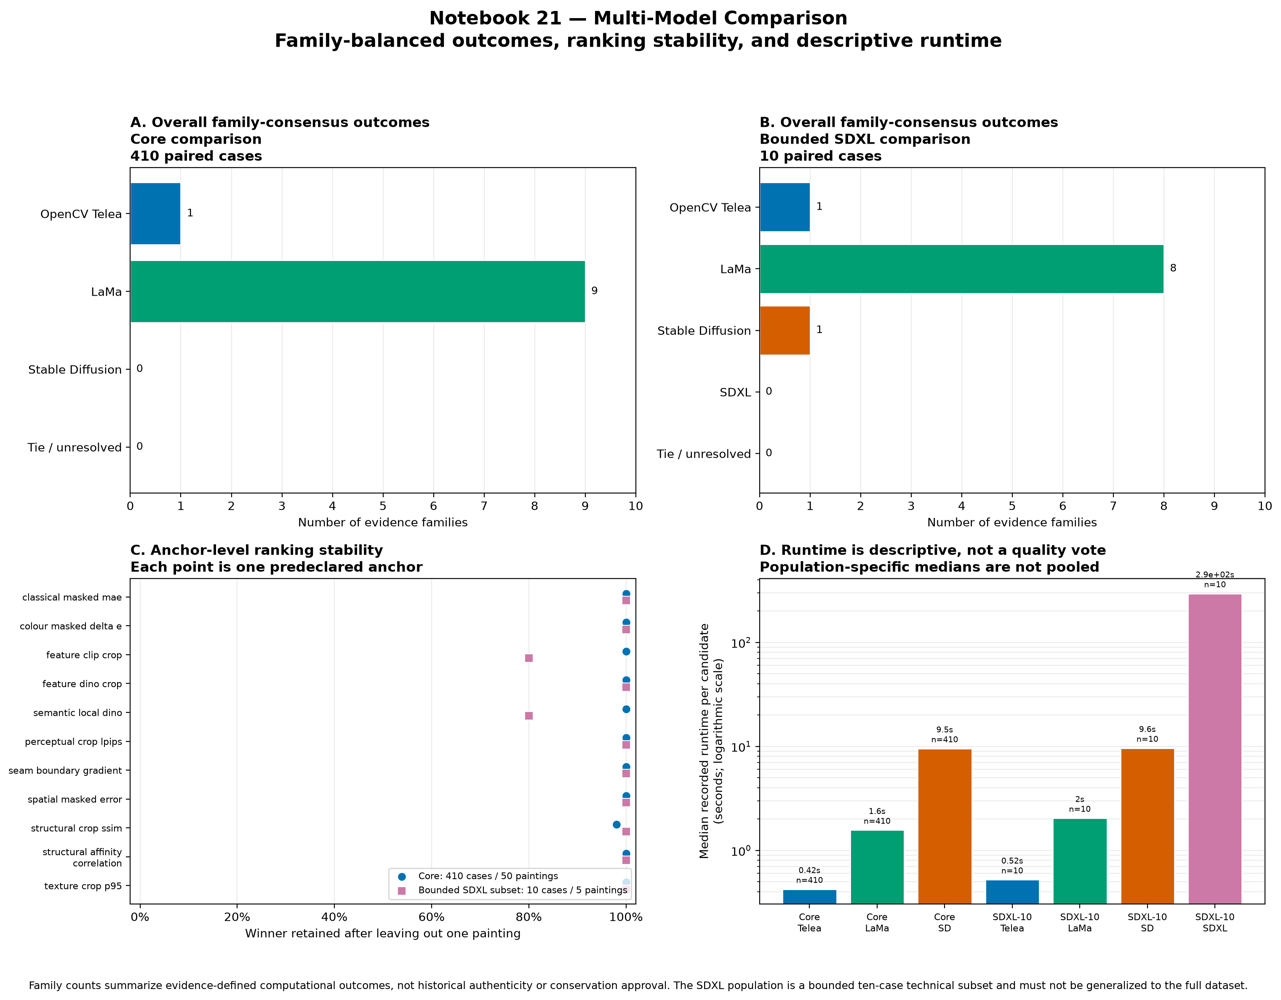

Rendered persisted preview: metric_disagreement_figure


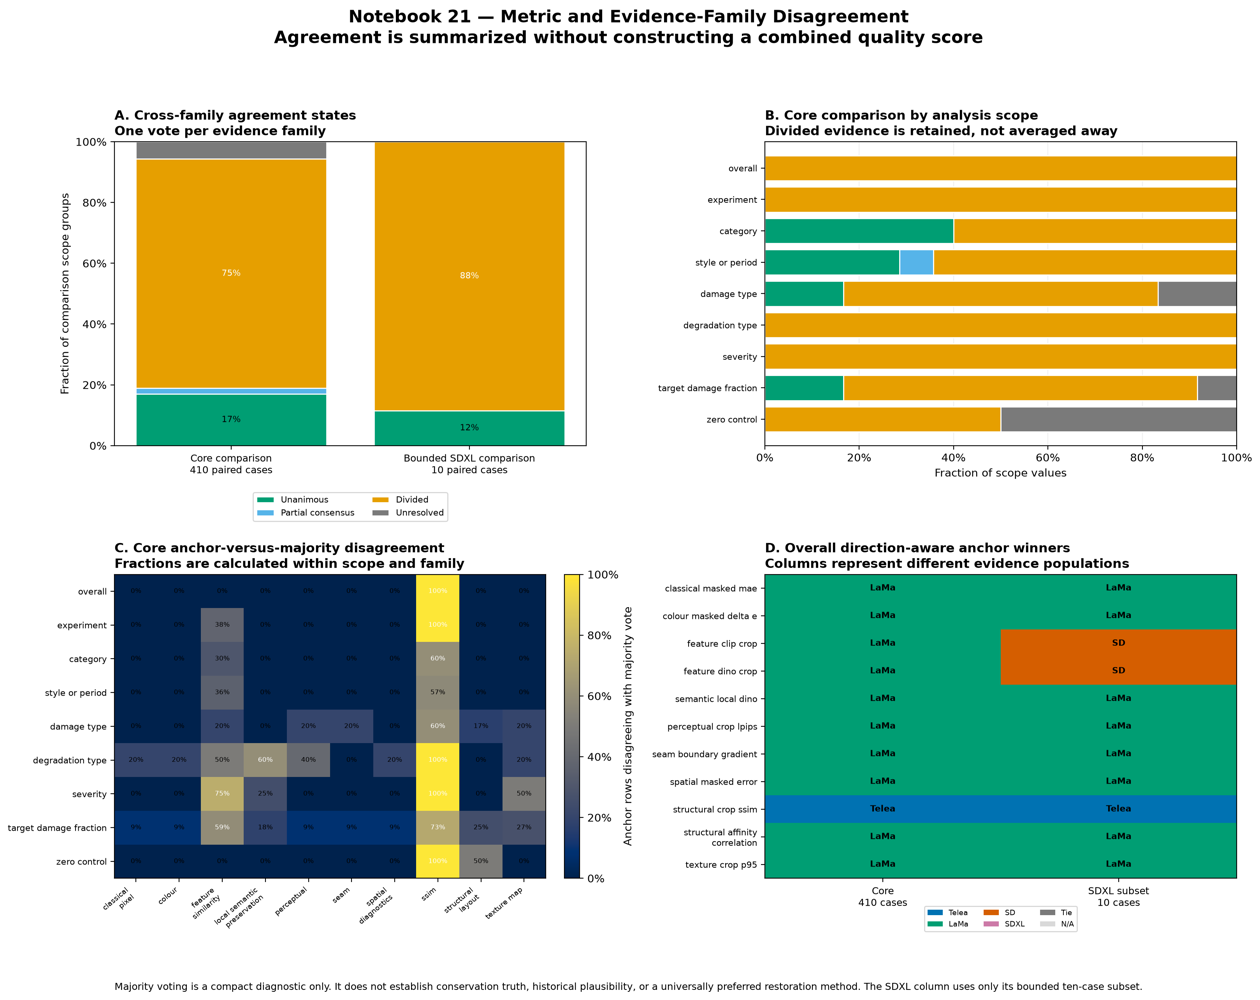

Notebook 21 Batch 7 summary
---------------------------
Canonical figures: 2
Figure paths: ['outputs/21_multi_model_comparison/figures/model_comparison.png', 'outputs/21_multi_model_comparison/figures/metric_disagreement.png']
Figure checks: 5
Total blocking failures: 0
Other canonical outputs written: []
Batch 7 completion gate passed.


In [38]:
# ---------------------------------------------------------------------------
# Canonical figure validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_7_canonical_figures"
)


def add_figure_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


figure_paths = {
    "model_comparison_figure": OUTPUTS[
        "model_comparison_figure"
    ],
    "metric_disagreement_figure": OUTPUTS[
        "metric_disagreement_figure"
    ],
}

figure_audit_records = []

for figure_key, figure_path in (
    figure_paths.items()
):
    require_notebook_output_path(
        figure_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    if not figure_path.is_file():
        figure_audit_records.append(
            {
                "figure_key": figure_key,
                "relative_path": (
                    to_repo_relative(
                        figure_path,
                        PROJECT_ROOT,
                    )
                ),
                "exists": False,
                "format": pd.NA,
                "mode": pd.NA,
                "width": pd.NA,
                "height": pd.NA,
                "size_bytes": 0,
                "pixel_std": np.nan,
                "sha256": pd.NA,
                "passed": False,
            }
        )
        continue

    with PILImage.open(
        figure_path
    ) as opened:
        figure_format = opened.format
        figure_mode = opened.mode
        figure_width, figure_height = (
            opened.size
        )

        audit_pixels = np.asarray(
            opened
            .convert("RGB")
            .resize((128, 128)),
            dtype=np.float32,
        )

    figure_size_bytes = int(
        figure_path.stat().st_size
    )

    figure_pixel_std = float(
        audit_pixels.std()
    )

    figure_passed = (
        figure_format == "PNG"
        and figure_mode in {"RGB", "RGBA"}
        and figure_width >= 2500
        and figure_height >= 1800
        and figure_size_bytes >= 50_000
        and figure_pixel_std > 2.0
    )

    figure_audit_records.append(
        {
            "figure_key": figure_key,
            "relative_path": (
                to_repo_relative(
                    figure_path,
                    PROJECT_ROOT,
                )
            ),
            "exists": True,
            "format": figure_format,
            "mode": figure_mode,
            "width": int(figure_width),
            "height": int(figure_height),
            "size_bytes": figure_size_bytes,
            "pixel_std": figure_pixel_std,
            "sha256": manifest_sha256_path(
                figure_path
            ),
            "passed": figure_passed,
        }
    )

canonical_figure_audit_df = pd.DataFrame(
    figure_audit_records
)

expected_figure_paths = {
    path.resolve()
    for path in figure_paths.values()
}

observed_figure_paths = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "figures"
    ).glob("*")
    if path.is_file()
}

existing_canonical_output_keys = {
    key
    for key, path in OUTPUTS.items()
    if path.is_file()
}

expected_existing_output_keys = {
    "model_comparison_figure",
    "metric_disagreement_figure",
}

family_counts_by_population = (
    overall_family_plot_df
    .groupby("population_id")
    ["evidence_family"]
    .nunique()
    .astype(int)
    .to_dict()
)

anchor_counts_by_population = (
    overall_anchor_outcomes_df
    .groupby("population_id")
    ["anchor_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

add_figure_check(
    "canonical_figure_files",
    (
        "Both canonical analytical figures exist, are "
        "nonblank PNG files, and meet the minimum "
        "render dimensions."
    ),
    {
        "figure_count": 2,
        "minimum_width": 2500,
        "minimum_height": 1800,
        "minimum_size_bytes": 50_000,
    },
    canonical_figure_audit_df[
        [
            "figure_key",
            "format",
            "mode",
            "width",
            "height",
            "size_bytes",
            "pixel_std",
            "passed",
        ]
    ].to_dict("records"),
    (
        len(canonical_figure_audit_df) == 2
        and canonical_figure_audit_df[
            "passed"
        ].all()
    ),
)

add_figure_check(
    "canonical_figure_directory_contents",
    (
        "The figures directory contains exactly the two "
        "declared canonical PNG files."
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in expected_figure_paths
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in observed_figure_paths
    ),
    (
        observed_figure_paths
        == expected_figure_paths
    ),
)

add_figure_check(
    "figure_evidence_contract",
    (
        "Figure inputs retain the complete family, "
        "anchor, and comparison-scope populations."
    ),
    {
        "families_per_population": (
            EXPECTED_COUNTS[
                "metric_disagreement_families"
            ]
        ),
        "anchors_per_population": (
            EXPECTED_COUNTS[
                "metric_disagreement_anchors"
            ]
        ),
        "scope_groups": (
            EXPECTED_COUNTS[
                "metric_disagreement_scope_groups"
            ]
        ),
    },
    {
        "family_counts_by_population": (
            family_counts_by_population
        ),
        "anchor_counts_by_population": (
            anchor_counts_by_population
        ),
        "scope_groups": len(
            independent_majority_audit_df
        ),
    },
    (
        set(
            family_counts_by_population.values()
        )
        == {
            EXPECTED_COUNTS[
                "metric_disagreement_families"
            ]
        }
        and set(
            anchor_counts_by_population.values()
        )
        == {
            EXPECTED_COUNTS[
                "metric_disagreement_anchors"
            ]
        }
        and len(
            independent_majority_audit_df
        )
        == EXPECTED_COUNTS[
            "metric_disagreement_scope_groups"
        ]
    ),
)

add_figure_check(
    "figure_population_separation",
    (
        "Every figure source retains distinct core and "
        "bounded-SDXL population labels."
    ),
    {
        "core_three_model",
        "sdxl_four_model_subset",
    },
    set(
        overall_family_plot_df[
            "population_id"
        ].astype(str)
    ),
    set(
        overall_family_plot_df[
            "population_id"
        ].astype(str)
    )
    == {
        "core_three_model",
        "sdxl_four_model_subset",
    },
)

add_figure_check(
    "batch_7_output_scope",
    (
        "Only the two canonical figures have been "
        "persisted by the end of Batch 7."
    ),
    expected_existing_output_keys,
    existing_canonical_output_keys,
    (
        existing_canonical_output_keys
        == expected_existing_output_keys
    ),
)

batch_7_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_7_canonical_figures"
        )
    ]
    .reset_index(drop=True)
)

display(canonical_figure_audit_df)
display(batch_7_validation_df)

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Reload exact persisted figures for notebook-visible inspection
# ---------------------------------------------------------------------------

for figure_key, figure_path in (
    figure_paths.items()
):
    with PILImage.open(
        figure_path
    ) as opened:
        preview = opened.convert(
            "RGB"
        ).copy()

    preview.thumbnail(
        (1400, 1000)
    )

    print(
        "Rendered persisted preview:",
        figure_key,
    )
    display(preview)


print("Notebook 21 Batch 7 summary")
print("---------------------------")
print(
    "Canonical figures:",
    len(canonical_figure_audit_df),
)
print(
    "Figure paths:",
    canonical_figure_audit_df[
        "relative_path"
    ].tolist(),
)
print(
    "Figure checks:",
    len(batch_7_validation_df),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Other canonical outputs written:",
    sorted(
        existing_canonical_output_keys
        - expected_existing_output_keys
    ),
)
print("Batch 7 completion gate passed.")

## Batch 8 — Conclusions-Led Self-Contained Comparison Report

This batch generates the standalone Notebook 21 report:

- `reports/multi_model_comparison.html`

The report follows the approved conclusions-led structure:

- headline findings before methodological detail;
- explicit model-specific assertions;
- separate treatment of damage geometry, category/style, synthetic degradation, disagreement, uncertainty, prompting, SDXL, and runtime;
- concise result bullets and a scoped conclusion after every major section;
- visual evidence accompanied by interpretation rather than selection metadata alone;
- one consolidated limitations section instead of repeatedly interrupting the findings.

Every number and model comparison is derived from validated Notebook 21 or upstream evidence. The report does not construct a combined quality score or make a conservation recommendation.

In [45]:
# ---------------------------------------------------------------------------
# Report helpers
# ---------------------------------------------------------------------------

import base64
import html as html_module
import io
import re

from restoration_eval.multi_model_comparison import (
    image_grid_to_data_uri,
    image_path_to_data_uri,
    validate_self_contained_report_html,
)


REPORT_MODEL_COLOURS = {
    "OpenCV Telea": "#0072B2",
    "LaMa": "#009E73",
    "Stable Diffusion": "#D55E00",
    "SDXL": "#CC79A7",
    "Tie / unresolved": "#7A7A7A",
}


def figure_to_data_uri(figure, dpi=145):
    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="PNG",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(figure)

    return (
        "data:image/png;base64,"
        + base64.b64encode(
            buffer.getvalue()
        ).decode("ascii")
    )


analytical_view_records = []


def register_plot(
    view_id,
    title,
    caption,
    evidence_source,
    figure=None,
    source_path=None,
):
    if figure is not None:
        data_uri = figure_to_data_uri(
            figure
        )
    else:
        data_uri = image_path_to_data_uri(
            source_path,
            max_dimension=1600,
            photographic_format="PNG",
        )

    analytical_view_records.append(
        {
            "view_id": view_id,
            "title": title,
            "caption": caption,
            "evidence_source": (
                evidence_source
            ),
            "data_uri": data_uri,
        }
    )


def report_winner_name(value):
    if pd.isna(value):
        return "Tie / unresolved"

    value = str(value).strip()

    if not value or "|" in value:
        return "Tie / unresolved"

    return MODEL_DISPLAY_NAMES.get(
        value,
        value,
    )


def build_scope_winner_plot(
    analysis_scope,
    *,
    title,
):
    scope_rows = (
        majority_scope_df.loc[
            majority_scope_df[
                "population_id"
            ].eq("core_three_model")
            & majority_scope_df[
                "analysis_scope"
            ].eq(analysis_scope)
        ]
        .copy()
        .sort_values(
            "scope_value",
            kind="stable",
        )
    )

    if scope_rows.empty:
        raise ValueError(
            "No majority-vote rows for "
            f"{analysis_scope!r}."
        )

    scope_rows[
        "winner_display"
    ] = scope_rows[
        "majority_vote_winner_model_id"
    ].map(report_winner_name)

    figure_height = max(
        4.0,
        0.42 * len(scope_rows) + 1.8,
    )

    figure, axis = plt.subplots(
        figsize=(8.5, figure_height)
    )

    positions = np.arange(
        len(scope_rows)
    )

    bars = axis.barh(
        positions,
        np.ones(len(scope_rows)),
        color=[
            REPORT_MODEL_COLOURS.get(
                winner,
                "#7A7A7A",
            )
            for winner in scope_rows[
                "winner_display"
            ]
        ],
    )

    axis.set_yticks(positions)
    axis.set_yticklabels(
        [
            str(value).replace("_", " ")
            for value in scope_rows[
                "scope_value"
            ]
        ],
        fontsize=8,
    )
    axis.invert_yaxis()
    axis.set_xlim(0.0, 1.0)
    axis.set_xticks([])
    axis.set_title(
        title,
        fontweight="bold",
    )

    for bar, winner in zip(
        bars,
        scope_rows["winner_display"],
    ):
        axis.text(
            0.5,
            bar.get_y()
            + bar.get_height() / 2,
            winner,
            ha="center",
            va="center",
            fontweight="bold",
            fontsize=8,
        )

    figure.tight_layout()

    return figure


# ---------------------------------------------------------------------------
# 1–2 — Existing canonical figures
# ---------------------------------------------------------------------------

register_plot(
    "canonical_model_comparison",
    "Headline model comparison",
    (
        "Family-balanced outcomes, painting-level "
        "ranking stability, and descriptive runtime."
    ),
    (
        "outputs/21_multi_model_comparison/"
        "figures/model_comparison.png"
    ),
    source_path=OUTPUTS[
        "model_comparison_figure"
    ],
)

register_plot(
    "canonical_metric_disagreement",
    "Metric and family disagreement",
    (
        "Evidence-family disagreement is retained "
        "instead of being averaged into one score."
    ),
    (
        "outputs/21_multi_model_comparison/"
        "figures/metric_disagreement.png"
    ),
    source_path=OUTPUTS[
        "metric_disagreement_figure"
    ],
)


# ---------------------------------------------------------------------------
# 3 — Core model-by-family winner map
# ---------------------------------------------------------------------------

core_family_rows = (
    overall_family_consensus_df.loc[
        overall_family_consensus_df[
            "population_id"
        ].eq("core_three_model")
    ]
    .copy()
    .sort_values(
        "evidence_family",
        kind="stable",
    )
)

core_family_rows[
    "winner_display"
] = core_family_rows[
    "family_consensus_winner_model_id"
].map(report_winner_name)

figure, axis = plt.subplots(
    figsize=(8.5, 5.5)
)

positions = np.arange(
    len(core_family_rows)
)

bars = axis.barh(
    positions,
    np.ones(len(core_family_rows)),
    color=[
        REPORT_MODEL_COLOURS[
            winner
        ]
        for winner in core_family_rows[
            "winner_display"
        ]
    ],
)

axis.set_yticks(positions)
axis.set_yticklabels(
    [
        value.replace("_", " ")
        for value in core_family_rows[
            "evidence_family"
        ]
    ],
    fontsize=8,
)
axis.invert_yaxis()
axis.set_xlim(0.0, 1.0)
axis.set_xticks([])
axis.set_title(
    (
        "Full-scope family leaders — "
        "410 paired cases"
    ),
    fontweight="bold",
)

for bar, winner in zip(
    bars,
    core_family_rows[
        "winner_display"
    ],
):
    axis.text(
        0.5,
        bar.get_y()
        + bar.get_height() / 2,
        winner,
        ha="center",
        va="center",
        fontweight="bold",
    )

figure.tight_layout()

register_plot(
    "core_family_winner_map",
    "Which model leads each evidence family?",
    (
        "One outcome is retained per family, preventing "
        "families with many correlated metrics from "
        "receiving extra weight."
    ),
    "Overall core family consensus",
    figure=figure,
)


# ---------------------------------------------------------------------------
# 4 — Conditional majority-outcome counts
# ---------------------------------------------------------------------------

conditional_majority_counts = (
    majority_scope_df.loc[
        majority_scope_df[
            "population_id"
        ].eq("core_three_model")
        & ~majority_scope_df[
            "analysis_scope"
        ].eq("overall")
    ][
        "majority_vote_winner_model_id"
    ]
    .map(report_winner_name)
    .value_counts()
)

figure, axis = plt.subplots(
    figsize=(8.0, 4.6)
)

bars = axis.bar(
    conditional_majority_counts.index,
    conditional_majority_counts.values,
    color=[
        REPORT_MODEL_COLOURS.get(
            winner,
            "#7A7A7A",
        )
        for winner in (
            conditional_majority_counts.index
        )
    ],
)

axis.set_ylabel(
    "Conditional scope groups"
)
axis.set_title(
    (
        "Family-balanced majority outcomes "
        "across conditional groups"
    ),
    fontweight="bold",
)
axis.tick_params(
    axis="x",
    rotation=18,
)
axis.grid(
    axis="y",
    alpha=0.25,
)
axis.set_axisbelow(True)

for bar, count in zip(
    bars,
    conditional_majority_counts.values,
):
    axis.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.35,
        str(int(count)),
        ha="center",
    )

figure.tight_layout()

register_plot(
    "conditional_majority_counts",
    "How often does each model lead a conditional group?",
    (
        "Counts summarize family-balanced outcomes "
        "across category, damage, severity, experiment, "
        "and related scopes."
    ),
    "Conditional family-balanced majority outcomes",
    figure=figure,
)


# ---------------------------------------------------------------------------
# 5–10 — Explicit conditional result views
# ---------------------------------------------------------------------------

scope_plot_specs = [
    (
        "damage_type",
        "damage_type_outcomes",
        "Model outcome by damage type",
    ),
    (
        "target_damage_fraction",
        "damage_fraction_outcomes",
        "Model outcome across target damage fractions",
    ),
    (
        "category",
        "category_outcomes",
        "Model outcome across controlled categories",
    ),
    (
        "style_or_period",
        "style_outcomes",
        "Model outcome across recorded style or period",
    ),
    (
        "degradation_type",
        "degradation_outcomes",
        "Model outcome by synthetic degradation",
    ),
    (
        "severity",
        "severity_outcomes",
        "Model outcome by degradation severity",
    ),
]

for (
    analysis_scope,
    view_id,
    title,
) in scope_plot_specs:
    figure = build_scope_winner_plot(
        analysis_scope,
        title=title,
    )

    register_plot(
        view_id,
        title,
        (
            "The displayed leader is the one-vote-per-"
            "family diagnostic outcome for each scope "
            "value, not a universal model rank."
        ),
        (
            "metric_disagreement.csv-compatible "
            f"{analysis_scope} outcomes"
        ),
        figure=figure,
    )


# ---------------------------------------------------------------------------
# 11 — Cross-family agreement states
# ---------------------------------------------------------------------------

state_counts = (
    independent_majority_audit_df[
        "cross_family_state"
    ]
    .value_counts()
    .reindex(
        STATE_ORDER,
        fill_value=0,
    )
)

figure, axis = plt.subplots(
    figsize=(7.8, 4.6)
)

bars = axis.bar(
    [
        STATE_DISPLAY_NAMES[state]
        for state in STATE_ORDER
    ],
    state_counts.values,
    color=[
        STATE_COLOURS[state]
        for state in STATE_ORDER
    ],
)

axis.set_ylabel(
    "Comparison scope groups"
)
axis.set_title(
    "Most comparison groups contain divided evidence",
    fontweight="bold",
)
axis.tick_params(
    axis="x",
    rotation=15,
)
axis.grid(
    axis="y",
    alpha=0.25,
)
axis.set_axisbelow(True)

for bar, count in zip(
    bars,
    state_counts.values,
):
    axis.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.4,
        str(int(count)),
        ha="center",
    )

figure.tight_layout()

register_plot(
    "agreement_state_counts",
    "Cross-family agreement states",
    (
        "Divided evidence is a scientific result, not "
        "noise to be removed."
    ),
    "Independent family-vote reconstruction",
    figure=figure,
)


# ---------------------------------------------------------------------------
# 12 — Uncertainty against Stable Diffusion improvement
# ---------------------------------------------------------------------------

uncertainty_scatter_df = (
    uncertainty_case_diagnostics_df[
        [
            "case_id",
            "damage_type",
            "rgb_std_mean_masked",
            SD_IMPROVEMENT_COLUMN,
        ]
    ]
    .dropna()
    .copy()
)

figure, axis = plt.subplots(
    figsize=(8.0, 5.0)
)

axis.scatter(
    uncertainty_scatter_df[
        "rgb_std_mean_masked"
    ],
    uncertainty_scatter_df[
        SD_IMPROVEMENT_COLUMN
    ],
    color="#D55E00",
    alpha=0.68,
    edgecolor="white",
    linewidth=0.5,
)

axis.set_xlabel(
    "Masked RGB repeated-seed variability"
)
axis.set_ylabel(
    "Fraction of direction-aware anchors improved"
)
axis.yaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)
axis.set_title(
    (
        "Stable Diffusion uncertainty does not "
        "uniquely determine performance"
    ),
    fontweight="bold",
)
axis.grid(alpha=0.25)
axis.set_axisbelow(True)
figure.tight_layout()

register_plot(
    "uncertainty_vs_improvement",
    "Uncertainty versus Stable Diffusion performance",
    (
        "Low variability can accompany weak outcomes, "
        "while high variability identifies only one "
        "form of unreliability."
    ),
    (
        "Notebook 18 uncertainty calibration joined "
        "to Notebook 21 case diagnostics"
    ),
    figure=figure,
)


# ---------------------------------------------------------------------------
# 13 — Scratch-prompt paired effects
# ---------------------------------------------------------------------------

scratch_delta_specs = [
    (
        "scratch_aware_mae_improvement",
        "Masked MAE",
        "#0072B2",
    ),
    (
        "scratch_aware_ssim_improvement",
        "Crop SSIM",
        "#009E73",
    ),
    (
        "scratch_aware_seam_improvement",
        "Boundary seam",
        "#E69F00",
    ),
]

figure, axes = plt.subplots(
    1,
    3,
    figsize=(11.5, 4.2),
)

for axis, (
    column,
    title,
    colour,
) in zip(
    axes,
    scratch_delta_specs,
):
    values = pd.to_numeric(
        scratch_prompt_pairs_df[column],
        errors="coerce",
    ).dropna()

    axis.boxplot(
        [values],
        tick_labels=["50 cases"],
        patch_artist=True,
        boxprops={
            "facecolor": colour,
            "alpha": 0.8,
        },
    )
    axis.axhline(
        0.0,
        color="#222222",
        linestyle="--",
    )
    axis.set_title(
        title,
        fontweight="bold",
    )
    axis.grid(
        axis="y",
        alpha=0.25,
    )

figure.suptitle(
    (
        "Scratch-aware prompt effect\n"
        "Positive values indicate improvement"
    ),
    fontweight="bold",
)
figure.tight_layout()

register_plot(
    "scratch_prompt_effects",
    "Generic versus scratch-aware prompting",
    (
        "The paired ablation retains both improvements "
        "and regressions."
    ),
    "Notebook 18 scratch-prompt pairs",
    figure=figure,
)


# ---------------------------------------------------------------------------
# 14 — Runtime
# ---------------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(8.5, 4.8)
)

runtime_positions = np.arange(
    len(runtime_plot_df)
)

runtime_labels = [
    (
        "Core"
        if population_id
        == "core_three_model"
        else "SDXL-10"
    )
    + "\n"
    + MODEL_SHORT_NAMES[str(model_id)]
    for population_id, model_id
    in runtime_plot_df[
        [
            "population_id",
            "model_id",
        ]
    ].itertuples(
        index=False,
        name=None,
    )
]

bars = axis.bar(
    runtime_positions,
    runtime_plot_df[
        "runtime_median"
    ],
    color=[
        MODEL_COLOURS[str(model_id)]
        for model_id in runtime_plot_df[
            "model_id"
        ]
    ],
)

axis.set_xticks(runtime_positions)
axis.set_xticklabels(
    runtime_labels,
    fontsize=8,
)
axis.set_yscale("log")
axis.set_ylabel(
    "Median seconds per candidate (log scale)"
)
axis.set_title(
    "Runtime differs by orders of magnitude",
    fontweight="bold",
)
axis.grid(
    axis="y",
    which="both",
    alpha=0.25,
)
axis.set_axisbelow(True)

for bar, value in zip(
    bars,
    runtime_plot_df[
        "runtime_median"
    ],
):
    axis.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() * 1.08,
        f"{value:.2g}s",
        ha="center",
        fontsize=8,
    )

figure.tight_layout()

register_plot(
    "runtime_comparison",
    "Runtime comparison",
    (
        "Runtime is operational evidence and remains "
        "outside quality voting."
    ),
    "Overall runtime comparison rows",
    figure=figure,
)


analytical_views_df = pd.DataFrame(
    analytical_view_records
)

if len(analytical_views_df) != 14:
    raise ValueError(
        "Expected 14 analytical report views, "
        f"observed {len(analytical_views_df)}."
    )

print("Conclusions-led analytical views prepared.")
print(
    "Analytical views:",
    len(analytical_views_df),
)
print(
    "Unique IDs:",
    analytical_views_df[
        "view_id"
    ].nunique(),
)
print("Persisted analytical files: 2 canonical figures only")

Conclusions-led analytical views prepared.
Analytical views: 14
Unique IDs: 14
Persisted analytical files: 2 canonical figures only


In [46]:
# ---------------------------------------------------------------------------
# Visual-panel policy
# ---------------------------------------------------------------------------

REPORT_PHOTOGRAPHIC_QUALITY = int(
    REPORT_POLICY[
        "photographic_quality"
    ]
)

ROLE_CONCLUSIONS = {
    "consensus_success": (
        "All three methods improve the declared anchor "
        "evidence, although visible artifacts can "
        "remain and still require human review."
    ),
    "consensus_failure": (
        "No method provides broad improvement across "
        "the anchor evidence for this case."
    ),
    "classical_perceptual_disagreement": (
        "Pixel fidelity and perceptual similarity "
        "identify different preferred candidates."
    ),
    "feature_colour_disagreement": (
        "Feature preservation coexists with a different "
        "colour-consistency winner."
    ),
    "texture_seam_disagreement": (
        "Local texture and repaired-boundary evidence "
        "support different methods."
    ),
    "semantic_local_fidelity_disagreement": (
        "Semantic continuity does not guarantee local "
        "structural fidelity."
    ),
    "high_sd_uncertainty": (
        "Stable Diffusion produces visibly and "
        "numerically variable candidates across seeds."
    ),
    "low_uncertainty_consistent_failure": (
        "Stable outputs can remain consistently weak; "
        "low uncertainty is not correctness."
    ),
    "scratch_thin_deterministic_advantage": (
        "Telea and LaMa retain a family-balanced "
        "advantage, while Stable Diffusion preserves "
        "visible line-shaped scratch artifacts."
    ),
    "damage_size_progression": (
        "Increasing damage size changes relative model "
        "behaviour rather than merely increasing error."
    ),
    "category_median": (
        "This case represents typical rather than "
        "extreme behaviour within its category."
    ),
    "synthetic_degradation_example": (
        "Diffuse degradation produces disagreement "
        "that is not equivalent to binary inpainting."
    ),
}

restoration_panel_records = []


def resolve_report_image(value):
    return resolve_repo_path(
        str(value),
        PROJECT_ROOT,
        must_exist=True,
    )


def resolve_raw_sd_image(value):
    value_path = Path(str(value))

    if value_path.is_absolute():
        result = value_path.resolve()
    elif str(value).replace(
        "\\",
        "/",
    ).startswith("outputs/"):
        result = (
            PROJECT_ROOT
            / value_path
        ).resolve()
    else:
        result = (
            INPUTS[
                "stable_diffusion_candidates_path"
            ].parent.parent
            / value_path
        ).resolve()

    if not result.is_file():
        raise FileNotFoundError(
            f"Missing report image: {result}"
        )

    return result


def append_report_panel(
    *,
    panel_id,
    panel_group,
    panel_role,
    case_id,
    title,
    conclusion,
    selection_reason,
    items,
    columns,
):
    resolved_items = [
        (
            str(label),
            Path(path).resolve(),
        )
        for label, path in items
    ]

    missing = [
        str(path)
        for _, path in resolved_items
        if not path.is_file()
    ]

    if missing:
        raise FileNotFoundError(
            f"Missing panel images: {missing}"
        )

    restoration_panel_records.append(
        {
            "panel_id": panel_id,
            "panel_group": panel_group,
            "panel_role": panel_role,
            "case_id": case_id,
            "title": title,
            "conclusion": conclusion,
            "selection_reason": (
                selection_reason
            ),
            "source_image_count": len(
                resolved_items
            ),
            "source_paths": "|".join(
                to_repo_relative(
                    path,
                    PROJECT_ROOT,
                )
                for _, path in resolved_items
            ),
            "data_uri": (
                image_grid_to_data_uri(
                    resolved_items,
                    columns=columns,
                    tile_size=(300, 250),
                    quality=(
                        REPORT_PHOTOGRAPHIC_QUALITY
                    ),
                )
            ),
        }
    )

    completed = len(
        restoration_panel_records
    )

    if (
        completed % 10 == 0
        or completed == 30
    ):
        print(
            "Report-panel progress:",
            f"{completed}/30",
        )


# ---------------------------------------------------------------------------
# Twelve core representative cases
# ---------------------------------------------------------------------------

core_report_slots_df = (
    representative_selection_slots_df.loc[
        representative_selection_slots_df[
            "population_id"
        ].eq("core_three_model")
    ]
    .sort_values(
        "selection_priority",
        kind="stable",
    )
)

for slot in core_report_slots_df.itertuples(
    index=False
):
    slot_rows = (
        representative_cases_df.loc[
            representative_cases_df[
                "selection_slot_id"
            ].eq(
                slot.selection_slot_id
            )
        ]
        .set_index("model_id")
    )

    first = slot_rows.iloc[0]

    items = [
        (
            "Clean reference",
            resolve_report_image(
                first["clean_image_path"]
            ),
        ),
        (
            "Damaged input",
            resolve_report_image(
                first["input_image_path"]
            ),
        ),
    ]

    if pd.notna(
        first["mask_or_effect_path"]
    ):
        items.append(
            (
                "Mask / effect",
                resolve_report_image(
                    first[
                        "mask_or_effect_path"
                    ]
                ),
            )
        )

    for model_id in CORE_MODEL_IDS:
        items.append(
            (
                MODEL_DISPLAY_NAMES[
                    model_id
                ],
                resolve_report_image(
                    slot_rows.loc[
                        model_id,
                        "restored_path",
                    ]
                ),
            )
        )

    role = str(slot.selection_role)

    append_report_panel(
        panel_id=(
            "core_"
            + str(slot.selection_slot_id)
        ),
        panel_group="core_representative",
        panel_role=role,
        case_id=str(slot.case_id),
        title=(
            role.replace(
                "_",
                " ",
            ).title()
        ),
        conclusion=ROLE_CONCLUSIONS[
            role
        ],
        selection_reason=str(
            slot.selection_reason
        ),
        items=items,
        columns=3,
    )


# ---------------------------------------------------------------------------
# Ten bounded SDXL cases
# ---------------------------------------------------------------------------

sdxl_report_slots_df = (
    representative_selection_slots_df.loc[
        representative_selection_slots_df[
            "population_id"
        ].eq(
            "sdxl_four_model_subset"
        )
    ]
    .sort_values(
        "selection_priority",
        kind="stable",
    )
)

for slot in sdxl_report_slots_df.itertuples(
    index=False
):
    slot_rows = (
        representative_cases_df.loc[
            representative_cases_df[
                "selection_slot_id"
            ].eq(
                slot.selection_slot_id
            )
        ]
        .set_index("model_id")
    )

    first = slot_rows.iloc[0]

    items = [
        (
            "Clean reference",
            resolve_report_image(
                first["clean_image_path"]
            ),
        ),
        (
            "Damaged input",
            resolve_report_image(
                first["input_image_path"]
            ),
        ),
    ]

    if pd.notna(
        first["mask_or_effect_path"]
    ):
        items.append(
            (
                "Mask / effect",
                resolve_report_image(
                    first[
                        "mask_or_effect_path"
                    ]
                ),
            )
        )

    for model_id in FOUR_MODEL_SUBSET_MODELS:
        items.append(
            (
                MODEL_DISPLAY_NAMES[
                    model_id
                ],
                resolve_report_image(
                    slot_rows.loc[
                        model_id,
                        "restored_path",
                    ]
                ),
            )
        )

    append_report_panel(
        panel_id=(
            "sdxl_"
            + str(slot.selection_slot_id)
        ),
        panel_group="sdxl_bounded",
        panel_role="sdxl_bounded_case",
        case_id=str(slot.case_id),
        title=(
            "Bounded SDXL Case: "
            + str(slot.case_id)
        ),
        conclusion=(
            "This panel supports case-level feasibility "
            "inspection only; it cannot establish a "
            "full-dataset SDXL ranking."
        ),
        selection_reason=str(
            slot.selection_reason
        ),
        items=items,
        columns=4,
    )


# ---------------------------------------------------------------------------
# Stable Diffusion seed populations
# ---------------------------------------------------------------------------

raw_sd_candidates_df = (
    raw_candidate_tables[
        "stable_diffusion_inpainting"
    ].copy()
)

raw_sd_candidates_df[
    "seed_numeric"
] = pd.to_numeric(
    raw_sd_candidates_df["seed"],
    errors="coerce",
)

for panel in (
    uncertainty_panel_cases_df
    .sort_values(
        "panel_role",
        kind="stable",
    )
    .itertuples(index=False)
):
    rows = (
        raw_sd_candidates_df.loc[
            raw_sd_candidates_df[
                "case_id"
            ].astype(str).eq(
                str(panel.case_id)
            )
            & raw_sd_candidates_df[
                "prompt_variant_id"
            ].astype(str).eq(
                str(
                    panel.prompt_variant_id
                )
            )
            & raw_sd_candidates_df[
                "status"
            ].astype(str).eq("completed")
            & raw_sd_candidates_df[
                "seed_numeric"
            ].isin(
                {2026, 2027, 2028, 2029}
            )
        ]
        .sort_values(
            [
                "seed_numeric",
                "candidate_id",
            ],
            kind="stable",
        )
        .drop_duplicates(
            "seed_numeric"
        )
    )

    if set(
        rows["seed_numeric"].astype(int)
    ) != {2026, 2027, 2028, 2029}:
        raise ValueError(
            "Incomplete uncertainty panel: "
            f"{panel.case_id}"
        )

    first = rows.iloc[0]

    items = [
        (
            "Clean reference",
            resolve_report_image(
                first["clean_image_path"]
            ),
        ),
        (
            "Damaged input",
            resolve_report_image(
                first["input_image_path"]
            ),
        ),
    ]

    items.extend(
        (
            f"Seed {int(row.seed_numeric)}",
            resolve_raw_sd_image(
                row.restored_path
            ),
        )
        for row in rows.itertuples(
            index=False
        )
    )

    role = str(panel.panel_role)

    uncertainty_conclusion = (
        "The four candidates expose high repeated-seed "
        "variation."
        if role.startswith("highest")
        else
        "The four candidates are comparatively stable, "
        "but stability alone does not establish quality."
    )

    append_report_panel(
        panel_id=(
            "uncertainty_" + role
        ),
        panel_group="uncertainty_context",
        panel_role=role,
        case_id=str(panel.case_id),
        title=(
            role.replace(
                "_",
                " ",
            ).title()
        ),
        conclusion=(
            uncertainty_conclusion
        ),
        selection_reason=str(
            panel.selection_reason
        ),
        items=items,
        columns=3,
    )


# ---------------------------------------------------------------------------
# Generic versus scratch-aware prompt panels
# ---------------------------------------------------------------------------

for panel in (
    scratch_prompt_panel_cases_df
    .sort_values(
        "panel_role",
        kind="stable",
    )
    .itertuples(index=False)
):
    rows = (
        raw_sd_candidates_df.loc[
            raw_sd_candidates_df[
                "case_id"
            ].astype(str).eq(
                str(panel.case_id)
            )
            & raw_sd_candidates_df[
                "status"
            ].astype(str).eq("completed")
            & raw_sd_candidates_df[
                "seed_numeric"
            ].eq(2026)
            & raw_sd_candidates_df[
                "prompt_variant_id"
            ].astype(str).isin(
                {
                    "p00_generic",
                    "p05_scratch_aware",
                }
            )
        ]
        .sort_values(
            [
                "prompt_variant_id",
                "candidate_id",
            ],
            kind="stable",
        )
        .drop_duplicates(
            "prompt_variant_id"
        )
        .set_index(
            "prompt_variant_id"
        )
    )

    if set(rows.index) != {
        "p00_generic",
        "p05_scratch_aware",
    }:
        raise ValueError(
            "Incomplete scratch-prompt panel: "
            f"{panel.case_id}"
        )

    generic = rows.loc[
        "p00_generic"
    ]
    aware = rows.loc[
        "p05_scratch_aware"
    ]

    effect_value = float(
        panel.selection_score
    )

    if effect_value > 0:
        conclusion = (
            "The scratch-aware prompt improves the "
            "selected metric for this case."
        )
    elif effect_value < 0:
        conclusion = (
            "The scratch-aware prompt regresses the "
            "selected metric for this case."
        )
    else:
        conclusion = (
            "The selected metric is unchanged between "
            "prompt arms."
        )

    append_report_panel(
        panel_id=(
            "scratch_prompt_"
            + str(panel.panel_role)
        ),
        panel_group="scratch_prompt_context",
        panel_role=str(
            panel.panel_role
        ),
        case_id=str(panel.case_id),
        title=(
            str(panel.panel_role)
            .replace("_", " ")
            .title()
        ),
        conclusion=conclusion,
        selection_reason=str(
            panel.selection_reason
        ),
        items=[
            (
                "Clean reference",
                resolve_report_image(
                    generic[
                        "clean_image_path"
                    ]
                ),
            ),
            (
                "Damaged input",
                resolve_report_image(
                    generic[
                        "input_image_path"
                    ]
                ),
            ),
            (
                "Generic prompt - seed 2026",
                resolve_raw_sd_image(
                    generic[
                        "restored_path"
                    ]
                ),
            ),
            (
                "Scratch-aware - seed 2026",
                resolve_raw_sd_image(
                    aware[
                        "restored_path"
                    ]
                ),
            ),
        ],
        columns=4,
    )


report_visual_panels_df = pd.DataFrame(
    restoration_panel_records
)

expected_panel_counts = {
    "core_representative": 12,
    "sdxl_bounded": 10,
    "uncertainty_context": 4,
    "scratch_prompt_context": 4,
}

observed_panel_counts = (
    report_visual_panels_df[
        "panel_group"
    ]
    .value_counts()
    .astype(int)
    .to_dict()
)

if observed_panel_counts != expected_panel_counts:
    raise ValueError(
        "Unexpected report-panel population: "
        f"{observed_panel_counts}"
    )

print("Conclusions-led visual atlas prepared.")
print(
    "Panels:",
    len(report_visual_panels_df),
)
print(
    "Panel groups:",
    observed_panel_counts,
)
print(
    "Source images:",
    int(
        report_visual_panels_df[
            "source_image_count"
        ].sum()
    ),
)
print("Persisted panel files: None")

Report-panel progress: 10/30
Report-panel progress: 20/30
Report-panel progress: 30/30
Conclusions-led visual atlas prepared.
Panels: 30
Panel groups: {'core_representative': 12, 'sdxl_bounded': 10, 'uncertainty_context': 4, 'scratch_prompt_context': 4}
Source images: 182
Persisted panel files: None


In [47]:
# ---------------------------------------------------------------------------
# Evidence-derived headline facts
# ---------------------------------------------------------------------------

core_family_counts = (
    overall_family_count_df.loc[
        overall_family_count_df[
            "population_id"
        ].eq("core_three_model")
    ]
    .set_index("winner_display")[
        "family_count"
    ]
    .to_dict()
)

sdxl_family_counts = (
    overall_family_count_df.loc[
        overall_family_count_df[
            "population_id"
        ].eq(
            "sdxl_four_model_subset"
        )
    ]
    .set_index("winner_display")[
        "family_count"
    ]
    .to_dict()
)

state_counts_dict = (
    independent_majority_audit_df[
        "cross_family_state"
    ]
    .value_counts()
    .astype(int)
    .to_dict()
)

divided_count = int(
    state_counts_dict.get("divided", 0)
)

scope_group_count = len(
    independent_majority_audit_df
)

divided_fraction = (
    divided_count
    / scope_group_count
)

core_loo_median = float(
    loo_anchor_plot_df.loc[
        loo_anchor_plot_df[
            "population_id"
        ].eq("core_three_model"),
        "loo_winner_stability_fraction",
    ].median()
)

scratch_positive_fractions = {
    "masked MAE": float(
        scratch_prompt_pairs_df[
            "scratch_aware_mae_improvement"
        ].gt(0).mean()
    ),
    "crop SSIM": float(
        scratch_prompt_pairs_df[
            "scratch_aware_ssim_improvement"
        ].gt(0).mean()
    ),
    "boundary seam": float(
        scratch_prompt_pairs_df[
            "scratch_aware_seam_improvement"
        ].gt(0).mean()
    ),
}

core_runtime_lookup = (
    runtime_plot_df.loc[
        runtime_plot_df[
            "population_id"
        ].eq("core_three_model")
    ]
    .set_index("model_id")[
        "runtime_median"
    ]
    .to_dict()
)

sd_to_telea_runtime_ratio = (
    core_runtime_lookup[
        "stable_diffusion_inpainting"
    ]
    / core_runtime_lookup[
        "opencv_telea"
    ]
)

conditional_outcome_counts = (
    majority_scope_df.loc[
        majority_scope_df[
            "population_id"
        ].eq("core_three_model")
        & ~majority_scope_df[
            "analysis_scope"
        ].eq("overall")
    ][
        "majority_vote_winner_model_id"
    ]
    .map(report_winner_name)
    .value_counts()
    .astype(int)
    .to_dict()
)


# ---------------------------------------------------------------------------
# Concise HTML helpers
# ---------------------------------------------------------------------------

def table_html(
    frame,
    *,
    decimals=4,
):
    display_frame = frame.copy()

    for column in display_frame.columns:
        if pd.api.types.is_float_dtype(
            display_frame[column]
        ):
            display_frame[column] = (
                display_frame[column]
                .round(decimals)
            )

    return display_frame.to_html(
        index=False,
        border=0,
        classes="data-table",
        escape=True,
        na_rep="—",
    )


def figure_html(row):
    return (
        '<figure class="visual-card">'
        f"<h3>{html_module.escape(str(row.title))}</h3>"
        f'<img src="{row.data_uri}" '
        f'alt="{html_module.escape(str(row.title))}">'
        "<figcaption>"
        f"{html_module.escape(str(row.caption))}"
        "</figcaption>"
        "</figure>"
    )


def panel_html(row):
    return (
        '<figure class="visual-card">'
        f"<h3>{html_module.escape(str(row.title))}</h3>"
        f'<img src="{row.data_uri}" '
        f'alt="{html_module.escape(str(row.title))}">'
        "<figcaption>"
        "<strong>Result:</strong> "
        f"{html_module.escape(str(row.conclusion))}"
        "<br><strong>Selection:</strong> "
        f"{html_module.escape(str(row.selection_reason))}"
        "</figcaption>"
        "</figure>"
    )


analytical_html = {
    str(row.view_id): figure_html(row)
    for row in analytical_views_df.itertuples(
        index=False
    )
}

panel_groups = {
    group: frame.copy()
    for group, frame
    in report_visual_panels_df.groupby(
        "panel_group",
        sort=False,
    )
}


def panels_to_html(frame):
    return "".join(
        panel_html(row)
        for row in frame.itertuples(
            index=False
        )
    )


def scope_assertions_html(
    analysis_scope,
):
    rows = (
        majority_scope_df.loc[
            majority_scope_df[
                "population_id"
            ].eq("core_three_model")
            & majority_scope_df[
                "analysis_scope"
            ].eq(analysis_scope)
        ]
        .sort_values(
            "scope_value",
            kind="stable",
        )
    )

    return "".join(
        (
            "<li><strong>"
            + html_module.escape(
                str(row.scope_value)
                .replace("_", " ")
            )
            + ":</strong> "
            + html_module.escape(
                report_winner_name(
                    row.majority_vote_winner_model_id
                )
            )
            + " is the family-balanced majority "
            "outcome.</li>"
        )
        for row in rows.itertuples(
            index=False
        )
    )


family_outcome_table_df = pd.DataFrame(
    [
        {
            "Model or outcome": outcome,
            "Core families": int(
                core_family_counts.get(
                    outcome,
                    0,
                )
            ),
            "Bounded SDXL families": int(
                sdxl_family_counts.get(
                    outcome,
                    0,
                )
            ),
        }
        for outcome in [
            "OpenCV Telea",
            "LaMa",
            "Stable Diffusion",
            "SDXL",
            "Tie / unresolved",
        ]
    ]
)

runtime_table_df = (
    runtime_plot_df[
        [
            "population_id",
            "model_id",
            "paired_case_count",
            "runtime_median",
        ]
    ]
    .copy()
)

runtime_table_df[
    "Population"
] = runtime_table_df[
    "population_id"
].map(
    {
        "core_three_model": "Core",
        "sdxl_four_model_subset": (
            "Bounded SDXL subset"
        ),
    }
)

runtime_table_df[
    "Model"
] = runtime_table_df[
    "model_id"
].map(MODEL_DISPLAY_NAMES)

runtime_table_df = runtime_table_df[
    [
        "Population",
        "Model",
        "paired_case_count",
        "runtime_median",
    ]
].rename(
    columns={
        "paired_case_count": "Paired cases",
        "runtime_median": (
            "Median seconds per candidate"
        ),
    }
)

print("Report assertions prepared.")
print(
    "Core family outcomes:",
    core_family_counts,
)
print(
    "Bounded SDXL family outcomes:",
    sdxl_family_counts,
)
print(
    "Cross-family states:",
    state_counts_dict,
)
print(
    "Conditional outcomes:",
    conditional_outcome_counts,
)
print("Report written: No")

Report assertions prepared.
Core family outcomes: {'LaMa': 9, 'OpenCV Telea': 1}
Bounded SDXL family outcomes: {'LaMa': 8, 'OpenCV Telea': 1, 'Stable Diffusion': 1}
Cross-family states: {'divided': 63, 'unanimous': 12, 'unresolved': 3, 'partial_consensus': 1}
Conditional outcomes: {'LaMa': 47, 'Tie / unresolved': 4, 'OpenCV Telea': 1}
Report written: No


In [48]:
# ---------------------------------------------------------------------------
# Conclusions-led report styling
# ---------------------------------------------------------------------------

REPORT_CSS = """
:root {
    --ink: #172033;
    --muted: #5b6678;
    --line: #d8dee8;
    --soft: #f4f7fa;
    --accent: #006d77;
    --success: #e9f6ed;
    --warning: #fff5d6;
}
* { box-sizing: border-box; }
body {
    margin: 0;
    background: #edf1f5;
    color: var(--ink);
    font-family: "Segoe UI", Arial, sans-serif;
    line-height: 1.55;
}
main {
    width: min(1200px, calc(100% - 30px));
    margin: 24px auto;
    padding: 52px;
    background: white;
    border-radius: 16px;
}
h1 { font-size: 2.7rem; margin-bottom: 0.25rem; }
h2 {
    margin-top: 3rem;
    border-bottom: 2px solid var(--line);
    padding-bottom: 0.45rem;
}
h3 { line-height: 1.25; }
.meta {
    background: var(--soft);
    padding: 16px 20px;
    border-radius: 10px;
}
.findings li, .assertions li { margin-bottom: 0.55rem; }
.conclusion {
    margin: 20px 0;
    padding: 16px 18px;
    background: var(--success);
    border-left: 5px solid #27864b;
    border-radius: 8px;
}
.limit {
    margin: 20px 0;
    padding: 14px 18px;
    background: var(--warning);
    border-left: 5px solid #9a6700;
    border-radius: 8px;
}
.visual-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(390px, 1fr));
    gap: 18px;
}
.visual-card {
    margin: 16px 0;
    padding: 13px;
    border: 1px solid var(--line);
    border-radius: 10px;
    background: #fbfcfe;
}
.visual-card img {
    width: 100%;
    height: auto;
    display: block;
    border-radius: 6px;
}
figcaption {
    margin-top: 9px;
    color: var(--muted);
    font-size: 0.91rem;
}
.data-table {
    width: 100%;
    border-collapse: collapse;
    margin: 18px 0;
    font-size: 0.9rem;
}
.data-table th, .data-table td {
    padding: 8px 10px;
    border: 1px solid var(--line);
    text-align: left;
}
.data-table th { background: var(--soft); }
details {
    margin: 18px 0;
    padding: 12px 15px;
    border: 1px solid var(--line);
    border-radius: 9px;
}
summary {
    cursor: pointer;
    color: var(--accent);
    font-weight: 700;
}
.small { color: var(--muted); font-size: 0.9rem; }
@media (max-width: 720px) {
    main { width: 100%; margin: 0; padding: 20px; }
    .visual-grid { grid-template-columns: 1fr; }
}
"""


# ---------------------------------------------------------------------------
# Main visible and appendix panels
# ---------------------------------------------------------------------------

core_panels = panel_groups[
    "core_representative"
]

core_main_html = panels_to_html(
    core_panels.head(8)
)

core_appendix_html = panels_to_html(
    core_panels.iloc[8:]
)

uncertainty_html = panels_to_html(
    panel_groups[
        "uncertainty_context"
    ]
)

scratch_html = panels_to_html(
    panel_groups[
        "scratch_prompt_context"
    ]
)

sdxl_panels = panel_groups[
    "sdxl_bounded"
]

sdxl_main_html = panels_to_html(
    sdxl_panels.head(2)
)

sdxl_appendix_html = panels_to_html(
    sdxl_panels.iloc[2:]
)


# ---------------------------------------------------------------------------
# Standalone HTML
# ---------------------------------------------------------------------------

report_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Trustworthy Multi-Model Painting Restoration Evaluation</title>
<style>{REPORT_CSS}</style>
</head>
<body>
<main>

<h1>Trustworthy Evaluation of AI-Assisted Painting Restoration</h1>
<h2 style="margin-top:0;border:0">Multi-Model Comparison Report</h2>

<div class="meta">
<strong>Evaluation population:</strong> 410 paired cases from 50 paintings<br>
<strong>Full-scope models:</strong> OpenCV Telea, LaMa, Stable Diffusion<br>
<strong>Partial-scope model:</strong> SDXL on 10 predeclared cases<br>
<strong>Evidence:</strong> classical, perceptual, feature, spatial, texture,
colour, seam, semantic, uncertainty, and runtime<br>
<strong>Validation status:</strong> passed through Batch 8
</div>

<h2>Research-question orientation</h2>
<ul>
<li><strong>RQ1:</strong> Does multi-metric evaluation reveal behaviour that traditional similarity alone cannot?</li>
<li><strong>RQ2:</strong> How do methods differ across damage conditions, categories, and styles?</li>
<li><strong>RQ3:</strong> Does repeated-seed variability identify unstable or potentially speculative Stable Diffusion restorations?</li>
<li><strong>Extended scope:</strong> Where do metrics disagree, how stable are rankings, and which cases require human review?</li>
</ul>

<h2>Executive conclusions</h2>
<ul class="findings">
<li>
<strong>LaMa has the broadest full-scope numerical support:</strong>
it leads {int(core_family_counts.get("LaMa", 0))} of 10 evidence-family outcomes.
</li>
<li>
<strong>Telea retains a distinct structural niche:</strong>
it leads {int(core_family_counts.get("OpenCV Telea", 0))} overall family outcome and the selected thin-scratch case shows a clear deterministic advantage over Stable Diffusion.
</li>
<li>
<strong>Stable Diffusion does not lead an overall core family:</strong>
its strengths are conditional, while thin scratches can remain visible as line-shaped artifacts.
</li>
<li>
<strong>Damage and evidence type materially change the answer:</strong>
{divided_count} of {scope_group_count} scope groups ({divided_fraction:.1%}) contain divided family evidence.
</li>
<li>
<strong>Overall rankings are painting-sensitive but generally stable:</strong>
the median core anchor winner survives {core_loo_median:.1%} of leave-one-painting-out replicates.
</li>
<li>
<strong>Prompt engineering is not a universal fix:</strong>
the scratch-aware prompt improves masked MAE in {scratch_positive_fractions["masked MAE"]:.1%},
crop SSIM in {scratch_positive_fractions["crop SSIM"]:.1%}, and seam evidence in {scratch_positive_fractions["boundary seam"]:.1%} of paired scratch cases.
</li>
<li>
<strong>SDXL remains exploratory:</strong>
it leads {int(sdxl_family_counts.get("SDXL", 0))} of 10 family outcomes in its bounded subset and cannot be generalized to 410 cases.
</li>
<li>
<strong>Generative inference carries a substantial operational cost:</strong>
Stable Diffusion's core median runtime is approximately {sd_to_telea_runtime_ratio:.1f} times Telea's.
</li>
</ul>

{analytical_html["canonical_model_comparison"]}

<div class="conclusion">
<strong>Main conclusion.</strong>
The results support conditional model selection, not a universal leaderboard:
LaMa is the strongest broad baseline, Telea remains valuable for constrained
local geometry, and generative methods require additional scrutiny for local
fidelity, stability, and unsupported content.
</div>

<h2>1. Does multi-metric evaluation change the assessment?</h2>
<div class="visual-grid">
{analytical_html["core_family_winner_map"]}
{analytical_html["agreement_state_counts"]}
</div>

{table_html(family_outcome_table_df)}

<ul class="assertions">
<li>LaMa leads most overall classical, perceptual, feature, colour, seam, semantic, spatial, and texture-family evidence.</li>
<li>Telea's overall advantage is concentrated rather than universal.</li>
<li>Stable Diffusion's absence from the overall family leaders does not mean it loses every case; it means its advantages do not persist across the full paired population.</li>
<li>Metric disagreement is common enough to change interpretation and must remain visible.</li>
</ul>

<div class="conclusion">
<strong>RQ1 conclusion.</strong>
Traditional similarity describes only part of restoration behaviour.
Texture, colour, seam, feature, and semantic evidence materially alter
how some candidates are interpreted.
</div>

<h2>2. How do the models differ overall?</h2>
{analytical_html["conditional_majority_counts"]}

<h3>LaMa</h3>
<ul>
<li>Provides the strongest broad evidence-family consistency.</li>
<li>Remains the dominant family-balanced outcome across many conditional groups.</li>
<li>Still produces visible smoothing or residual artifacts in individual cases, so numerical leadership is not equivalent to flawless restoration.</li>
</ul>

<h3>OpenCV Telea</h3>
<ul>
<li>Has the lowest computational cost among the evaluated methods.</li>
<li>Is particularly competitive when damage geometry permits local interpolation.</li>
<li>Shows a pronounced advantage over Stable Diffusion in the selected thin-scratch evidence.</li>
<li>Can produce blur or dark filling artifacts for less locally constrained losses.</li>
</ul>

<h3>Stable Diffusion</h3>
<ul>
<li>Provides condition-specific generative continuation rather than a stable global advantage.</li>
<li>Can preserve semantic or feature evidence while losing colour, seam, or local fidelity.</li>
<li>Shows repeated-seed variability and prompt sensitivity unavailable in deterministic methods.</li>
<li>Can replace a white scratch with a subtler but still visible tonal line.</li>
</ul>

<div class="conclusion">
<strong>Overall model conclusion.</strong>
LaMa is the strongest general-purpose computational baseline in this
experiment. Telea remains preferable for some narrow local repairs.
Stable Diffusion presents a semantic-continuation versus local-fidelity
trade-off rather than a consistent improvement.
</div>

<h2>3. What do the restorations actually look like?</h2>
<div class="visual-grid">
{core_main_html}
</div>

<div class="conclusion">
<strong>Visual conclusion.</strong>
The representative cases confirm that metric winners can retain visible
defects and that different metrics reward different aspects of the same
restoration. Numerical ranking therefore requires image-level review.
</div>

<h2>4. Does performance depend on damage geometry?</h2>
<div class="visual-grid">
{analytical_html["damage_type_outcomes"]}
{analytical_html["damage_fraction_outcomes"]}
</div>

<ul class="assertions">
{scope_assertions_html("damage_type")}
{scope_assertions_html("target_damage_fraction")}
</ul>

<div class="conclusion">
<strong>Damage-geometry conclusion.</strong>
Model behaviour changes with both damage type and damaged-area fraction.
A pooled full-dataset result conceals operating conditions in which a
different method becomes preferable.
</div>

<h2>5. Do category and style affect the comparison?</h2>
<div class="visual-grid">
{analytical_html["category_outcomes"]}
{analytical_html["style_outcomes"]}
</div>

<ul class="assertions">
{scope_assertions_html("category")}
</ul>

<div class="conclusion">
<strong>Category conclusion.</strong>
The controlled categories produce different family-balanced outcomes,
while fine-grained style results remain less secure where only a small
number of independent paintings are available.
</div>

<h2>6. Synthetic degradations and restoration behaviour</h2>
<div class="visual-grid">
{analytical_html["degradation_outcomes"]}
{analytical_html["severity_outcomes"]}
</div>

<ul class="assertions">
{scope_assertions_html("degradation_type")}
{scope_assertions_html("severity")}
</ul>

<div class="conclusion">
<strong>Synthetic-degradation conclusion.</strong>
Degradation mechanism changes model behaviour. Water staining, dirt,
partial transparency, and combined degradation should not be treated as
interchangeable missing-region problems.
</div>

<h2>7. Where do the metrics disagree?</h2>
{analytical_html["canonical_metric_disagreement"]}

<ul>
<li>{divided_count} of {scope_group_count} scope groups contain more than one unique family winner.</li>
<li>A family-balanced majority is a compact diagnostic, not a trustworthiness score.</li>
<li>Semantic or feature agreement can coexist with colour, texture, or seam failure.</li>
<li>Disagreement identifies cases requiring explanation rather than cases that should be discarded.</li>
</ul>

<div class="conclusion">
<strong>Disagreement conclusion.</strong>
Metric disagreement is scientifically useful evidence. Removing it
would make the comparison simpler but less trustworthy.
</div>

<h2>8. Does uncertainty identify speculative behaviour?</h2>
{analytical_html["uncertainty_vs_improvement"]}

<div class="visual-grid">
{uncertainty_html}
</div>

<ul>
<li>High seed variability exposes unstable candidate generation.</li>
<li>Low seed variability can accompany consistently weak restoration.</li>
<li>Uncertainty is model-specific and cannot be assigned retrospectively to deterministic methods or single-seed SDXL.</li>
</ul>

<div class="conclusion">
<strong>RQ3 conclusion.</strong>
Repeated-seed variability identifies some unstable cases, but it does
not identify every unreliable restoration and cannot be interpreted as
calibrated confidence.
</div>

<h2>9. Scratch-aware prompt context</h2>
{analytical_html["scratch_prompt_effects"]}

<div class="visual-grid">
{scratch_html}
</div>

<ul>
<li>The scratch-aware prompt improves some paintings and metrics.</li>
<li>Other cases regress, so the prompt cannot replace the generic baseline.</li>
<li>Prompt changes do not fully solve Stable Diffusion's narrow-mask geometry problem.</li>
<li>The ablation remains contextual evidence and is not substituted into the baseline comparison.</li>
</ul>

<div class="conclusion">
<strong>Prompt conclusion.</strong>
Damage-aware language is useful but insufficient. Thin-scratch
restoration remains constrained by mask geometry and local continuity,
not merely by semantic prompt wording.
</div>

<h2>10. SDXL partial-scope visual atlas</h2>
<div class="visual-grid">
{sdxl_main_html}
</div>

<details>
<summary>Open the remaining eight bounded SDXL panels</summary>
<div class="visual-grid">
{sdxl_appendix_html}
</div>
</details>

<ul>
<li>All ten technically validated SDXL cases are included.</li>
<li>SDXL contributes no full-scope evidence and no repeated-seed uncertainty.</li>
<li>Its images are useful for feasibility and failure inspection.</li>
<li>Visual continuation does not establish that generated content is historically supported.</li>
</ul>

<div class="conclusion">
<strong>SDXL conclusion.</strong>
SDXL is a validated partial evaluation, not a full benchmark participant
and not a feasibility-only placeholder.
</div>

<h2>11. Runtime and compute</h2>
{analytical_html["runtime_comparison"]}
{table_html(runtime_table_df)}

<ul>
<li>Telea is the least computationally expensive evaluated method.</li>
<li>LaMa remains substantially faster than diffusion inference.</li>
<li>SDXL has the highest observed median runtime in the bounded subset.</li>
<li>No runtime-adjusted quality score is constructed.</li>
</ul>

<div class="conclusion">
<strong>Operational conclusion.</strong>
Deterministic methods support faster broad screening. Generative methods
increase both compute cost and the number of outputs requiring human
inspection.
</div>

<h2>12. Thesis-level conclusions</h2>

<h3>What the evidence supports</h3>
<ul>
<li>Painting-restoration evaluation benefits materially from combining classical, perceptual, feature, texture, colour, seam, semantic, spatial, and uncertainty evidence.</li>
<li>Model performance is conditional on damage geometry, affected region, degradation mechanism, and painting characteristics.</li>
<li>Deterministic methods can outperform generative methods for constrained local repairs.</li>
<li>Generative continuation can preserve higher-level content while introducing local inconsistency or unsupported detail.</li>
<li>Metric disagreement should be exposed rather than averaged away.</li>
<li>Uncertainty identifies some speculative behaviour but requires failure evidence and human review.</li>
</ul>

<h3>What remains unresolved</h3>
<ul>
<li>Whether computationally preferred candidates are accepted by professional conservators.</li>
<li>Whether learned-feature consistency corresponds to historical plausibility.</li>
<li>How these results generalize to naturally deteriorated physical paintings.</li>
<li>How later failure flags should be calibrated against human judgements.</li>
<li>Whether any generated candidate is suitable for physical conservation intervention.</li>
</ul>

<div class="conclusion">
<strong>Contribution to the thesis.</strong>
Notebook 21 demonstrates a reproducible, museum-oriented evidence
structure that makes model strengths, limitations, uncertainty, and
metric disagreement visible without equating visual plausibility with
authenticity.
</div>

<h2>13. Extended visual evidence</h2>
<details>
<summary>Open four additional core representative panels</summary>
<div class="visual-grid">
{core_appendix_html}
</div>
</details>

<h2>Interpretation limits</h2>
<div class="limit">
<ul>
<li>Reference similarity does not prove historical accuracy.</li>
<li>Feature similarity does not prove iconographic correctness.</li>
<li>Low pixel error does not prove acceptable brushwork or material compatibility.</li>
<li>The 410 cases are nested within 50 paintings.</li>
<li>Style metadata is incomplete for part of the dataset.</li>
<li>SDXL contains ten cases and one seed per case.</li>
<li>Majority voting is not conservation truth.</li>
<li>Computational evaluation does not authorize physical intervention.</li>
</ul>
</div>

<p class="small">
Report policy: {html_module.escape(COMPARISON_CONFIG["report_policy_id"])}.<br>
Candidate policy: {html_module.escape(COMPARISON_CONFIG["selection_policy_id"])}.<br>
Disagreement policy: {html_module.escape(COMPARISON_CONFIG["disagreement_policy_id"])}.<br>
Notebook run started: {html_module.escape(NOTEBOOK_STARTED_AT_UTC)}.
</p>

</main>
</body>
</html>
"""


# ---------------------------------------------------------------------------
# Persist revised report
# ---------------------------------------------------------------------------

require_notebook_output_path(
    OUTPUTS["report"],
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

OUTPUTS["report"].write_text(
    report_html,
    encoding="utf-8",
)

print("Conclusions-led report written.")
print(
    "Path:",
    to_repo_relative(
        OUTPUTS["report"],
        PROJECT_ROOT,
    ),
)
print(
    "Size MiB:",
    round(
        OUTPUTS["report"].stat().st_size
        / (1024 ** 2),
        3,
    ),
)
print(
    "Analytical views:",
    len(analytical_views_df),
)
print(
    "Visual panels:",
    len(report_visual_panels_df),
)

Conclusions-led report written.
Path: outputs/21_multi_model_comparison/reports/multi_model_comparison.html
Size MiB: 4.17
Analytical views: 14
Visual panels: 30


In [49]:
# ---------------------------------------------------------------------------
# Reload exact persisted HTML
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_8_conclusions_led_report"
)

reloaded_report_html = (
    OUTPUTS["report"]
    .read_text(encoding="utf-8")
)

report_helper_validation_df = (
    validate_self_contained_report_html(
        reloaded_report_html,
        config=comparison_config,
    )
)

report_image_sources = re.findall(
    (
        r"<img\b[^>]*\bsrc="
        r"[\"']([^\"']+)[\"']"
    ),
    reloaded_report_html,
    flags=re.IGNORECASE,
)

embedded_image_sources = [
    source
    for source in report_image_sources
    if source.startswith("data:image/")
]

external_image_sources = [
    source
    for source in report_image_sources
    if not source.startswith("data:image/")
]

expected_embedded_images = (
    len(analytical_views_df)
    + len(report_visual_panels_df)
)

expected_sdxl_cases = set(
    sdxl_report_slots_df[
        "case_id"
    ].astype(str)
)

missing_sdxl_cases = sorted(
    case_id
    for case_id in expected_sdxl_cases
    if case_id not in reloaded_report_html
)

required_assertion_phrases = [
    "LaMa has the broadest",
    "Telea retains a distinct",
    "Stable Diffusion does not lead",
    "Damage and evidence type materially change",
    "Prompt engineering is not a universal fix",
    "What the evidence supports",
    "What remains unresolved",
    "Contribution to the thesis",
]

missing_assertion_phrases = [
    phrase
    for phrase in required_assertion_phrases
    if phrase not in reloaded_report_html
]


def add_report_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


for row in (
    report_helper_validation_df
    .itertuples(index=False)
):
    add_report_check(
        (
            "report_helper_"
            + str(row.check_name)
        ),
        (
            "Self-contained report check: "
            + str(row.check_name)
        ),
        row.expected,
        row.observed,
        row.passed,
        details=row.issue,
        severity=(
            "warning"
            if row.check_name
            == "report_soft_size_warning"
            else "blocking"
        ),
    )

add_report_check(
    "report_round_trip",
    (
        "Persisted HTML reloads without changes."
    ),
    True,
    reloaded_report_html == report_html,
    reloaded_report_html == report_html,
)

add_report_check(
    "report_visual_density",
    (
        "The report contains the complete analytical "
        "and visual evidence populations."
    ),
    {
        "analytical_views": 14,
        "visual_panels": 30,
        "embedded_images": 44,
    },
    {
        "analytical_views": len(
            analytical_views_df
        ),
        "visual_panels": len(
            report_visual_panels_df
        ),
        "embedded_images": len(
            embedded_image_sources
        ),
    },
    (
        len(analytical_views_df) == 14
        and len(
            report_visual_panels_df
        ) == 30
        and len(
            embedded_image_sources
        ) == expected_embedded_images
        == 44
    ),
)

add_report_check(
    "report_portability",
    (
        "All report images are embedded."
    ),
    0,
    len(external_image_sources),
    not external_image_sources,
    details=external_image_sources,
)

add_report_check(
    "report_sdxl_coverage",
    (
        "All ten bounded SDXL cases appear in the report."
    ),
    0,
    len(missing_sdxl_cases),
    not missing_sdxl_cases,
    details=missing_sdxl_cases,
)

add_report_check(
    "report_assertive_structure",
    (
        "The conclusions-led report retains all "
        "required assertion and synthesis blocks."
    ),
    0,
    len(missing_assertion_phrases),
    not missing_assertion_phrases,
    details=missing_assertion_phrases,
)

expected_batch_8_outputs = {
    "model_comparison_figure",
    "metric_disagreement_figure",
    "report",
}

observed_batch_8_outputs = {
    key
    for key, path in OUTPUTS.items()
    if path.is_file()
}

add_report_check(
    "batch_8_output_scope",
    (
        "Only the two canonical figures and report "
        "exist before final persistence."
    ),
    expected_batch_8_outputs,
    observed_batch_8_outputs,
    (
        observed_batch_8_outputs
        == expected_batch_8_outputs
    ),
)

batch_8_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_8_conclusions_led_report"
        )
    ]
    .reset_index(drop=True)
)

report_audit_df = pd.DataFrame(
    [
        {
            "relative_path": (
                to_repo_relative(
                    OUTPUTS["report"],
                    PROJECT_ROOT,
                )
            ),
            "size_bytes": int(
                OUTPUTS["report"]
                .stat().st_size
            ),
            "size_mib": (
                OUTPUTS["report"]
                .stat().st_size
                / (1024 ** 2)
            ),
            "sha256": (
                manifest_sha256_path(
                    OUTPUTS["report"]
                )
            ),
            "analytical_views": len(
                analytical_views_df
            ),
            "visual_panels": len(
                report_visual_panels_df
            ),
            "embedded_images": len(
                embedded_image_sources
            ),
            "external_images": len(
                external_image_sources
            ),
            "sdxl_cases": (
                len(expected_sdxl_cases)
                - len(missing_sdxl_cases)
            ),
        }
    ]
)

display(report_audit_df)
display(report_helper_validation_df)
display(batch_8_validation_df)

VALIDATION.raise_for_blocking()

warning_failures_df = (
    batch_8_validation_df.loc[
        batch_8_validation_df[
            "severity"
        ].eq("warning")
        & ~batch_8_validation_df[
            "passed"
        ].astype(bool)
    ]
)

print("Notebook 21 Batch 8 summary")
print("---------------------------")
print(
    "Report size MiB:",
    round(
        report_audit_df.loc[
            0,
            "size_mib",
        ],
        3,
    ),
)
print(
    "Embedded analytical views:",
    len(analytical_views_df),
)
print(
    "Embedded visual panels:",
    len(report_visual_panels_df),
)
print(
    "External image dependencies:",
    len(external_image_sources),
)
print(
    "SDXL cases represented:",
    (
        len(expected_sdxl_cases)
        - len(missing_sdxl_cases)
    ),
)
print(
    "Validation checks:",
    len(batch_8_validation_df),
)
print(
    "Warning failures:",
    len(warning_failures_df),
)
print(
    "Total blocking failures:",
    len(VALIDATION.blocking_failures),
)
print("Batch 8 completion gate passed.")

,relative_path,size_bytes,size_mib,sha256,analytical_views,visual_panels,embedded_images,external_images,sdxl_cases
0,outputs/21_multi_model_comparison/reports/mult...,4372255,4.169707,b1474ef6f219bb4f585755f3190999f26d5f5da1315bbd...,14,30,44,0,10


,check_name,observed,expected,passed,issue
0,html_nonempty,4371704,> 0,True,
1,required_visuals_self_contained,0,0,True,
2,embedded_visual_minimum,44,42,True,
3,thesis_question_and_conclusion_terms,"[RQ1, RQ2, RQ3, conclusion, limitation]","[RQ1, RQ2, RQ3, conclusion, limitation]",True,
4,report_soft_size_warning,4.169,<= 40 MiB or documented warning,True,


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_conclusions_led_report,report_helper_html_nonempty,Self-contained report check: html_nonempty,blocking,> 0,4371704,True,
1,batch_8_conclusions_led_report,report_helper_required_visuals_self_contained,Self-contained report check: required_visuals_...,blocking,0,0,True,
2,batch_8_conclusions_led_report,report_helper_embedded_visual_minimum,Self-contained report check: embedded_visual_m...,blocking,42,44,True,
3,batch_8_conclusions_led_report,report_helper_thesis_question_and_conclusion_t...,Self-contained report check: thesis_question_a...,blocking,"[""RQ1"", ""RQ2"", ""RQ3"", ""conclusion"", ""limitation""]","[""RQ1"", ""RQ2"", ""RQ3"", ""conclusion"", ""limitation""]",True,
4,batch_8_conclusions_led_report,report_helper_report_soft_size_warning,Self-contained report check: report_soft_size_...,warning,<= 40 MiB or documented warning,4.169,True,
5,batch_8_conclusions_led_report,report_round_trip,Persisted HTML reloads without changes.,blocking,True,True,True,
6,batch_8_conclusions_led_report,report_visual_density,The report contains the complete analytical an...,blocking,"{""analytical_views"": 14, ""embedded_images"": 44...","{""analytical_views"": 14, ""embedded_images"": 44...",True,
7,batch_8_conclusions_led_report,report_portability,All report images are embedded.,blocking,0,0,True,[]
8,batch_8_conclusions_led_report,report_sdxl_coverage,All ten bounded SDXL cases appear in the report.,blocking,0,0,True,[]
9,batch_8_conclusions_led_report,report_assertive_structure,The conclusions-led report retains all require...,blocking,0,0,True,[]


Notebook 21 Batch 8 summary
---------------------------
Report size MiB: 4.17
Embedded analytical views: 14
Embedded visual panels: 30
External image dependencies: 0
SDXL cases represented: 10
Validation checks: 11
Warning failures: 0
Total blocking failures: 0
Batch 8 completion gate passed.


## Batch 9 — Final persistence, manifests, traceability, and completion gate

This batch completes the Notebook 21 handoff.

It:

- maps every approved roadmap responsibility to concrete implementation evidence;
- persists and independently reloads the three canonical CSV tables;
- verifies the two canonical figures and the self-contained HTML report;
- removes only temporary state under the validated Notebook 21 `work/` directory;
- persists the consolidated validation table;
- creates the normalized seven-record artifact manifest;
- creates the universal run manifest;
- registers validated downstream artifacts in the project-path registry;
- verifies exact file ownership, schemas, checksums, row counts, limitations, and completion status.

The seven registered artifacts are the six scientific/reporting outputs plus `validation/checks.csv`. The run manifest and artifact manifest remain canonical metadata files but do not register themselves, avoiding circular checksum dependencies.

In [50]:
# ---------------------------------------------------------------------------
# Final configuration, manifest utilities, and schema contracts
# ---------------------------------------------------------------------------

import gc
import os
import shutil
import time

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.paths import (
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
    validate_dataframe,
)


# Reload the corrected final count contract without rerunning earlier batches.
comparison_config = load_multi_model_comparison_config(
    COMPARISON_CONFIG_PATH
)

COMPARISON_CONFIG = comparison_config[
    "multi_model_comparison"
]

EXPECTED_COUNTS = COMPARISON_CONFIG[
    "expected_counts"
]

FINAL_ARTIFACT_RECORD_COUNT = int(
    EXPECTED_COUNTS[
        "canonical_artifact_records"
    ]
)

FINAL_CANONICAL_FILE_COUNT = int(
    EXPECTED_COUNTS[
        "canonical_file_count"
    ]
)

if FINAL_ARTIFACT_RECORD_COUNT != 7:
    raise ValueError(
        "Notebook 21 must register exactly seven "
        "non-self-referential artifacts."
    )

if FINAL_CANONICAL_FILE_COUNT != 9:
    raise ValueError(
        "Notebook 21 must finish with exactly nine "
        "canonical files."
    )


# ---------------------------------------------------------------------------
# Roadmap responsibility traceability
# ---------------------------------------------------------------------------

observed_analysis_scopes = set(
    model_comparison_df[
        "analysis_scope"
    ].astype(str)
)

expected_analysis_scopes = {
    str(item["scope_id"])
    for item in COMPARISON_CONFIG[
        "analysis_scopes"
    ]
}

observed_comparison_families = set(
    model_comparison_df[
        "evidence_family"
    ].astype(str)
)

observed_normalized_families = set(
    normalized_evidence_df[
        "evidence_family"
    ].astype(str)
)

observed_models_by_population = {
    str(population_id): set(
        frame["model_id"].astype(str)
    )
    for population_id, frame in (
        model_comparison_df.groupby(
            "population_id",
            sort=True,
        )
    )
}

expected_models_by_population_final = {
    "core_three_model": {
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
    },
    "sdxl_four_model_subset": {
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
        "sdxl_inpainting",
    },
}

required_representative_roles = set(
    COMPARISON_CONFIG[
        "representative_selection"
    ][
        "required_core_roles"
    ]
)

observed_representative_roles = set(
    representative_cases_df[
        "selection_role"
    ].astype(str)
)

comparison_policy_values = set(
    model_comparison_df[
        "selection_policy_id"
    ].astype(str)
)

comparison_direction_values = set(
    model_comparison_df[
        "comparison_direction"
    ].astype(str)
)

disagreement_family_values = set(
    metric_disagreement_df[
        "evidence_family"
    ].astype(str)
)

report_required_phrases = {
    "Research-question orientation",
    "Executive conclusions",
    "What the evidence supports",
    "What remains unresolved",
    "Contribution to the thesis",
    "Interpretation limits",
}

missing_report_required_phrases = sorted(
    phrase
    for phrase in report_required_phrases
    if phrase not in reloaded_report_html
)

roadmap_traceability_records = [
    {
        "requirement_id": "N21-R01",
        "roadmap_requirement": (
            "Compare OpenCV Telea, LaMa, Stable Diffusion, "
            "and validated SDXL results."
        ),
        "implementation_evidence": (
            "A 410-case three-model population and separate "
            "ten-case four-model SDXL subset."
        ),
        "passed": (
            observed_models_by_population
            == expected_models_by_population_final
        ),
    },
    {
        "requirement_id": "N21-R02",
        "roadmap_requirement": (
            "Determine model and evidence availability from "
            "validated upstream manifests."
        ),
        "implementation_evidence": (
            "All twelve Notebook 09–20 run manifests passed "
            "their completion gates."
        ),
        "passed": (
            len(upstream_manifest_df) == 12
            and upstream_manifest_df[
                "passed"
            ].astype(bool).all()
        ),
    },
    {
        "requirement_id": "N21-R03",
        "roadmap_requirement": (
            "Apply a documented non-metric diffusion "
            "candidate-selection policy."
        ),
        "implementation_evidence": (
            "Every comparison row records the approved "
            "primary generic-candidate selection policy."
        ),
        "passed": (
            comparison_policy_values
            == {
                COMPARISON_CONFIG[
                    "selection_policy_id"
                ]
            }
            and bool(
                COMPARISON_CONFIG[
                    "candidate_selection"
                ][
                    "metric_independent"
                ]
            )
        ),
    },
    {
        "requirement_id": "N21-R04",
        "roadmap_requirement": (
            "Compare identical paired cases without mixing "
            "the full and bounded SDXL populations."
        ),
        "implementation_evidence": (
            "1,230 core candidates and 40 bounded-subset "
            "candidates with model-balanced comparison groups."
        ),
        "passed": (
            len(core_population_df) == 1230
            and len(four_model_population_df) == 40
            and scope_model_balance_df[
                "balanced"
            ].astype(bool).all()
        ),
    },
    {
        "requirement_id": "N21-R05",
        "roadmap_requirement": (
            "Compare every normalized metric family."
        ),
        "implementation_evidence": (
            "All normalized evidence families occur in the "
            "canonical comparison table."
        ),
        "passed": (
            observed_normalized_families.issubset(
                observed_comparison_families
            )
        ),
    },
    {
        "requirement_id": "N21-R06",
        "roadmap_requirement": (
            "Compare by experiment, category, style or period, "
            "damage, degradation, severity, percentage, and "
            "zero-control status."
        ),
        "implementation_evidence": (
            "All configured analysis scopes are represented."
        ),
        "passed": (
            observed_analysis_scopes
            == expected_analysis_scopes
        ),
    },
    {
        "requirement_id": "N21-R07",
        "roadmap_requirement": (
            "Compare runtime and compute without treating "
            "runtime as restoration quality."
        ),
        "implementation_evidence": (
            "263 runtime rows are retained descriptively and "
            "excluded from quality ranking."
        ),
        "passed": (
            len(runtime_comparison_df)
            == EXPECTED_COUNTS[
                "runtime_comparison_rows"
            ]
            and not runtime_comparison_df[
                "quality_ranking_eligible"
            ].astype(bool).any()
        ),
    },
    {
        "requirement_id": "N21-R08",
        "roadmap_requirement": (
            "Compare deterministic and generative failure "
            "patterns through auditable visual evidence."
        ),
        "implementation_evidence": (
            "Twelve predeclared core roles, ten SDXL cases, "
            "four uncertainty panels, and four prompt panels."
        ),
        "passed": (
            required_representative_roles.issubset(
                observed_representative_roles
            )
            and len(report_visual_panels_df) == 30
        ),
    },
    {
        "requirement_id": "N21-R09",
        "roadmap_requirement": (
            "Compute direction-aware winners by metric."
        ),
        "implementation_evidence": (
            "Higher-is-better, lower-is-better, and explicitly "
            "descriptive comparisons retain separate policies."
        ),
        "passed": (
            {
                "higher_is_better",
                "lower_is_better",
                "descriptive_only",
            }.issubset(
                comparison_direction_values
            )
        ),
    },
    {
        "requirement_id": "N21-R10",
        "roadmap_requirement": (
            "Retain metric disagreement."
        ),
        "implementation_evidence": (
            "The canonical disagreement table contains 839 "
            "rows across 79 scope groups."
        ),
        "passed": (
            len(metric_disagreement_df)
            == EXPECTED_COUNTS[
                "metric_disagreement_rows"
            ]
            and len(majority_scope_df)
            == EXPECTED_COUNTS[
                "metric_disagreement_scope_groups"
            ]
        ),
    },
    {
        "requirement_id": "N21-R11",
        "roadmap_requirement": (
            "Analyze divergence across classical, perceptual, "
            "feature, texture, colour, seam, semantic, and "
            "spatial evidence."
        ),
        "implementation_evidence": (
            "Eleven predeclared anchors represent ten "
            "family-balanced evidence families."
        ),
        "passed": (
            metric_disagreement_df[
                "anchor_id"
            ].nunique()
            == EXPECTED_COUNTS[
                "metric_disagreement_anchors"
            ]
            and len(disagreement_family_values)
            == EXPECTED_COUNTS[
                "metric_disagreement_families"
            ]
        ),
    },
    {
        "requirement_id": "N21-R12",
        "roadmap_requirement": (
            "Prepare ranking-stability evidence without "
            "treating nested cases as independent paintings."
        ),
        "implementation_evidence": (
            "Overall ranked rows use deterministic "
            "leave-one-painting-out replicates."
        ),
        "passed": (
            not overall_loo_invalid_mask.any()
            and not nonoverall_loo_invalid_mask.any()
        ),
    },
    {
        "requirement_id": "N21-R13",
        "roadmap_requirement": (
            "Use majority voting only as a compact "
            "family-balanced diagnostic."
        ),
        "implementation_evidence": (
            "Independent reconstruction reproduces every "
            "one-vote-per-family result."
        ),
        "passed": (
            independent_majority_audit_df[
                "majority_audit_passed"
            ].astype(bool).all()
            and not metric_disagreement_df[
                "is_conservation_truth"
            ].astype(bool).any()
        ),
    },
    {
        "requirement_id": "N21-R14",
        "roadmap_requirement": (
            "Retain Stable Diffusion uncertainty as separate "
            "model-specific context."
        ),
        "implementation_evidence": (
            "130 prompt-specific uncertainty groups remain "
            "outside cross-model quality voting."
        ),
        "passed": (
            len(complete_uncertainty_df)
            == EXPECTED_COUNTS[
                "uncertainty_groups"
            ]
            and "diffusion_uncertainty"
            not in disagreement_family_values
        ),
    },
    {
        "requirement_id": "N21-R15",
        "roadmap_requirement": (
            "Present SDXL only as a validated partial scope."
        ),
        "implementation_evidence": (
            "Exactly ten cases and forty paired candidates "
            "remain in the bounded four-model population."
        ),
        "passed": (
            four_model_population_df[
                "case_id"
            ].nunique()
            == EXPECTED_COUNTS[
                "four_model_case_count"
            ]
            and len(four_model_population_df)
            == EXPECTED_COUNTS[
                "four_model_candidate_count"
            ]
        ),
    },
    {
        "requirement_id": "N21-R16",
        "roadmap_requirement": (
            "Select representative success, failure, and "
            "disagreement cases through explicit rules."
        ),
        "implementation_evidence": (
            "Twenty-two unique slots expand to 76 validated "
            "case-model rows."
        ),
        "passed": (
            representative_cases_df[
                "selection_slot_id"
            ].nunique()
            == EXPECTED_COUNTS[
                "representative_total_slots"
            ]
            and len(representative_cases_df)
            == EXPECTED_COUNTS[
                "representative_rows"
            ]
        ),
    },
    {
        "requirement_id": "N21-R17",
        "roadmap_requirement": (
            "Produce a self-contained report with substantial "
            "auditable visual evidence."
        ),
        "implementation_evidence": (
            "Fourteen analytical views and thirty restoration "
            "or diagnostic panels are embedded directly."
        ),
        "passed": (
            len(embedded_image_sources) == 44
            and len(external_image_sources) == 0
            and not missing_sdxl_cases
        ),
    },
    {
        "requirement_id": "N21-R18",
        "roadmap_requirement": (
            "Retain scoped conclusions without constructing "
            "a combined quality or trustworthiness score."
        ),
        "implementation_evidence": (
            "Combined-score and conservation-truth policies "
            "remain disabled."
        ),
        "passed": (
            not bool(
                COMPARISON_CONFIG[
                    "ranking"
                ][
                    "combined_quality_score_retained"
                ]
            )
            and not bool(
                COMPARISON_CONFIG[
                    "ranking"
                ][
                    "conservation_truth_claim"
                ]
            )
        ),
    },
    {
        "requirement_id": "N21-R19",
        "roadmap_requirement": (
            "Structure the report around thesis questions, "
            "section conclusions, unresolved questions, and "
            "interpretation limits."
        ),
        "implementation_evidence": (
            "The persisted report contains every required "
            "conclusion-led synthesis block."
        ),
        "passed": (
            not missing_report_required_phrases
        ),
    },
]

requirement_traceability_df = pd.DataFrame(
    roadmap_traceability_records
)

traceability_failures_df = (
    requirement_traceability_df.loc[
        ~requirement_traceability_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)

display(requirement_traceability_df)

print("Notebook 21 final contract prepared.")
print(
    "Roadmap requirements:",
    len(requirement_traceability_df),
)
print(
    "Traceability failures:",
    len(traceability_failures_df),
)
print(
    "Registered artifact records expected:",
    FINAL_ARTIFACT_RECORD_COUNT,
)
print(
    "Canonical files expected:",
    FINAL_CANONICAL_FILE_COUNT,
)

,requirement_id,roadmap_requirement,implementation_evidence,passed
0,N21-R01,"Compare OpenCV Telea, LaMa, Stable Diffusion, ...",A 410-case three-model population and separate...,True
1,N21-R02,Determine model and evidence availability from...,All twelve Notebook 09–20 run manifests passed...,True
2,N21-R03,Apply a documented non-metric diffusion candid...,Every comparison row records the approved prim...,True
3,N21-R04,Compare identical paired cases without mixing ...,"1,230 core candidates and 40 bounded-subset ca...",True
4,N21-R05,Compare every normalized metric family.,All normalized evidence families occur in the ...,True
5,N21-R06,"Compare by experiment, category, style or peri...",All configured analysis scopes are represented.,True
6,N21-R07,Compare runtime and compute without treating r...,263 runtime rows are retained descriptively an...,True
7,N21-R08,Compare deterministic and generative failure p...,"Twelve predeclared core roles, ten SDXL cases,...",True
8,N21-R09,Compute direction-aware winners by metric.,"Higher-is-better, lower-is-better, and explici...",True
9,N21-R10,Retain metric disagreement.,The canonical disagreement table contains 839 ...,True


Notebook 21 final contract prepared.
Roadmap requirements: 19
Traceability failures: 0
Registered artifact records expected: 7
Canonical files expected: 9


In [51]:
# ---------------------------------------------------------------------------
# Windows-safe persistence utilities
# ---------------------------------------------------------------------------

def call_with_permission_retry(
    function,
    *args,
    attempts=8,
    retry_delay_seconds=0.25,
    **kwargs,
):
    last_error = None

    for attempt in range(
        1,
        int(attempts) + 1,
    ):
        try:
            result = function(
                *args,
                **kwargs,
            )
            return {
                "result": result,
                "attempts": attempt,
            }

        except PermissionError as error:
            last_error = error
            gc.collect()

            if attempt < attempts:
                time.sleep(
                    float(
                        retry_delay_seconds
                    )
                    * attempt
                )

    raise PermissionError(
        "Operation remained locked after "
        f"{attempts} attempts: {last_error}"
    )


def atomic_write_dataframe(
    frame,
    output_path,
):
    output_path = Path(output_path)

    require_notebook_output_path(
        output_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_suffix(
        output_path.suffix + ".tmp"
    )

    try:
        frame.to_csv(
            temporary_path,
            index=False,
        )
        os.replace(
            temporary_path,
            output_path,
        )
    finally:
        temporary_path.unlink(
            missing_ok=True
        )

    return output_path


# ---------------------------------------------------------------------------
# Persist the three canonical tables
# ---------------------------------------------------------------------------

canonical_table_frames = {
    "model_comparison": model_comparison_df,
    "metric_disagreement": (
        metric_disagreement_df
    ),
    "representative_cases": (
        representative_cases_df
    ),
}

canonical_table_write_records = []

for table_number, (
    artifact_key,
    frame,
) in enumerate(
    canonical_table_frames.items(),
    start=1,
):
    write_result = call_with_permission_retry(
        atomic_write_dataframe,
        frame,
        OUTPUTS[artifact_key],
    )

    canonical_table_write_records.append(
        {
            "artifact_key": artifact_key,
            "relative_path": (
                to_repo_relative(
                    OUTPUTS[artifact_key],
                    PROJECT_ROOT,
                )
            ),
            "rows": len(frame),
            "columns": len(frame.columns),
            "write_attempts": (
                write_result["attempts"]
            ),
        }
    )

    print(
        "Canonical table persistence:",
        f"{table_number}/"
        f"{len(canonical_table_frames)}",
        artifact_key,
    )

canonical_table_write_df = pd.DataFrame(
    canonical_table_write_records
)


# ---------------------------------------------------------------------------
# Independent canonical-table reload
# ---------------------------------------------------------------------------

reloaded_model_comparison_df = pd.read_csv(
    OUTPUTS["model_comparison"],
    low_memory=False,
)

reloaded_metric_disagreement_df = pd.read_csv(
    OUTPUTS["metric_disagreement"],
    low_memory=False,
)

reloaded_representative_cases_df = pd.read_csv(
    OUTPUTS["representative_cases"],
    low_memory=False,
)

reloaded_model_validation = (
    validate_model_comparison(
        reloaded_model_comparison_df
    )
)

reloaded_disagreement_validation = (
    validate_metric_disagreement(
        reloaded_metric_disagreement_df
    )
)

reloaded_representative_validation = (
    validate_representative_cases(
        reloaded_representative_cases_df
    )
)


# ---------------------------------------------------------------------------
# Remove only validated Notebook 21 temporary state
# ---------------------------------------------------------------------------

require_notebook_output_path(
    WORK_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

if WORK_ROOT.exists():
    shutil.rmtree(WORK_ROOT)

temporary_work_files = (
    sorted(
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    )
    if WORK_ROOT.exists()
    else []
)


# ---------------------------------------------------------------------------
# Exact pre-metadata output scope
# ---------------------------------------------------------------------------

expected_pre_metadata_files = {
    OUTPUTS["model_comparison"].resolve(),
    OUTPUTS["metric_disagreement"].resolve(),
    OUTPUTS["representative_cases"].resolve(),
    OUTPUTS["model_comparison_figure"].resolve(),
    OUTPUTS[
        "metric_disagreement_figure"
    ].resolve(),
    OUTPUTS["report"].resolve(),
}

observed_pre_metadata_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

temporary_pre_metadata_files = [
    path
    for path in observed_pre_metadata_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]


# ---------------------------------------------------------------------------
# Final completion validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_9_final_persistence"
)


def add_final_persistence_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


prior_blocking_failure_count = len(
    VALIDATION.blocking_failures
)

add_final_persistence_check(
    "prior_batch_completion",
    (
        "Batches 1–8 contain no blocking failures."
    ),
    0,
    prior_blocking_failure_count,
    prior_blocking_failure_count == 0,
)

add_final_persistence_check(
    "roadmap_traceability",
    (
        "Every approved Notebook 21 roadmap "
        "responsibility has concrete passing evidence."
    ),
    0,
    len(traceability_failures_df),
    traceability_failures_df.empty,
    details=(
        traceability_failures_df
        .to_dict("records")
    ),
)

add_final_persistence_check(
    "model_comparison_round_trip",
    (
        "The canonical comparison table reloads with "
        "its exact schema and row population."
    ),
    {
        "schema_passed": True,
        "rows": EXPECTED_COUNTS[
            "model_comparison_rows"
        ],
    },
    {
        "schema_passed": (
            reloaded_model_validation[
                "passed"
            ]
        ),
        "rows": len(
            reloaded_model_comparison_df
        ),
    },
    (
        reloaded_model_validation[
            "passed"
        ]
        and len(
            reloaded_model_comparison_df
        )
        == EXPECTED_COUNTS[
            "model_comparison_rows"
        ]
    ),
)

add_final_persistence_check(
    "metric_disagreement_round_trip",
    (
        "The canonical disagreement table reloads with "
        "its exact schema and row population."
    ),
    {
        "schema_passed": True,
        "rows": EXPECTED_COUNTS[
            "metric_disagreement_rows"
        ],
    },
    {
        "schema_passed": (
            reloaded_disagreement_validation[
                "passed"
            ]
        ),
        "rows": len(
            reloaded_metric_disagreement_df
        ),
    },
    (
        reloaded_disagreement_validation[
            "passed"
        ]
        and len(
            reloaded_metric_disagreement_df
        )
        == EXPECTED_COUNTS[
            "metric_disagreement_rows"
        ]
    ),
)

add_final_persistence_check(
    "representative_cases_round_trip",
    (
        "The representative-case table reloads with "
        "its exact schema and row population."
    ),
    {
        "schema_passed": True,
        "rows": EXPECTED_COUNTS[
            "representative_rows"
        ],
    },
    {
        "schema_passed": (
            reloaded_representative_validation[
                "passed"
            ]
        ),
        "rows": len(
            reloaded_representative_cases_df
        ),
    },
    (
        reloaded_representative_validation[
            "passed"
        ]
        and len(
            reloaded_representative_cases_df
        )
        == EXPECTED_COUNTS[
            "representative_rows"
        ]
    ),
)

add_final_persistence_check(
    "canonical_table_primary_keys",
    (
        "All three canonical tables retain unique "
        "primary identifiers after reload."
    ),
    {
        "comparison_duplicates": 0,
        "disagreement_duplicates": 0,
        "representative_duplicates": 0,
    },
    {
        "comparison_duplicates": int(
            reloaded_model_comparison_df[
                "comparison_row_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
        "disagreement_duplicates": int(
            reloaded_metric_disagreement_df[
                "disagreement_row_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
        "representative_duplicates": int(
            reloaded_representative_cases_df[
                "representative_row_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
    },
    (
        reloaded_model_comparison_df[
            "comparison_row_id"
        ].is_unique
        and reloaded_metric_disagreement_df[
            "disagreement_row_id"
        ].is_unique
        and reloaded_representative_cases_df[
            "representative_row_id"
        ].is_unique
    ),
)

add_final_persistence_check(
    "pre_metadata_output_scope",
    (
        "Exactly the three tables, two figures, and "
        "self-contained report exist before metadata."
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in expected_pre_metadata_files
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in observed_pre_metadata_files
    ),
    (
        observed_pre_metadata_files
        == expected_pre_metadata_files
    ),
)

add_final_persistence_check(
    "temporary_state_cleanup",
    (
        "No temporary files or Notebook 21 work state "
        "remain before final metadata persistence."
    ),
    {
        "temporary_files": 0,
        "work_directory_exists": False,
    },
    {
        "temporary_files": len(
            temporary_pre_metadata_files
        ),
        "work_directory_exists": (
            WORK_ROOT.exists()
        ),
    },
    (
        not temporary_pre_metadata_files
        and not WORK_ROOT.exists()
    ),
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in temporary_pre_metadata_files
    ],
)

add_final_persistence_check(
    "report_final_contract",
    (
        "The final report remains portable, visually "
        "complete, and SDXL-scope complete."
    ),
    {
        "embedded_images": 44,
        "external_images": 0,
        "sdxl_cases": 10,
    },
    {
        "embedded_images": len(
            embedded_image_sources
        ),
        "external_images": len(
            external_image_sources
        ),
        "sdxl_cases": (
            len(expected_sdxl_cases)
            - len(missing_sdxl_cases)
        ),
    },
    (
        len(embedded_image_sources) == 44
        and len(external_image_sources) == 0
        and not missing_sdxl_cases
    ),
)

add_final_persistence_check(
    "metadata_count_contract",
    (
        "The corrected final contract distinguishes "
        "registered artifacts from canonical files."
    ),
    {
        "artifact_records": 7,
        "canonical_files": 9,
    },
    {
        "artifact_records": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "canonical_files": (
            FINAL_CANONICAL_FILE_COUNT
        ),
    },
    (
        FINAL_ARTIFACT_RECORD_COUNT == 7
        and FINAL_CANONICAL_FILE_COUNT == 9
    ),
)

add_final_persistence_check(
    "scientific_interpretation_contract",
    (
        "No combined quality score, calibrated "
        "confidence, or conservation-truth claim "
        "is retained."
    ),
    {
        "combined_quality_score": False,
        "conservation_truth": False,
        "calibrated_confidence": False,
    },
    {
        "combined_quality_score": bool(
            COMPARISON_CONFIG[
                "ranking"
            ][
                "combined_quality_score_retained"
            ]
        ),
        "conservation_truth": bool(
            COMPARISON_CONFIG[
                "ranking"
            ][
                "conservation_truth_claim"
            ]
        ),
        "calibrated_confidence": bool(
            COMPARISON_CONFIG[
                "evidence_policy"
            ][
                "uncertainty_is_calibrated_confidence"
            ]
        ),
    },
    (
        not bool(
            COMPARISON_CONFIG[
                "ranking"
            ][
                "combined_quality_score_retained"
            ]
        )
        and not bool(
            COMPARISON_CONFIG[
                "ranking"
            ][
                "conservation_truth_claim"
            ]
        )
        and not bool(
            COMPARISON_CONFIG[
                "evidence_policy"
            ][
                "uncertainty_is_calibrated_confidence"
            ]
        )
    ),
)

batch_9_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(canonical_table_write_df)
display(batch_9_validation_df)

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Persist the consolidated validation table
# ---------------------------------------------------------------------------

completion_validation_df = (
    VALIDATION.to_dataframe()
)

validation_write_result = (
    call_with_permission_retry(
        VALIDATION.write_csv,
        OUTPUTS["validation"],
    )
)

persisted_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

persisted_validation_schema = (
    validate_dataframe(
        persisted_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not persisted_validation_schema.passed:
    raise RuntimeError(
        "Persisted validation table violates "
        "validation_checks.v1."
    )

print("Notebook 21 canonical evidence persisted.")
print(
    "Model-comparison rows:",
    len(reloaded_model_comparison_df),
)
print(
    "Metric-disagreement rows:",
    len(reloaded_metric_disagreement_df),
)
print(
    "Representative rows:",
    len(reloaded_representative_cases_df),
)
print(
    "Validation rows:",
    len(persisted_validation_df),
)
print(
    "Validation write attempts:",
    validation_write_result[
        "attempts"
    ],
)
print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)
print("Temporary work directory exists:", WORK_ROOT.exists())

Canonical table persistence: 1/3 model_comparison
Canonical table persistence: 2/3 metric_disagreement
Canonical table persistence: 3/3 representative_cases


,artifact_key,relative_path,rows,columns,write_attempts
0,model_comparison,outputs/21_multi_model_comparison/metrics/mode...,86531,44,1
1,metric_disagreement,outputs/21_multi_model_comparison/metrics/metr...,839,31,1
2,representative_cases,outputs/21_multi_model_comparison/data/represe...,76,34,1


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_final_persistence,prior_batch_completion,Batches 1–8 contain no blocking failures.,blocking,0,0,True,
1,batch_9_final_persistence,roadmap_traceability,Every approved Notebook 21 roadmap responsibil...,blocking,0,0,True,[]
2,batch_9_final_persistence,model_comparison_round_trip,The canonical comparison table reloads with it...,blocking,"{""rows"": 86531, ""schema_passed"": true}","{""rows"": 86531, ""schema_passed"": true}",True,
3,batch_9_final_persistence,metric_disagreement_round_trip,The canonical disagreement table reloads with ...,blocking,"{""rows"": 839, ""schema_passed"": true}","{""rows"": 839, ""schema_passed"": true}",True,
4,batch_9_final_persistence,representative_cases_round_trip,The representative-case table reloads with its...,blocking,"{""rows"": 76, ""schema_passed"": true}","{""rows"": 76, ""schema_passed"": true}",True,
5,batch_9_final_persistence,canonical_table_primary_keys,All three canonical tables retain unique prima...,blocking,"{""comparison_duplicates"": 0, ""disagreement_dup...","{""comparison_duplicates"": 0, ""disagreement_dup...",True,
6,batch_9_final_persistence,pre_metadata_output_scope,"Exactly the three tables, two figures, and sel...",blocking,"[""outputs/21_multi_model_comparison/data/repre...","[""outputs/21_multi_model_comparison/data/repre...",True,
7,batch_9_final_persistence,temporary_state_cleanup,No temporary files or Notebook 21 work state r...,blocking,"{""temporary_files"": 0, ""work_directory_exists""...","{""temporary_files"": 0, ""work_directory_exists""...",True,[]
8,batch_9_final_persistence,report_final_contract,"The final report remains portable, visually co...",blocking,"{""embedded_images"": 44, ""external_images"": 0, ...","{""embedded_images"": 44, ""external_images"": 0, ...",True,
9,batch_9_final_persistence,metadata_count_contract,The corrected final contract distinguishes reg...,blocking,"{""artifact_records"": 7, ""canonical_files"": 9}","{""artifact_records"": 7, ""canonical_files"": 9}",True,


Notebook 21 canonical evidence persisted.
Model-comparison rows: 86531
Metric-disagreement rows: 839
Representative rows: 76
Validation rows: 196
Validation write attempts: 1
Blocking failures: 0
Temporary work directory exists: False


In [52]:
# ---------------------------------------------------------------------------
# Normalized artifact manifest
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": (
            "multi_model_comparison.metrics"
        ),
        "path": OUTPUTS[
            "model_comparison"
        ],
        "artifact_type": (
            "normalized_comparison_table"
        ),
        "artifact_role": (
            "cross_model_metric_evidence"
        ),
        "schema_version": (
            MODEL_COMPARISON_SCHEMA_VERSION
        ),
        "dataset_scope": (
            "core_and_bounded_sdxl"
        ),
        "row_count": len(
            reloaded_model_comparison_df
        ),
    },
    {
        "artifact_key": (
            "multi_model_comparison.disagreement"
        ),
        "path": OUTPUTS[
            "metric_disagreement"
        ],
        "artifact_type": (
            "normalized_disagreement_table"
        ),
        "artifact_role": (
            "family_balanced_disagreement_evidence"
        ),
        "schema_version": (
            METRIC_DISAGREEMENT_SCHEMA_VERSION
        ),
        "dataset_scope": (
            "core_and_bounded_sdxl"
        ),
        "row_count": len(
            reloaded_metric_disagreement_df
        ),
    },
    {
        "artifact_key": (
            "multi_model_comparison.representatives"
        ),
        "path": OUTPUTS[
            "representative_cases"
        ],
        "artifact_type": (
            "representative_case_index"
        ),
        "artifact_role": (
            "report_and_visual_selection_index"
        ),
        "schema_version": (
            REPRESENTATIVE_CASES_SCHEMA_VERSION
        ),
        "dataset_scope": (
            "core_and_bounded_sdxl"
        ),
        "row_count": len(
            reloaded_representative_cases_df
        ),
    },
    {
        "artifact_key": (
            "multi_model_comparison.model_figure"
        ),
        "path": OUTPUTS[
            "model_comparison_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "model_comparison_visual_evidence"
        ),
        "schema_version": (
            "model_comparison_figure.v1"
        ),
        "dataset_scope": (
            "core_and_bounded_sdxl"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "multi_model_comparison.disagreement_figure"
        ),
        "path": OUTPUTS[
            "metric_disagreement_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "metric_disagreement_visual_evidence"
        ),
        "schema_version": (
            "metric_disagreement_figure.v1"
        ),
        "dataset_scope": (
            "core_and_bounded_sdxl"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "multi_model_comparison.report"
        ),
        "path": OUTPUTS["report"],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "thesis_aligned_comparison_report"
        ),
        "schema_version": (
            "multi_model_comparison_report.v1"
        ),
        "dataset_scope": (
            "core_and_bounded_sdxl"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "21_multi_model_comparison"
        ),
        "path": OUTPUTS["validation"],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "dataset_scope": (
            "notebook_21"
        ),
        "row_count": len(
            persisted_validation_df
        ),
    },
]

final_artifact_records = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=NOTEBOOK_STEM,
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=specification[
            "dataset_scope"
        ],
        experiment_id="",
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification in (
        artifact_specifications
    )
]

final_artifacts_df = (
    artifact_records_dataframe(
        final_artifact_records
    )
)

if (
    len(final_artifacts_df)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    raise RuntimeError(
        "Unexpected final artifact record count."
    )

artifact_write_result = (
    call_with_permission_retry(
        write_artifact_manifest,
        OUTPUTS["artifacts"],
        final_artifact_records,
    )
)

persisted_artifacts_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

persisted_artifact_schema = (
    validate_dataframe(
        persisted_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

if not persisted_artifact_schema.passed:
    raise RuntimeError(
        "Persisted artifact manifest violates "
        "artifact_manifest.v1."
    )


# ---------------------------------------------------------------------------
# Universal run manifest
# ---------------------------------------------------------------------------

current_helper_checksums = {
    key: sha256_path(path)
    for key, path in HELPER_PATHS.items()
}

configuration_paths = [
    COMPARISON_CONFIG_PATH,
    INPUTS[
        "implementation_guidelines_path"
    ],
    INPUTS[
        "notebook_roadmap_path"
    ],
]

configuration_checksums = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    ): sha256_path(path)
    for path in configuration_paths
}

manifest_input_records = []

for row in input_contract_df.itertuples(
    index=False
):
    manifest_input_records.append(
        {
            "input_key": str(
                row.input_key
            ),
            "producer": str(
                row.producer
            ),
            "relative_path": str(
                row.relative_path
            ),
            "required": bool(
                row.required
            ),
            "size_bytes": (
                None
                if pd.isna(row.size_bytes)
                else int(row.size_bytes)
            ),
        }
    )

manifest_output_records = [
    {
        "artifact_key": str(
            row.artifact_key
        ),
        "relative_path": str(
            row.relative_path
        ),
        "artifact_type": str(
            row.artifact_type
        ),
    }
    for row in (
        output_contract_df.itertuples(
            index=False
        )
    )
]

upstream_run_ids = {
    str(notebook_id): str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest in (
        upstream_manifests.items()
    )
}

NOTEBOOK_COMPLETED_AT_UTC = (
    datetime.now(timezone.utc)
    .isoformat()
    .replace("+00:00", "Z")
)

observed_counts = {
    "selected_candidates": int(
        len(selected_candidates_df)
    ),
    "core_cases": int(
        core_population_df[
            "case_id"
        ].nunique()
    ),
    "core_candidates": int(
        len(core_population_df)
    ),
    "bounded_sdxl_cases": int(
        four_model_population_df[
            "case_id"
        ].nunique()
    ),
    "bounded_sdxl_candidates": int(
        len(four_model_population_df)
    ),
    "model_comparison_rows": int(
        len(reloaded_model_comparison_df)
    ),
    "metric_disagreement_rows": int(
        len(reloaded_metric_disagreement_df)
    ),
    "representative_rows": int(
        len(reloaded_representative_cases_df)
    ),
    "representative_slots": int(
        reloaded_representative_cases_df[
            "selection_slot_id"
        ].nunique()
    ),
    "report_embedded_images": int(
        len(embedded_image_sources)
    ),
    "report_external_images": int(
        len(external_image_sources)
    ),
    "artifact_record_count": int(
        len(persisted_artifacts_df)
    ),
    "validation_row_count": int(
        len(persisted_validation_df)
    ),
    "canonical_file_count": int(
        FINAL_CANONICAL_FILE_COUNT
    ),
    "temporary_work_file_count": 0,
}

final_run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_STEM,
    origin=NOTEBOOK_ORIGIN,
    run_status="completed",
    started_at_utc=(
        NOTEBOOK_STARTED_AT_UTC
    ),
    completed_at_utc=(
        NOTEBOOK_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "comparison_config_version": str(
            comparison_config[
                "config_version"
            ]
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums
    ),
    helper_versions={
        "multi_model_comparison": (
            MULTI_MODEL_COMPARISON_MODULE_VERSION
        ),
        "schemas": (
            SCHEMAS_MODULE_VERSION
        ),
        "paths": PATHS_MODULE_VERSION,
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(
        EXPECTED_COUNTS
    ),
    observed_counts=observed_counts,
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        COMPARISON_CONFIG[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "matplotlib",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "tabular_and_visual_comparison"
        ),
        "restoration_inference_performed": False,
        "report_embedded_images": int(
            len(embedded_image_sources)
        ),
    },
)

output_checksum_paths = {
    "model_comparison": OUTPUTS[
        "model_comparison"
    ],
    "metric_disagreement": OUTPUTS[
        "metric_disagreement"
    ],
    "representative_cases": OUTPUTS[
        "representative_cases"
    ],
    "model_comparison_figure": OUTPUTS[
        "model_comparison_figure"
    ],
    "metric_disagreement_figure": OUTPUTS[
        "metric_disagreement_figure"
    ],
    "report": OUTPUTS["report"],
    "validation": OUTPUTS[
        "validation"
    ],
}

final_run_manifest.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "helper_checksums": dict(
            current_helper_checksums
        ),
        "output_checksums": {
            key: sha256_path(path)
            for key, path in (
                output_checksum_paths.items()
            )
        },
        "artifact_manifest_checksum": (
            sha256_path(
                OUTPUTS["artifacts"]
            )
        ),
        "selection_policy_id": (
            COMPARISON_CONFIG[
                "selection_policy_id"
            ]
        ),
        "disagreement_policy_id": (
            COMPARISON_CONFIG[
                "disagreement_policy_id"
            ]
        ),
        "report_policy_id": (
            COMPARISON_CONFIG[
                "report_policy_id"
            ]
        ),
        "combined_quality_score_retained": False,
        "conservation_truth_claim": False,
        "uncertainty_is_calibrated_confidence": False,
        "sdxl_scope": (
            "validated_ten_case_partial_scope"
        ),
        "report_visual_contract": {
            "analytical_views": int(
                len(analytical_views_df)
            ),
            "visual_panels": int(
                len(report_visual_panels_df)
            ),
            "embedded_images": int(
                len(embedded_image_sources)
            ),
            "external_images": int(
                len(external_image_sources)
            ),
            "sdxl_cases": int(
                len(expected_sdxl_cases)
            ),
        },
        "roadmap_requirement_count": int(
            len(requirement_traceability_df)
        ),
        "roadmap_traceability_failures": int(
            len(traceability_failures_df)
        ),
    }
)

run_manifest_write_result = (
    call_with_permission_retry(
        write_run_manifest,
        OUTPUTS["run_manifest"],
        final_run_manifest,
    )
)


# ---------------------------------------------------------------------------
# Project-path registry handoff
# ---------------------------------------------------------------------------

latest_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_project_paths_registry = (
    upsert_project_path_artifacts(
        latest_project_paths_registry,
        final_artifact_records,
    )
)

registry_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

if registry_errors:
    raise RuntimeError(
        "Proposed project-path registry is invalid: "
        + "; ".join(registry_errors)
    )

registry_write_result = (
    call_with_permission_retry(
        write_project_paths_registry,
        final_project_paths_registry,
        PROJECT_ROOT,
    )
)

display(persisted_artifacts_df)

print("Notebook 21 final metadata persisted.")
print(
    "Artifact records:",
    len(persisted_artifacts_df),
)
print(
    "Artifact-manifest write attempts:",
    artifact_write_result[
        "attempts"
    ],
)
print(
    "Run-manifest write attempts:",
    run_manifest_write_result[
        "attempts"
    ],
)
print(
    "Registry write attempts:",
    registry_write_result[
        "attempts"
    ],
)
print(
    "Run status:",
    final_run_manifest[
        "run_status"
    ],
)
print(
    "Completion gate:",
    final_run_manifest[
        "completion_gate_passed"
    ],
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_d92d0fcc446b5653550f,multi_model_comparison.metrics,21_multi_model_comparison,normalized_comparison_table,cross_model_metric_evidence,outputs/21_multi_model_comparison/metrics/mode...,csv,core_and_bounded_sdxl,,model_comparison.v1,86531,1,45983163,1bfc698d9c5d1ebe60fc03d17a1f67ed1e9f475cf34b43...,passed
1,artifact_819af755352887339add,multi_model_comparison.disagreement,21_multi_model_comparison,normalized_disagreement_table,family_balanced_disagreement_evidence,outputs/21_multi_model_comparison/metrics/metr...,csv,core_and_bounded_sdxl,,metric_disagreement.v1,839,1,324082,212f1fc8747d79c72928884f564172e0a872c4786a9081...,passed
2,artifact_87be3bc96e468781e1b7,multi_model_comparison.representatives,21_multi_model_comparison,representative_case_index,report_and_visual_selection_index,outputs/21_multi_model_comparison/data/represe...,csv,core_and_bounded_sdxl,,representative_cases.v1,76,1,105088,dd07ee58d49be2b0754a44573de260747dce6aa5a8902e...,passed
3,artifact_77d4bc30db581a6deab5,multi_model_comparison.model_figure,21_multi_model_comparison,analytical_figure,model_comparison_visual_evidence,outputs/21_multi_model_comparison/figures/mode...,png,core_and_bounded_sdxl,,model_comparison_figure.v1,,1,372177,fdc84f77c2a8d5a06e38ab23e1366b92025467f47345a8...,passed
4,artifact_d1db2a3986d7b5d76465,multi_model_comparison.disagreement_figure,21_multi_model_comparison,analytical_figure,metric_disagreement_visual_evidence,outputs/21_multi_model_comparison/figures/metr...,png,core_and_bounded_sdxl,,metric_disagreement_figure.v1,,1,515607,218386bd56dbd717953c41e0cc3d7188dbbf64efd08c04...,passed
5,artifact_270e40fa1bc59e6cb17d,multi_model_comparison.report,21_multi_model_comparison,self_contained_html_report,thesis_aligned_comparison_report,outputs/21_multi_model_comparison/reports/mult...,html,core_and_bounded_sdxl,,multi_model_comparison_report.v1,,1,4372255,b1474ef6f219bb4f585755f3190999f26d5f5da1315bbd...,passed
6,artifact_a56c4e65212888dfe778,validation.21_multi_model_comparison,21_multi_model_comparison,validation_table,validation_evidence,outputs/21_multi_model_comparison/validation/c...,csv,notebook_21,,validation_checks.v1,196,1,53770,db8f4ede7b581a3f43940534d34c7b9d9ed84e7f4b7c87...,passed


Notebook 21 final metadata persisted.
Artifact records: 7
Artifact-manifest write attempts: 1
Run-manifest write attempts: 1
Registry write attempts: 1
Run status: completed
Completion gate: True


In [53]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

final_model_comparison_df = pd.read_csv(
    OUTPUTS["model_comparison"],
    low_memory=False,
)

final_metric_disagreement_df = pd.read_csv(
    OUTPUTS["metric_disagreement"],
    low_memory=False,
)

final_representative_cases_df = pd.read_csv(
    OUTPUTS["representative_cases"],
    low_memory=False,
)

final_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

final_artifacts_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as handle:
    final_reloaded_run_manifest = json.load(
        handle
    )

final_report_html = (
    OUTPUTS["report"]
    .read_text(encoding="utf-8")
)

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Independent schemas and report checks
# ---------------------------------------------------------------------------

final_model_schema = (
    validate_model_comparison(
        final_model_comparison_df
    )
)

final_disagreement_schema = (
    validate_metric_disagreement(
        final_metric_disagreement_df
    )
)

final_representative_schema = (
    validate_representative_cases(
        final_representative_cases_df
    )
)

final_validation_schema = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema = (
    validate_dataframe(
        final_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

final_report_sources = re.findall(
    (
        r"<img\b[^>]*\bsrc="
        r"[\"']([^\"']+)[\"']"
    ),
    final_report_html,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source in final_report_sources
    if source.startswith(
        "data:image/"
    )
]

final_external_sources = [
    source
    for source in final_report_sources
    if not source.startswith(
        "data:image/"
    )
]


# ---------------------------------------------------------------------------
# Artifact checksums and registry records
# ---------------------------------------------------------------------------

final_registry_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

final_registry_records = {
    record["artifact_key"]: record
    for record in (
        final_project_paths_registry[
            "artifacts"
        ]
    )
}

artifact_checksum_failures = []
registry_record_failures = []

for artifact_number, record in enumerate(
    final_artifacts_df.to_dict(
        "records"
    ),
    start=1,
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(record["checksum"])
    ):
        artifact_checksum_failures.append(
            str(record["artifact_key"])
        )

    registry_record = (
        final_registry_records.get(
            str(record["artifact_key"])
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(record["relative_path"])
        or str(
            registry_record[
                "checksum"
            ]
        )
        != str(record["checksum"])
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_record_failures.append(
            str(record["artifact_key"])
        )

    print(
        "Artifact audit:",
        f"{artifact_number}/"
        f"{len(final_artifacts_df)}",
    )


# ---------------------------------------------------------------------------
# Exact final file ownership
# ---------------------------------------------------------------------------

expected_final_owned_files = {
    path.resolve()
    for path in OUTPUTS.values()
}

observed_final_owned_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

temporary_final_files = [
    path
    for path in observed_final_owned_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

passed_values = (
    final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~passed_values
        & final_validation_df[
            "severity"
        ].astype(str).eq(
            "blocking"
        )
    ).sum()
)

final_warning_failures = int(
    (
        ~passed_values
        & final_validation_df[
            "severity"
        ].astype(str).eq(
            "warning"
        )
    ).sum()
)


# ---------------------------------------------------------------------------
# Final assertions
# ---------------------------------------------------------------------------

final_failures = []

if not final_model_schema["passed"]:
    final_failures.append(
        "model-comparison schema"
    )

if not final_disagreement_schema["passed"]:
    final_failures.append(
        "metric-disagreement schema"
    )

if not final_representative_schema["passed"]:
    final_failures.append(
        "representative-case schema"
    )

if not final_validation_schema.passed:
    final_failures.append(
        "validation schema"
    )

if not final_artifact_schema.passed:
    final_failures.append(
        "artifact schema"
    )

if (
    len(final_model_comparison_df)
    != EXPECTED_COUNTS[
        "model_comparison_rows"
    ]
):
    final_failures.append(
        "model-comparison row count"
    )

if (
    len(final_metric_disagreement_df)
    != EXPECTED_COUNTS[
        "metric_disagreement_rows"
    ]
):
    final_failures.append(
        "metric-disagreement row count"
    )

if (
    len(final_representative_cases_df)
    != EXPECTED_COUNTS[
        "representative_rows"
    ]
):
    final_failures.append(
        "representative-case row count"
    )

if (
    len(final_artifacts_df)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_owned_files
    != expected_final_owned_files
    or len(observed_final_owned_files)
    != FINAL_CANONICAL_FILE_COUNT
):
    final_failures.append(
        "canonical output contract"
    )

if temporary_final_files:
    final_failures.append(
        "temporary files"
    )

if WORK_ROOT.exists():
    final_failures.append(
        "temporary work directory"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_record_failures:
    final_failures.append(
        "project-path registry records"
    )

if final_registry_errors:
    final_failures.append(
        "project-path registry schema"
    )

if len(final_embedded_sources) != 44:
    final_failures.append(
        "embedded report image count"
    )

if final_external_sources:
    final_failures.append(
        "external report images"
    )

if not traceability_failures_df.empty:
    final_failures.append(
        "roadmap traceability"
    )

if (
    final_reloaded_run_manifest[
        "run_status"
    ]
    != "completed"
    or final_reloaded_run_manifest[
        "validation_status"
    ]
    != "passed"
    or final_reloaded_run_manifest[
        "refactor_status"
    ]
    != "refactored"
    or not final_reloaded_run_manifest[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        final_reloaded_run_manifest[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(final_validation_df)
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    final_reloaded_run_manifest[
        "artifact_manifest_checksum"
    ]
    != sha256_path(
        OUTPUTS["artifacts"]
    )
):
    final_failures.append(
        "run-manifest artifact checksum"
    )

for output_key, output_path in (
    output_checksum_paths.items()
):
    expected_checksum = (
        final_reloaded_run_manifest[
            "output_checksums"
        ].get(output_key)
    )

    observed_checksum = sha256_path(
        output_path
    )

    if expected_checksum != observed_checksum:
        final_failures.append(
            "run-manifest output checksum: "
            + output_key
        )

if final_failures:
    raise RuntimeError(
        "Notebook 21 final completion assertion "
        "failed: "
        + ", ".join(final_failures)
    )


# ---------------------------------------------------------------------------
# Final human-readable handoff
# ---------------------------------------------------------------------------

final_validation_stage_summary_df = (
    final_validation_df.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

registered_notebook_21_artifacts_df = (
    pd.DataFrame(
        [
            final_registry_records[
                record["artifact_key"]
            ]
            for record in (
                final_artifact_records
            )
        ]
    )
)

display(
    final_validation_stage_summary_df
)
display(final_artifacts_df)
display(
    registered_notebook_21_artifacts_df
)
display(requirement_traceability_df)

print("Notebook 21 completion gate passed.")
print(
    "Model-comparison rows:",
    len(final_model_comparison_df),
)
print(
    "Metric-disagreement rows:",
    len(final_metric_disagreement_df),
)
print(
    "Representative rows:",
    len(final_representative_cases_df),
)
print(
    "Embedded report images:",
    len(final_embedded_sources),
)
print(
    "External report images:",
    len(final_external_sources),
)
print(
    "Validation rows:",
    len(final_validation_df),
)
print(
    "Blocking failures:",
    final_blocking_failures,
)
print(
    "Warning failures:",
    final_warning_failures,
)
print(
    "Canonical files:",
    len(observed_final_owned_files),
)
print(
    "Registered downstream artifacts:",
    len(
        registered_notebook_21_artifacts_df
    ),
)
print(
    "Roadmap requirements:",
    len(requirement_traceability_df),
)
print(
    "Missing roadmap requirements:",
    len(traceability_failures_df),
)
print(
    "Artifact checksum failures:",
    artifact_checksum_failures,
)
print(
    "Registry failures:",
    registry_record_failures,
)
print(
    "Run status:",
    final_reloaded_run_manifest[
        "run_status"
    ],
)
print(
    "Validation status:",
    final_reloaded_run_manifest[
        "validation_status"
    ],
)
print(
    "Refactor status:",
    final_reloaded_run_manifest[
        "refactor_status"
    ],
)
print(
    "Completion gate:",
    final_reloaded_run_manifest[
        "completion_gate_passed"
    ],
)
print(
    "Temporary work directory exists:",
    WORK_ROOT.exists(),
)

Artifact audit: 1/7
Artifact audit: 2/7
Artifact audit: 3/7
Artifact audit: 4/7
Artifact audit: 5/7
Artifact audit: 6/7
Artifact audit: 7/7


,validation_stage,checks,passed
0,batch_1_preflight,70,70
1,batch_2_population_construction,19,19
2,batch_3_metric_normalization,17,17
3,batch_3_runtime_pairing_contract,3,3
4,batch_4_paired_model_comparison,22,22
5,batch_5_metric_disagreement,14,14
6,batch_6_representative_selection,12,12
7,batch_7_canonical_figures,5,5
8,batch_8_conclusions_led_report,11,11
9,batch_8_self_contained_report,12,12


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_d92d0fcc446b5653550f,multi_model_comparison.metrics,21_multi_model_comparison,normalized_comparison_table,cross_model_metric_evidence,outputs/21_multi_model_comparison/metrics/mode...,csv,core_and_bounded_sdxl,,model_comparison.v1,86531,1,45983163,1bfc698d9c5d1ebe60fc03d17a1f67ed1e9f475cf34b43...,passed
1,artifact_819af755352887339add,multi_model_comparison.disagreement,21_multi_model_comparison,normalized_disagreement_table,family_balanced_disagreement_evidence,outputs/21_multi_model_comparison/metrics/metr...,csv,core_and_bounded_sdxl,,metric_disagreement.v1,839,1,324082,212f1fc8747d79c72928884f564172e0a872c4786a9081...,passed
2,artifact_87be3bc96e468781e1b7,multi_model_comparison.representatives,21_multi_model_comparison,representative_case_index,report_and_visual_selection_index,outputs/21_multi_model_comparison/data/represe...,csv,core_and_bounded_sdxl,,representative_cases.v1,76,1,105088,dd07ee58d49be2b0754a44573de260747dce6aa5a8902e...,passed
3,artifact_77d4bc30db581a6deab5,multi_model_comparison.model_figure,21_multi_model_comparison,analytical_figure,model_comparison_visual_evidence,outputs/21_multi_model_comparison/figures/mode...,png,core_and_bounded_sdxl,,model_comparison_figure.v1,,1,372177,fdc84f77c2a8d5a06e38ab23e1366b92025467f47345a8...,passed
4,artifact_d1db2a3986d7b5d76465,multi_model_comparison.disagreement_figure,21_multi_model_comparison,analytical_figure,metric_disagreement_visual_evidence,outputs/21_multi_model_comparison/figures/metr...,png,core_and_bounded_sdxl,,metric_disagreement_figure.v1,,1,515607,218386bd56dbd717953c41e0cc3d7188dbbf64efd08c04...,passed
5,artifact_270e40fa1bc59e6cb17d,multi_model_comparison.report,21_multi_model_comparison,self_contained_html_report,thesis_aligned_comparison_report,outputs/21_multi_model_comparison/reports/mult...,html,core_and_bounded_sdxl,,multi_model_comparison_report.v1,,1,4372255,b1474ef6f219bb4f585755f3190999f26d5f5da1315bbd...,passed
6,artifact_a56c4e65212888dfe778,validation.21_multi_model_comparison,21_multi_model_comparison,validation_table,validation_evidence,outputs/21_multi_model_comparison/validation/c...,csv,notebook_21,,validation_checks.v1,196,1,53770,db8f4ede7b581a3f43940534d34c7b9d9ed84e7f4b7c87...,passed


,artifact_key,producer_notebook,relative_path,artifact_type,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,multi_model_comparison.metrics,21_multi_model_comparison,outputs/21_multi_model_comparison/metrics/mode...,normalized_comparison_table,cross_model_metric_evidence,model_comparison.v1,core_and_bounded_sdxl,,passed,86531,1,1bfc698d9c5d1ebe60fc03d17a1f67ed1e9f475cf34b43...
1,multi_model_comparison.disagreement,21_multi_model_comparison,outputs/21_multi_model_comparison/metrics/metr...,normalized_disagreement_table,family_balanced_disagreement_evidence,metric_disagreement.v1,core_and_bounded_sdxl,,passed,839,1,212f1fc8747d79c72928884f564172e0a872c4786a9081...
2,multi_model_comparison.representatives,21_multi_model_comparison,outputs/21_multi_model_comparison/data/represe...,representative_case_index,report_and_visual_selection_index,representative_cases.v1,core_and_bounded_sdxl,,passed,76,1,dd07ee58d49be2b0754a44573de260747dce6aa5a8902e...
3,multi_model_comparison.model_figure,21_multi_model_comparison,outputs/21_multi_model_comparison/figures/mode...,analytical_figure,model_comparison_visual_evidence,model_comparison_figure.v1,core_and_bounded_sdxl,,passed,,1,fdc84f77c2a8d5a06e38ab23e1366b92025467f47345a8...
4,multi_model_comparison.disagreement_figure,21_multi_model_comparison,outputs/21_multi_model_comparison/figures/metr...,analytical_figure,metric_disagreement_visual_evidence,metric_disagreement_figure.v1,core_and_bounded_sdxl,,passed,,1,218386bd56dbd717953c41e0cc3d7188dbbf64efd08c04...
5,multi_model_comparison.report,21_multi_model_comparison,outputs/21_multi_model_comparison/reports/mult...,self_contained_html_report,thesis_aligned_comparison_report,multi_model_comparison_report.v1,core_and_bounded_sdxl,,passed,,1,b1474ef6f219bb4f585755f3190999f26d5f5da1315bbd...
6,validation.21_multi_model_comparison,21_multi_model_comparison,outputs/21_multi_model_comparison/validation/c...,validation_table,validation_evidence,validation_checks.v1,notebook_21,,passed,196,1,db8f4ede7b581a3f43940534d34c7b9d9ed84e7f4b7c87...


,requirement_id,roadmap_requirement,implementation_evidence,passed
0,N21-R01,"Compare OpenCV Telea, LaMa, Stable Diffusion, ...",A 410-case three-model population and separate...,True
1,N21-R02,Determine model and evidence availability from...,All twelve Notebook 09–20 run manifests passed...,True
2,N21-R03,Apply a documented non-metric diffusion candid...,Every comparison row records the approved prim...,True
3,N21-R04,Compare identical paired cases without mixing ...,"1,230 core candidates and 40 bounded-subset ca...",True
4,N21-R05,Compare every normalized metric family.,All normalized evidence families occur in the ...,True
5,N21-R06,"Compare by experiment, category, style or peri...",All configured analysis scopes are represented.,True
6,N21-R07,Compare runtime and compute without treating r...,263 runtime rows are retained descriptively an...,True
7,N21-R08,Compare deterministic and generative failure p...,"Twelve predeclared core roles, ten SDXL cases,...",True
8,N21-R09,Compute direction-aware winners by metric.,"Higher-is-better, lower-is-better, and explici...",True
9,N21-R10,Retain metric disagreement.,The canonical disagreement table contains 839 ...,True


Notebook 21 completion gate passed.
Model-comparison rows: 86531
Metric-disagreement rows: 839
Representative rows: 76
Embedded report images: 44
External report images: 0
Validation rows: 196
Blocking failures: 0
Warning failures: 0
Canonical files: 9
Registered downstream artifacts: 7
Roadmap requirements: 19
Missing roadmap requirements: 0
Artifact checksum failures: []
Registry failures: []
Run status: completed
Validation status: passed
Refactor status: refactored
Completion gate: True
Temporary work directory exists: False
